In [1]:
import scanpy as sc
import anndata as ann
import numpy as np
import scipy as sp
import pandas as pd
import seaborn as sb

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

import os

# Define the path to the directory you want to change to
new_directory = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_updated'

# Use os.chdir() to change the working directory
os.chdir(new_directory)

In [2]:
save_dir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_updated'

In [3]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

In [4]:
from matplotlib import rcParams
from matplotlib import cm, colors

# Create a custom color map using 'PuRd' color map
colors2 = plt.cm.PuRd(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.585, 0.8, 20))
colorsComb = np.vstack([colors3, colors2])
mymap = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [5]:
#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.585,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [6]:
plt.rcParams['figure.figsize']=(5,5) #rescale figures
sc.settings.verbosity = 3
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=300,transparent=True, fontsize=12) #color_map=mymap2)
sc.settings.figdir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_updated/figures/'
sc.logging.print_header()

scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.11.4 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.12


## Set up DEG lists

In [7]:
MOL_NAWM = pd.read_csv('./files/GLMM_full_results_with_quality_NAWMvWM_cleaned.csv', index_col=None)
MOL_NAWM.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_NAWM.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_NAWM.shape

(15298, 11)

In [8]:
MOL_AL = pd.read_csv('./files/GLMM_full_results_with_quality_ALvWM_cleaned.csv', index_col=None)
MOL_AL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_AL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_AL.shape

(14958, 11)

In [9]:
MOL_CAL = pd.read_csv('./files/GLMM_full_results_with_quality_CALvWM_cleaned.csv', index_col=None)
MOL_CAL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_CAL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_CAL.shape

(16952, 11)

In [10]:
MOL_CIL = pd.read_csv('./files/GLMM_full_results_with_quality_CILvWM_cleaned.csv', index_col=None)
MOL_CIL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_CIL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_CIL.shape

(15952, 11)

In [11]:
MOL_RL = pd.read_csv('./files/GLMM_full_results_with_quality_RLvWM_cleaned.csv', index_col=None)
MOL_RL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_RL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_RL.shape

(17208, 11)

In [12]:
MOL_RL.head

<bound method NDFrame.head of              gene  logFC_WM        se        pvalue  convergence  pdHess  \
0         ST8SIA5 -1.703685  0.175723  3.158016e-22            0    True   
1           CLVS2 -3.858996  0.419677  3.744289e-20            0    True   
2          DDX60L -1.171806  0.138665  2.897042e-17            0    True   
3        ARHGAP24 -2.431437  0.297213  2.819908e-16            0    True   
4      AC008840.1 -1.065743  0.131450  5.163720e-16            0    True   
...           ...       ...       ...           ...          ...     ...   
17203    Z98200.1  0.000124  0.249083  9.996017e-01            0    True   
17204  AC130324.1 -0.000023  0.196517  9.999081e-01            0    True   
17205     MPV17L2  0.000020  0.125688  9.998741e-01            0    True   
17206  AP003108.1  0.000009  0.341812  9.999798e-01            0    True   
17207        IRX2 -0.993236       NaN           NaN            0    True   

           logLik         AIC  error           FDR status

In [13]:
MOL_NAWM['logFC'] = MOL_NAWM['logFC_WM'] * -1
MOL_NAWM[:5]

,gene,logFC_WM,se,pvalue,convergence,pdHess,logLik,AIC,error,FDR,status,logFC
0,UBE2L6,-0.547730,0.080919,1.298045e-11,0,True,-89.060841,196.121682,NaN,1.295774e-07,OK,0.547730
1,AC092070.3,-0.865827,0.130520,3.274406e-11,0,True,-71.485274,160.970548,NaN,2.179117e-07,OK,0.865827
2,COL16A1,0.843423,0.130033,8.802440e-11,0,True,-208.325904,434.651807,NaN,4.393518e-07,OK,-0.843423
3,C11orf68,-0.439477,0.068305,1.242751e-10,0,True,-131.539303,281.078606,NaN,4.962305e-07,OK,0.439477
4,TOX,-2.020419,0.316016,1.622202e-10,0,True,-121.298101,260.596202,NaN,5.397877e-07,OK,2.020419


In [14]:
MOL_AL['logFC'] = MOL_AL['logFC_WM'] * -1
#MOL_AL[:5]

In [15]:
MOL_CAL['logFC'] = MOL_CAL['logFC_WM'] * -1
#MOL_CAL[:5]

In [16]:
MOL_CIL['logFC'] = MOL_CIL['logFC_WM'] * -1
#MOL_CIL[:5]

In [17]:
MOL_RL['logFC'] = MOL_RL['logFC_WM'] * -1
#MOL_RL[:5]

In [18]:
# Filter for upregulated genes
MOL_AL_up = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC >= 1)]
print(MOL_AL_up.shape)

# Filter for downregulated genes
MOL_AL_down = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC <= -1)]
print(MOL_AL_down.shape)

(264, 12)
(147, 12)


In [19]:
# Filter for upregulated genes
MOL_CAL_up = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC >= 1)]
print(MOL_CAL_up.shape)

# Filter for downregulated genes
MOL_CAL_down = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC <= -1)]
print(MOL_CAL_down.shape)

(378, 12)
(469, 12)


In [20]:
# Filter for upregulated genes
MOL_CIL_up = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC >= 1)]
print(MOL_CIL_up.shape)

# Filter for downregulated genes
MOL_CIL_down = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC <= -1)]
print(MOL_CIL_down.shape)

(261, 12)
(192, 12)


In [21]:
# Filter for upregulated genes
MOL_RL_up = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC >= 1)]
print(MOL_RL_up.shape)

# Filter for downregulated genes
MOL_RL_down = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC <= -1)]
print(MOL_RL_down.shape)

(199, 12)
(312, 12)


# Add a barchart of DEG #s

In [22]:
# Filter for upregulated genes
MOL_NAWM_up = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC >= 0.585)]
print(MOL_NAWM_up.shape)

# Filter for downregulated genes
MOL_NAWM_down = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC <= -0.585)]
print(MOL_NAWM_down.shape)

(218, 12)
(110, 12)


In [23]:
MOL_NAWM_up[:5]

,gene,logFC_WM,se,pvalue,convergence,pdHess,logLik,AIC,error,FDR,status,logFC
1,AC092070.3,-0.865827,0.130520,3.274406e-11,0,True,-71.485274,160.970548,NaN,2.179117e-07,OK,0.865827
4,TOX,-2.020419,0.316016,1.622202e-10,0,True,-121.298101,260.596202,NaN,5.397877e-07,OK,2.020419
5,GPR160,-0.656100,0.103396,2.216782e-10,0,True,-87.082013,192.164026,NaN,6.322579e-07,OK,0.656100
6,ST8SIA5,-1.029096,0.162951,2.694906e-10,0,True,-178.680947,375.361895,NaN,6.725475e-07,OK,1.029096
10,CHSY3,-1.340582,0.221243,1.367083e-09,0,True,-172.022442,362.044884,NaN,2.274485e-06,OK,1.340582


In [24]:
# Filter for upregulated genes
MOL_AL_up = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC >= 0.585)]
print(MOL_AL_up.shape)

# Filter for downregulated genes
MOL_AL_down = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC <= -0.585)]
print(MOL_AL_down.shape)

(441, 12)
(411, 12)


In [25]:
# Filter for upregulated genes
MOL_CAL_up = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC >= 0.585)]
print(MOL_CAL_up.shape)

# Filter for downregulated genes
MOL_CAL_down = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC <= -0.585)]
print(MOL_CAL_down.shape)

(684, 12)
(945, 12)


In [26]:
# Filter for upregulated genes
MOL_CIL_up = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC >= 0.585)]
print(MOL_CIL_up.shape)

# Filter for downregulated genes
MOL_CIL_down = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC <= -0.585)]
print(MOL_CIL_down.shape)

(491, 12)
(524, 12)


In [27]:
# Filter for upregulated genes
MOL_RL_up = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC >= 0.585)]
print(MOL_RL_up.shape)

# Filter for downregulated genes
MOL_RL_down = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC <= -0.585)]
print(MOL_RL_down.shape)

(419, 12)
(625, 12)


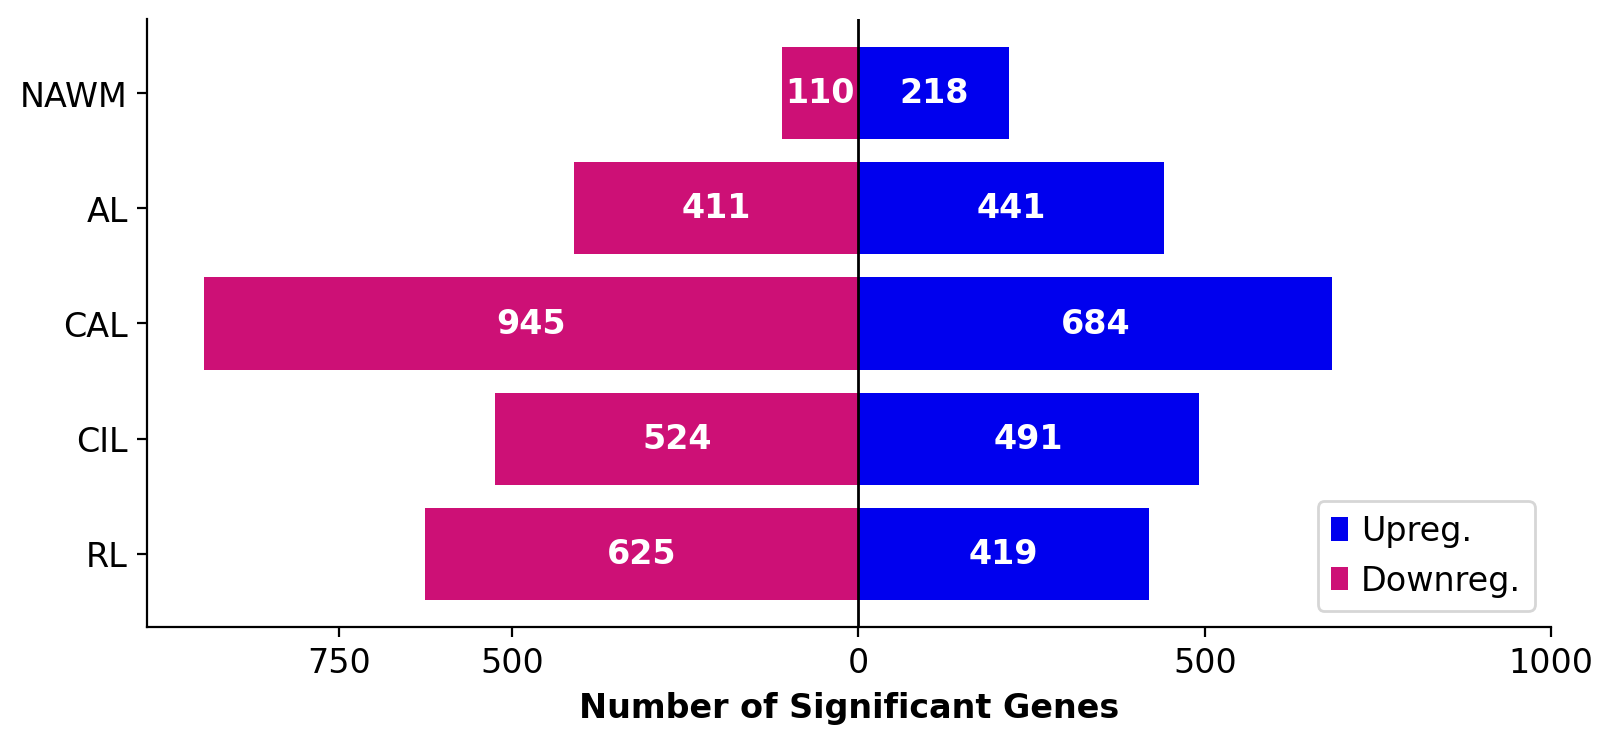

In [28]:
# Data
conditions = ["NAWM", "AL", "CAL", "CIL", "RL"]

up_genes = np.array([218, 441, 684, 491, 419])
down_genes = np.array([-110, -411, -945, -524, -625])  # negative for left alignment

# Reverse all data
conditions = conditions[::-1]
up_genes = up_genes[::-1]
down_genes = down_genes[::-1]

# Bar width (increased) and figure size (shorter height)
bar_width = 0.8
fig, ax = plt.subplots(figsize=(9, 4))  # Reduce height to save space

# Plot downregulated genes (left side)
bars_down = ax.barh(
    conditions,
    down_genes,
    color='#CD1076',
    label="Downregulated Genes",
    height=bar_width
)

# Plot upregulated genes (right side)
bars_up = ax.barh(
    conditions,
    up_genes,
    color='#0000EE',
    label="Upregulated Genes",
    height=bar_width
)

# Add number labels (always white)
for bar, value in zip(bars_down, down_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(abs(value)),
        ha='center',
        va='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

for bar, value in zip(bars_up, up_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        ha='center',
        va='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

# Formatting
ax.set_yticks(np.arange(len(conditions)))
ax.set_yticklabels(conditions, fontsize=12)
ax.set_xlabel("Number of Significant Genes", fontsize=12, fontweight='bold')

# Adjust x-axis to show only -1000, -500, 0, 500, 1000
ax.set_xticks([-750, -500, 0, 500, 1000])
ax.set_xticklabels([750, 500, 0, 500, 1000], fontsize=12)

ax.axvline(0, color='black', linewidth=1)  # Zero line

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove grid lines
ax.grid(False)

# Properly reorder the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[1], handles[0]],
    ["Upreg.", "Downreg."],
    loc="lower right",
    fontsize=12
)

# Save the plot
plt.savefig("./figures/human_MOL_DEG_bar_chart_GLMM_full.png", dpi=300, bbox_inches='tight')  # Save with high quality

# Show plot
plt.show()

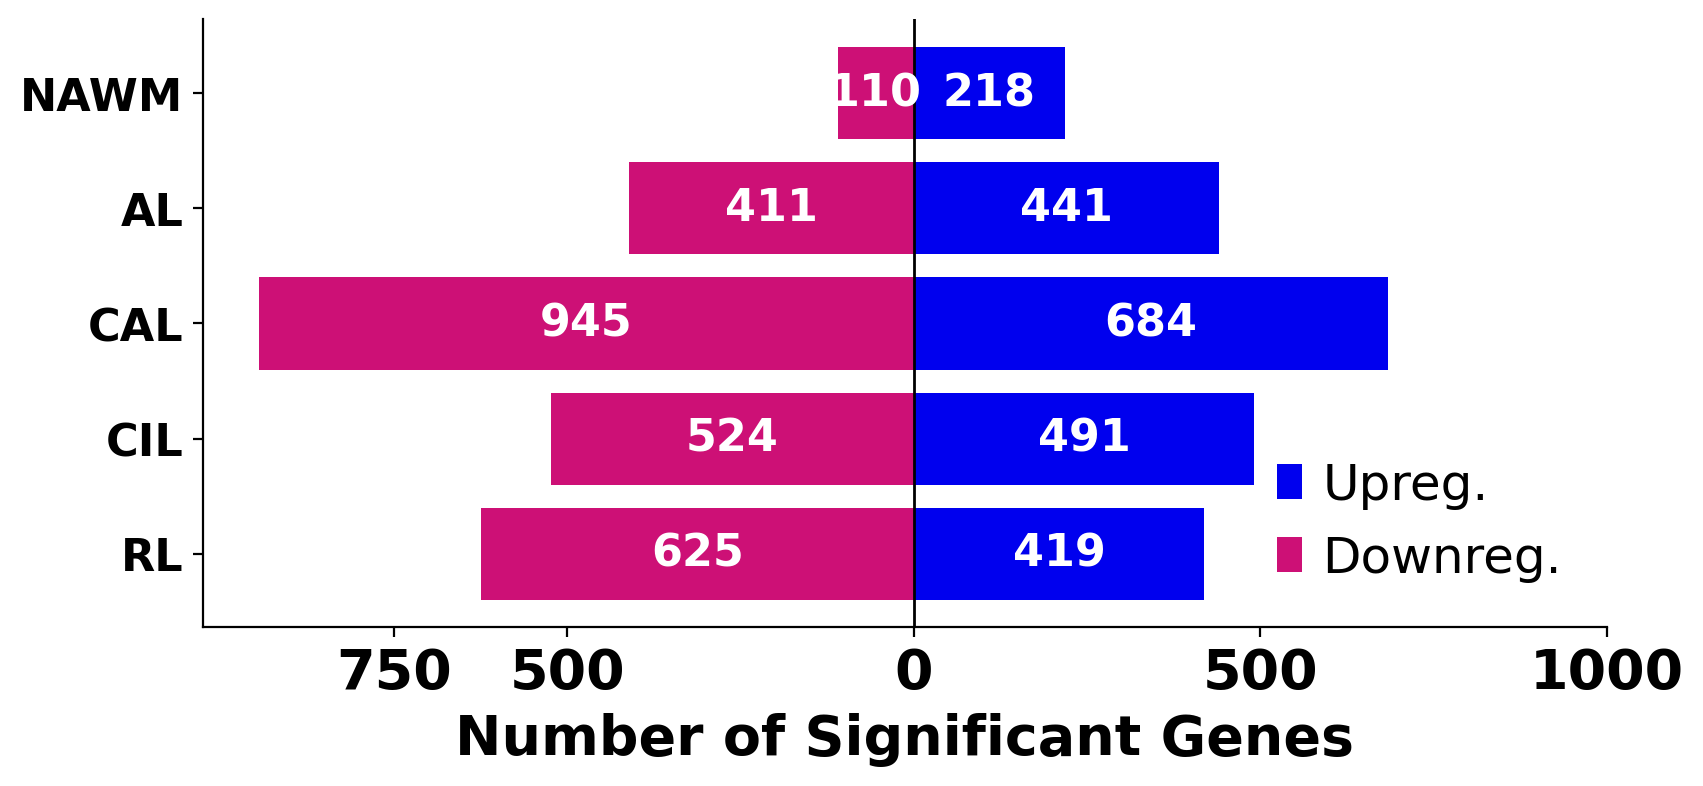

In [29]:
# Data
conditions = ["NAWM", "AL", "CAL", "CIL", "RL"]

up_genes = np.array([218, 441, 684, 491, 419])
down_genes = np.array([-110, -411, -945, -524, -625])  # negative for left alignment

# Reverse all data
conditions = conditions[::-1]
up_genes = up_genes[::-1]
down_genes = down_genes[::-1]

# Bar width (increased) and figure size (shorter height)
bar_width = 0.8
fig, ax = plt.subplots(figsize=(9, 4))  # Reduce height to save space

# Plot downregulated genes (left side)
bars_down = ax.barh(
    conditions,
    down_genes,
    color='#CD1076',
    label="Downregulated Genes",
    height=bar_width
)

# Plot upregulated genes (right side)
bars_up = ax.barh(
    conditions,
    up_genes,
    color='#0000EE',
    label="Upregulated Genes",
    height=bar_width
)

# Add number labels (always white)
for bar, value in zip(bars_down, down_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(abs(value)),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

for bar, value in zip(bars_up, up_genes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        ha='center',
        va='center',
        color='white',
        fontsize=16,           # bigger number labels
        fontweight='bold'
    )

# Formatting axis labels and ticks
ax.set_yticks(np.arange(len(conditions)))
ax.set_yticklabels(conditions, fontsize=16, fontweight='bold')  # Bigger Y tick labels
ax.set_xlabel("Number of Significant Genes", fontsize=20, fontweight='bold')  # Bigger X label

# Adjust x-axis to show only -1000, -500, 0, 500, 1000
ax.set_xticks([-750, -500, 0, 500, 1000])
ax.set_xticklabels([750, 500, 0, 500, 1000], fontsize=20, fontweight='bold')  # Bigger X tick labels

ax.axvline(0, color='black', linewidth=1)  # Zero line

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove grid lines
ax.grid(False)

# Properly reorder the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    [handles[1], handles[0]],
    ["Upreg.", "Downreg."],
    loc="lower right",
    fontsize=18,          # Bigger legend text
    frameon=False         # Cleaner look
)

# Save the plot
plt.savefig("./human_MOL_DEG_bar_chart_GLMM_full.png", dpi=300, bbox_inches='tight')

# Show plot
plt.show()

# Upset plot without subsetting

In [142]:
from upsetplot import plot
from upsetplot import from_contents
from upsetplot import UpSet

In [139]:
# Create gene lists for each condition
genes_NAWM_up = MOL_NAWM_up['gene'].tolist()
genes_AL_up = MOL_AL_up['gene'].tolist()
genes_CAL_up = MOL_CAL_up['gene'].tolist()
genes_CIL_up = MOL_CIL_up['gene'].tolist()
genes_RL_up = MOL_RL_up['gene'].tolist()

# Define a helper function to create DataFrames with a True flag
def create_gene_df(genes_list, label):
    """
    Create a DataFrame with a column indicating presence in this list
    and a column with gene names.
    """
    return pd.DataFrame({
        label: True,
        'Gene': genes_list
    })

# Create individual DataFrames
NAWM_up_df = create_gene_df(genes_NAWM_up, 'NAWM_up')
AL_up_df = create_gene_df(genes_AL_up, 'AL_up')
CAL_up_df = create_gene_df(genes_CAL_up, 'CAL_up')
CIL_up_df = create_gene_df(genes_CIL_up, 'CIL_up')
RL_up_df = create_gene_df(genes_RL_up, 'RL_up')

In [140]:
# Hierarchically merge all the DataFrames on 'Gene'
up_df = NAWM_up_df.merge(
    AL_up_df.merge(
        CAL_up_df.merge(
            CIL_up_df.merge(
                RL_up_df, on='Gene', how='outer'
            ), on='Gene', how='outer'
        ), on='Gene', how='outer'
    ), on='Gene', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
up_df_plot = up_df.set_index([
    'NAWM_up', 'AL_up', 'CAL_up', 'CIL_up', 'RL_up'
])

# Print the final merged DataFrame
print("Upregulated genes across all conditions (hierarchically merged):")
print(up_df_plot)

Upregulated genes across all conditions (hierarchically merged):
                                      Gene
NAWM_up AL_up CAL_up CIL_up RL_up         
False   False True   False  False    ABCA6
                            False    ABCA9
                            False    ABCB1
                            False    ABCG2
        True  False  False  False  ABHD12B
...                                    ...
                            False   ZNF618
              True   False  False  ZNF804A
True    False False  False  False   ZNHIT2
False   False True   False  False   ZSWIM1
        True  False  True   True    ZSWIM4

[1457 rows x 1 columns]


/tmp/2310260.1.long/ipykernel_375264/575165265.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

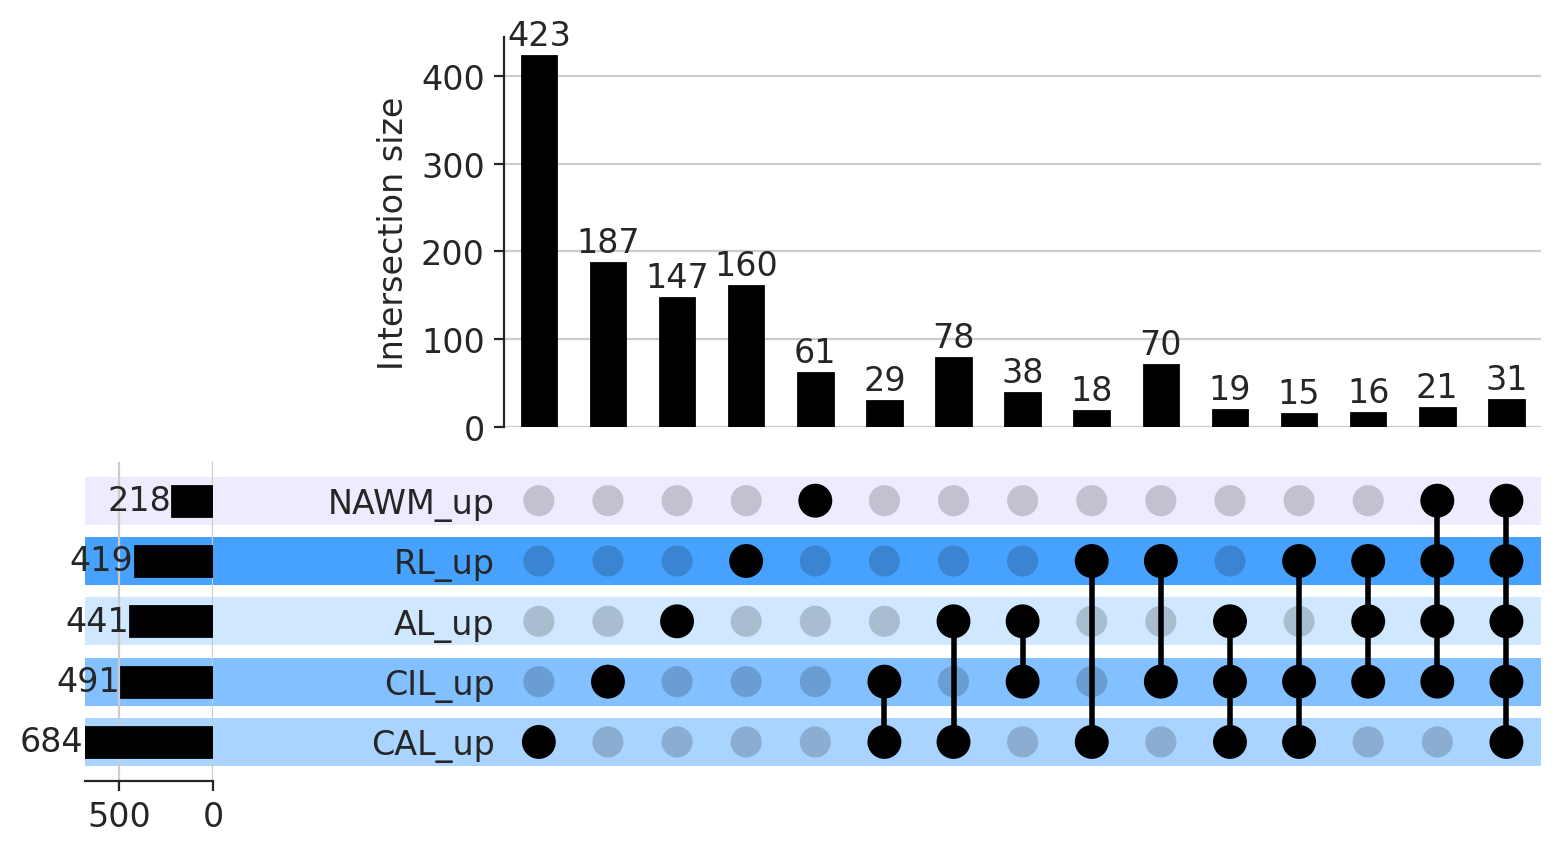

In [161]:
# Create UpSet plot
upset = UpSet(up_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size = 15)

# Style the subsets
upset.style_categories(
    'NAWM_up',
    shading_facecolor="#ececfe",
)

# Style the subsets
upset.style_categories(
    'AL_up',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL_up',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL_up',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL_up',
    shading_facecolor="#47a2ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
plt.savefig('./figures/hs_OL_upset_nosubset_plot_up_n15_glmm.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [148]:
# Create sets
set_NAWM_up = set(genes_NAWM_up)
set_AL_up = set(genes_AL_up)
set_CAL_up = set(genes_CAL_up)
set_CIL_up = set(genes_CIL_up)
set_RL_up = set(genes_RL_up)

In [149]:
genes_common_up = set_NAWM_up & set_AL_up & set_CAL_up & set_CIL_up & set_RL_up
length_common_up = len(genes_common_up)

print(length_common_up)
print(genes_common_up)

31
{'GULP1', 'GPC5', 'CLVS2', 'SGCZ', 'RHOBTB3', 'SEMA4B', 'SH3RF3', 'VSIR', 'LUZP2', 'CRIM1', 'GPRIN3', 'FAM129B', 'IL1RAP', 'BIRC3', 'FAM107A', 'CHDH', 'CNTN3', 'PID1', 'FAP', 'MEST', 'AC008840.1', 'LHFPL3', 'ST8SIA5', 'SEMA3E', 'FOXP2', 'PRKX', 'TNFRSF1A', 'SCN3A', 'C1orf21', 'GRM8', 'GFAP'}


In [150]:
genes_ALCAL =  set_AL_up & set_CAL_up -set_NAWM_up - set_CIL_up - set_RL_up
length = len(genes_ALCAL)

print(length)
print(genes_ALCAL)

78
{'ELK1', 'SNX3', 'RUVBL2', 'HYKK', 'FOXO4', 'AC099518.1', 'PPP1R9B', 'GCNA', 'AC011462.2', 'GABRB1', 'SYT17', 'METTL21A', 'AP000317.1', 'TMEM26', 'MGARP', 'ITGB3BP', 'CENPS-CORT', 'PLPP4', 'ZNF804A', 'NCAPG', 'UTP23', 'CDKN2A', 'SLC29A3', 'ZNF358', 'CCDC117', 'FAM78A', 'EPHA4', 'AP001347.1', 'ST3GAL2', 'IFIH1', 'DISP1', 'IQCD', 'AC246817.2', 'GPRIN1', 'CELF2', 'AC004949.1', 'MAZ', 'MEPCE', 'MOB4', 'LNCAROD', 'NEXN', 'RBMS3', 'PTOV1', 'CTDSP2', 'FERMT3', 'MMP16', 'CSNK1A1L', 'AL365232.1', 'LPL', 'CREBRF', 'LHFPL2', 'MBD3', 'ABHD3', 'PNLDC1', 'RGSL1', 'NPFFR1', 'TENT4B', 'AL645465.1', 'NDUFC2-KCTD14', 'TUBA1C', 'RANGAP1', 'WWTR1', 'TNFRSF19', 'AR', 'IGSF21', 'FERMT1', 'BNIPL', 'PLOD1', 'PNMA2', 'AL445250.1', 'MIB1', 'TRPV4', 'AL136115.2', 'AC116362.1', 'PARD6G-AS1', 'SLC27A6', 'PRKD1', 'CACFD1'}


In [151]:
genes_RLCIL =  set_RL_up & set_CIL_up -set_NAWM_up - set_CAL_up - set_AL_up
length = len(genes_RLCIL)

print(length)
print(genes_RLCIL)

70
{'PNPLA3', 'AC126696.3', 'AZGP1', 'CTBS', 'JCAD', 'GALNT18', 'TRAM2', 'FMNL3', 'NDRG4', 'BCL6', 'SLC6A8', 'NR4A1', 'DEPDC1', 'ATP2B4', 'NMI', 'PROS1', 'AC025219.1', 'IFI16', 'SORCS2', 'TJP2', 'NOTCH2', 'KHDRBS3', 'ITGA11', 'AC007325.2', 'TMEM97', 'CSRNP1', 'TRIP10', 'AC037459.2', 'FBXO17', 'PDE7A', 'CSMD2', 'KLHL13', 'ADGRG1', 'GNG12', 'FRY-AS1', 'GAPLINC', 'HIVEP1', 'LINC01010', 'DCLK1', 'ZFP36', 'KLF9', 'KIF19', 'FOS', 'KLF10', 'IRF2BPL', 'HLA-E', 'NBPF10', 'FKBP5', 'BTBD17', 'APOL2', 'PCSK5', 'COLEC12', 'ELMSAN1', 'TAGLN2', 'MYO5B', 'PTPRM', 'RAB40C', 'EP300-AS1', 'AC083843.3', 'SOCS3', 'MPZL1', 'DUSP9', 'LINC01583', 'FAM114A1', 'RUNX1T1', 'NAV3', 'GRASP', 'IL16', 'HERC6', 'VSX1'}


In [152]:
# Create gene lists for each condition
genes_NAWM_down = MOL_NAWM_down['gene'].tolist()
genes_AL_down = MOL_AL_down['gene'].tolist()
genes_CAL_down = MOL_CAL_down['gene'].tolist()
genes_CIL_down = MOL_CIL_down['gene'].tolist()
genes_RL_down = MOL_RL_down['gene'].tolist()

# Define a helper function to create DataFrames with a True flag
def create_gene_df(genes_list, label):
    """
    Create a DataFrame with a column indicating presence in this list
    and a column with gene names.
    """
    return pd.DataFrame({
        label: True,
        'Gene': genes_list
    })

# Create individual DataFrames
NAWM_down_df = create_gene_df(genes_NAWM_down, 'NAWM_down')
AL_down_df = create_gene_df(genes_AL_down, 'AL_down')
CAL_down_df = create_gene_df(genes_CAL_down, 'CAL_down')
CIL_down_df = create_gene_df(genes_CIL_down, 'CIL_down')
RL_down_df = create_gene_df(genes_RL_down, 'RL_down')

In [153]:
# Hierarchically merge all the DataFrames on 'Gene'
down_df = NAWM_down_df.merge(
    AL_down_df.merge(
        CAL_down_df.merge(
            CIL_down_df.merge(
                RL_down_df, on='Gene', how='outer'
            ), on='Gene', how='outer'
        ), on='Gene', how='outer'
    ), on='Gene', how='outer'
)

# Replace NaN with False
down_df = down_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
down_df_plot = down_df.set_index([
    'NAWM_down', 'AL_down', 'CAL_down', 'CIL_down', 'RL_down'
])

# Print the final merged DataFrame
print("Downregulated genes across all conditions (hierarchically merged):")
print(down_df_plot)

Downregulated genes across all conditions (hierarchically merged):
                                                 Gene
NAWM_down AL_down CAL_down CIL_down RL_down          
False     True    True     False    False        A1BG
                  False    False    False    A1BG-AS1
          False   True     False    False        AASS
                  False    False    True        ABCA7
                                    True        ABCB1
...                                               ...
                  True     False    False      ZNF682
                                    False      ZNF853
          True    True     False    False      ZNF883
          False   False    False    True        ZNF98
          True    False    True     True      ZSCAN31

[1858 rows x 1 columns]


/tmp/2310260.1.long/ipykernel_375264/2996960993.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  down_df = down_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

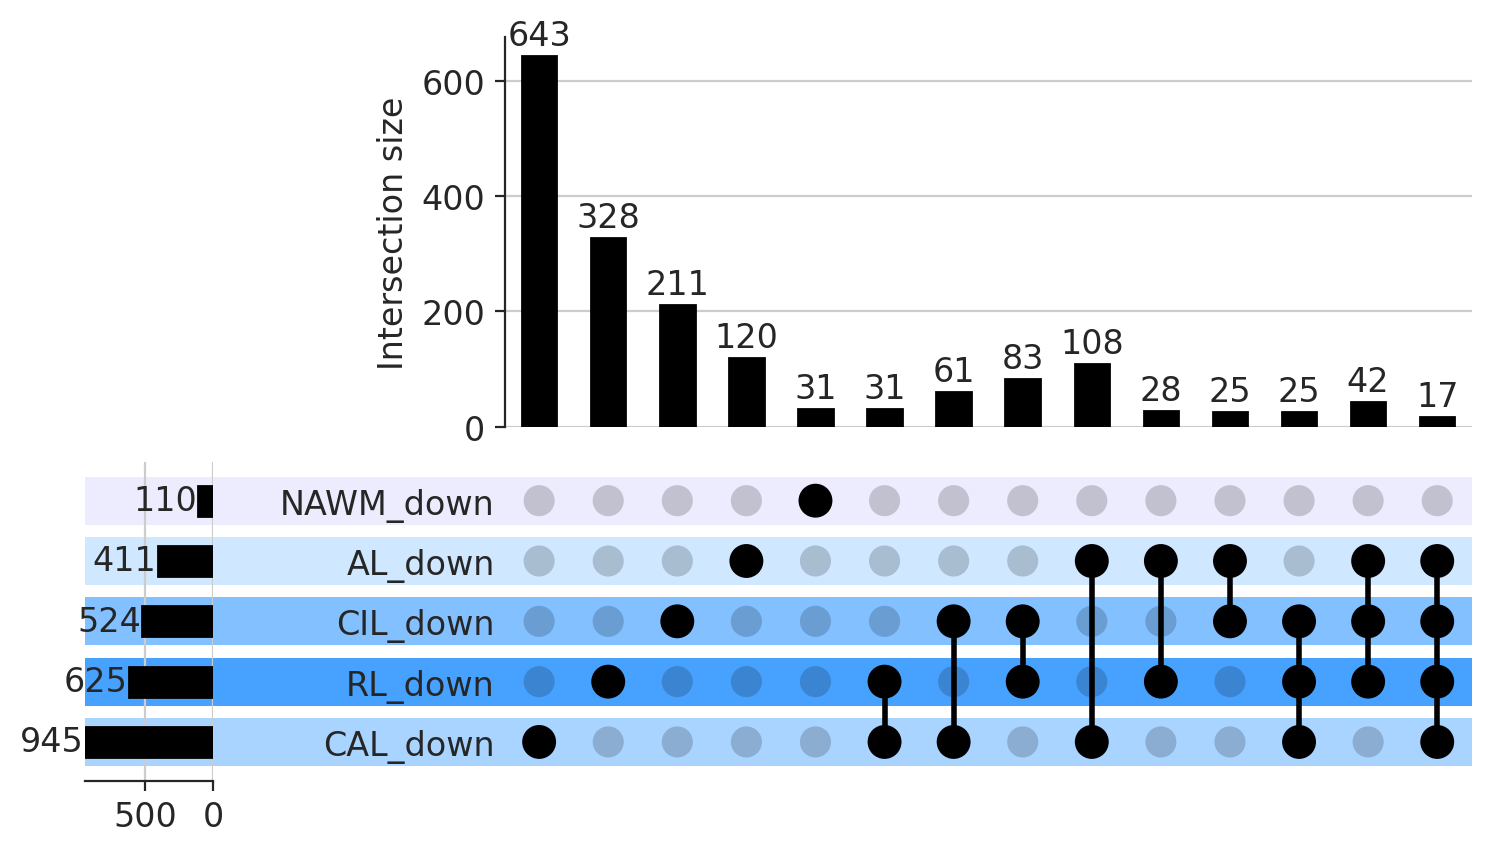

In [162]:
# Create UpSet plot
upset = UpSet(down_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size=15)

# Style the subsets
upset.style_categories(
    'NAWM_down',
    shading_facecolor="#ececfe",
)

# Style the subsets
upset.style_categories(
    'AL_down',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL_down',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL_down',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL_down',
    shading_facecolor="#47a2ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
plt.savefig('./figures/hs_OL_upset_nosubset_plot_down_n10_glmm.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [156]:
# Create sets
set_NAWM_down = set(genes_NAWM_down)
set_AL_down = set(genes_AL_down)
set_CAL_down = set(genes_CAL_down)
set_CIL_down = set(genes_CIL_down)
set_RL_down = set(genes_RL_down)

In [157]:
genes_common_down = set_NAWM_down & set_AL_down & set_CAL_down & set_CIL_down & set_RL_down
length = len(genes_common_down)

print(length)
print(genes_common_down)

10
{'COL16A1', 'RAB7B', 'AHNAK2', 'ZFYVE16', 'DCLK2', 'LPCAT2', 'AC100768.2', 'LINC01310', 'AP001970.1', 'LINC00891'}


# Upset plots- with subsetting

In [29]:
print(len(MOL_NAWM))
print(len(MOL_AL))
print(len(MOL_CAL))
print(len(MOL_CIL))
print(len(MOL_RL))

15298
14958
16952
15952
17208


In [30]:
## IMPORTANT FILTER FOR GENES TESTING IN ALL CONDITIONS

genes_all_conditions = (
    set(MOL_NAWM['gene'])
    & set(MOL_AL['gene'])
    & set(MOL_RL['gene'])
    & set(MOL_CAL['gene'])
    & set(MOL_CIL['gene'])
)

In [31]:
len(genes_all_conditions)

8953

In [32]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all_conditions)]

# Apply filtering to each DEG DataFrame
MOL_NAWM_up = filter_genes(MOL_NAWM_up)
MOL_AL_up = filter_genes(MOL_AL_up)
MOL_CAL_up = filter_genes(MOL_CAL_up)
MOL_CIL_up = filter_genes(MOL_CIL_up)
MOL_RL_up = filter_genes(MOL_RL_up)

print(MOL_NAWM_up.shape)
print(MOL_AL_up.shape)
print(MOL_CAL_up.shape)
print(MOL_CIL_up.shape)
print(MOL_RL_up.shape)

(155, 12)
(229, 12)
(294, 12)
(278, 12)
(240, 12)


In [33]:
# Create gene lists for each condition
genes_NAWM_up = MOL_NAWM_up['gene'].tolist()
genes_AL_up = MOL_AL_up['gene'].tolist()
genes_CAL_up = MOL_CAL_up['gene'].tolist()
genes_CIL_up = MOL_CIL_up['gene'].tolist()
genes_RL_up = MOL_RL_up['gene'].tolist()

# Define a helper function to create DataFrames with a True flag
def create_gene_df(genes_list, label):
    """
    Create a DataFrame with a column indicating presence in this list
    and a column with gene names.
    """
    return pd.DataFrame({
        label: True,
        'Gene': genes_list
    })

# Create individual DataFrames
NAWM_up_df = create_gene_df(genes_NAWM_up, 'NAWM_up')
AL_up_df = create_gene_df(genes_AL_up, 'AL_up')
CAL_up_df = create_gene_df(genes_CAL_up, 'CAL_up')
CIL_up_df = create_gene_df(genes_CIL_up, 'CIL_up')
RL_up_df = create_gene_df(genes_RL_up, 'RL_up')

In [34]:
# Hierarchically merge all the DataFrames on 'Gene'
up_df = NAWM_up_df.merge(
    AL_up_df.merge(
        CAL_up_df.merge(
            CIL_up_df.merge(
                RL_up_df, on='Gene', how='outer'
            ), on='Gene', how='outer'
        ), on='Gene', how='outer'
    ), on='Gene', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
up_df_plot = up_df.set_index([
    'NAWM_up', 'AL_up', 'CAL_up', 'CIL_up', 'RL_up'
])

# Print the final merged DataFrame
print("Upregulated genes across all conditions (hierarchically merged):")
print(up_df_plot)

Upregulated genes across all conditions (hierarchically merged):
                                         Gene
NAWM_up AL_up CAL_up CIL_up RL_up            
False   False True   False  False       ABCA6
                            False       ABCA9
                            False       ABCG2
        True  False  False  False     ABHD12B
                            False  AC002996.1
...                                       ...
        False True   True   False     ZNF385D
                     False  False      ZNF408
              False  False  True       ZNF442
        True  False  False  False      ZNF618
        False True   False  False      ZSWIM1

[656 rows x 1 columns]


/tmp/2279988.1.long/ipykernel_87738/575165265.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

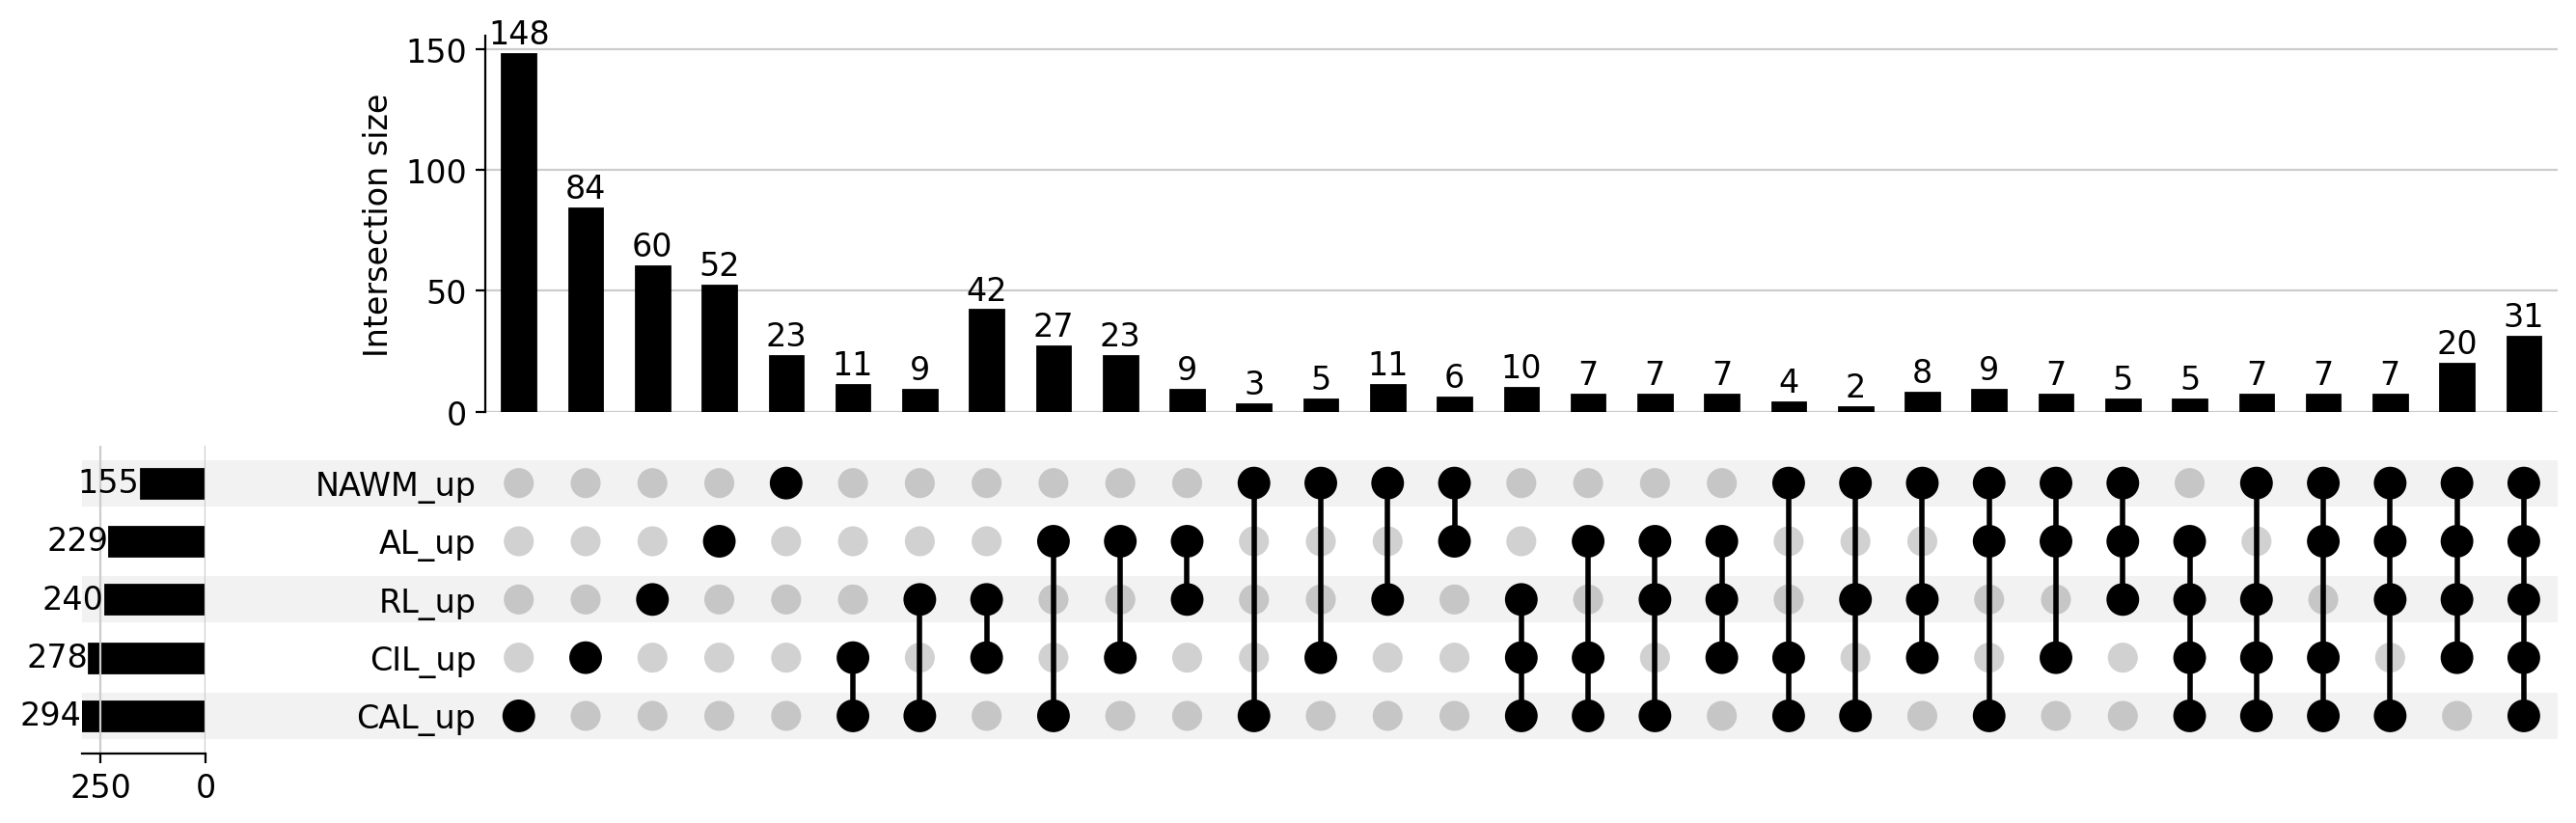

In [35]:
upset_plot = UpSet(up_df_plot, subset_size='count', show_counts=True,).plot()

In [36]:
# Dictionary to map old index names to new index names
index_name_map = {
    'OPC_de_down': 'OPC_AL',
    'OPC_re_down': 'OPC_RL',
    'LPC_de_down': 'MOL_G_AL',
    'LPC_re_down': 'MOL_G_RL',
}

# Rename the index levels using the dictionary
#down_df_plot.index = down_df_plot.index.rename(index_name_map)

#print("Updated Upregulated genes DataFrame:")
#print(down_df_plot)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

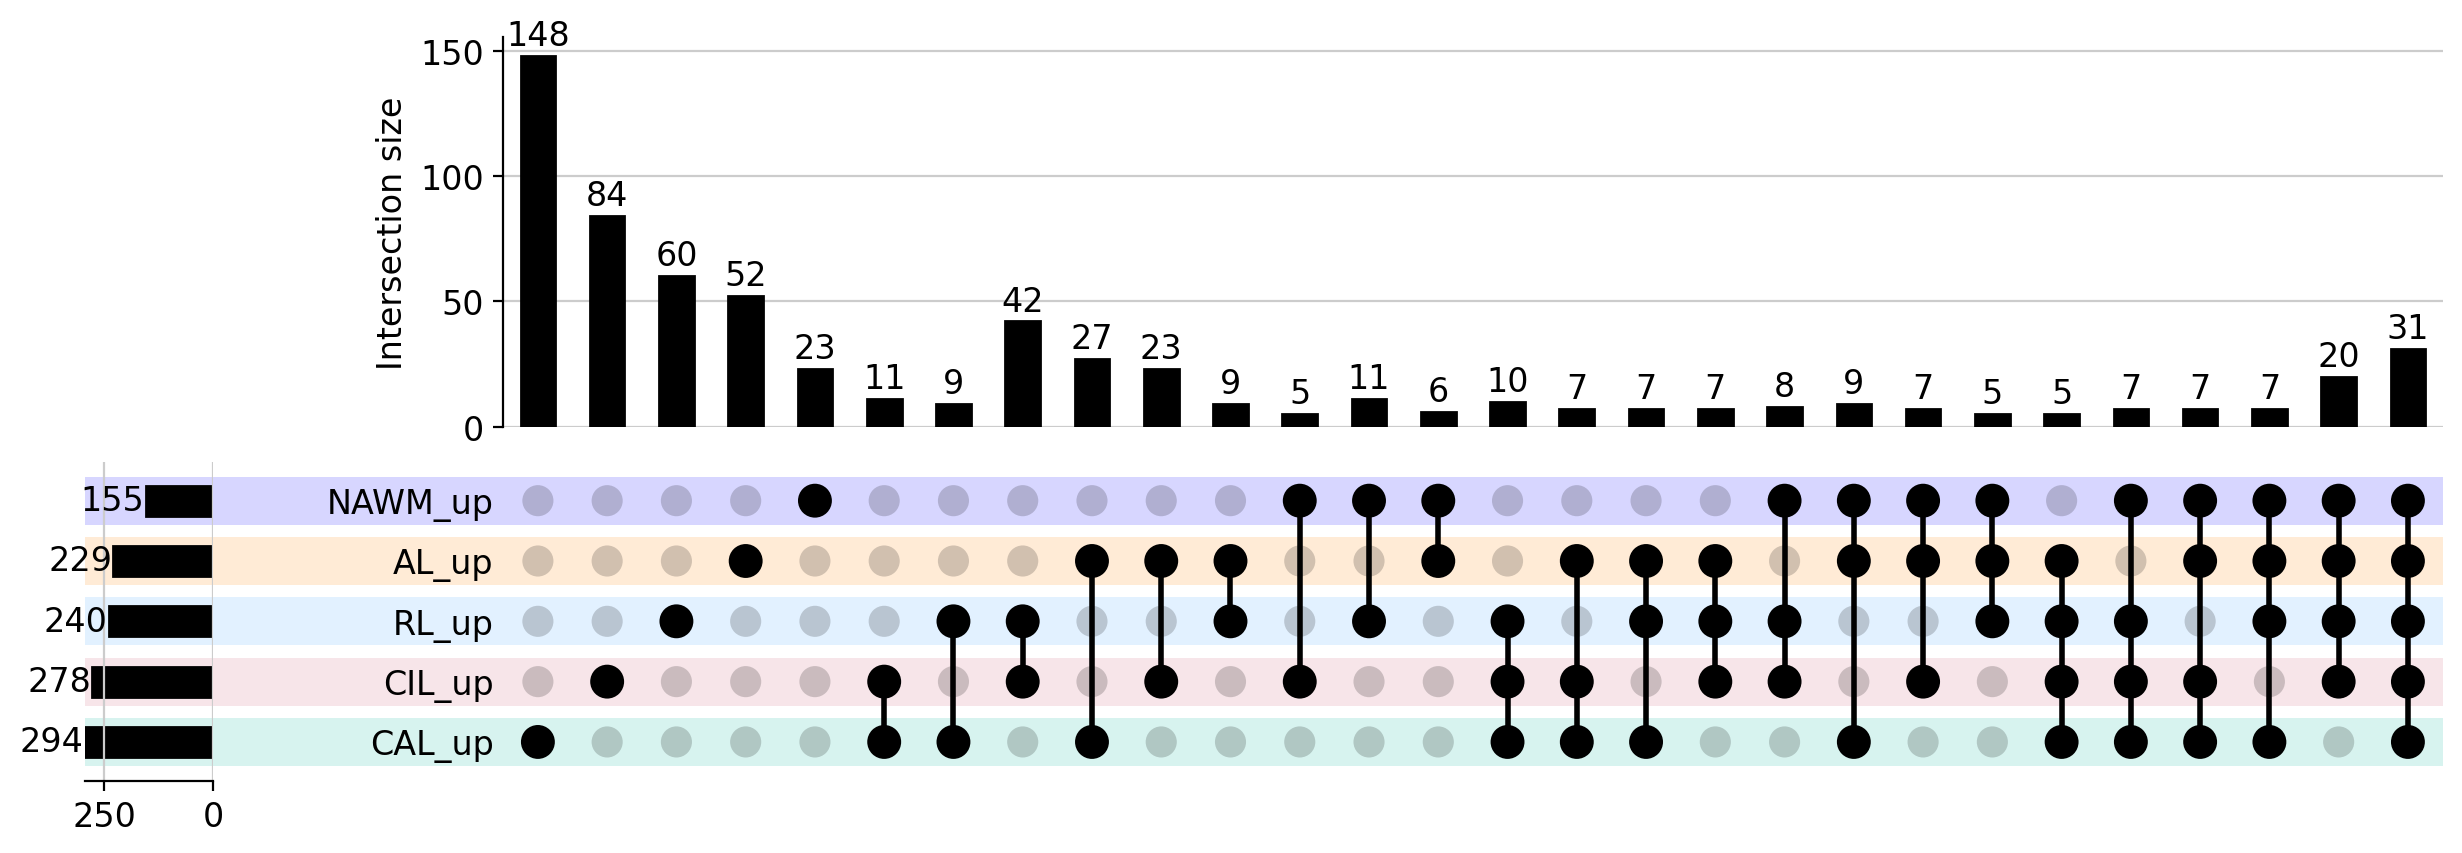

In [37]:
# Create UpSet plot
upset = UpSet(up_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size = 5)

# Style the subsets
upset.style_categories(
    'NAWM_up',
    shading_facecolor="#d7d6ff",
)

# Style the subsets
upset.style_categories(
    'AL_up',
    shading_facecolor="#ffebd6",
)

# Style the subsets
upset.style_categories(
    'CAL_up',
    shading_facecolor="#d7f3ef",
)

# Style the subsets
upset.style_categories(
    'CIL_up',
    shading_facecolor="#f7e5e9",
)

# Style the subsets
upset.style_categories(
    'RL_up',
    shading_facecolor="#e2f1ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
#plt.savefig('./figures/hs_OL_upset_plot_up_ALL.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

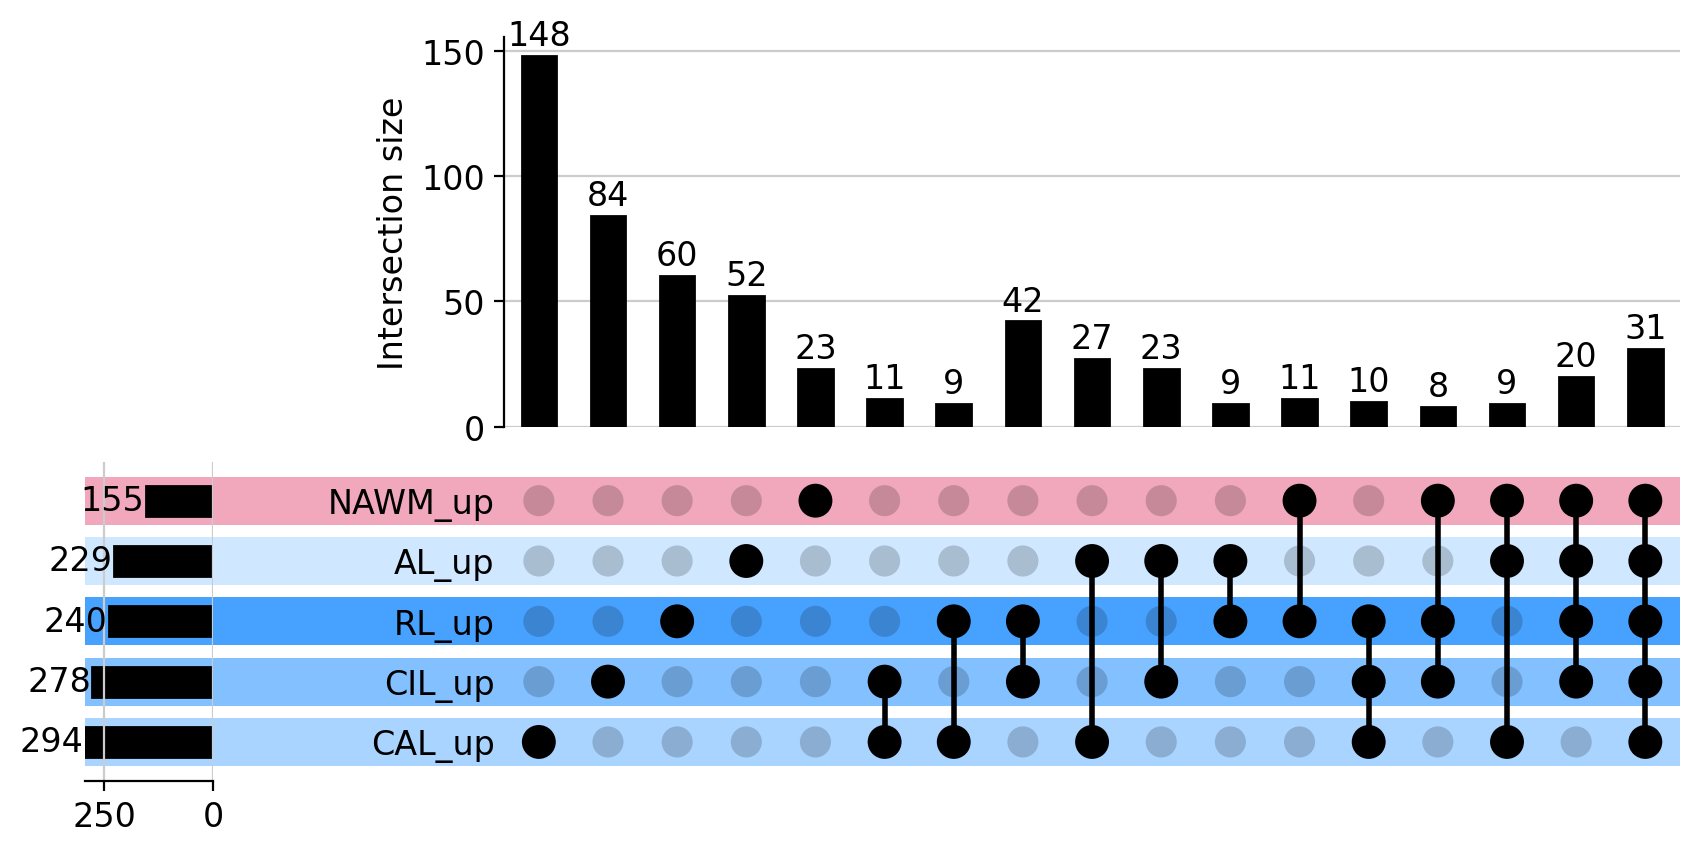

In [38]:
# Create UpSet plot
upset = UpSet(up_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size = 8)

# Style the subsets
upset.style_categories(
    'NAWM_up',
    shading_facecolor="#f1a8bd",
)

# Style the subsets
upset.style_categories(
    'AL_up',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL_up',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL_up',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL_up',
    shading_facecolor="#47a2ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
plt.savefig('./figures/hs_OL_upset_plot_up_n8_glmm_COLORS.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [39]:
# Create sets
set_NAWM_up = set(genes_NAWM_up)
set_AL_up = set(genes_AL_up)
set_CAL_up = set(genes_CAL_up)
set_CIL_up = set(genes_CIL_up)
set_RL_up = set(genes_RL_up)

In [40]:
genes_common_up = set_NAWM_up & set_AL_up & set_CAL_up & set_CIL_up & set_RL_up
length_common_up = len(genes_common_up)

print(length_common_up)
print(genes_common_up)

31
{'LUZP2', 'FAM129B', 'MEST', 'FAP', 'SH3RF3', 'FOXP2', 'FAM107A', 'CRIM1', 'GPRIN3', 'LHFPL3', 'VSIR', 'CLVS2', 'PRKX', 'PID1', 'CHDH', 'SEMA3E', 'SCN3A', 'GPC5', 'GULP1', 'AC008840.1', 'GFAP', 'C1orf21', 'TNFRSF1A', 'BIRC3', 'GRM8', 'SEMA4B', 'SGCZ', 'CNTN3', 'ST8SIA5', 'RHOBTB3', 'IL1RAP'}


In [41]:
genes_AL_CAL = set_AL_up & set_CAL_up - set_NAWM_up - set_CIL_up - set_RL_up
lenght = len(genes_AL_CAL)

print(lenght)
print(genes_AL_CAL)

27
{'TUBA1C', 'AP000317.1', 'IGSF21', 'MMP16', 'METTL21A', 'SLC27A6', 'UTP23', 'GPRIN1', 'FERMT1', 'AL445250.1', 'CDKN2A', 'GCNA', 'LNCAROD', 'NPFFR1', 'GABRB1', 'LHFPL2', 'EPHA4', 'HYKK', 'TNFRSF19', 'DISP1', 'PPP1R9B', 'PNMA2', 'CELF2', 'RBMS3', 'CTDSP2', 'WWTR1', 'AL645465.1'}


In [43]:
genes_CIL_RL = set_RL_up & set_CIL_up - set_NAWM_up - set_AL_up - set_CAL_up
lenght = len(genes_CIL_RL)

print(lenght)
print(genes_CIL_RL)

42
{'CSRNP1', 'FKBP5', 'PNPLA3', 'PROS1', 'KLF9', 'NR4A1', 'FBXO17', 'GRASP', 'HLA-E', 'GALNT18', 'PTPRM', 'JCAD', 'SLC6A8', 'APOL2', 'PDE7A', 'AC037459.2', 'ELMSAN1', 'NOTCH2', 'TAGLN2', 'SORCS2', 'MPZL1', 'KLF10', 'ATP2B4', 'NDRG4', 'GNG12', 'DCLK1', 'SOCS3', 'TJP2', 'CSMD2', 'NBPF10', 'FMNL3', 'KIF19', 'NAV3', 'COLEC12', 'KLHL13', 'RUNX1T1', 'RAB40C', 'KHDRBS3', 'FOS', 'HIVEP1', 'AZGP1', 'NMI'}


### Now down

In [46]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all_conditions)]

# Apply filtering to each DEG DataFrame
MOL_NAWM_down = filter_genes(MOL_NAWM_down)
MOL_AL_down = filter_genes(MOL_AL_down)
MOL_CAL_down = filter_genes(MOL_CAL_down)
MOL_CIL_down = filter_genes(MOL_CIL_down)
MOL_RL_down = filter_genes(MOL_RL_down)

print(MOL_NAWM_down.shape)
print(MOL_AL_down.shape)
print(MOL_CAL_down.shape)
print(MOL_CIL_down.shape)
print(MOL_RL_down.shape)

(64, 12)
(290, 12)
(567, 12)
(327, 12)
(326, 12)


In [47]:
# Create gene lists for each condition
genes_NAWM_down = MOL_NAWM_down['gene'].tolist()
genes_AL_down = MOL_AL_down['gene'].tolist()
genes_CAL_down = MOL_CAL_down['gene'].tolist()
genes_CIL_down = MOL_CIL_down['gene'].tolist()
genes_RL_down = MOL_RL_down['gene'].tolist()

# Define a helper function to create DataFrames with a True flag
def create_gene_df(genes_list, label):
    """
    Create a DataFrame with a column indicating presence in this list
    and a column with gene names.
    """
    return pd.DataFrame({
        label: True,
        'Gene': genes_list
    })

# Create individual DataFrames
NAWM_down_df = create_gene_df(genes_NAWM_down, 'NAWM_down')
AL_down_df = create_gene_df(genes_AL_down, 'AL_down')
CAL_down_df = create_gene_df(genes_CAL_down, 'CAL_down')
CIL_down_df = create_gene_df(genes_CIL_down, 'CIL_down')
RL_down_df = create_gene_df(genes_RL_down, 'RL_down')

In [48]:
# Hierarchically merge all the DataFrames on 'Gene'
down_df = NAWM_down_df.merge(
    AL_down_df.merge(
        CAL_down_df.merge(
            CIL_down_df.merge(
                RL_down_df, on='Gene', how='outer'
            ), on='Gene', how='outer'
        ), on='Gene', how='outer'
    ), on='Gene', how='outer'
)

# Replace NaN with False
down_df = down_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
down_df_plot = down_df.set_index([
    'NAWM_down', 'AL_down', 'CAL_down', 'CIL_down', 'RL_down'
])

# Print the final merged DataFrame
print("Downregulated genes across all conditions (hierarchically merged):")
print(down_df_plot)

Downregulated genes across all conditions (hierarchically merged):
                                                 Gene
NAWM_down AL_down CAL_down CIL_down RL_down          
False     True    False    False    False    A1BG-AS1
          False   True     False    False        AASS
                  False    False    True        ABCA7
          True    False    True     False       ABCC1
True      True    False    True     True        ABCC8
...                                               ...
False     False   False    True     True       ZNF423
                  True     False    False      ZNF565
          True    True     False    False      ZNF883
          False   False    False    True        ZNF98
          True    False    True     True      ZSCAN31

[1067 rows x 1 columns]


/tmp/ipykernel_4147135/2996960993.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  down_df = down_df.fillna(False)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

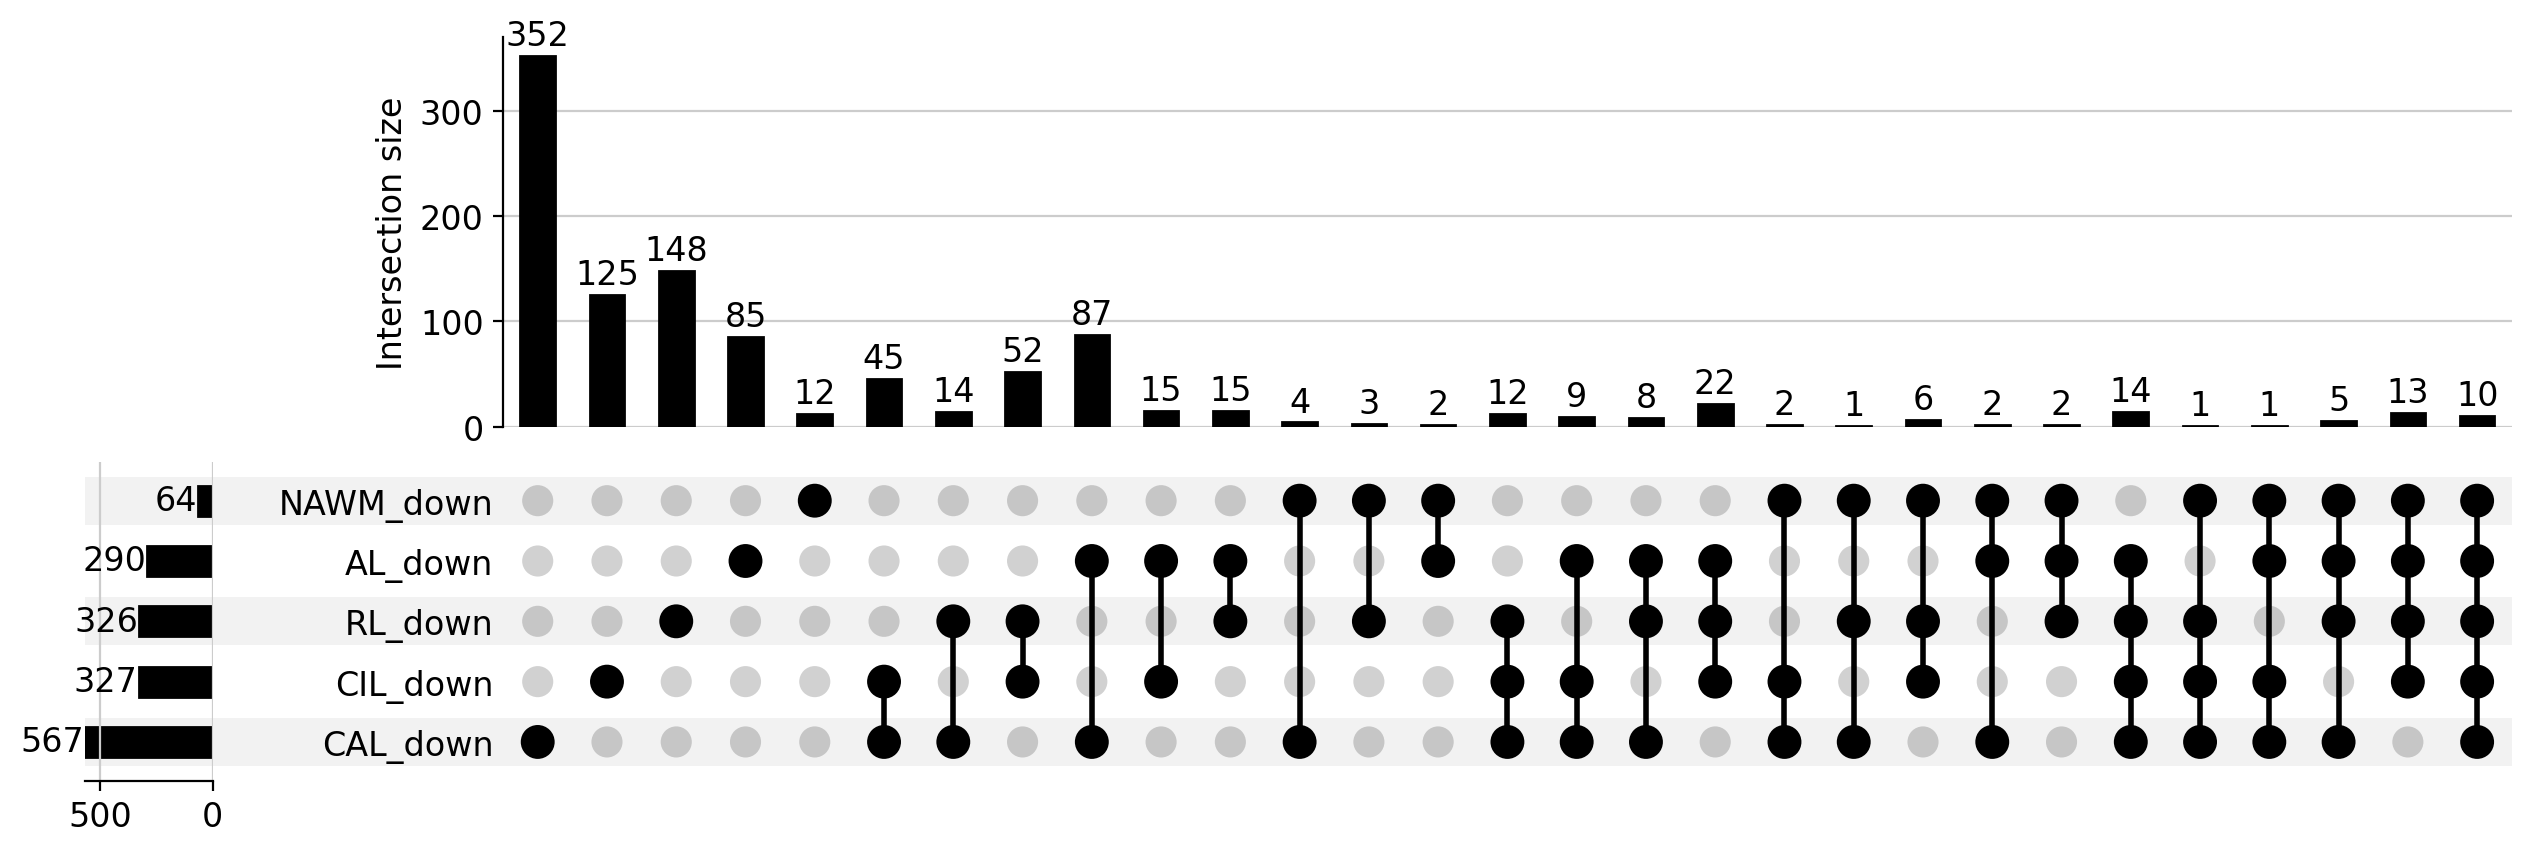

In [49]:
upset_plot = UpSet(down_df_plot, subset_size='count', show_counts=True,).plot()

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

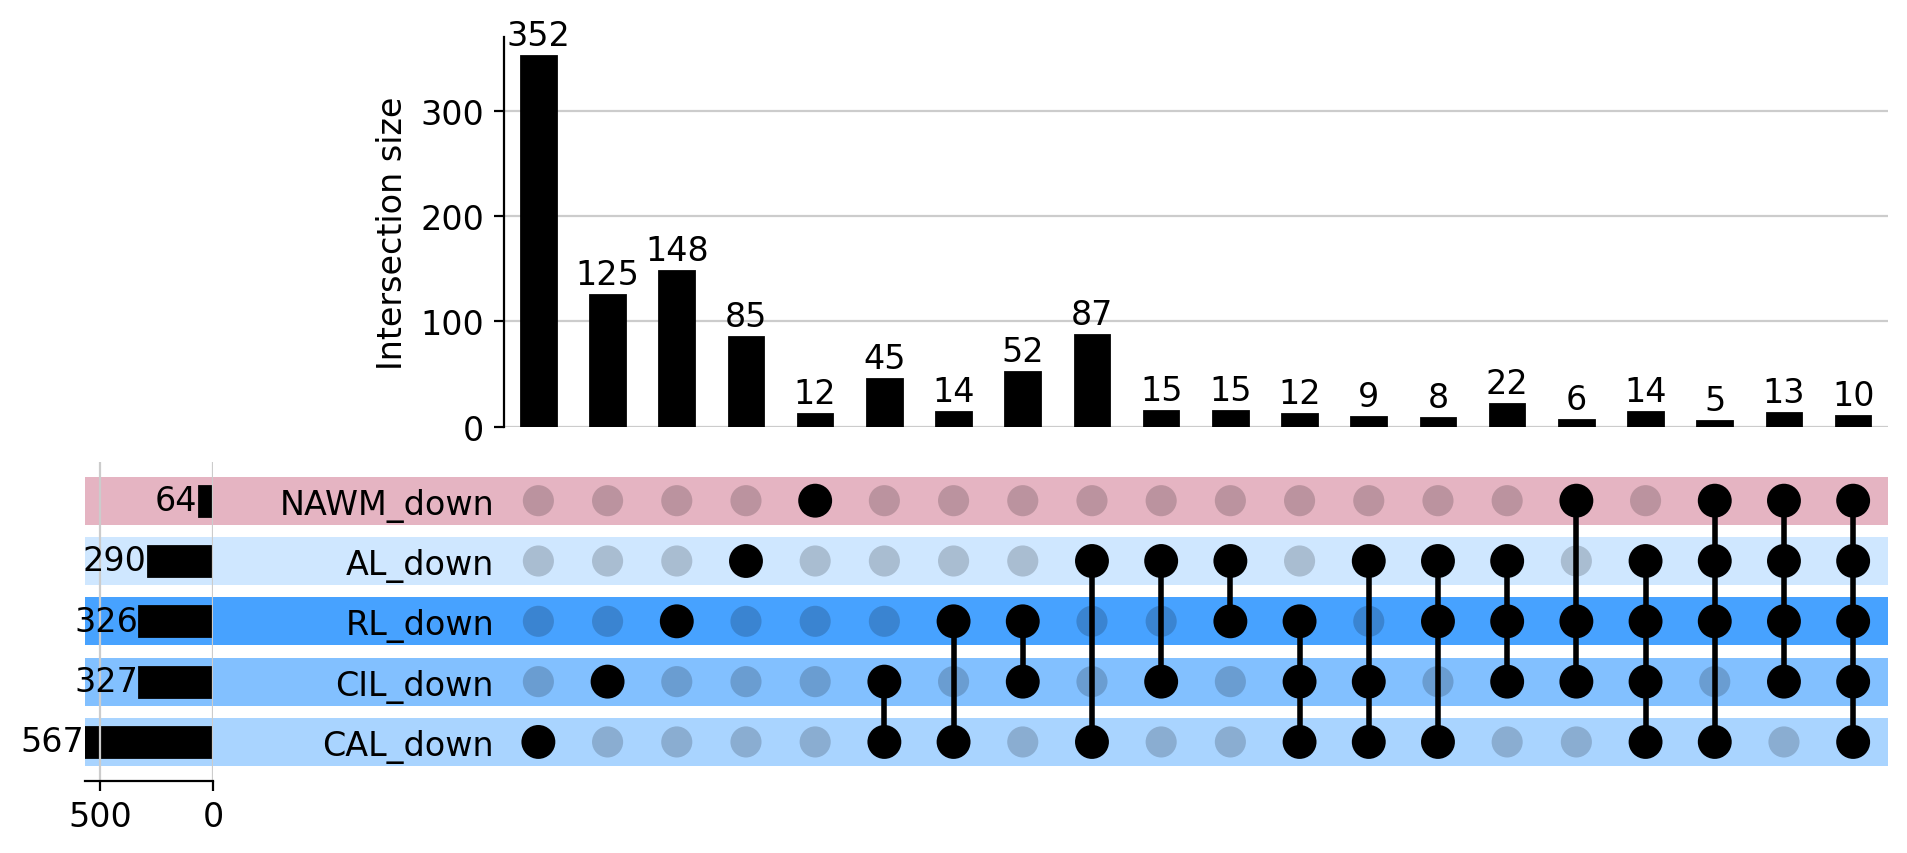

In [50]:
# Create UpSet plot
upset = UpSet(down_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size=5)

# Style the subsets
upset.style_categories(
    'NAWM_down',
    shading_facecolor="#f1a8bd",
)

# Style the subsets
upset.style_categories(
    'AL_down',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL_down',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL_down',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL_down',
    shading_facecolor="#47a2ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
#plt.savefig('./figures/hs_OL_upset_plot_down_ALL.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

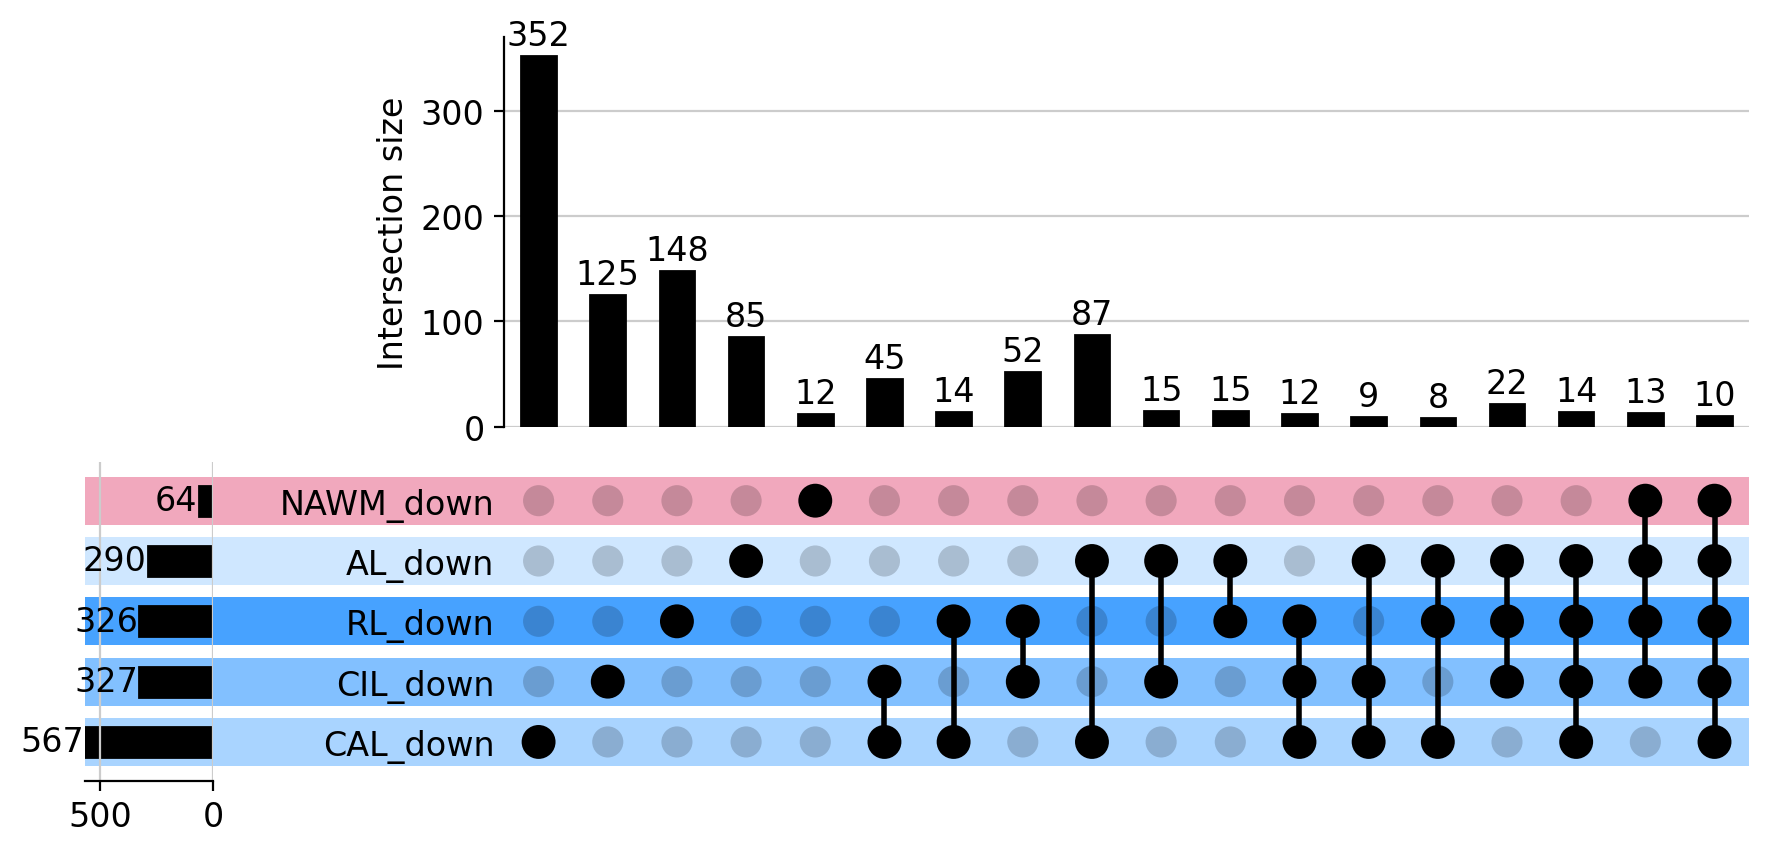

In [51]:
# Create UpSet plot
upset = UpSet(down_df_plot, subset_size='count', show_counts=True, facecolor="black", min_subset_size=8)

# Style the subsets
upset.style_categories(
    'NAWM_down',
    shading_facecolor="#f1a8bd",
)

# Style the subsets
upset.style_categories(
    'AL_down',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL_down',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL_down',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL_down',
    shading_facecolor="#47a2ff",
)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
plt.savefig('./figures/hs_OL_upset_plot_down_n8_glmm.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [50]:
# Create sets
set_NAWM_down = set(genes_NAWM_down)
set_AL_down = set(genes_AL_down)
set_CAL_down = set(genes_CAL_down)
set_CIL_down = set(genes_CIL_down)
set_RL_down = set(genes_RL_down)

In [51]:
genes_common_down = set_NAWM_down & set_AL_down & set_CAL_down & set_CIL_down & set_RL_down
length = len(genes_common_down)

print(length)
print(genes_common_down)

10
{'LINC01310', 'AP001970.1', 'COL16A1', 'LPCAT2', 'ZFYVE16', 'LINC00891', 'AC100768.2', 'DCLK2', 'AHNAK2', 'RAB7B'}


In [52]:
genes_AL_CAL = set_CAL_down & set_AL_down - set_CIL_down - set_RL_down - set_NAWM_down
lenght = len(genes_AL_CAL)

print(lenght)
print(genes_AL_CAL)

87
{'RBP1', 'PTRHD1', 'LMOD1', 'GOLGA8A', 'SEMA4C', 'SCART1', 'PPP2R2B', 'AC079760.1', 'CRYL1', 'SVEP1', 'LINC00907', 'NECAB1', 'CDH11', 'TARBP1', 'PCBP3', 'NHLRC3', 'SEMA3B', 'IFNG-AS1', 'PADI2', 'EFS', 'LINC01170', 'WSB1', 'STMN4', 'AC090515.2', 'HNRNPDL', 'PAK1', 'MN1', 'CRELD2', 'H2AFJ', 'NRBP2', 'COL9A2', 'LINC02073', 'AL392023.2', 'SAP30', 'POLR3G', 'DMRT2', 'PSRC1', 'EID1', 'LIMA1', 'LIX1-AS1', 'AL117339.5', 'HMGN1', 'SUMF2', 'KDM5D', 'TMEM87B', 'LINC01222', 'ABI3BP', 'AGPAT4', 'ADAMTS14', 'BTBD16', 'UNC79', 'RASAL1', 'VLDLR', 'DCTN1-AS1', 'UFL1', 'MRPS30-DT', 'RFX3-AS1', 'SLC9B1', 'GABPB1-AS1', 'COL9A3', 'SLC16A1', 'DDHD1', 'AL365259.1', 'LINC01572', 'LMLN', 'AC006299.1', 'ATP6V0E2', 'AF165147.1', 'ZNF883', 'GATAD1', 'PTPDC1', 'AC021231.1', 'PLAG1', 'NECTIN3-AS1', 'MATN1-AS1', 'LETMD1', 'ZFP37', 'CREBZF', 'LDLRAD4', 'NLN', 'AC009163.6', 'ST3GAL5', 'AC004982.1', 'HEG1', 'NAALADL2', 'LINC00870', 'TF'}


In [53]:
genes_RL_CIL = set_RL_down & set_CIL_down - set_AL_down - set_CAL_down - set_NAWM_down
lenght = len(genes_RL_CIL)

print(lenght)
print(genes_RL_CIL)

52
{'CHCHD10', 'TMEM191B', 'AL359851.1', 'DHH', 'CDH6', 'IQSEC2', 'AC009163.1', 'AP001160.2', 'UQCR11', 'AC092683.2', 'RBFOX1', 'PRR22', 'VAMP5', 'HMGCLL1', 'HAGHL', 'DCX', 'DNAH14', 'ATF7IP2', 'SEZ6', 'FBXO2', 'ZNF423', 'RPP25', 'SLC27A3', 'KCTD16', 'GRIP1', 'ACSS3', 'FAH', 'KLF12', 'TDRP', 'FNDC10', 'RFPL1S', 'HLX-AS1', 'NRG3', 'ALDH5A1', 'MRTFB', 'NUDT14', 'LMLN2', 'SGSM1', 'CTHRC1', 'HSD11B1', 'CD276', 'SMIM1', 'AC011043.1', 'AC008700.1', 'FZD6', 'ME3', 'SLC16A3', 'SPINK5', 'NME5', 'COPS9', 'LRRC6', 'SSPO'}


# Visualize CPM across conditions

In [142]:
adata_pb = sc.read('./pb_adata_MOL_combined.h5ad')
adata_pb

AnnData object with n_obs × n_vars = 187 × 27766
    obs: 'sample', 'sample_lesion', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [143]:
print(f"All samples: {adata_pb.shape[0]}")

# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

All samples: 187


/tmp/ipykernel_2123918/3029160791.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)


stim,AL,CAL,CIL,NAWM,RL,WM
cell_type,,,,,,
COPs,1,0,2,1,1,0
MOLs,21,17,13,17,11,13
OPCs,21,17,12,17,10,13


In [144]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['MOLs'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (92, 27766)


In [145]:
# Check if the 'sample_rep' column exists
if 'sample_lesion' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_lesion', inplace=True)
else:
    print("The column 'sample' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [146]:
# Add the index back as a column called 'sample_lesion'
adata_sub.obs['sample_lesion'] = adata_sub.obs.index

In [147]:
# Replace space with underscore in the 'seq_pool' column
adata_sub.obs['seq_pool'] = adata_sub.obs['seq_pool'].str.replace(' ', '_')

In [148]:
adata_sub.obs['indiv_id'] = adata_sub.obs['sample'].str.split('-').str[0]
adata_sub.obs[:5]

,sample,diagnosis,sample_source,cell_type,sample_rep,replicate_cat,stim,sex,seq_pool,age_scale,age_cat,pmi_cat,pmi_cat2,batch,lib_size,log_lib_size,sample_lesion,indiv_id
Ind86-Sample2_WM,Ind86-Sample2,CTR,Edinburgh BB,MOLs,WM_2,2,WM,M,Pool_2,0.782451,over_70,over_12H,over_12H,0,1037497,13.852322,Ind86-Sample2_WM,Ind86
Ind98-Sample2_WM,Ind98-Sample2,CTR,Edinburgh BB,MOLs,WM_1,1,WM,M,Pool_6,-1.759706,under_50,over_12H,over_12H,0,6732392,15.722441,Ind98-Sample2_WM,Ind98
Ind101-Sample1_CIL,Ind101-Sample1,SPMS,UK MS TB,MOLs,CIL_1,1,CIL,F,Pool_5,0.645037,inbetween,over_12H,over_12H,0,2928138,14.889877,Ind101-Sample1_CIL,Ind101
Ind101-Sample2_CIL,Ind101-Sample2,SPMS,UK MS TB,MOLs,CIL_2,2,CIL,F,Pool_3,0.645037,inbetween,over_12H,over_12H,0,2791545,14.842106,Ind101-Sample2_CIL,Ind101
Ind101-Sample3_RL,Ind101-Sample3,SPMS,UK MS TB,MOLs,RL_1,1,RL,F,Pool_1,0.645037,inbetween,over_12H,over_12H,0,12920462,16.374323,Ind101-Sample3_RL,Ind101


In [149]:
adata_sub.obs['cell_stim'] = adata_sub.obs['cell_type'].astype(str) + '_' + adata_sub.obs['stim'].astype(str)

In [150]:
# Extract the data as a pandas DataFrame
df = adata_sub.obs[['cell_stim', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)
summary_table

/tmp/ipykernel_2123918/2450846806.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)


stim,AL,CAL,CIL,NAWM,RL,WM
cell_stim,,,,,,
MOLs_AL,21,0,0,0,0,0
MOLs_CAL,0,17,0,0,0,0
MOLs_CIL,0,0,13,0,0,0
MOLs_NAWM,0,0,0,17,0,0
MOLs_RL,0,0,0,0,11,0
MOLs_WM,0,0,0,0,0,13


In [151]:
adata_sub

AnnData object with n_obs × n_vars = 92 × 27766
    obs: 'sample', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size', 'sample_lesion', 'indiv_id', 'cell_stim'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [152]:
import seaborn as sns

/tmp/ipykernel_866686/3421729367.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


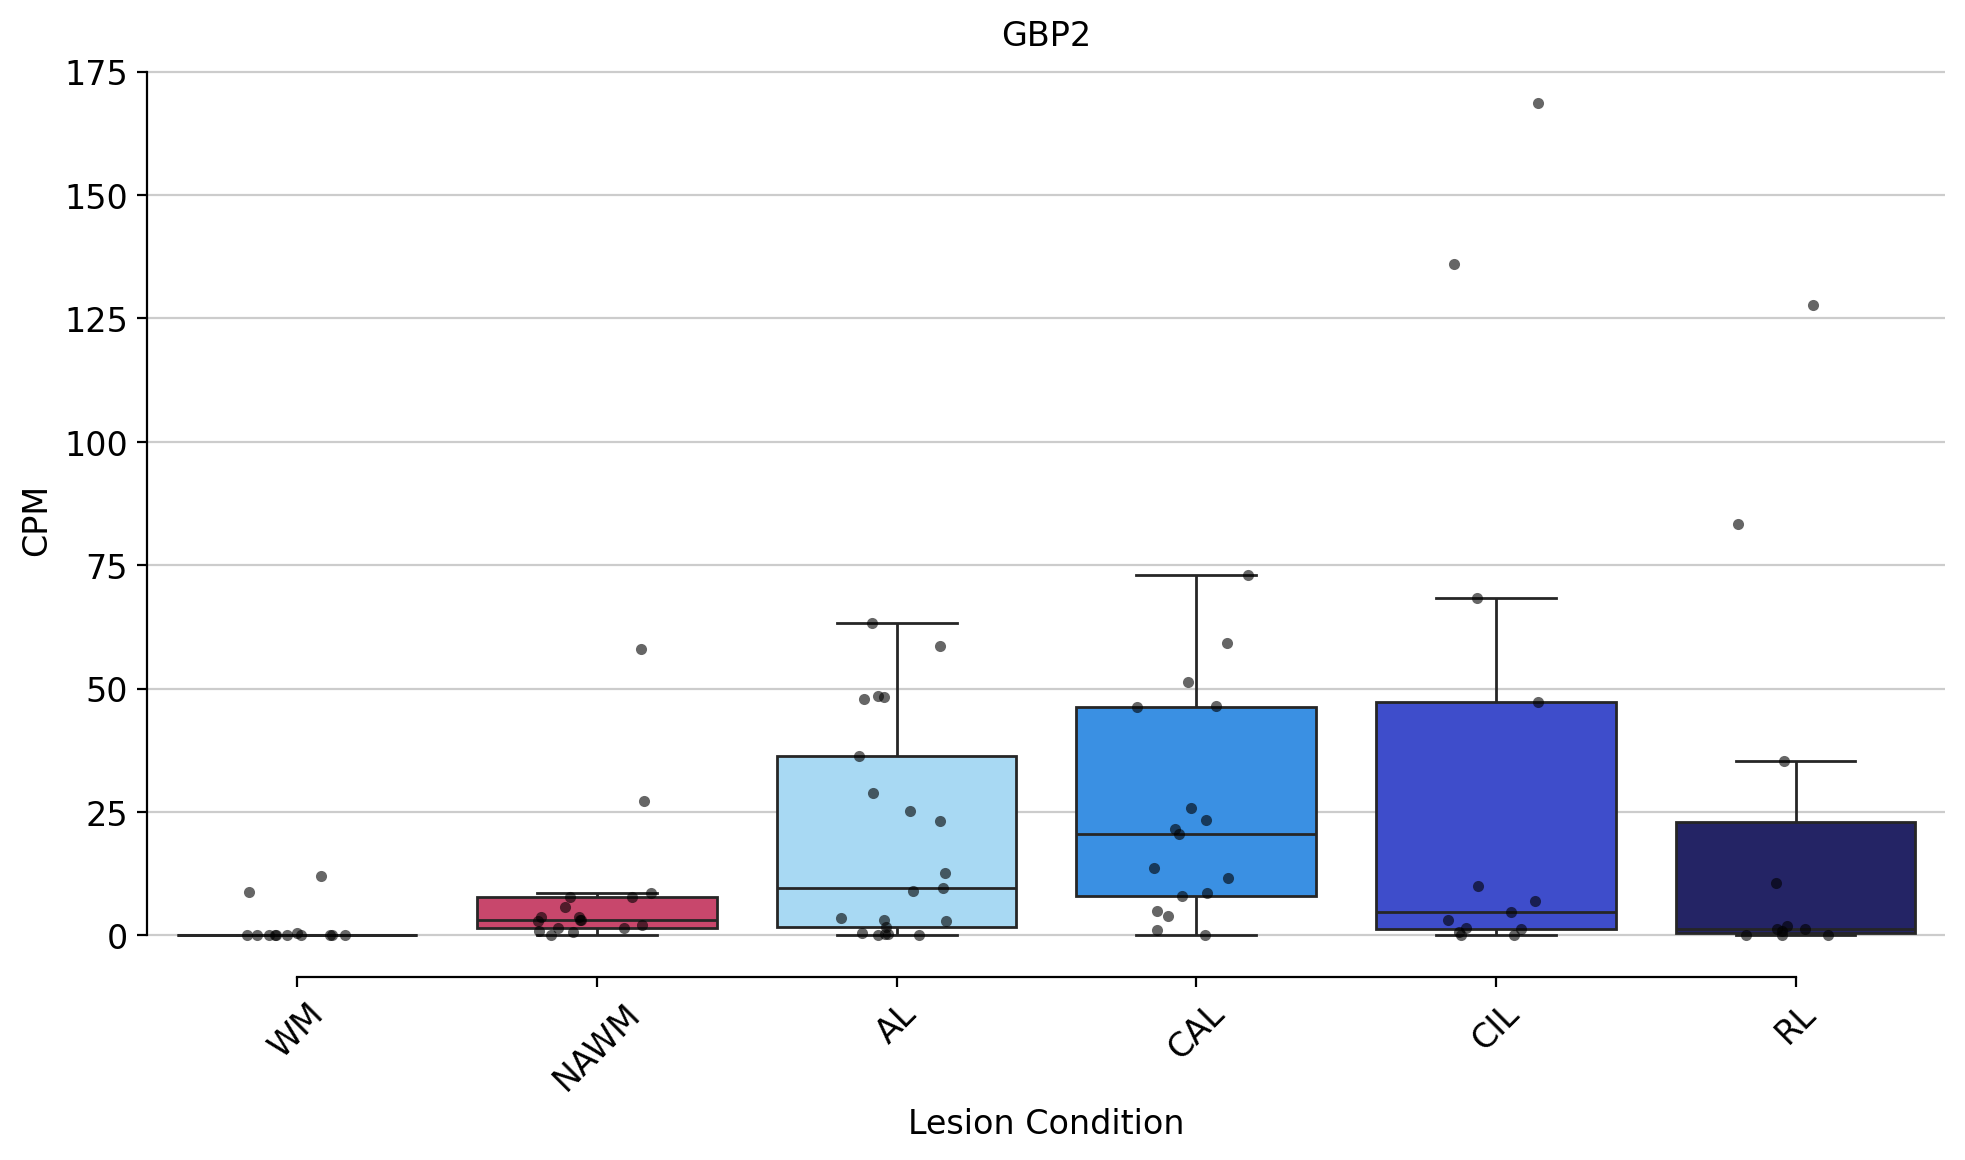

In [65]:
# Specify your gene
gene_to_plot = "GBP2"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

#df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/2168120601.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


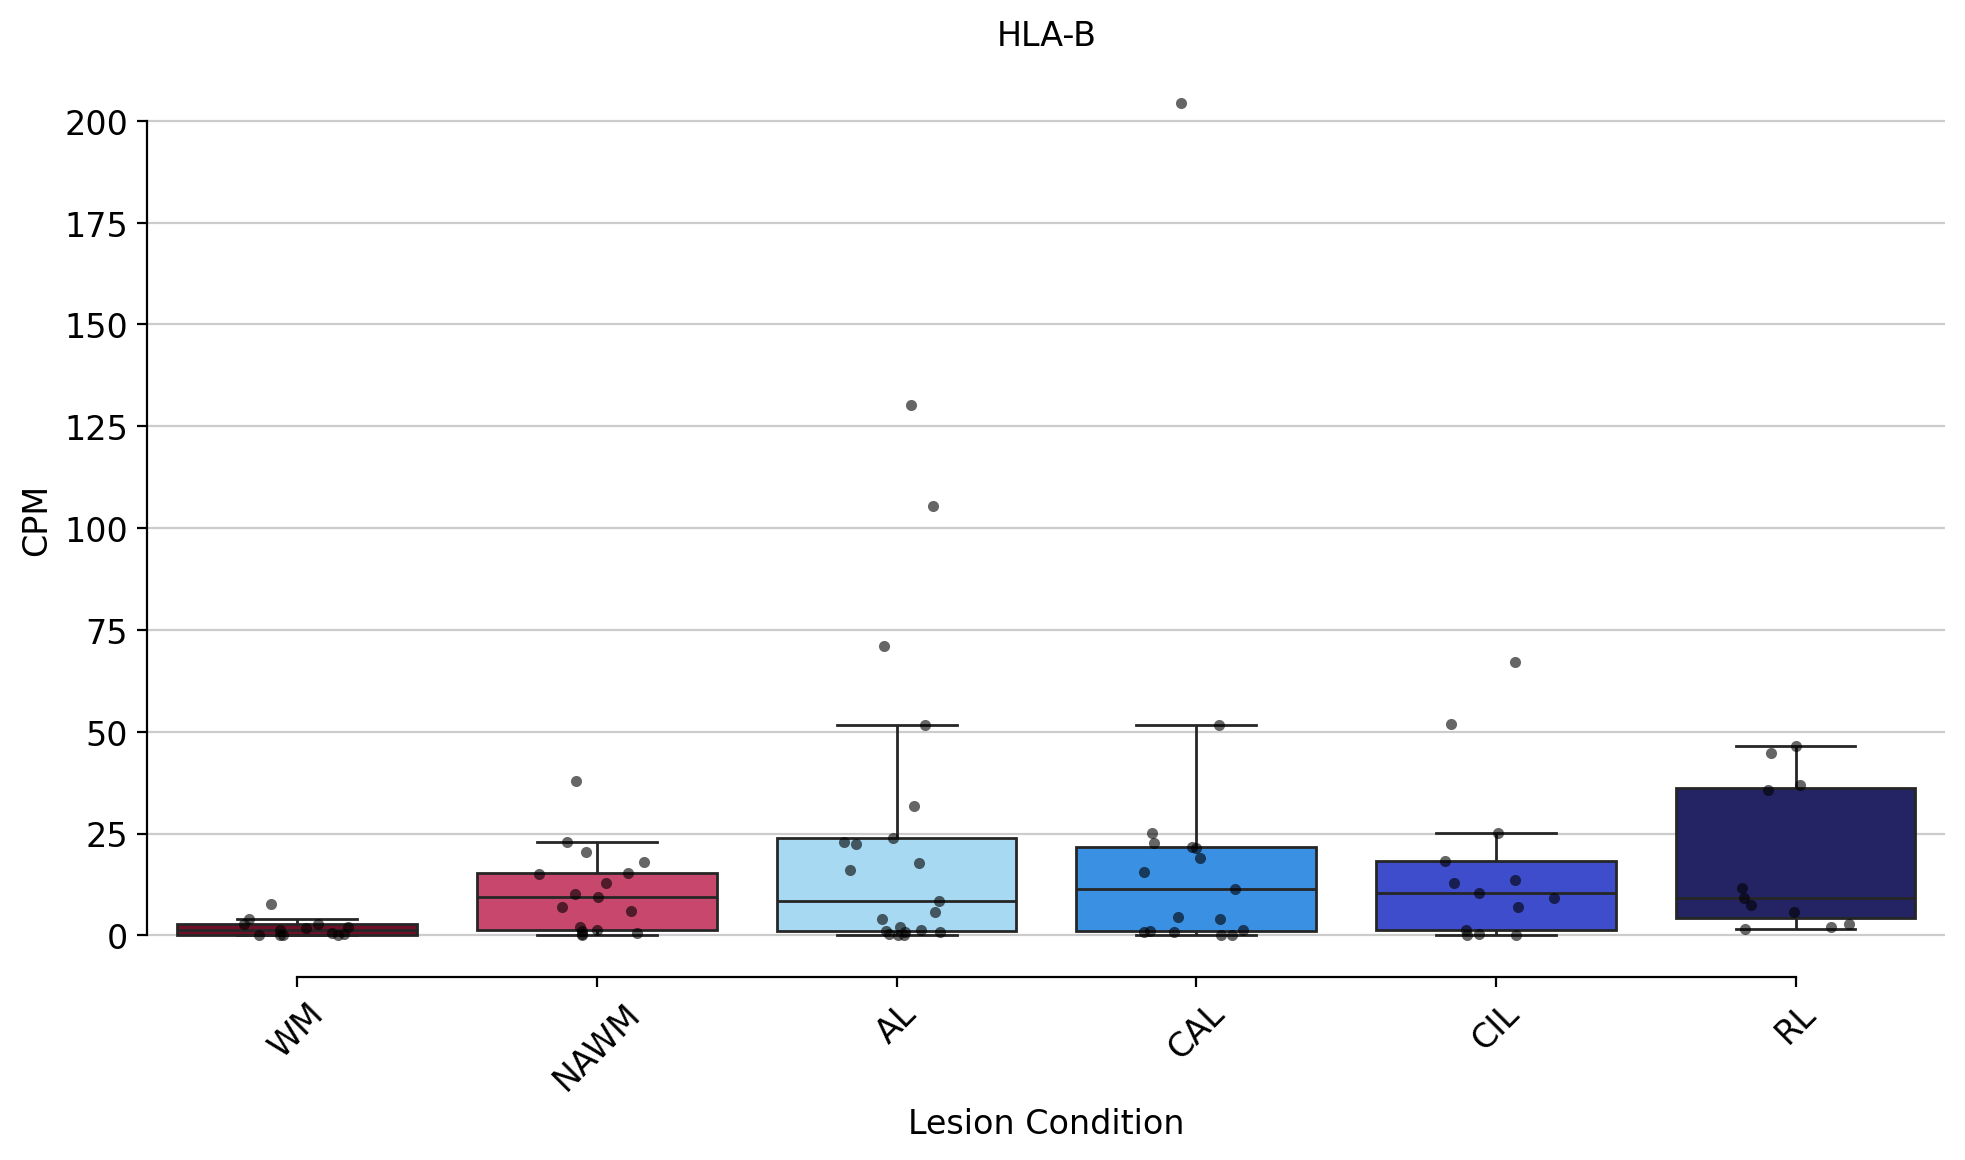

In [66]:
# Specify your gene
gene_to_plot = "HLA-B"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

#df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/1638579120.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


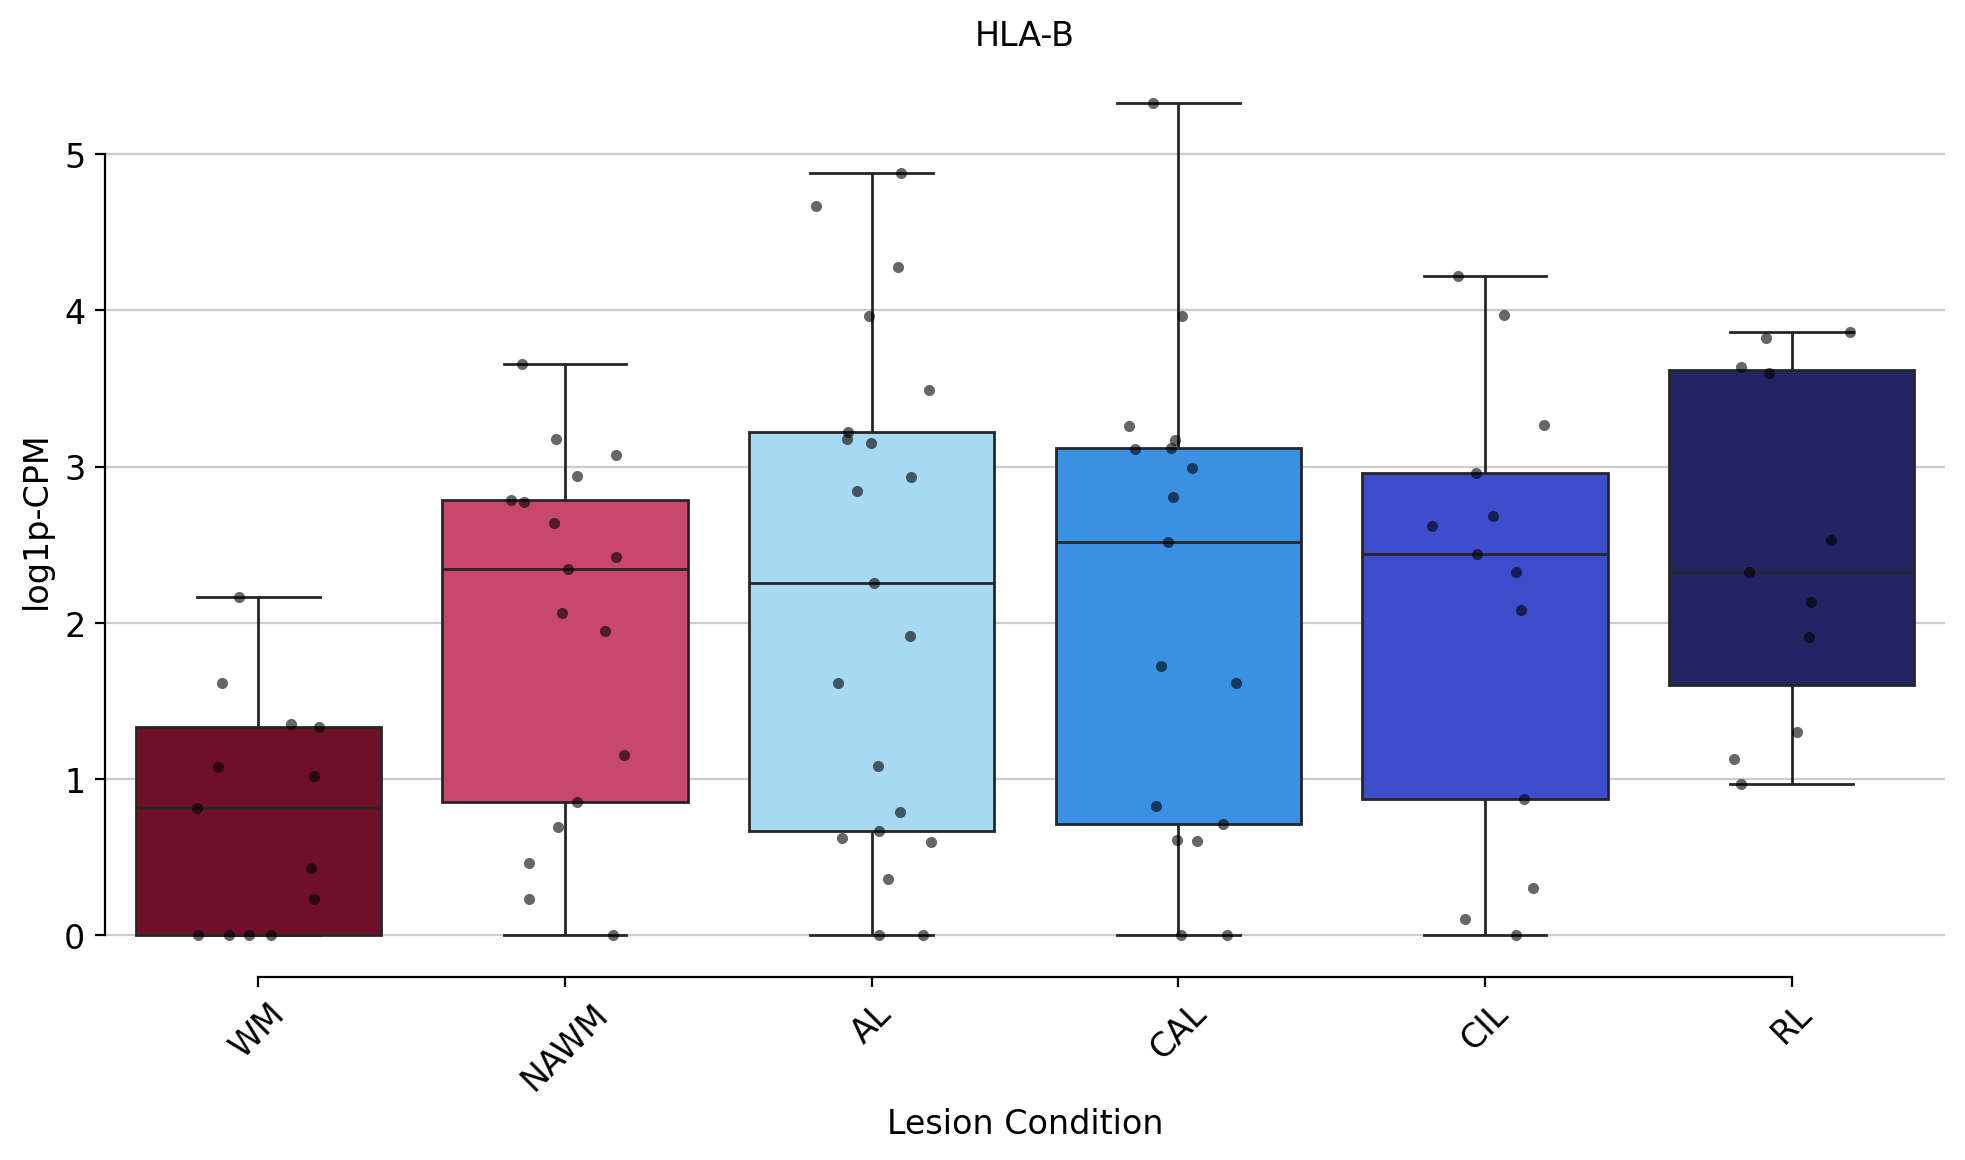

In [67]:
# Specify your gene
gene_to_plot = "HLA-B"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("log1p-CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/523333879.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


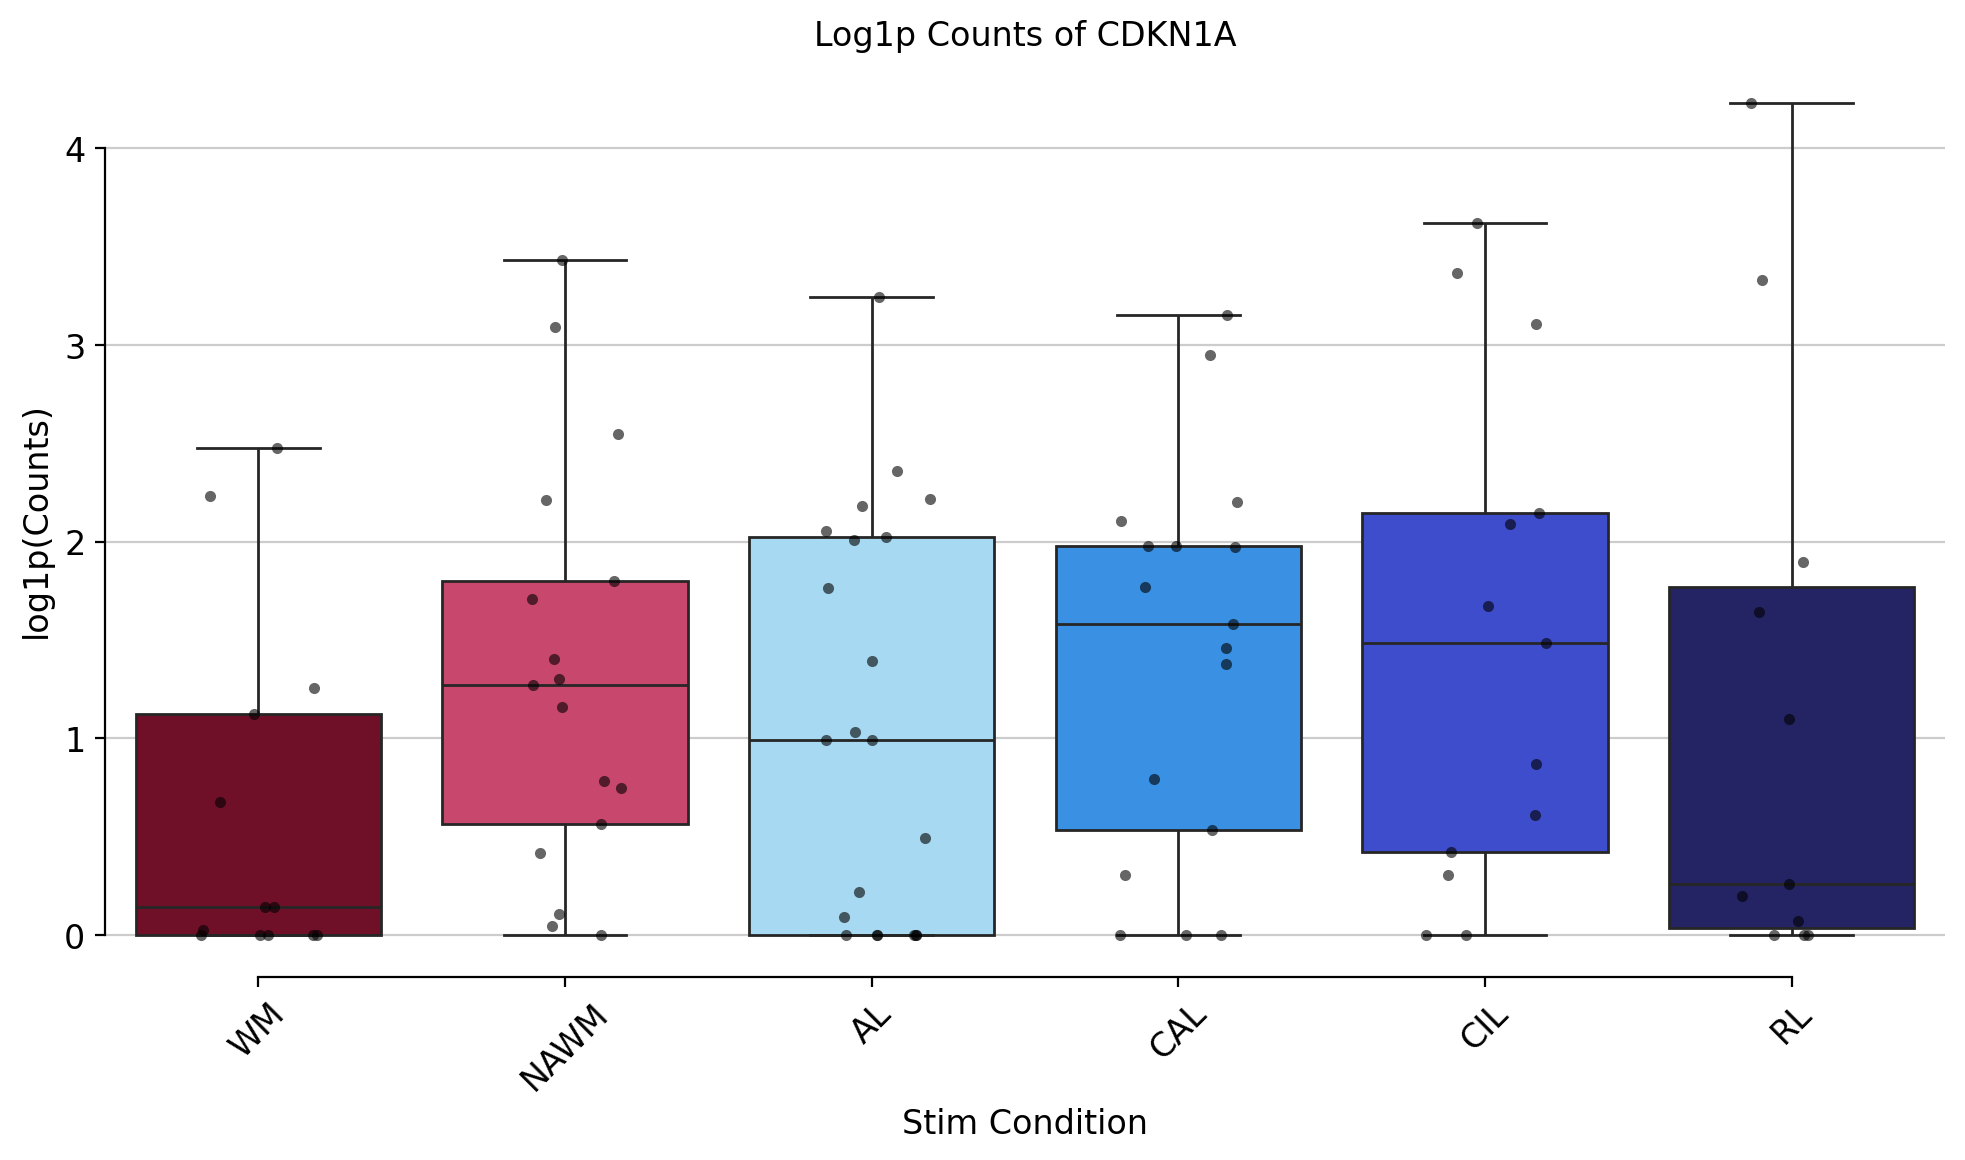

In [68]:
# Specify your gene
gene_to_plot = "CDKN1A"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"Log1p Counts of {gene_to_plot}")
plt.ylabel("log1p(Counts)")
plt.xlabel("Stim Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/3105425264.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


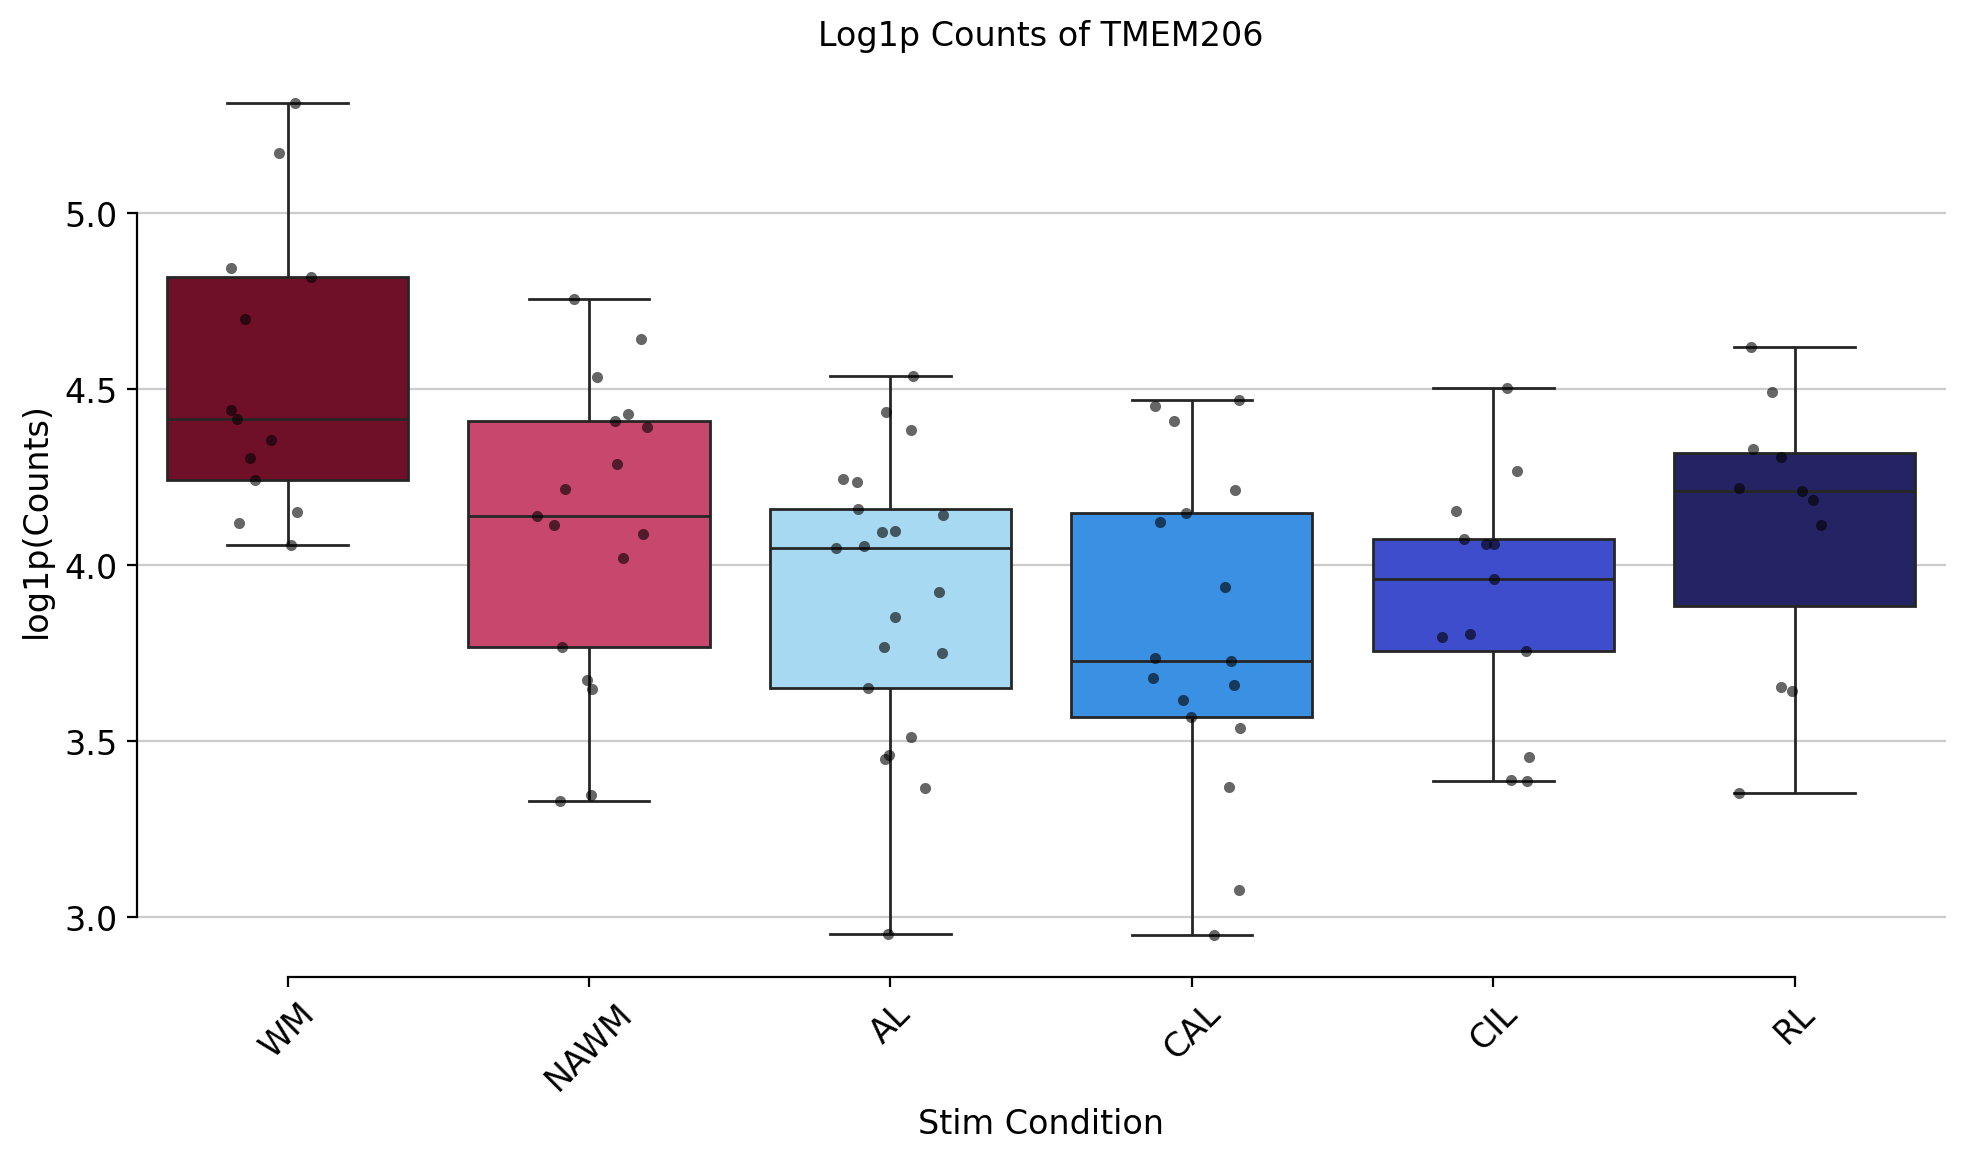

In [69]:
# Specify your gene
gene_to_plot = "TMEM206"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}


custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]


plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"Log1p Counts of {gene_to_plot}")
plt.ylabel("log1p(Counts)")
plt.xlabel("Stim Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/1237186994.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


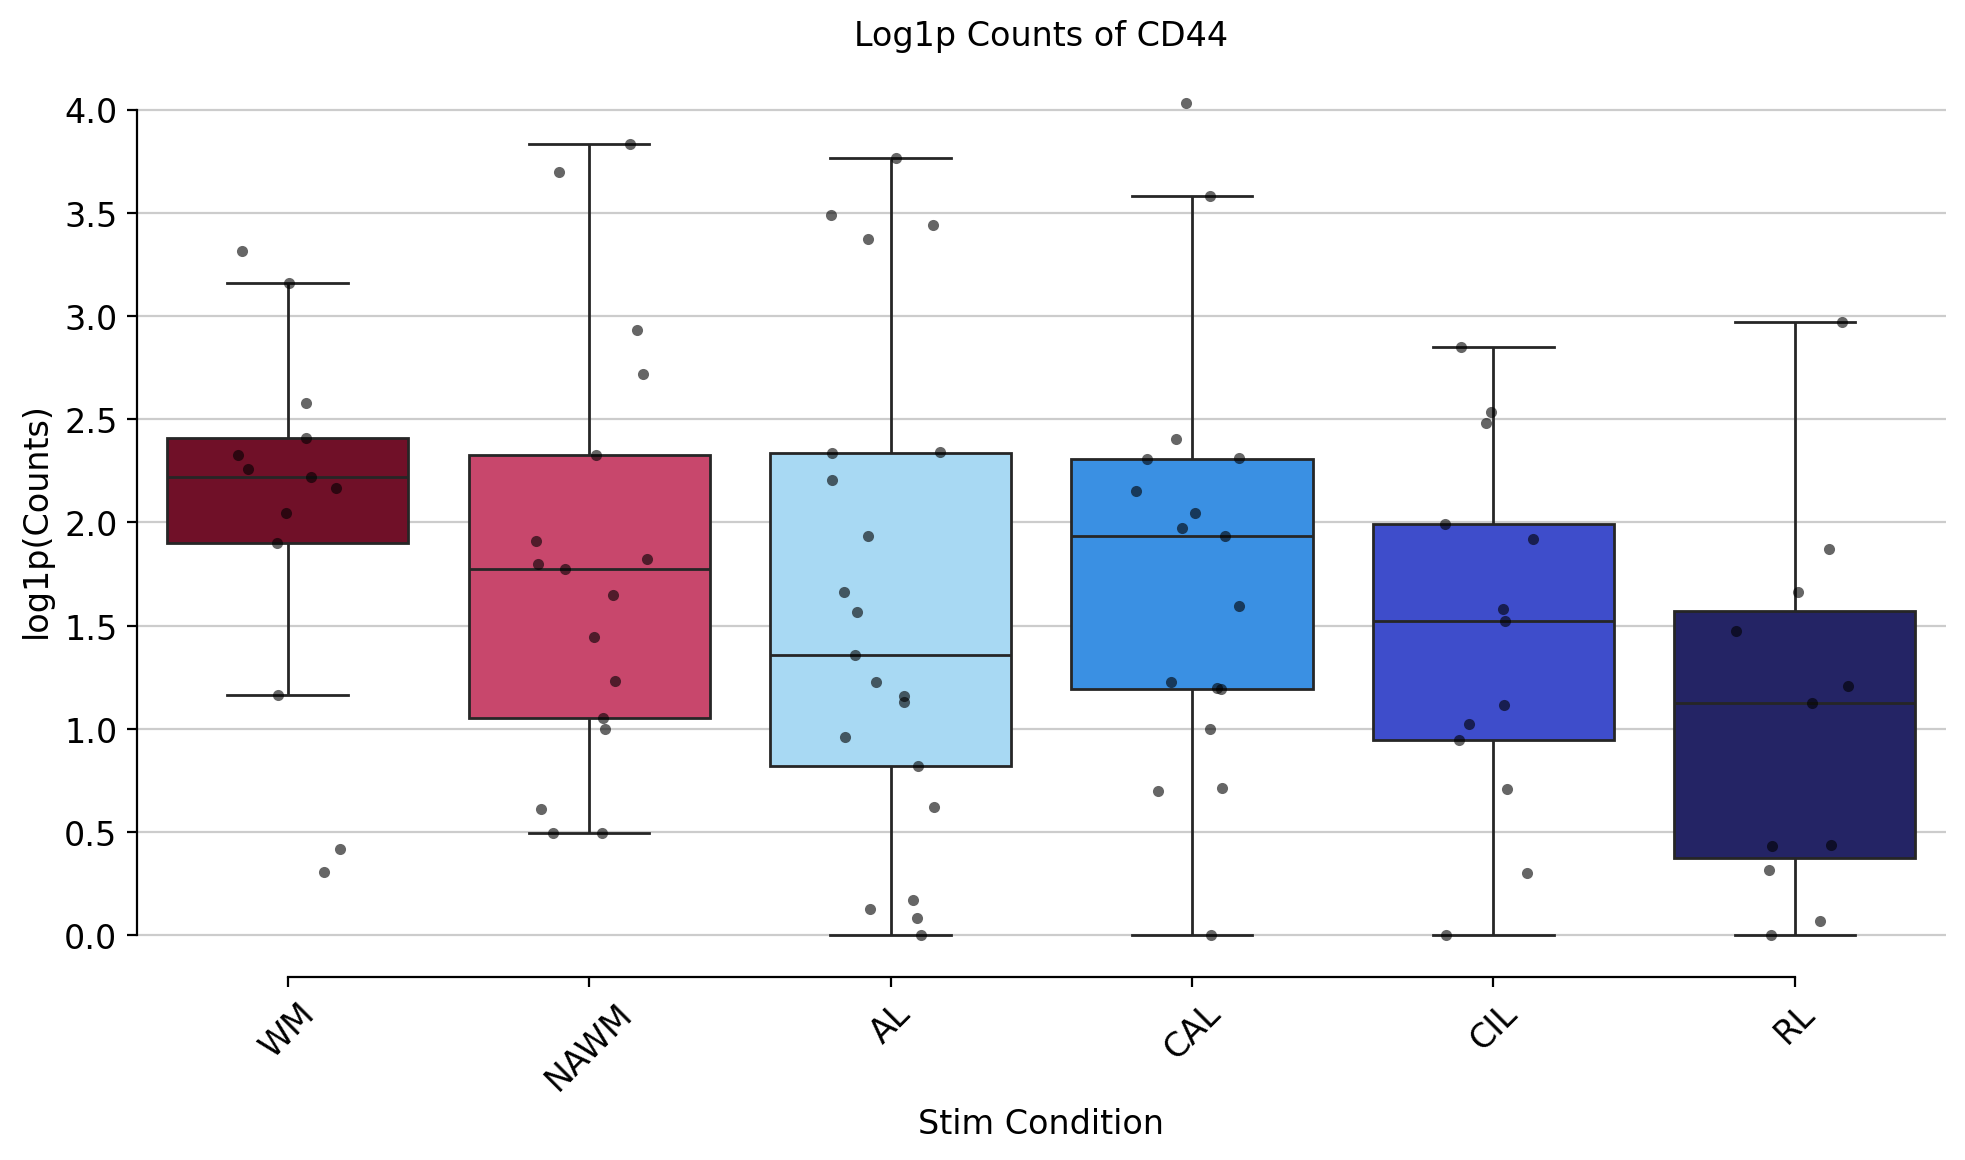

In [70]:
# Specify your gene
gene_to_plot = "CD44"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}


custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]


plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"Log1p Counts of {gene_to_plot}")
plt.ylabel("log1p(Counts)")
plt.xlabel("Stim Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/2145777215.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


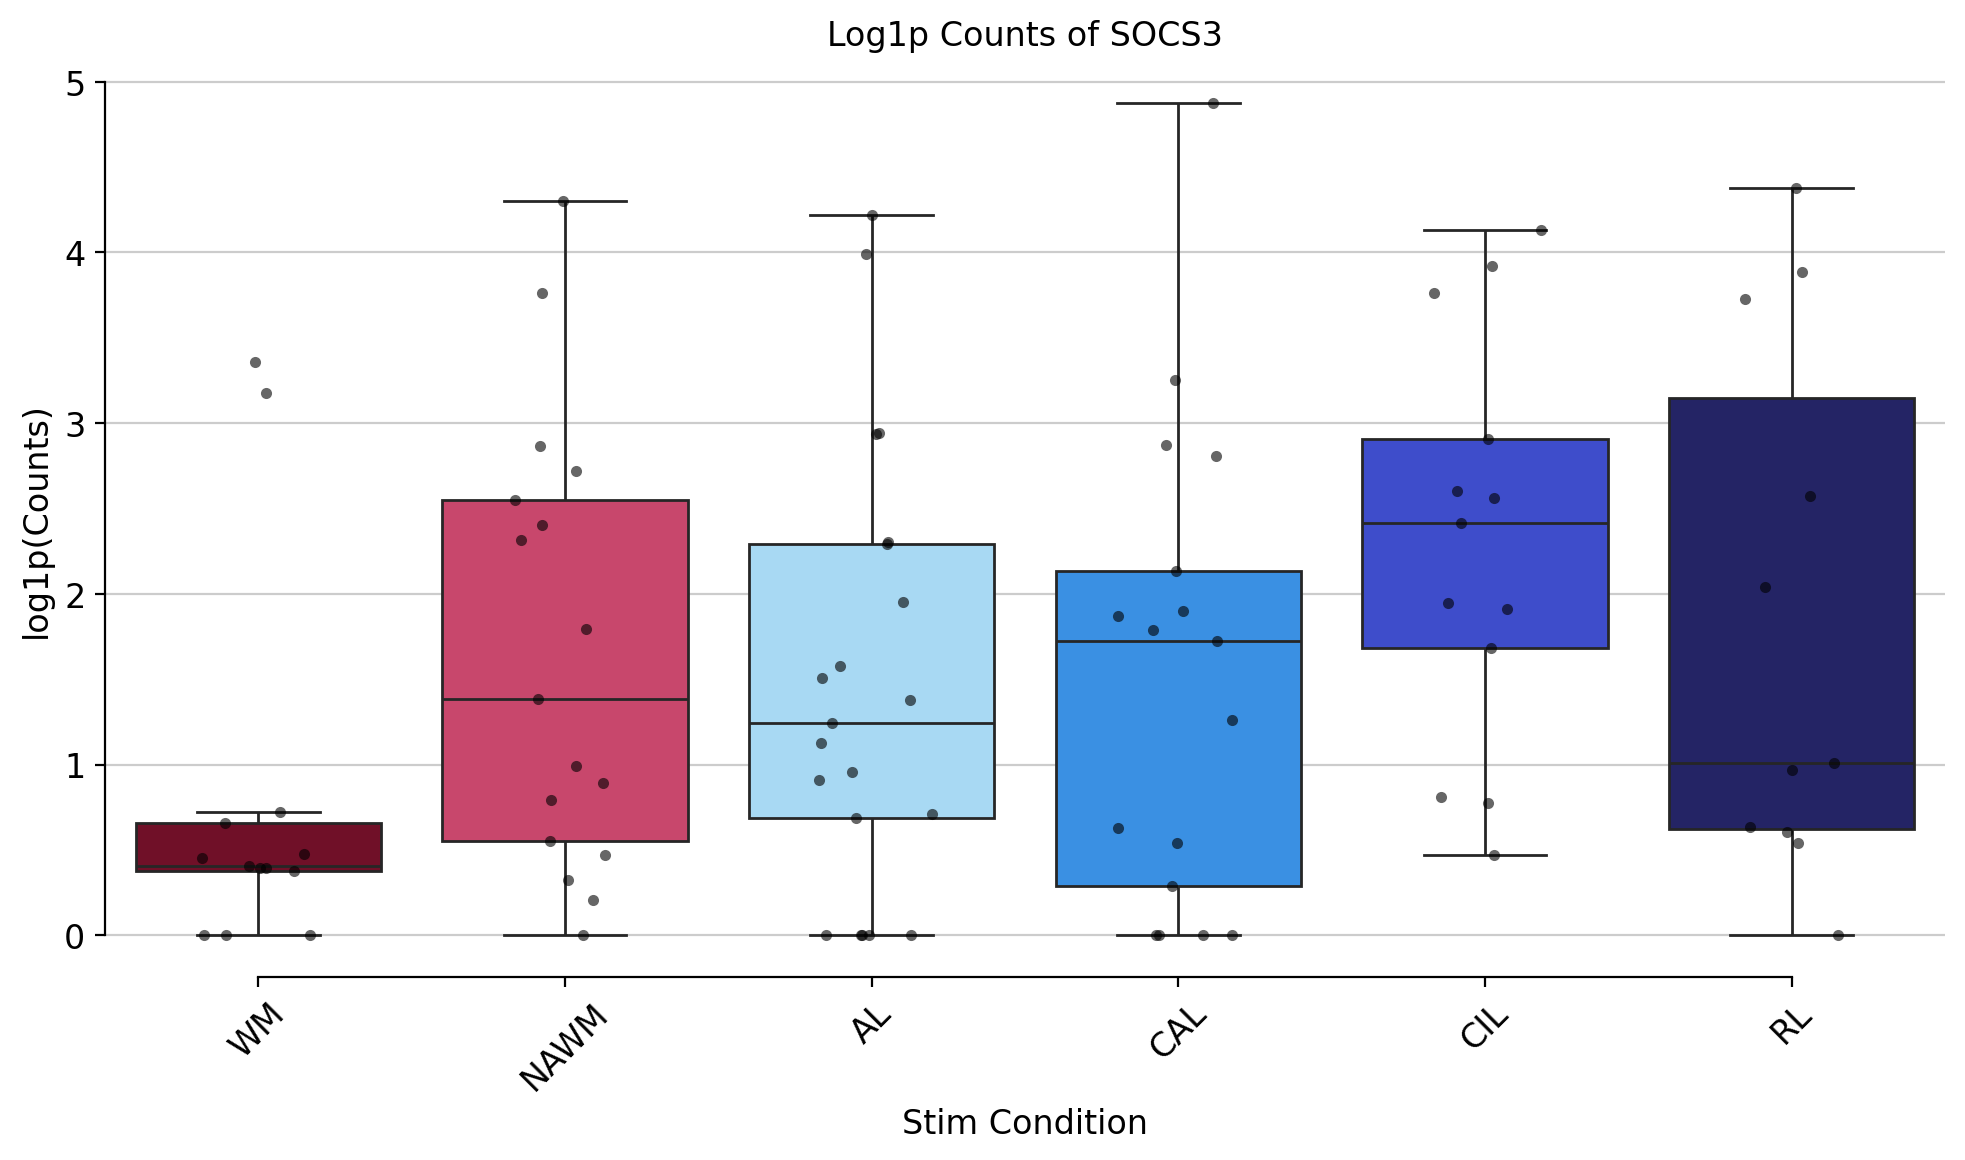

In [71]:
# Specify your gene
gene_to_plot = "SOCS3"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}


custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]


plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"Log1p Counts of {gene_to_plot}")
plt.ylabel("log1p(Counts)")
plt.xlabel("Stim Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/3022397633.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


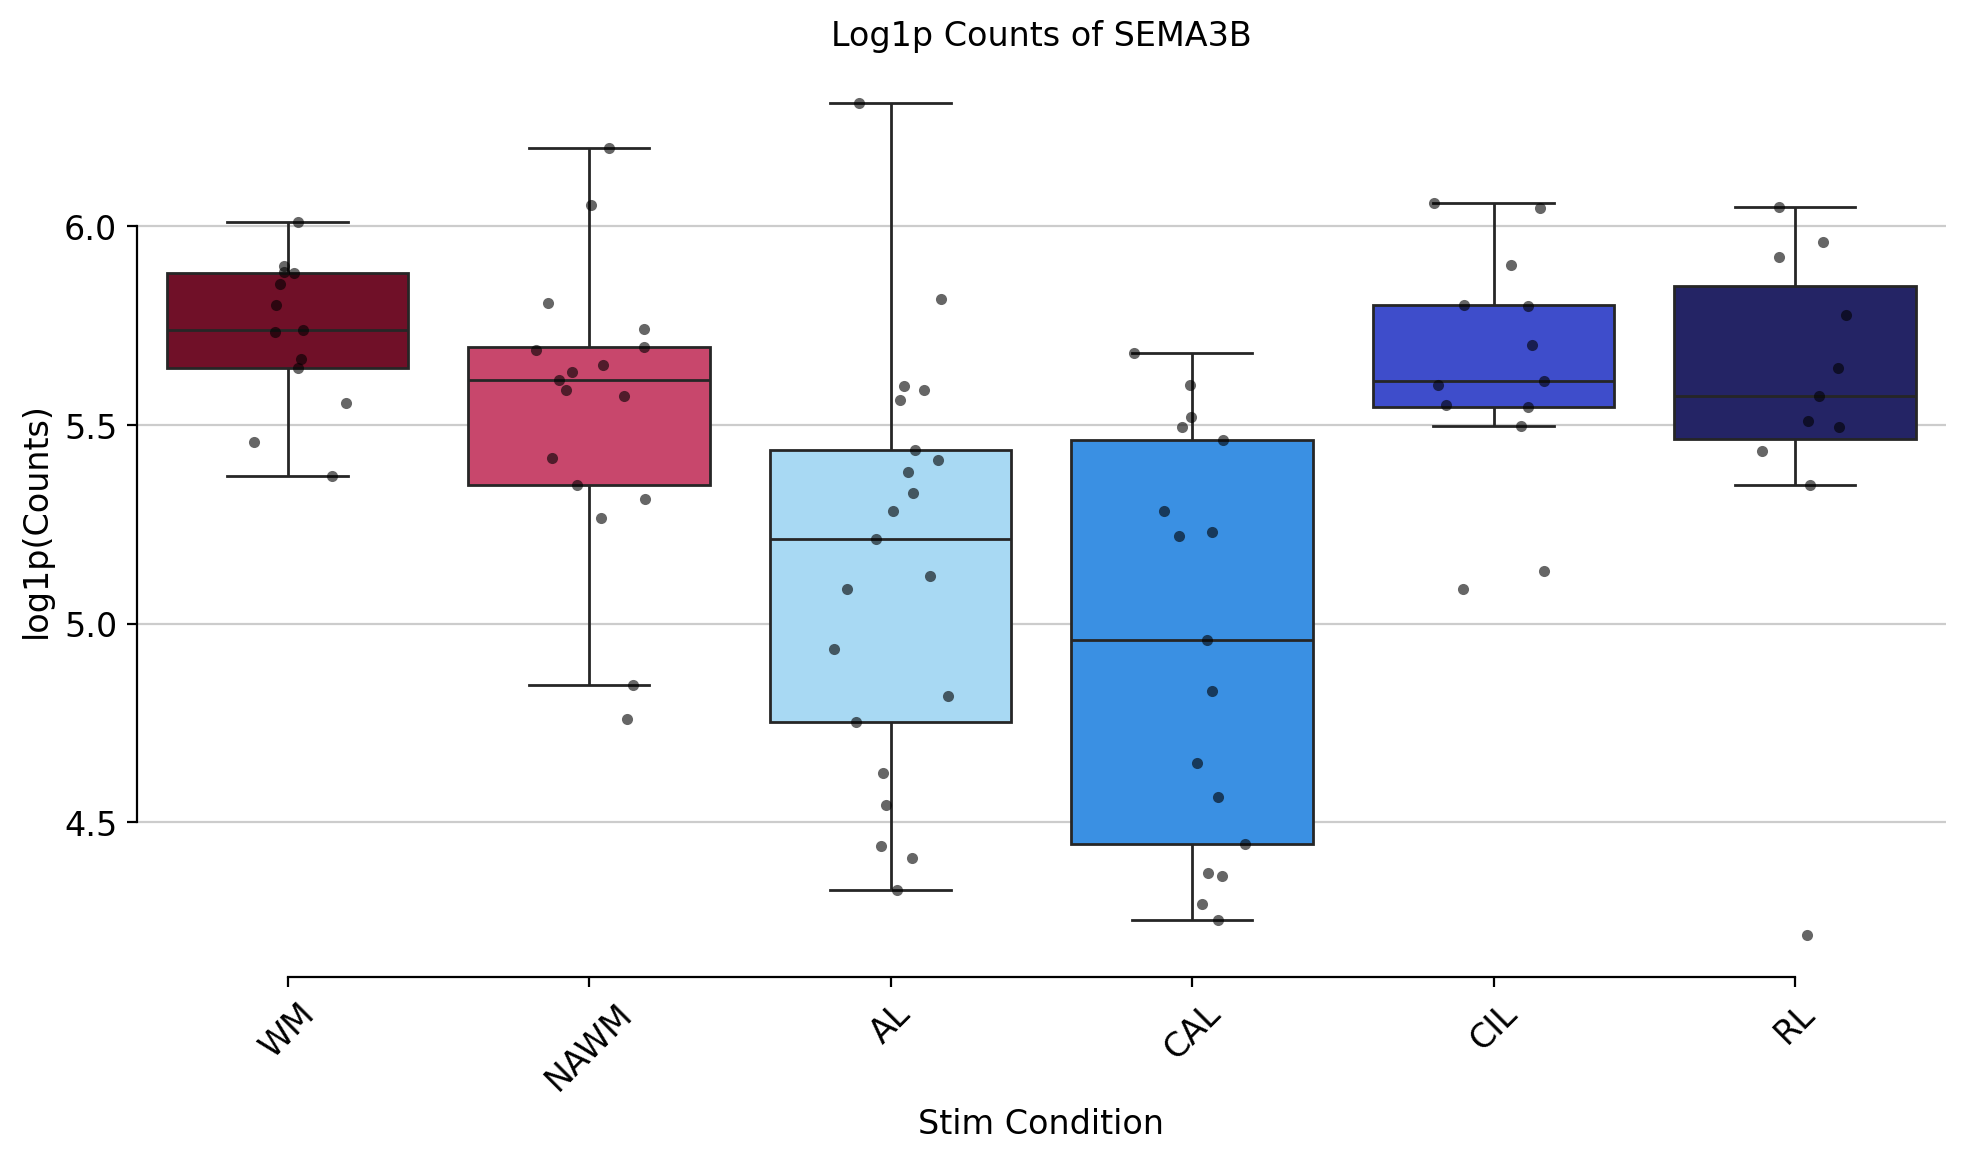

In [72]:
# Specify your gene
gene_to_plot = "SEMA3B"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}


custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]


plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"Log1p Counts of {gene_to_plot}")
plt.ylabel("log1p(Counts)")
plt.xlabel("Stim Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_866686/3056131024.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


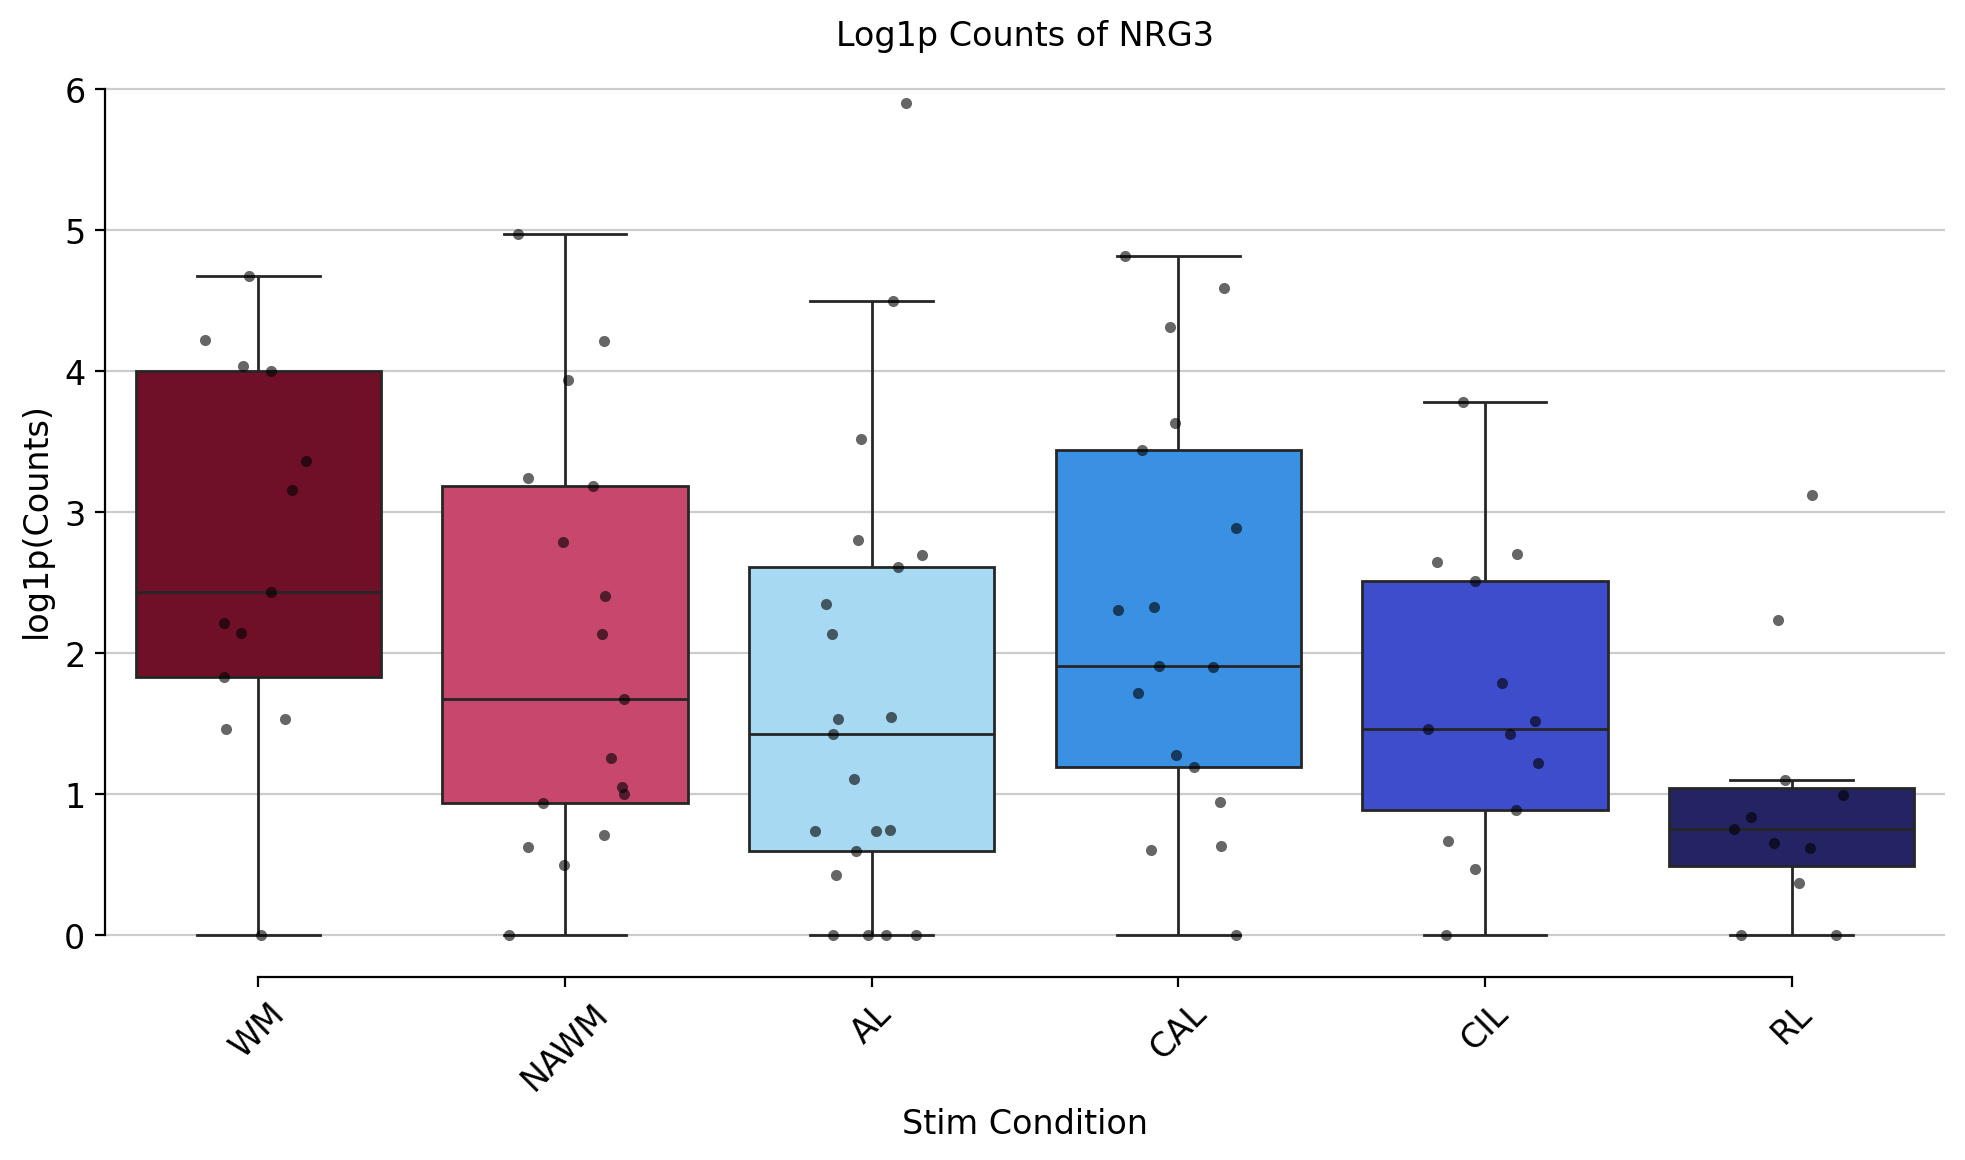

In [73]:
# Specify your gene
gene_to_plot = "NRG3"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]


plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm_log1p",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"Log1p Counts of {gene_to_plot}")
plt.ylabel("log1p(Counts)")
plt.xlabel("Stim Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

# Combine the dfs

In [74]:
# Step 1: Rename relevant columns in each DataFrame to prepare for merge
def prepare_df(df, label):
    df = df[['gene', 'logFC', 'FDR']].copy()
    df.rename(columns={
        'logFC': f'logFC_{label}',
        'FDR': f'FDR_{label}'
    }, inplace=True)
    return df

# Apply the preparation
df_NAWM = prepare_df(MOL_NAWM, 'NAWM')
df_AL   = prepare_df(MOL_AL, 'AL')
df_CAL  = prepare_df(MOL_CAL, 'CAL')
df_CIL  = prepare_df(MOL_CIL, 'CIL')
df_RL   = prepare_df(MOL_RL, 'RL')

# Step 2: Merge all dataframes on 'gene'
from functools import reduce

dfs = [df_NAWM, df_AL, df_CAL, df_CIL, df_RL]
combined_df = reduce(lambda left, right: pd.merge(left, right, on='gene', how='outer'), dfs)

# Step 3: Check the result
print(combined_df.shape)
combined_df.head()

(20002, 11)


,gene,logFC_NAWM,FDR_NAWM,logFC_AL,FDR_AL,logFC_CAL,FDR_CAL,logFC_CIL,FDR_CIL,logFC_RL,FDR_RL
0,A1BG,-0.090983,0.824757,-0.687731,0.029422,-0.731390,0.020813,NaN,NaN,-0.319742,0.353593
1,A1BG-AS1,-0.319558,0.105842,-0.679867,0.009978,-0.343471,0.327415,-0.182417,0.287844,-0.455828,0.000038
2,A2M,0.749159,0.102712,0.597304,0.459588,0.447280,0.623502,0.515834,0.296151,-0.797828,0.222829
3,A2M-AS1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.135489,0.660436
4,A2ML1,NaN,NaN,-0.114297,0.870147,-0.645531,0.244187,0.152840,0.635914,-0.081866,0.869090


In [75]:
# Before filtering: shape
print("Before filtering:", combined_df.shape)

# Identify all FDR columns
fdr_columns = [col for col in combined_df.columns if col.startswith("FDR_")]

# Create a boolean mask: True if ANY FDR column < 0.05
significant_mask = (combined_df[fdr_columns] < 0.05).any(axis=1)

# Filter the DataFrame
filtered_df = combined_df[significant_mask].copy()

# After filtering: shape
print("After filtering:", filtered_df.shape)

Before filtering: (20002, 11)
After filtering: (6144, 11)


In [76]:
filtered_df.to_csv("./files/combined_df_glmm_full_sig_genes.csv", index=False)

# Sep LPC and Cupr upset plots and new subset gene lists:

In [72]:
MOL_NAWM = pd.read_csv('./files/GLMM_full_results_with_quality_NAWMvWM_cleaned.csv', index_col=None)
MOL_NAWM.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_NAWM.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_NAWM.shape

(15298, 11)

In [73]:
MOL_AL = pd.read_csv('./files/GLMM_full_results_with_quality_ALvWM_cleaned.csv', index_col=None)
MOL_AL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_AL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_AL.shape

(14958, 11)

In [74]:
MOL_CAL = pd.read_csv('./files/GLMM_full_results_with_quality_CALvWM_cleaned.csv', index_col=None)
MOL_CAL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_CAL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_CAL.shape

(16952, 11)

In [75]:
MOL_CIL = pd.read_csv('./files/GLMM_full_results_with_quality_CILvWM_cleaned.csv', index_col=None)
MOL_CIL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_CIL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_CIL.shape

(15952, 11)

In [76]:
MOL_RL = pd.read_csv('./files/GLMM_full_results_with_quality_RLvWM_cleaned.csv', index_col=None)
MOL_RL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_RL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_RL.shape

(17208, 11)

In [77]:
MOL_NAWM['logFC'] = MOL_NAWM['logFC_WM'] * -1
#MOL_NAWM[:5]

In [78]:
MOL_AL['logFC'] = MOL_AL['logFC_WM'] * -1
#MOL_AL[:5]

In [79]:
MOL_CAL['logFC'] = MOL_CAL['logFC_WM'] * -1
#MOL_CAL[:5]

In [80]:
MOL_CIL['logFC'] = MOL_CIL['logFC_WM'] * -1
#MOL_CIL[:5]

In [81]:
MOL_RL['logFC'] = MOL_RL['logFC_WM'] * -1
#MOL_RL[:5]

## Orthos

In [30]:
# Read the CSV file
mart = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/mart_export_unique.txt')

# Rename the columns
mart = mart.rename(columns={
    'Gene stable ID': 'eid_hs',
    'Gene name': 'gene_hs',
    'Mouse gene stable ID': 'eid_mm',
    'Mouse gene name': 'gene_mm'
})

# Optionally, display the first few rows to check the data
print(mart.head())

length_of_mart = len(mart)
print(f"The length of the mart DataFrame is: {length_of_mart}")

            eid_hs  gene_hs              eid_mm  gene_mm
0  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8
The length of the mart DataFrame is: 25768


In [31]:
# One to one orthologues - dont have same mm/hs gene in the table 2x
oto_orthologues=mart[~mart.duplicated('eid_mm',keep=False).values & 
               ~mart.duplicated('eid_hs',keep=False).values]

length_of_mart = len(oto_orthologues)
print(f"The length of the mart DataFrame is: {length_of_mart}")

The length of the mart DataFrame is: 17140


In [32]:
# Optionally, display the first few rows to check the data
print(oto_orthologues.head())

            eid_hs  gene_hs              eid_mm  gene_mm
0  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8


In [33]:
MOL_NAWM

,gene,logFC_WM,se,pvalue,convergence,pdHess,logLik,AIC,error,FDR,status,logFC
0,UBE2L6,-0.547730,0.080919,1.298045e-11,0,True,-89.060841,196.121682,NaN,1.295774e-07,OK,0.547730
1,AC092070.3,-0.865827,0.130520,3.274406e-11,0,True,-71.485274,160.970548,NaN,2.179117e-07,OK,0.865827
2,COL16A1,0.843423,0.130033,8.802440e-11,0,True,-208.325904,434.651807,NaN,4.393518e-07,OK,-0.843423
3,C11orf68,-0.439477,0.068305,1.242751e-10,0,True,-131.539303,281.078606,NaN,4.962305e-07,OK,0.439477
4,TOX,-2.020419,0.316016,1.622202e-10,0,True,-121.298101,260.596202,NaN,5.397877e-07,OK,2.020419
...,...,...,...,...,...,...,...,...,...,...,...,...
15293,MMP26,-0.000149,0.190800,9.993763e-01,0,True,-83.436795,184.873590,NaN,9.998284e-01,OK,0.000149
15294,AP002336.2,-0.000076,0.178131,9.996579e-01,0,True,-176.793026,371.586052,NaN,9.998284e-01,OK,0.000076
15295,ESYT1,-0.000072,0.120009,9.995240e-01,0,True,-138.936363,295.872727,NaN,9.998284e-01,OK,0.000072
15296,EFL1,-0.000089,0.126229,9.994389e-01,0,True,-176.139957,370.279915,NaN,9.998284e-01,OK,0.000089


In [34]:
# Merge the dataframes
MOL_NAWM = MOL_NAWM.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_NAWM = MOL_NAWM[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_NAWM['logFC'] = MOL_NAWM['logFC'].astype(float)
MOL_NAWM['FDR'] = MOL_NAWM['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_NAWM['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_NAWM.shape}")
MOL_NAWM = MOL_NAWM.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_NAWM.shape}")

The number of NaN values in the 'gene_hs' column is: 5616
Shape with NaN: (15298, 5)
Shape after trimming: (9682, 5)


In [35]:
# Filter for upregulated genes
MOL_NAWM_up = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC >= 0.585)]
print(MOL_NAWM_up.shape)

# Filter for downregulated genes
MOL_NAWM_down = MOL_NAWM[(MOL_NAWM.FDR < 0.05) & (MOL_NAWM.logFC <= -0.585)]
print(MOL_NAWM_down.shape)

(153, 5)
(52, 5)


In [36]:
# Merge the dataframes
MOL_AL = MOL_AL.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_AL = MOL_AL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_AL['logFC'] = MOL_AL['logFC'].astype(float)
MOL_AL['FDR'] = MOL_AL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_AL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_AL.shape}")
MOL_AL = MOL_AL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_AL.shape}")

The number of NaN values in the 'gene_hs' column is: 4644
Shape with NaN: (14958, 5)
Shape after trimming: (10314, 5)


In [37]:
MOL_AL

,gene,gene_hs,gene_mm,logFC,FDR
0,FGFRL1,FGFRL1,Fgfrl1,-1.173870,1.210526e-12
1,WRAP53,WRAP53,Wrap53,0.601708,2.492331e-11
2,SGCZ,SGCZ,Sgcz,3.275377,8.484408e-11
3,GPRIN3,GPRIN3,Gprin3,3.958724,1.209826e-10
4,PTPDC1,PTPDC1,Ptpdc1,-0.608637,1.875656e-10
...,...,...,...,...,...
14951,SEC22C,SEC22C,Sec22c,-0.000040,9.997897e-01
14953,RPS5,RPS5,Rps5,0.000116,9.997897e-01
14954,CDK5R1,CDK5R1,Cdk5r1,0.000060,9.999350e-01
14955,RAB22A,RAB22A,Rab22a,0.000006,9.999393e-01


In [38]:
# Filter for upregulated genes
MOL_AL_up = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC >= 0.585)]
print(MOL_AL_up.shape)

# Filter for downregulated genes
MOL_AL_down = MOL_AL[(MOL_AL.FDR < 0.05) & (MOL_AL.logFC <= -0.585)]
print(MOL_AL_down.shape)

(331, 5)
(256, 5)


In [39]:
Cd44_row = MOL_AL[MOL_AL['gene'] == 'CD44']
print(Cd44_row)

      gene gene_hs gene_mm     logFC       FDR
5886  CD44    CD44    Cd44 -0.876658  0.340323


In [40]:
Snx10_row = MOL_AL[MOL_AL['gene'] == 'SNX10']
print(Snx10_row)

        gene gene_hs gene_mm     logFC       FDR
14531  SNX10   SNX10   Snx10 -0.031811  0.977515


In [41]:
# Merge the dataframes
MOL_CAL = MOL_CAL.merge(
    oto_orthologues,
    left_on='gene',
    right_on='gene_hs',
    how='left'
)

# Select only the desired columns and rename if necessary
MOL_CAL = MOL_CAL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_CAL['logFC'] = MOL_CAL['logFC'].astype(float)
MOL_CAL['FDR'] = MOL_CAL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_CAL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_CAL.shape}")
MOL_CAL = MOL_CAL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_CAL.shape}")

# Filter for upregulated genes
MOL_CAL_up = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC >= 0.585)]
print(MOL_CAL_up.shape)

# Filter for downregulated genes
MOL_CAL_down = MOL_CAL[(MOL_CAL.FDR < 0.05) & (MOL_CAL.logFC <= -0.585)]
print(MOL_CAL_down.shape)

The number of NaN values in the 'gene_hs' column is: 5583
Shape with NaN: (16952, 5)
Shape after trimming: (11369, 5)
(450, 5)
(485, 5)


In [42]:
# Merge the dataframes
MOL_CIL = MOL_CIL.merge(
    oto_orthologues,
    left_on='gene',
    right_on='gene_hs',
    how='left'
)

# Select only the desired columns and rename if necessary
MOL_CIL = MOL_CIL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_CIL['logFC'] = MOL_CIL['logFC'].astype(float)
MOL_CIL['FDR'] = MOL_CIL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_CIL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_CIL.shape}")
MOL_CIL = MOL_CIL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_CIL.shape}")

# Filter for upregulated genes
MOL_CIL_up = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC >= 0.585)]
print(MOL_CIL_up.shape)

# Filter for downregulated genes
MOL_CIL_down = MOL_CIL[(MOL_CIL.FDR < 0.05) & (MOL_CIL.logFC <= -0.585)]
print(MOL_CIL_down.shape)

The number of NaN values in the 'gene_hs' column is: 5196
Shape with NaN: (15952, 5)
Shape after trimming: (10756, 5)
(352, 5)
(240, 5)


In [43]:
# Merge the dataframes
MOL_RL = MOL_RL.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_RL = MOL_RL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'FDR']]
MOL_RL['logFC'] = MOL_RL['logFC'].astype(float)
MOL_RL['FDR'] = MOL_RL['FDR'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_RL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_RL.shape}")
MOL_RL = MOL_RL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_RL.shape}")

The number of NaN values in the 'gene_hs' column is: 5885
Shape with NaN: (17208, 5)
Shape after trimming: (11323, 5)


In [44]:
# Filter for upregulated genes
MOL_RL_up = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC >= 0.585)]
print(MOL_RL_up.shape)

# Filter for downregulated genes
MOL_RL_down = MOL_RL[(MOL_RL.FDR < 0.05) & (MOL_RL.logFC <= -0.585)]
print(MOL_RL_down.shape)

(299, 5)
(362, 5)


## Mouse-- ON MOL ALL PSEUDOBULKED

In [45]:
LPC_demyel = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS/files/LPC_demyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
LPC_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_demyel.shape

(11516, 7)

In [46]:
LPC_remyel = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS/files/LPC_remyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
LPC_remyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_remyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_remyel.shape

(13049, 7)

In [47]:
Cupr_demyel = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS/files/Cupr_demyel_MOL_all_voom_wqw_UPDATED.csv', index_col=None)
Cupr_demyel.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
Cupr_demyel.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
Cupr_demyel.shape

(10536, 7)

In [48]:
Cd44_row = Cupr_demyel[Cupr_demyel['gene'] == 'Cd44']
print(Cd44_row)

    gene     logFC  AveExpr          t        Pvalue          Padj          B
49  Cd44  6.036805  2.83632  16.929162  2.754460e-10  5.804199e-08  14.117064


In [49]:
# Merge the dataframes
LPC_demyel = LPC_demyel.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
LPC_demyel = LPC_demyel[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 'Padj']]
LPC_demyel['logFC'] = LPC_demyel['logFC'].astype(float)
LPC_demyel['Padj'] = LPC_demyel['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = LPC_demyel['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {LPC_demyel.shape}")
LPC_demyel = LPC_demyel.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {LPC_demyel.shape}")

The number of NaN values in the 'gene_hs' column is: 2055
Shape with NaN: (11517, 6)
Shape after trimming: (9462, 6)


In [50]:
# Filter for upregulated genes
LPC_demyel_up = LPC_demyel[(LPC_demyel.Padj < 0.05) & (LPC_demyel.logFC >= 0.585)]
print(LPC_demyel_up.shape)

# Filter for downregulated genes
LPC_demyel_down = LPC_demyel[(LPC_demyel.Padj < 0.05) & (LPC_demyel.logFC <= -0.585)]
print(LPC_demyel_down.shape)

(455, 6)
(286, 6)


In [51]:
Snx10_row = LPC_demyel[LPC_demyel['gene'] == 'Snx10']
print(Snx10_row)

     gene gene_hs gene_mm     logFC   AveExpr      Padj
32  Snx10   SNX10   Snx10  3.919275  1.268274  0.000002


In [52]:
# Merge the dataframes
LPC_remyel = LPC_remyel.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
LPC_remyel = LPC_remyel[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 'Padj']]
LPC_remyel['logFC'] = LPC_remyel['logFC'].astype(float)
LPC_remyel['Padj'] = LPC_remyel['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = LPC_remyel['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {LPC_remyel.shape}")
LPC_remyel = LPC_remyel.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {LPC_remyel.shape}")

The number of NaN values in the 'gene_hs' column is: 2725
Shape with NaN: (13050, 6)
Shape after trimming: (10325, 6)


In [53]:
LPC_remyel

,gene,gene_hs,gene_mm,logFC,AveExpr,Padj
2,Cebpd,CEBPD,Cebpd,3.020384,4.685682,0.000029
3,Socs3,SOCS3,Socs3,6.146866,3.596850,0.000037
4,Anxa2,ANXA2,Anxa2,5.593694,3.502627,0.000037
5,Flnc,FLNC,Flnc,3.082891,3.099683,0.000037
6,Lhfpl3,LHFPL3,Lhfpl3,2.605391,4.313963,0.000037
...,...,...,...,...,...,...
13043,Zfp516,ZNF516,Zfp516,0.000113,1.754832,0.999982
13045,Rad51,RAD51,Rad51,0.000107,1.405674,0.999982
13046,Cfap36,CFAP36,Cfap36,-0.000024,6.278399,0.999982
13048,Hacd3,HACD3,Hacd3,0.000006,5.208104,0.999982


In [54]:
# Filter for upregulated genes
LPC_remyel_up = LPC_remyel[(LPC_remyel.Padj < 0.05) & (LPC_remyel.logFC >= 0.585)]
print(LPC_remyel_up.shape)

# Filter for downregulated genes
LPC_remyel_down = LPC_remyel[(LPC_remyel.Padj < 0.05) & (LPC_remyel.logFC <= -0.585)]
print(LPC_remyel_down.shape)

(455, 6)
(343, 6)


In [55]:
Snx10_row = LPC_remyel[LPC_remyel['gene'] == 'Snx10']
print(Snx10_row)

     gene gene_hs gene_mm     logFC   AveExpr      Padj
43  Snx10   SNX10   Snx10  5.360626  2.749042  0.000462


In [56]:
# Merge the dataframes
Cupr_demyel = Cupr_demyel.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
Cupr_demyel = Cupr_demyel[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 'Padj']]
Cupr_demyel['logFC'] = Cupr_demyel['logFC'].astype(float)
Cupr_demyel['Padj'] = Cupr_demyel['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = Cupr_demyel['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {Cupr_demyel.shape}")
Cupr_demyel = Cupr_demyel.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {Cupr_demyel.shape}")

The number of NaN values in the 'gene_hs' column is: 1567
Shape with NaN: (10537, 6)
Shape after trimming: (8970, 6)


In [57]:
Cd44_row = Cupr_demyel[Cupr_demyel['gene'] == 'Cd44']
print(Cd44_row)

    gene gene_hs gene_mm     logFC  AveExpr          Padj
49  Cd44    CD44    Cd44  6.036805  2.83632  5.804199e-08


In [58]:
print(Cupr_demyel.dtypes)

gene        object
gene_hs     object
gene_mm     object
logFC      float64
AveExpr    float64
Padj       float64
dtype: object


In [59]:
Cupr_demyel['logFC'] = Cupr_demyel['logFC'].astype(float)
Cupr_demyel['Padj'] = Cupr_demyel['Padj'].astype(float)

In [60]:
# Filter for upregulated genes
Cupr_demyel_up = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC >= 0.585)]
print(Cupr_demyel_up.shape)

# Filter for downregulated genes
Cupr_demyel_down = Cupr_demyel[(Cupr_demyel.Padj < 0.05) & (Cupr_demyel.logFC <= -0.585)]
print(Cupr_demyel_down.shape)

(2047, 6)
(1528, 6)


In [61]:
Cd44_row = Cupr_demyel[Cupr_demyel['gene'] == 'Cd44']
print(Cd44_row)

    gene gene_hs gene_mm     logFC  AveExpr          Padj
49  Cd44    CD44    Cd44  6.036805  2.83632  5.804199e-08


# JACCARD?

In [62]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import pertpy as pt
import scanpy as sc
import numpy as np
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

from matplotlib.colors import TwoSlopeNorm

import itertools
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

plt.rcParams["figure.figsize"] = (7, 7)
import numpy as np

sc.settings.verbosity = 3


#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

## Define color palette
pal = sb.color_palette('Paired').as_hex()
design_palette = {'ACR':pal[3], 'CR':pal[7], 'AR':pal[9], 'joint_CR':pal[6]}
design_palette_df = pd.DataFrame(design_palette.values(), index =design_palette.keys() )
design_palette_df.columns = ['color']

import os,sys

figdir = './figures/'
if not os.path.exists(figdir):
    os.mkdir(figdir)
sc.settings.figdir = figdir

In [63]:
%%R
library(tidyverse)
library(reshape2)
library(patchwork)
library(ggrastr)
library(shadowtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(forcats)
library(data.table)

remove_x_axis <- function(){
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())  
}

remove_y_axis <- function(){
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title.y = element_blank())  
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths

data.table 1.16.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:reshape2’:

    dcast, melt

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



## Similarity scores

In [64]:
MOL_NAWM

,gene,gene_hs,gene_mm,logFC,FDR
0,UBE2L6,UBE2L6,Ube2l6,0.547730,1.295774e-07
2,COL16A1,COL16A1,Col16a1,-0.843423,4.393518e-07
3,C11orf68,C11orf68,AI837181,0.439477,4.962305e-07
4,TOX,TOX,Tox,2.020419,5.397877e-07
5,GPR160,GPR160,Gpr160,0.656100,6.322579e-07
...,...,...,...,...,...
15285,CDH2,CDH2,Cdh2,-0.000224,9.997298e-01
15289,TCP11L2,TCP11L2,Tcp11l2,0.000082,9.997685e-01
15295,ESYT1,ESYT1,Esyt1,0.000072,9.998284e-01
15296,EFL1,EFL1,Efl1,0.000089,9.998284e-01


In [65]:
dfs = {
    "MOL_NAWM": MOL_NAWM,
    "MOL_AL": MOL_AL,
    "MOL_CAL": MOL_CAL,
    "MOL_CIL": MOL_CIL,
    "MOL_RL": MOL_RL,
    "LPC_demyel": LPC_demyel,
    "LPC_remyel": LPC_remyel,
    "Cupr_demyel": Cupr_demyel
}

# --- thresholds ---
alpha = 0.05
lfc_up = 0.585
lfc_down = -0.585

# --- helper to find adjusted-p column automatically ---
def get_p_col(df):
    for c in ["Padj", "FDR", "adj.P.Val", "qval"]:
        if c in df.columns:
            return c
    raise ValueError(f"No adjusted p-value column found in {df.columns}")

# --- apply classification ---
for name, df in dfs.items():
    p_col = get_p_col(df)
    df["direction"] = "ns"  # default not significant
    
    df.loc[(df["logFC"] >= lfc_up) & (df[p_col] < alpha), "direction"] = "up"
    df.loc[(df["logFC"] <= lfc_down) & (df[p_col] < alpha), "direction"] = "down"
    
    print(f"{name}: up={sum(df['direction']=='up')}, down={sum(df['direction']=='down')}, ns={sum(df['direction']=='ns')}")

MOL_NAWM: up=153, down=52, ns=9477
MOL_AL: up=331, down=256, ns=9727
MOL_CAL: up=450, down=485, ns=10434
MOL_CIL: up=352, down=240, ns=10164
MOL_RL: up=299, down=362, ns=10662
LPC_demyel: up=455, down=286, ns=8721
LPC_remyel: up=455, down=343, ns=9527
Cupr_demyel: up=2047, down=1528, ns=5395


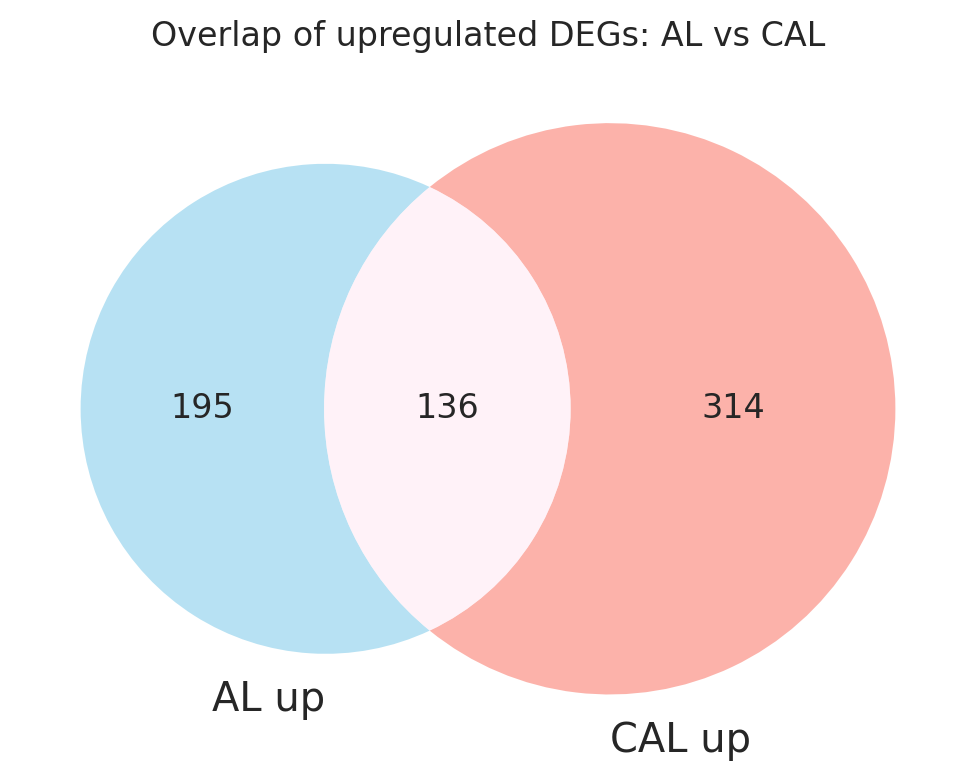

In [66]:
# --- get upregulated genes ---
AL_up = set(dfs["MOL_AL"].loc[dfs["MOL_AL"]["direction"]=="up", "gene_hs"])
CAL_up = set(dfs["MOL_CAL"].loc[dfs["MOL_CAL"]["direction"]=="up", "gene_hs"])

# --- plot Venn diagram ---
plt.figure(figsize=(6,6))
venn2([AL_up, CAL_up],
      set_labels=("AL up", "CAL up"),
      set_colors=("skyblue", "salmon"),
      alpha=0.6)
plt.title("Overlap of upregulated DEGs: AL vs CAL")
plt.show()

In [67]:
genes_all_shared = set(MOL_NAWM['gene']) & \
                set(MOL_AL['gene'])
len(genes_all_shared)

7869

In [68]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all_shared)]

# Apply filtering to each DEG DataFrame
MOL_NAWM_pairwise = filter_genes(MOL_NAWM)
MOL_AL_pairwise = filter_genes(MOL_AL)

print(MOL_NAWM_pairwise.shape)
print(MOL_AL_pairwise.shape)

(7869, 6)
(7869, 6)


In [69]:
MOL_NAWM_pairwise['direction'].value_counts()

direction
ns      7691
up       136
down      42
Name: count, dtype: int64

In [70]:
MOL_AL_pairwise['direction'].value_counts()

direction
ns      7411
up       238
down     220
Name: count, dtype: int64

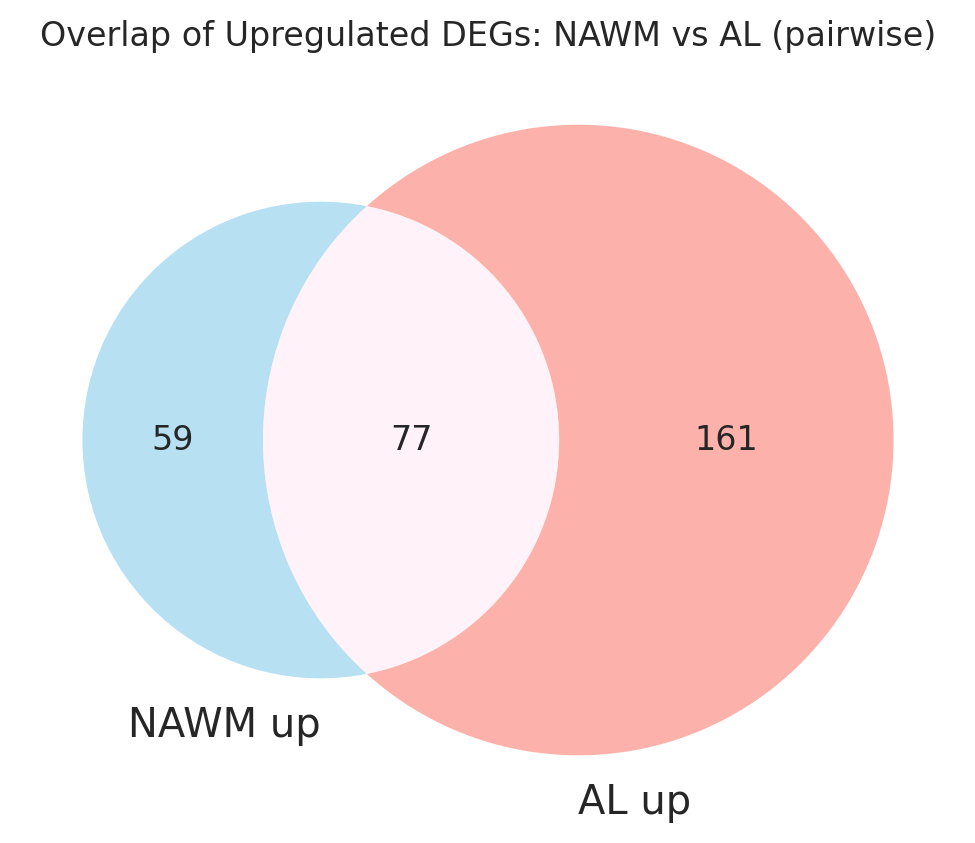

In [71]:
# --- get upregulated genes ---
NAWM_up = set(MOL_NAWM_pairwise.loc[MOL_NAWM_pairwise["direction"] == "up", "gene_hs"])
AL_up   = set(MOL_AL_pairwise.loc[MOL_AL_pairwise["direction"] == "up", "gene_hs"])

# --- plot Venn diagram ---
plt.figure(figsize=(6,6))
venn2(
    [NAWM_up, AL_up],
    set_labels=("NAWM up", "AL up"),
    set_colors=("skyblue", "salmon"),
    alpha=0.6
)
plt.title("Overlap of Upregulated DEGs: NAWM vs AL (pairwise)")
plt.show()

In [72]:
genes_all_shared = set(Cupr_demyel['gene_hs']) & \
                set(MOL_AL['gene_hs'])
len(genes_all_shared)

7275

In [73]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene_hs'].isin(genes_all_shared)]

# Apply filtering to each DEG DataFrame
Cupr_demyel_pairwise = filter_genes(Cupr_demyel)
MOL_AL_pairwise = filter_genes(MOL_AL)

print(Cupr_demyel_pairwise.shape)
print(MOL_AL_pairwise.shape)

(7275, 7)
(7275, 6)


In [74]:
Cupr_demyel_pairwise['direction'].value_counts()

direction
ns      4357
up      1612
down    1306
Name: count, dtype: int64

In [75]:
MOL_AL_pairwise['direction'].value_counts()

direction
ns      6981
up       149
down     145
Name: count, dtype: int64

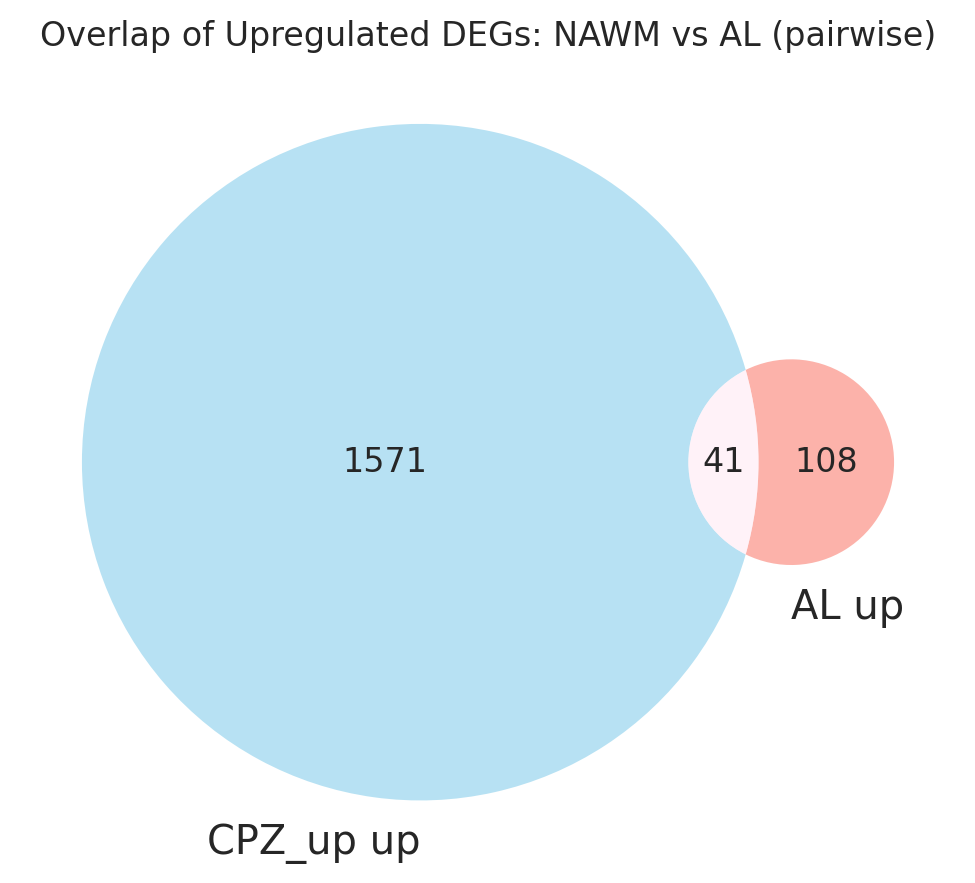

In [76]:
# --- get upregulated genes ---
CPZ_up = set(Cupr_demyel_pairwise.loc[Cupr_demyel_pairwise["direction"] == "up", "gene_hs"])
AL_up   = set(MOL_AL_pairwise.loc[MOL_AL_pairwise["direction"] == "up", "gene_hs"])

# --- plot Venn diagram ---
plt.figure(figsize=(6,6))
venn2(
    [CPZ_up, AL_up],
    set_labels=("CPZ_up up", "AL up"),
    set_colors=("skyblue", "salmon"),
    alpha=0.6
)
plt.title("Overlap of Upregulated DEGs: NAWM vs AL (pairwise)")
plt.show()

## TEST jaccard and spearman- skip

In [77]:
## JACCARD LOOP:

pairs = list(itertools.combinations(dfs.keys(), 2))
results = []

for a, b in pairs:
    df1 = dfs[a]
    df2 = dfs[b]
    
    # pairwise universe
    genes_pair = set(df1['gene_hs']).intersection(df2['gene_hs'])
    
    # up
    up1 = set(df1.loc[(df1['direction']=='up') & (df1['gene_hs'].isin(genes_pair)), 'gene_hs'])
    up2 = set(df2.loc[(df2['direction']=='up') & (df2['gene_hs'].isin(genes_pair)), 'gene_hs'])
    up_shared = len(up1 & up2)
    up_union = len(up1 | up2)
    j_up = up_shared / up_union if up_union > 0 else 0
    
    # down
    down1 = set(df1.loc[(df1['direction']=='down') & (df1['gene_hs'].isin(genes_pair)), 'gene_hs'])
    down2 = set(df2.loc[(df2['direction']=='down') & (df2['gene_hs'].isin(genes_pair)), 'gene_hs'])
    down_shared = len(down1 & down2)
    down_union = len(down1 | down2)
    j_down = down_shared / down_union if down_union > 0 else 0
    
    # combined
    combined1 = up1.union(down1)
    combined2 = up2.union(down2)
    combined_shared = len(combined1 & combined2)
    combined_union = len(combined1 | combined2)
    j_combined = combined_shared / combined_union if combined_union > 0 else 0

    results.append({
        "dataset1": a,
        "dataset2": b,
        # Up counts
        "up_df1": len(up1),
        "up_df2": len(up2),
        "up_shared": up_shared,
        "up_union": up_union,
        "jaccard_up": j_up,
        # Down counts
        "down_df1": len(down1),
        "down_df2": len(down2),
        "down_shared": down_shared,
        "down_union": down_union,
        "jaccard_down": j_down,
        # Combined
        "combined_df1": len(combined1),
        "combined_df2": len(combined2),
        "combined_shared": combined_shared,
        "combined_union": combined_union,
        "jaccard_combined": j_combined
    })

jaccard_df = pd.DataFrame(results)
print(jaccard_df)

      dataset1     dataset2  up_df1  up_df2  up_shared  up_union  jaccard_up  \
0     MOL_NAWM       MOL_AL     136     238         77       297    0.259259   
1     MOL_NAWM      MOL_CAL     142     290         65       367    0.177112   
2     MOL_NAWM      MOL_CIL     138     275         85       328    0.259146   
3     MOL_NAWM       MOL_RL     138     218         78       278    0.280576   
4     MOL_NAWM   LPC_demyel      78     323         24       377    0.063660   
5     MOL_NAWM   LPC_remyel      96     302         19       379    0.050132   
6     MOL_NAWM  Cupr_demyel      69    1463         25      1507    0.016589   
7       MOL_AL      MOL_CAL     297     392        136       553    0.245931   
8       MOL_AL      MOL_CIL     291     309        124       476    0.260504   
9       MOL_AL       MOL_RL     284     276         93       467    0.199143   
10      MOL_AL   LPC_demyel     172     368         30       510    0.058824   
11      MOL_AL   LPC_remyel     202     

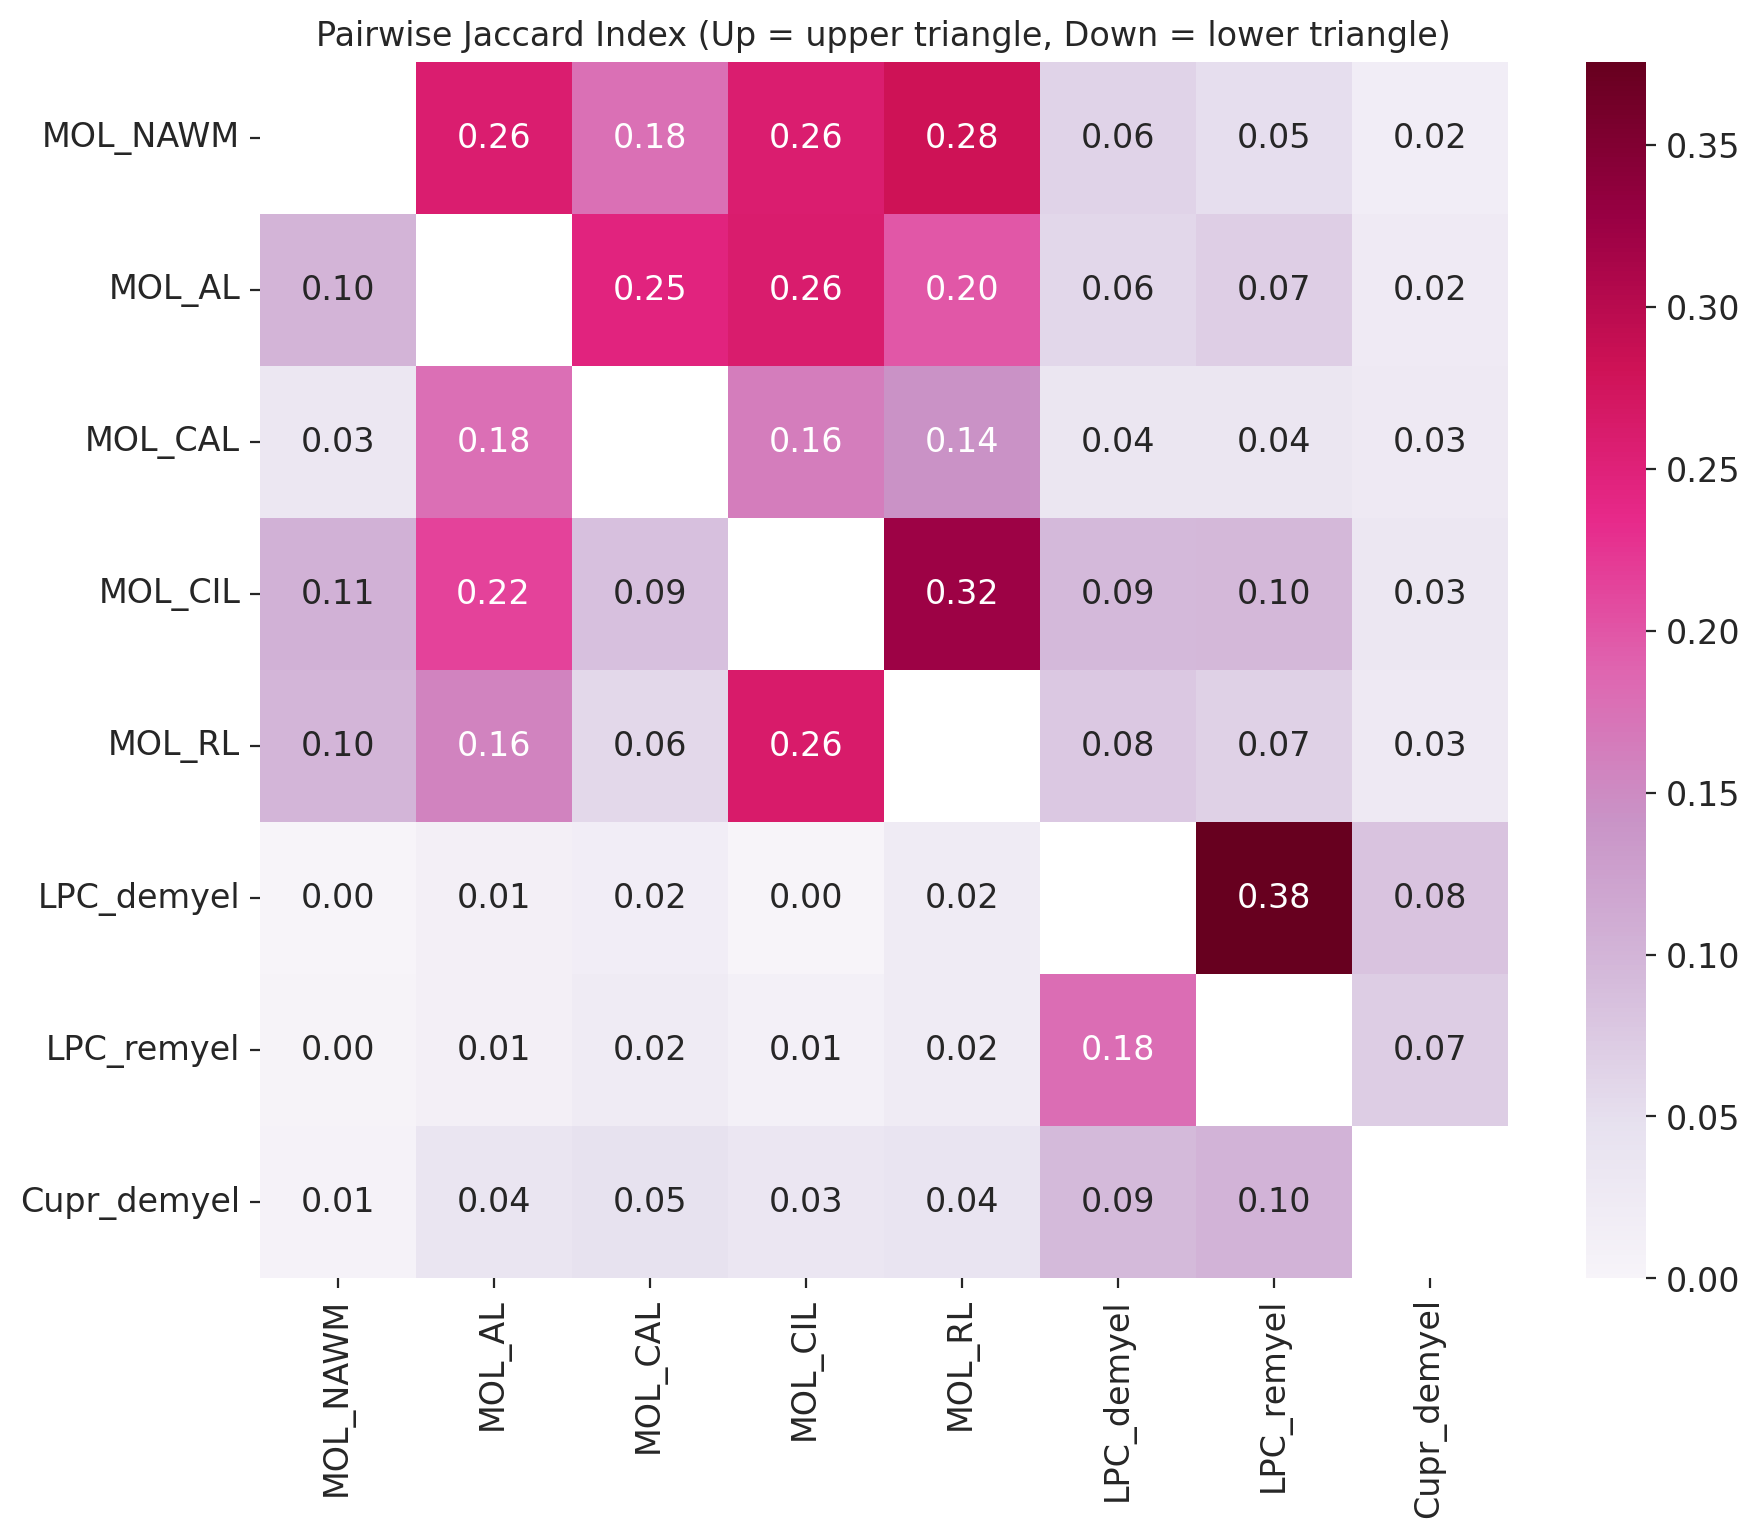

In [78]:
# --- make square matrices ---
datasets = list(dfs.keys())
n = len(datasets)

# initialize with NaN
heatmap_matrix = pd.DataFrame(np.nan, index=datasets, columns=datasets)

# fill upper triangle with jaccard_up, lower triangle with jaccard_down
for _, row in jaccard_df.iterrows():
    i, j = row['dataset1'], row['dataset2']
    heatmap_matrix.loc[i, j] = row['jaccard_up']       # upper triangle
    heatmap_matrix.loc[j, i] = row['jaccard_down']     # lower triangle

# plot
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="PuRd")
plt.title("Pairwise Jaccard Index (Up = upper triangle, Down = lower triangle)")
plt.grid(False)
plt.show()

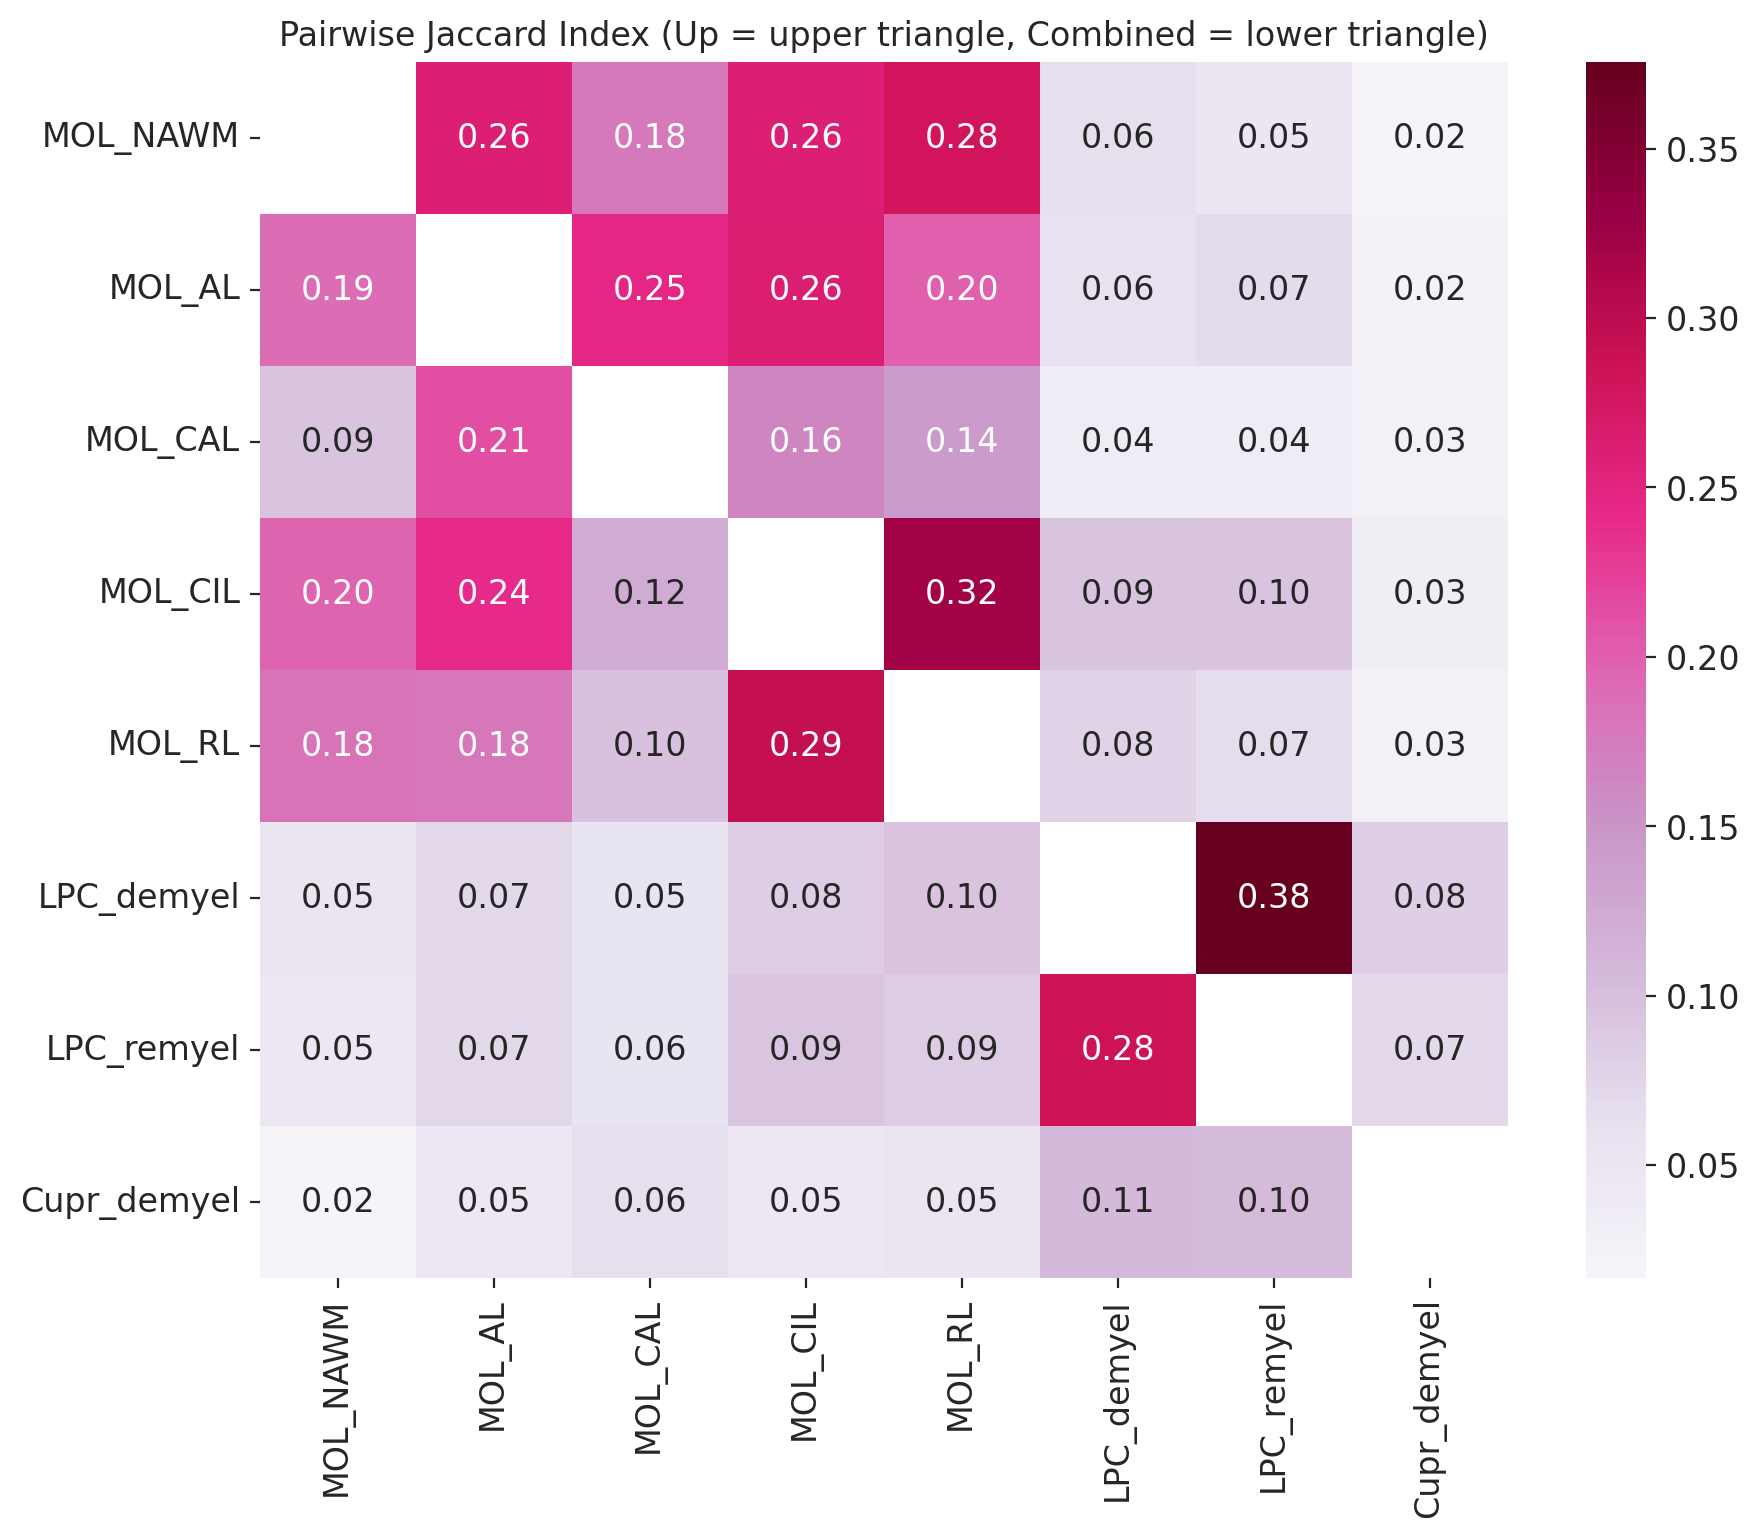

In [79]:
# --- make square matrices ---
datasets = list(dfs.keys())
n = len(datasets)

# initialize with NaN
heatmap_matrix = pd.DataFrame(np.nan, index=datasets, columns=datasets)

# fill upper triangle with jaccard_up, lower triangle with jaccard_combined
for _, row in jaccard_df.iterrows():
    i, j = row['dataset1'], row['dataset2']
    heatmap_matrix.loc[i, j] = row['jaccard_up']           # upper triangle
    heatmap_matrix.loc[j, i] = row['jaccard_combined']     # lower triangle

# plot
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="PuRd")
plt.title("Pairwise Jaccard Index (Up = upper triangle, Combined = lower triangle)")
plt.grid(False)
plt.show()

In [80]:
# --- get up/down sets for both datasets ---
cupr_up = set(dfs["Cupr_demyel"].loc[dfs["Cupr_demyel"]["direction"] == "up", "gene_hs"])
cupr_down = set(dfs["Cupr_demyel"].loc[dfs["Cupr_demyel"]["direction"] == "down", "gene_hs"])

lpc_up = set(dfs["LPC_demyel"].loc[dfs["LPC_demyel"]["direction"] == "up", "gene_hs"])
lpc_down = set(dfs["LPC_demyel"].loc[dfs["LPC_demyel"]["direction"] == "down", "gene_hs"])

# --- compute all directional overlaps ---
cuprUP_lpcUP = cupr_up & lpc_up
cuprDOWN_lpcDOWN = cupr_down & lpc_down
cuprUP_lpcDOWN = cupr_up & lpc_down
cuprDOWN_lpcUP = cupr_down & lpc_up

# --- summary printout ---
print("=== Directional overlaps between Cuprizone and LPC demyelination ===\n")

print(f"Cupr_up ∩ LPC_up      = {len(cuprUP_lpcUP)} genes")
print(f"Cupr_down ∩ LPC_down  = {len(cuprDOWN_lpcDOWN)} genes")
print(f"Cupr_up ∩ LPC_down    = {len(cuprUP_lpcDOWN)} genes")
print(f"Cupr_down ∩ LPC_up    = {len(cuprDOWN_lpcUP)} genes\n")

# --- optional: fractions relative to each direction's size ---
print("=== Fractional overlaps ===")
print(f"Fraction of Cupr_up also up in LPC:   {len(cuprUP_lpcUP)/len(cupr_up):.3%}")
print(f"Fraction of Cupr_down also down in LPC: {len(cuprDOWN_lpcDOWN)/len(cupr_down):.3%}")
print(f"Fraction of Cupr_up also down in LPC: {len(cuprUP_lpcDOWN)/len(cupr_up):.3%}")
print(f"Fraction of Cupr_down also up in LPC: {len(cuprDOWN_lpcUP)/len(cupr_down):.3%}")

=== Directional overlaps between Cuprizone and LPC demyelination ===

Cupr_up ∩ LPC_up      = 177 genes
Cupr_down ∩ LPC_down  = 153 genes
Cupr_up ∩ LPC_down    = 15 genes
Cupr_down ∩ LPC_up    = 53 genes

=== Fractional overlaps ===
Fraction of Cupr_up also up in LPC:   8.647%
Fraction of Cupr_down also down in LPC: 10.013%
Fraction of Cupr_up also down in LPC: 0.733%
Fraction of Cupr_down also up in LPC: 3.469%


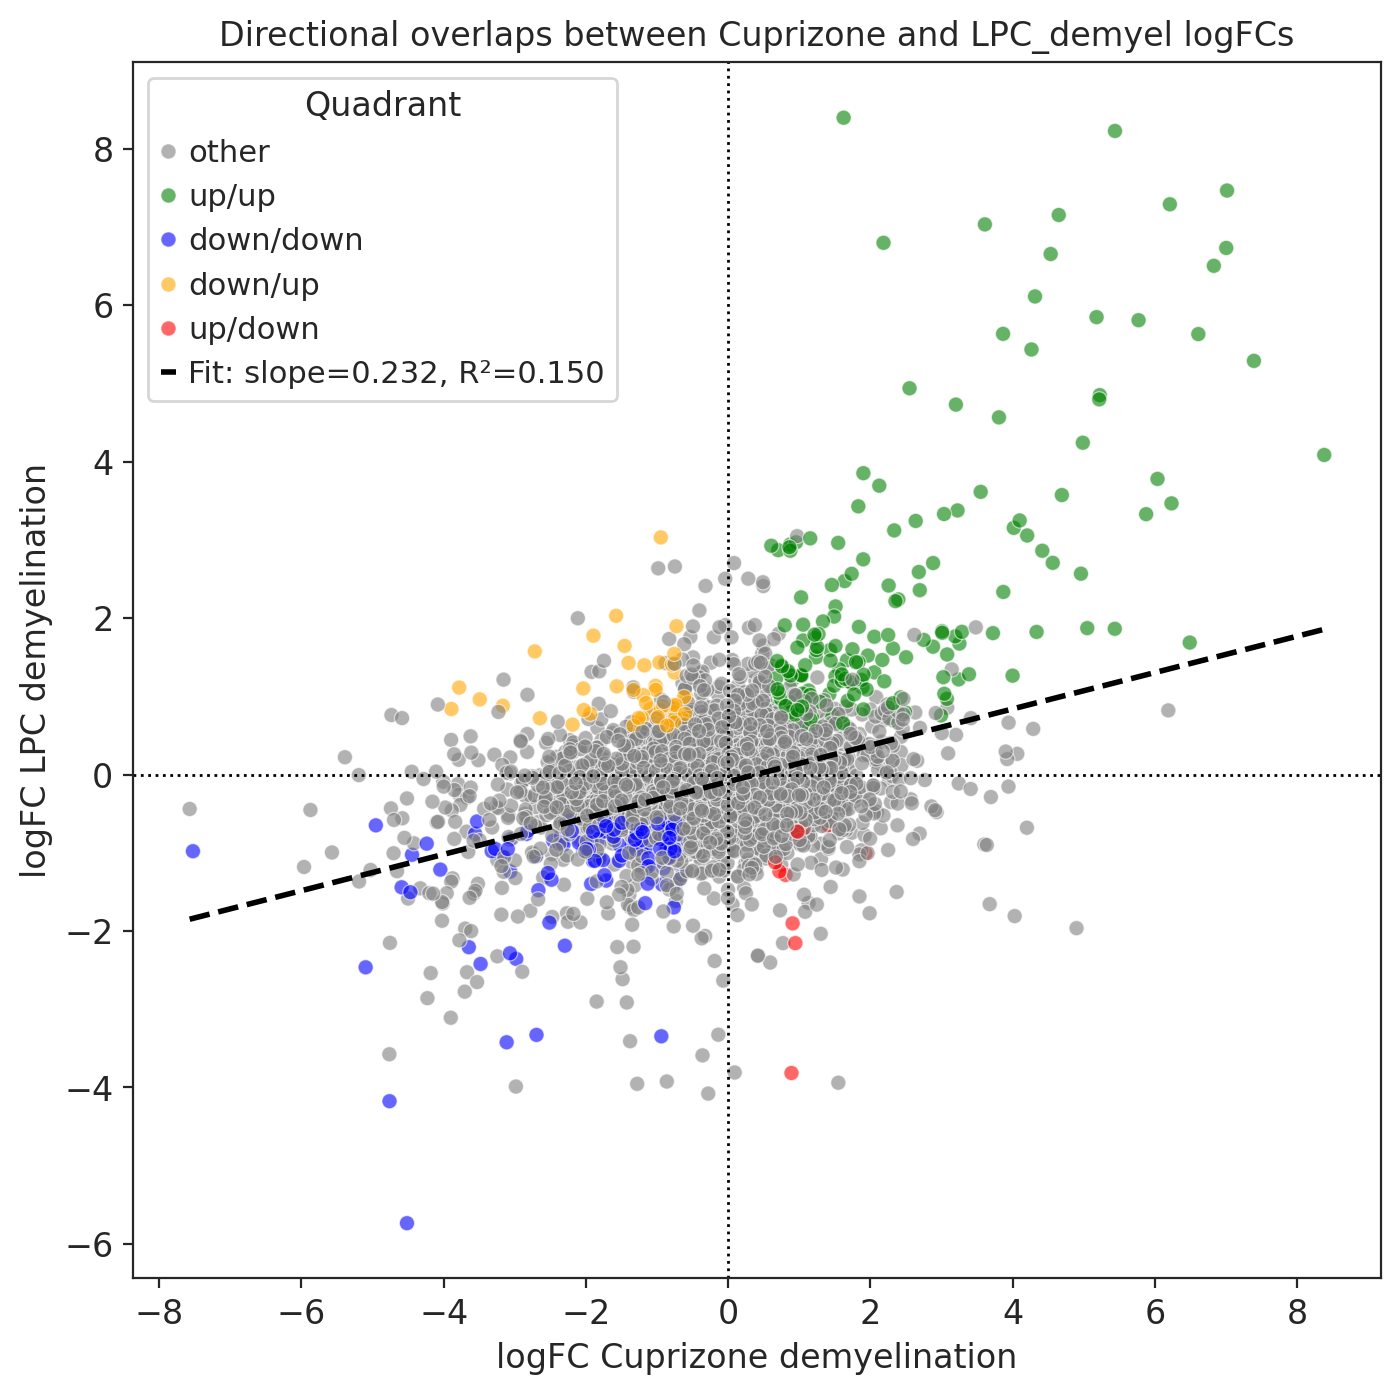

In [81]:
# subset to shared genes
shared_genes = set(dfs["Cupr_demyel"]["gene_hs"]).intersection(dfs["LPC_demyel"]["gene_hs"])
cupr_sub = dfs["Cupr_demyel"][dfs["Cupr_demyel"]["gene_hs"].isin(shared_genes)].set_index("gene_hs")
lpc_sub = dfs["LPC_demyel"][dfs["LPC_demyel"]["gene_hs"].isin(shared_genes)].set_index("gene_hs")

# merge logFCs
df_plot = pd.DataFrame({
    "logFC_Cupr": cupr_sub["logFC"],
    "logFC_LPC": lpc_sub["logFC"],
    "direction_Cupr": cupr_sub["direction"],
    "direction_LPC": lpc_sub["direction"]
})

# define quadrant for coloring
def quadrant(row):
    if row["direction_Cupr"] == "up" and row["direction_LPC"] == "up":
        return "up/up"
    elif row["direction_Cupr"] == "down" and row["direction_LPC"] == "down":
        return "down/down"
    elif row["direction_Cupr"] == "up" and row["direction_LPC"] == "down":
        return "up/down"
    elif row["direction_Cupr"] == "down" and row["direction_LPC"] == "up":
        return "down/up"
    else:
        return "other"

df_plot["quadrant"] = df_plot.apply(quadrant, axis=1)

# --- linear regression for all points ---
X = df_plot["logFC_Cupr"].values.reshape(-1, 1)
y = df_plot["logFC_LPC"].values
reg = LinearRegression().fit(X, y)
slope = reg.coef_[0]
intercept = reg.intercept_
r2 = reg.score(X, y)

# scatter plot
plt.figure(figsize=(8,8))
palette = {
    "up/up": "green",
    "down/down": "blue",
    "up/down": "red",
    "down/up": "orange",
    "other": "grey"
}

sns.scatterplot(
    data=df_plot,
    x="logFC_Cupr",
    y="logFC_LPC",
    hue="quadrant",
    palette=palette,
    alpha=0.6,
    s=30
)

# regression line
x_vals = np.array([df_plot["logFC_Cupr"].min(), df_plot["logFC_Cupr"].max()])
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="black", linestyle="--", linewidth=2, label=f"Fit: slope={slope:.3f}, R²={r2:.3f}")

plt.axhline(0, color="black", linestyle=":", linewidth=1)
plt.axvline(0, color="black", linestyle=":", linewidth=1)
plt.xlabel("logFC Cuprizone demyelination")
plt.ylabel("logFC LPC demyelination")
plt.title("Directional overlaps between Cuprizone and LPC_demyel logFCs")
plt.legend(title="Quadrant", loc="upper left")
plt.grid(False)
plt.show()

      dataset  shared_genes  spearman_rho           pval
6  LPC_remyel          3763      0.357835  4.551040e-114
5  LPC_demyel          3728      0.290481   2.129740e-73
0    MOL_NAWM          2643      0.200585   2.158160e-25
4      MOL_RL          3300      0.170011   8.007497e-23
1      MOL_AL          3065      0.158432   1.110511e-18
2     MOL_CAL          3495      0.123921   1.955954e-13
3     MOL_CIL          3114      0.105046   4.208201e-09


/tmp/2375884.1.long/ipykernel_1071129/3339379709.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="spearman_rho", y="dataset", data=corr_degs_df, palette="PuRd")


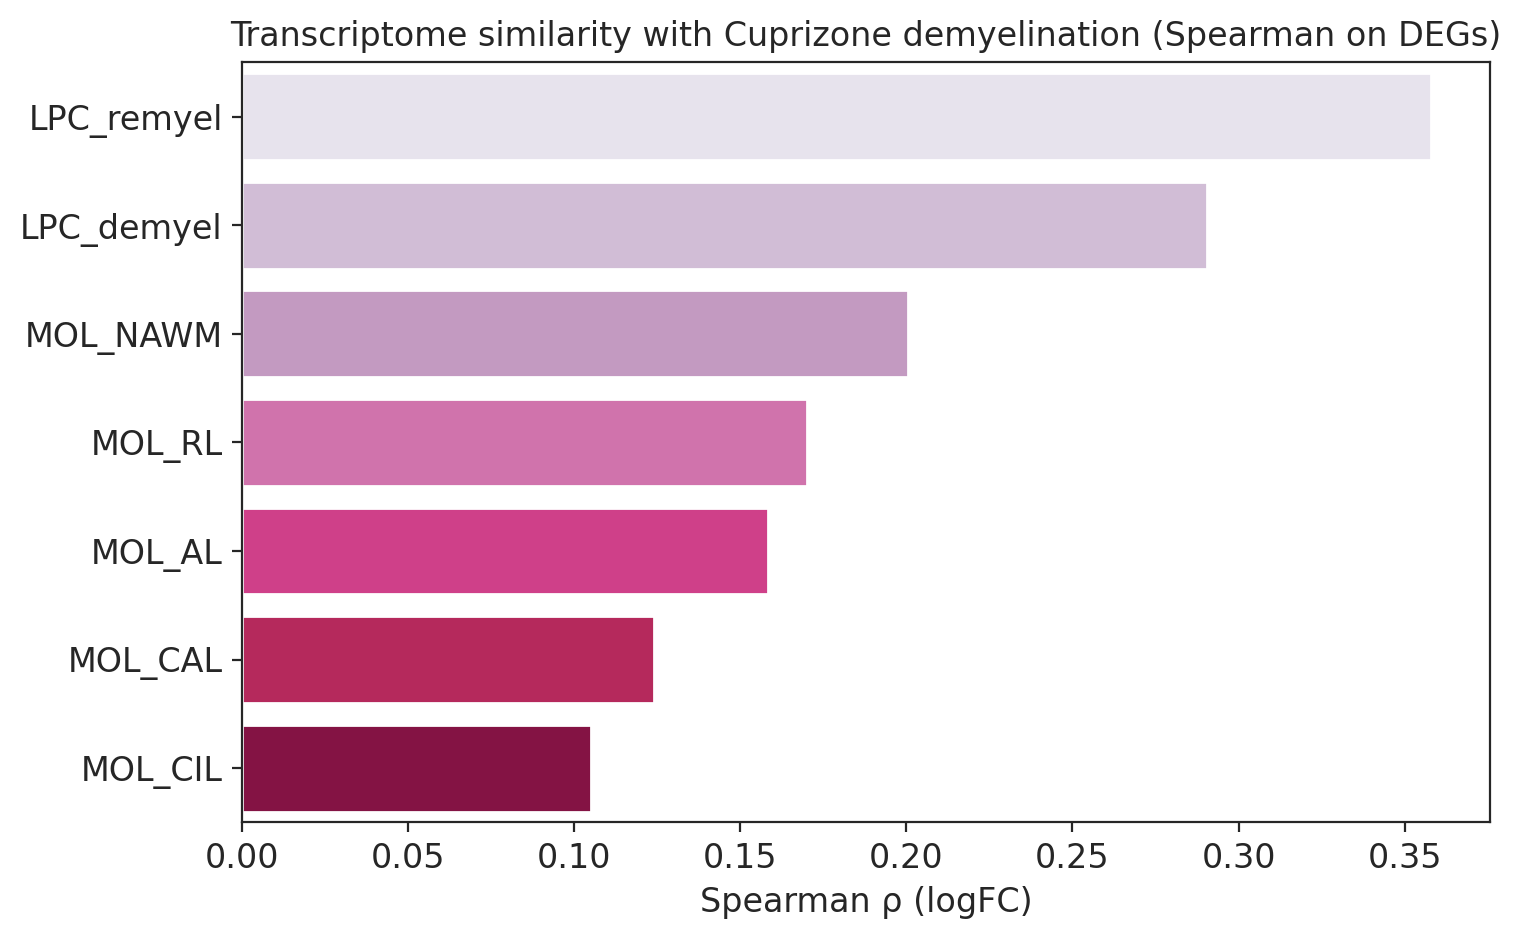

In [82]:
ref_name = "Cupr_demyel"
ref_df = dfs[ref_name]

results = []

for name, df in dfs.items():
    if name == ref_name:
        continue  # skip self-comparison
    
    # --- DEGs only: genes up or down in either dataset ---
    deg_genes = set(ref_df[ref_df['direction'] != 'ns']['gene_hs']).union(
                set(df[df['direction'] != 'ns']['gene_hs']))
    
    # subset to DEGs
    ref_sub = ref_df[ref_df['gene_hs'].isin(deg_genes)].set_index('gene_hs')
    df_sub = df[df['gene_hs'].isin(deg_genes)].set_index('gene_hs')
    
    # find shared DEGs
    shared = set(ref_sub.index).intersection(df_sub.index)
    
    # compute Spearman correlation on DEGs only
    if len(shared) > 1:
        rho, pval = spearmanr(ref_sub.loc[list(shared), 'logFC'],
                              df_sub.loc[list(shared), 'logFC'])
    else:
        rho, pval = (float('nan'), float('nan'))
    
    results.append({
        "dataset": name,
        "shared_genes": len(shared),
        "spearman_rho": rho,
        "pval": pval
    })

corr_degs_df = pd.DataFrame(results).sort_values("spearman_rho", ascending=False)
print(corr_degs_df)

# --- plot ---
plt.figure(figsize=(8,5))
sns.barplot(x="spearman_rho", y="dataset", data=corr_degs_df, palette="PuRd")
plt.title("Transcriptome similarity with Cuprizone demyelination (Spearman on DEGs)")
plt.xlabel("Spearman ρ (logFC)")
plt.ylabel("")
plt.show()

       dataset  shared_genes  spearman_rho           pval
5   LPC_remyel          1099      0.748813  3.551350e-198
6  Cupr_demyel          3728      0.290481   2.129740e-73
0     MOL_NAWM           596      0.067358   1.004185e-01
3      MOL_CIL           840      0.030122   3.832511e-01
1       MOL_AL           876      0.016910   6.172070e-01
4       MOL_RL           892      0.003908   9.072114e-01
2      MOL_CAL          1138     -0.021276   4.733598e-01


/tmp/2375884.1.long/ipykernel_1071129/3838480318.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="spearman_rho", y="dataset", data=corr_degs_df, palette="PuRd")


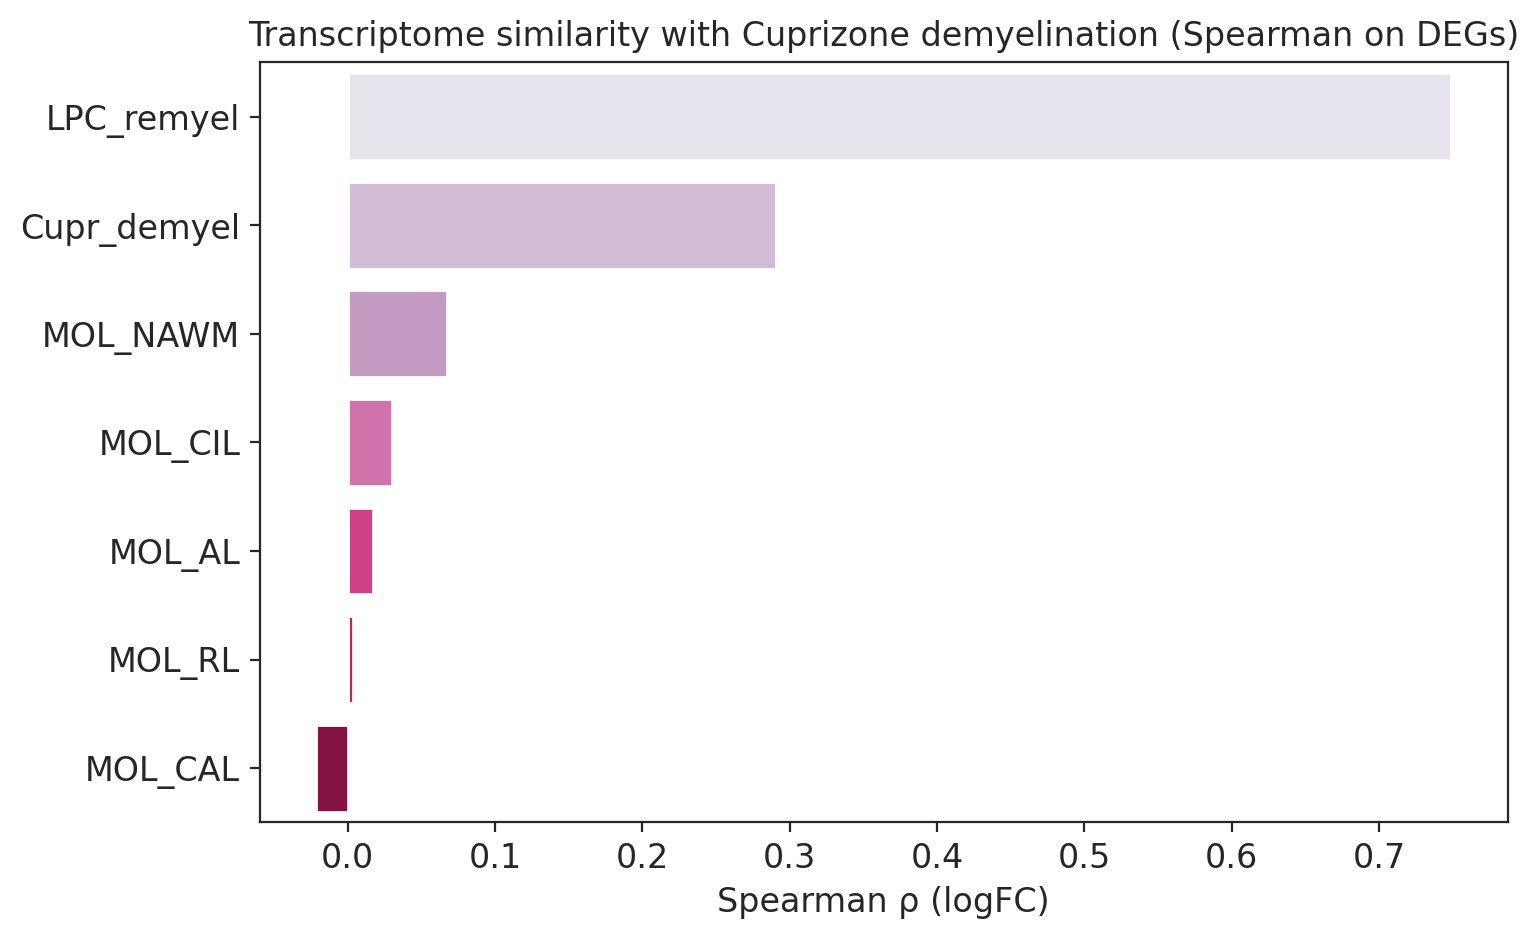

In [83]:
ref_name = "LPC_demyel"
ref_df = dfs[ref_name]

results = []

for name, df in dfs.items():
    if name == ref_name:
        continue  # skip self-comparison
    
    # --- DEGs only: genes up or down in either dataset ---
    deg_genes = set(ref_df[ref_df['direction'] != 'ns']['gene_hs']).union(
                set(df[df['direction'] != 'ns']['gene_hs']))
    
    # subset to DEGs
    ref_sub = ref_df[ref_df['gene_hs'].isin(deg_genes)].set_index('gene_hs')
    df_sub = df[df['gene_hs'].isin(deg_genes)].set_index('gene_hs')
    
    # find shared DEGs
    shared = set(ref_sub.index).intersection(df_sub.index)
    
    # compute Spearman correlation on DEGs only
    if len(shared) > 1:
        rho, pval = spearmanr(ref_sub.loc[list(shared), 'logFC'],
                              df_sub.loc[list(shared), 'logFC'])
    else:
        rho, pval = (float('nan'), float('nan'))
    
    results.append({
        "dataset": name,
        "shared_genes": len(shared),
        "spearman_rho": rho,
        "pval": pval
    })

corr_degs_df = pd.DataFrame(results).sort_values("spearman_rho", ascending=False)
print(corr_degs_df)

# --- plot ---
plt.figure(figsize=(8,5))
sns.barplot(x="spearman_rho", y="dataset", data=corr_degs_df, palette="PuRd")
plt.title("Transcriptome similarity with Cuprizone demyelination (Spearman on DEGs)")
plt.xlabel("Spearman ρ (logFC)")
plt.ylabel("")
plt.show()

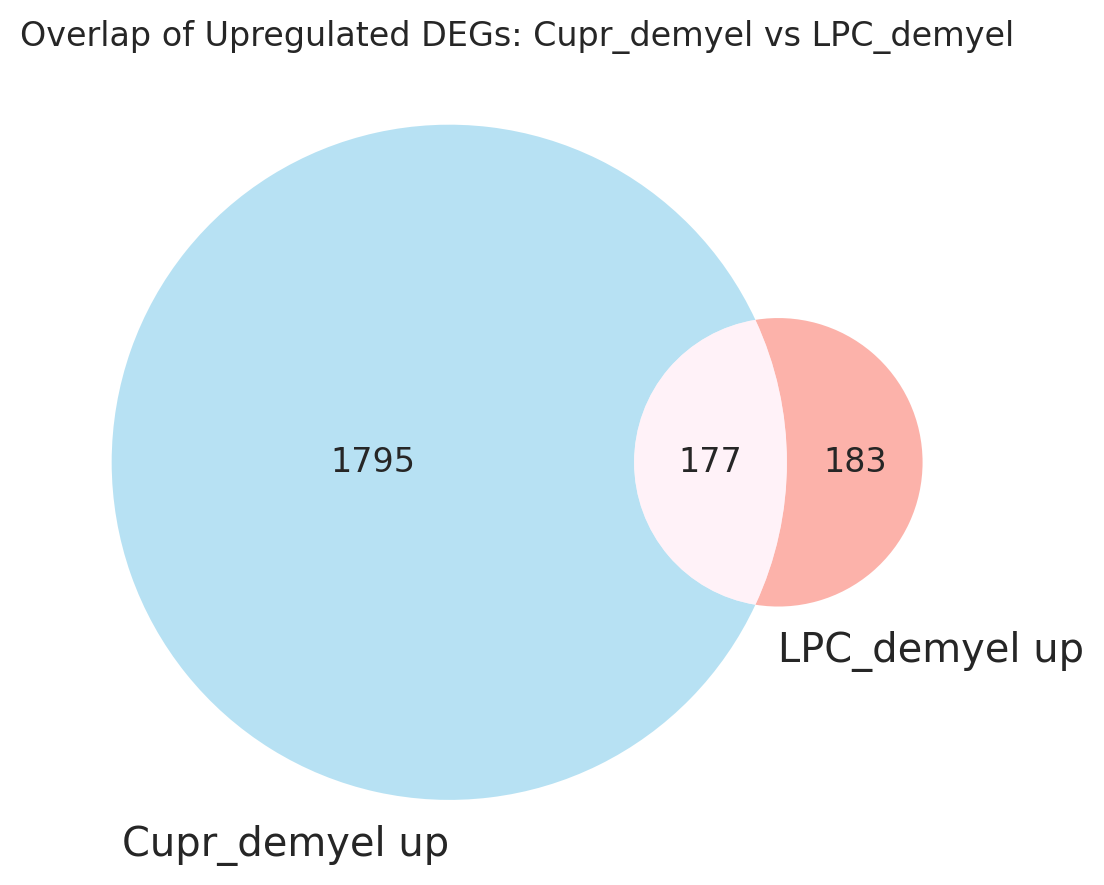

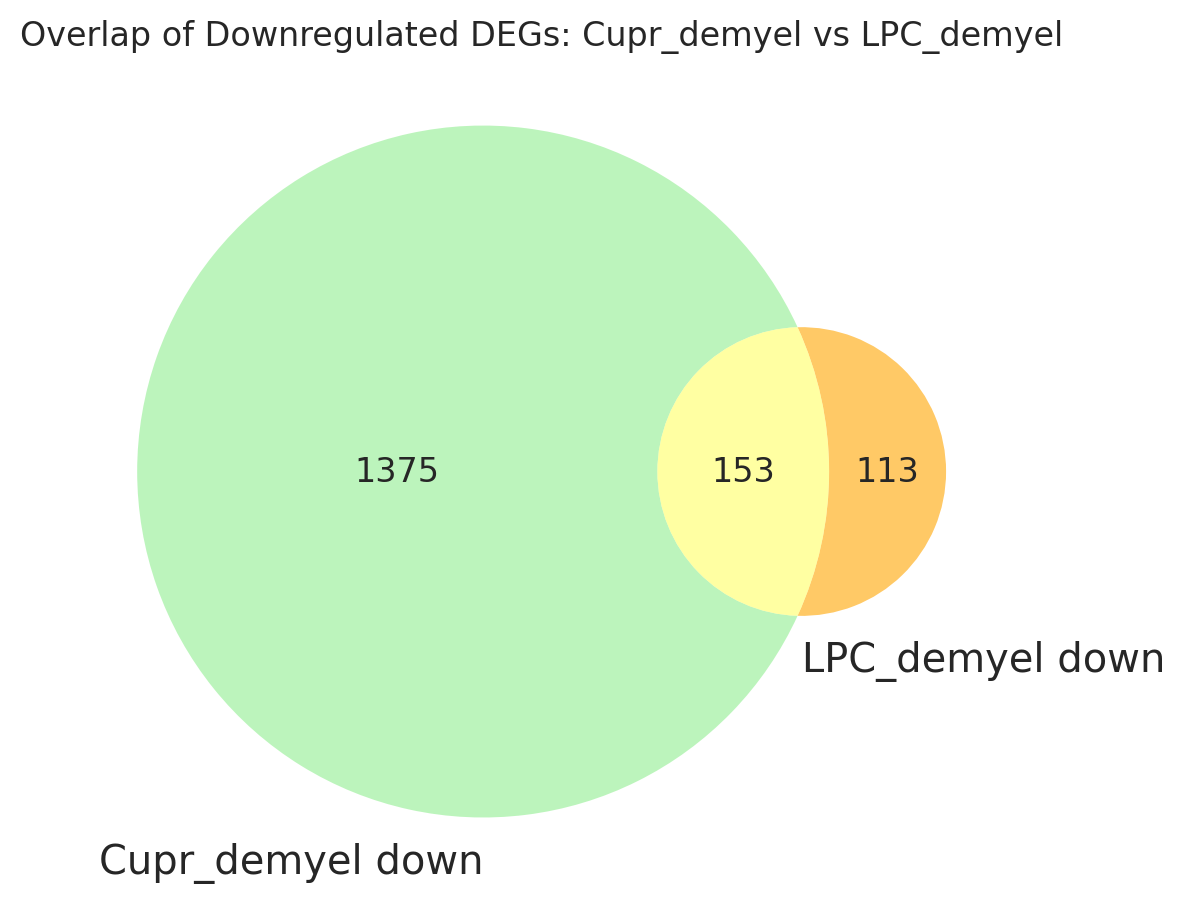

In [84]:
# Example: Cupr_demyel vs LPC_demyel
df1_name = "Cupr_demyel"
df2_name = "LPC_demyel"

df1 = dfs[df1_name]
df2 = dfs[df2_name]

# --- Get shared DEGs used for Spearman ---
deg_genes = set(df1[df1['direction'] != 'ns']['gene_hs']).union(
            set(df2[df2['direction'] != 'ns']['gene_hs']))
shared_genes = set(df1['gene_hs']).intersection(df2['gene_hs']).intersection(deg_genes)

# --- Split into up and down ---
df1_up = set(df1.loc[(df1['direction']=='up') & (df1['gene_hs'].isin(shared_genes)), 'gene_hs'])
df1_down = set(df1.loc[(df1['direction']=='down') & (df1['gene_hs'].isin(shared_genes)), 'gene_hs'])

df2_up = set(df2.loc[(df2['direction']=='up') & (df2['gene_hs'].isin(shared_genes)), 'gene_hs'])
df2_down = set(df2.loc[(df2['direction']=='down') & (df2['gene_hs'].isin(shared_genes)), 'gene_hs'])

# --- Plot Venn for Upregulated DEGs ---
plt.figure(figsize=(6,6))
venn2([df1_up, df2_up],
      set_labels=(f"{df1_name} up", f"{df2_name} up"),
      set_colors=("skyblue", "salmon"),
      alpha=0.6)
plt.title(f"Overlap of Upregulated DEGs: {df1_name} vs {df2_name}")
plt.show()

# --- Plot Venn for Downregulated DEGs ---
plt.figure(figsize=(6,6))
venn2([df1_down, df2_down],
      set_labels=(f"{df1_name} down", f"{df2_name} down"),
      set_colors=("lightgreen", "orange"),
      alpha=0.6)
plt.title(f"Overlap of Downregulated DEGs: {df1_name} vs {df2_name}")
plt.show()

## Jaccard and Spearman on DEGs

In [85]:
# CODE 1: more conservative- DEGs only

pairs = list(itertools.combinations(dfs.keys(), 2))
results = []

for a, b in pairs:
    df1 = dfs[a]
    df2 = dfs[b]
    
    # --- DEGs only: genes up or down in either dataset ---
    deg_genes = set(df1[df1['direction'] != 'ns']['gene_hs']).union(
                set(df2[df2['direction'] != 'ns']['gene_hs']))
    
    # subset for DEGs
    df1_sub = df1[df1['gene_hs'].isin(deg_genes)].set_index('gene_hs')
    df2_sub = df2[df2['gene_hs'].isin(deg_genes)].set_index('gene_hs')
    
    # --- pairwise universe for Jaccard ---
    genes_pair = set(df1_sub.index).intersection(df2_sub.index)
    
    # --- Jaccard ---
    up1 = set(df1_sub.loc[df1_sub['direction']=='up'].index)
    up2 = set(df2_sub.loc[df2_sub['direction']=='up'].index)
    up_shared = len(up1 & up2)
    up_union = len(up1 | up2)
    j_up = up_shared / up_union if up_union > 0 else 0

    down1 = set(df1_sub.loc[df1_sub['direction']=='down'].index)
    down2 = set(df2_sub.loc[df2_sub['direction']=='down'].index)
    down_shared = len(down1 & down2)
    down_union = len(down1 | down2)
    j_down = down_shared / down_union if down_union > 0 else 0

    # --- Spearman on DEGs only ---
    genes_pair_list = list(genes_pair)  # convert to list for indexing
    if len(genes_pair_list) > 1:  # need at least 2 points
        rho, pval = spearmanr(df1_sub.loc[genes_pair_list, 'logFC'],
                              df2_sub.loc[genes_pair_list, 'logFC'])
    else:
        rho, pval = (float('nan'), float('nan'))
    
    # --- append results ---
    results.append({
        "dataset1": a,
        "dataset2": b,
        # Up counts
        "up_df1": len(up1),
        "up_df2": len(up2),
        "up_shared": up_shared,
        "up_union": up_union,
        "jaccard_up": j_up,
        # Down counts
        "down_df1": len(down1),
        "down_df2": len(down2),
        "down_shared": down_shared,
        "down_union": down_union,
        "jaccard_down": j_down,
        # Spearman
        "spearman_rho": rho,
        "spearman_pval": pval,
        "shared_genes": len(genes_pair)
    })

jaccard_spearman_degs_df = pd.DataFrame(results)
print(jaccard_spearman_degs_df)

      dataset1     dataset2  up_df1  up_df2  up_shared  up_union  jaccard_up  \
0     MOL_NAWM       MOL_AL     153     331         77       407    0.189189   
1     MOL_NAWM      MOL_CAL     153     450         65       538    0.120818   
2     MOL_NAWM      MOL_CIL     153     352         85       420    0.202381   
3     MOL_NAWM       MOL_RL     153     299         78       374    0.208556   
4     MOL_NAWM   LPC_demyel     153     455         24       584    0.041096   
5     MOL_NAWM   LPC_remyel     153     455         19       589    0.032258   
6     MOL_NAWM  Cupr_demyel     153    2047         25      2175    0.011494   
7       MOL_AL      MOL_CAL     331     450        136       645    0.210853   
8       MOL_AL      MOL_CIL     331     352        124       559    0.221825   
9       MOL_AL       MOL_RL     331     299         93       537    0.173184   
10      MOL_AL   LPC_demyel     331     455         30       756    0.039683   
11      MOL_AL   LPC_remyel     331     

In [86]:
# Jaccard Up
min_j_up = jaccard_spearman_degs_df['jaccard_up'].min()
max_j_up = jaccard_spearman_degs_df['jaccard_up'].max()

# Jaccard Down
min_j_down = jaccard_spearman_degs_df['jaccard_down'].min()
max_j_down = jaccard_spearman_degs_df['jaccard_down'].max()

# Spearman rho
min_rho = jaccard_spearman_degs_df['spearman_rho'].min()
max_rho = jaccard_spearman_degs_df['spearman_rho'].max()

print(f"Jaccard Up: min={min_j_up:.3f}, max={max_j_up:.3f}")
print(f"Jaccard Down: min={min_j_down:.3f}, max={max_j_down:.3f}")
print(f"Spearman rho: min={min_rho:.3f}, max={max_rho:.3f}")

Jaccard Up: min=0.011, max=0.313
Jaccard Down: min=0.000, max=0.234
Spearman rho: min=-0.021, max=0.852


In [87]:
jaccard_spearman_degs_df.to_csv("jaccard_spearman_degs_df1.csv", index=False)
#df = pd.read_csv("jaccard_spearman_degs_df.csv")

In [88]:
import itertools
import pandas as pd
from scipy.stats import spearmanr

pairs = list(itertools.combinations(dfs.keys(), 2))
results = []

for a, b in pairs:
    df1 = dfs[a]
    df2 = dfs[b]
    
    # --- Genes DE in at least one dataset ---
    deg_genes = set(df1[df1['direction'] != 'ns']['gene_hs']).union(
                set(df2[df2['direction'] != 'ns']['gene_hs']))
    
    # --- Keep only genes measured in both datasets ---
    shared_genes = deg_genes.intersection(set(df1['gene_hs'])).intersection(set(df2['gene_hs']))
    
    # --- Subset for calculations ---
    df1_sub = df1[df1['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    df2_sub = df2[df2['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    
    # --- Jaccard for up/down DEGs ---
    up1 = set(df1_sub.loc[df1_sub['direction']=='up'].index)
    up2 = set(df2_sub.loc[df2_sub['direction']=='up'].index)
    up_shared = len(up1 & up2)
    up_union = len(up1 | up2)
    j_up = up_shared / up_union if up_union > 0 else 0

    down1 = set(df1_sub.loc[df1_sub['direction']=='down'].index)
    down2 = set(df2_sub.loc[df2_sub['direction']=='down'].index)
    down_shared = len(down1 & down2)
    down_union = len(down1 | down2)
    j_down = down_shared / down_union if down_union > 0 else 0

    # --- Spearman correlation on union of DEGs ---
    genes_list = list(shared_genes)
    if len(genes_list) > 1:  # need at least 2 points
        rho, pval = spearmanr(df1_sub.loc[genes_list, 'logFC'],
                              df2_sub.loc[genes_list, 'logFC'])
    else:
        rho, pval = (float('nan'), float('nan'))
    
    # --- append results ---
    results.append({
        "dataset1": a,
        "dataset2": b,
        # Up counts
        "up_df1": len(up1),
        "up_df2": len(up2),
        "up_shared": up_shared,
        "up_union": up_union,
        "jaccard_up": j_up,
        # Down counts
        "down_df1": len(down1),
        "down_df2": len(down2),
        "down_shared": down_shared,
        "down_union": down_union,
        "jaccard_down": j_down,
        # Spearman
        "spearman_rho": rho,
        "spearman_pval": pval,
        "shared_genes": len(shared_genes)
    })

# Final DataFrame
jaccard_spearman_degs_df = pd.DataFrame(results)
print(jaccard_spearman_degs_df)

      dataset1     dataset2  up_df1  up_df2  up_shared  up_union  jaccard_up  \
0     MOL_NAWM       MOL_AL     136     238         77       297    0.259259   
1     MOL_NAWM      MOL_CAL     142     290         65       367    0.177112   
2     MOL_NAWM      MOL_CIL     138     275         85       328    0.259146   
3     MOL_NAWM       MOL_RL     138     218         78       278    0.280576   
4     MOL_NAWM   LPC_demyel      78     323         24       377    0.063660   
5     MOL_NAWM   LPC_remyel      96     302         19       379    0.050132   
6     MOL_NAWM  Cupr_demyel      69    1463         25      1507    0.016589   
7       MOL_AL      MOL_CAL     297     392        136       553    0.245931   
8       MOL_AL      MOL_CIL     291     309        124       476    0.260504   
9       MOL_AL       MOL_RL     284     276         93       467    0.199143   
10      MOL_AL   LPC_demyel     172     368         30       510    0.058824   
11      MOL_AL   LPC_remyel     202     

In [89]:
# Jaccard Up
min_j_up = jaccard_spearman_degs_df['jaccard_up'].min()
max_j_up = jaccard_spearman_degs_df['jaccard_up'].max()

# Jaccard Down
min_j_down = jaccard_spearman_degs_df['jaccard_down'].min()
max_j_down = jaccard_spearman_degs_df['jaccard_down'].max()

# Spearman rho
min_rho = jaccard_spearman_degs_df['spearman_rho'].min()
max_rho = jaccard_spearman_degs_df['spearman_rho'].max()

print(f"Jaccard Up: min={min_j_up:.3f}, max={max_j_up:.3f}")
print(f"Jaccard Down: min={min_j_down:.3f}, max={max_j_down:.3f}")
print(f"Spearman rho: min={min_rho:.3f}, max={max_rho:.3f}")

Jaccard Up: min=0.017, max=0.375
Jaccard Down: min=0.000, max=0.263
Spearman rho: min=-0.021, max=0.852


In [90]:
jaccard_spearman_degs_df.to_csv("jaccard_spearman_degs_df2.csv", index=False)
#df = pd.read_csv("jaccard_spearman_degs_df.csv")

In [91]:
import itertools
import pandas as pd
from scipy.stats import spearmanr

pairs = list(itertools.combinations(dfs.keys(), 2))
results = []

for a, b in pairs:
    df1 = dfs[a]
    df2 = dfs[b]
    
    # Genes DE in at least one dataset
    deg_genes = set(df1[df1['direction'] != 'ns']['gene_hs']).union(
                set(df2[df2['direction'] != 'ns']['gene_hs']))
    
    # Keep only genes measured in both datasets
    shared_genes = deg_genes.intersection(set(df1['gene_hs'])).intersection(set(df2['gene_hs']))
    
    # Subset for calculations
    df1_sub = df1[df1['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    df2_sub = df2[df2['gene_hs'].isin(shared_genes)].set_index('gene_hs')
    
    # --- UP ---
    up1 = set(df1_sub.loc[df1_sub['direction']=='up'].index)
    up2 = set(df2_sub.loc[df2_sub['direction']=='up'].index)
    up_shared = len(up1 & up2)
    up_union = len(up1 | up2)
    up_min = min(len(up1), len(up2))
    j_up = up_shared / up_min if up_min > 0 else 0   # <-- Overlap coefficient replaces Jaccard
    
    # --- DOWN ---
    down1 = set(df1_sub.loc[df1_sub['direction']=='down'].index)
    down2 = set(df2_sub.loc[df2_sub['direction']=='down'].index)
    down_shared = len(down1 & down2)
    down_union = len(down1 | down2)
    down_min = min(len(down1), len(down2))
    j_down = down_shared / down_min if down_min > 0 else 0   # <-- Overlap coefficient replaces Jaccard
    
    # --- Spearman correlation (unchanged) ---
    genes_list = list(shared_genes)
    if len(genes_list) > 1:
        rho, pval = spearmanr(df1_sub.loc[genes_list, 'logFC'],
                              df2_sub.loc[genes_list, 'logFC'])
    else:
        rho, pval = (float('nan'), float('nan'))
    
    # --- Append results ---
    results.append({
        "dataset1": a,
        "dataset2": b,
        # Up counts
        "up_df1": len(up1),
        "up_df2": len(up2),
        "up_shared": up_shared,
        "up_union": up_union,
        "overlap_coeff_up": j_up,     # <-- This now contains the overlap coefficient
        # Down counts
        "down_df1": len(down1),
        "down_df2": len(down2),
        "down_shared": down_shared,
        "down_union": down_union,
        "overlap_coeff_down": j_down, # <-- This also now contains the overlap coefficient
        # Spearman correlation
        "spearman_rho": rho,
        "spearman_pval": pval,
        "shared_genes": len(shared_genes)
    })

overlap_spearman_degs_df = pd.DataFrame(results)

# Jaccard Up
min_ov_up = overlap_spearman_degs_df['overlap_coeff_up'].min()
max_ov_up = overlap_spearman_degs_df['overlap_coeff_up'].max()

# Jaccard Down
min_ov_down = overlap_spearman_degs_df['overlap_coeff_down'].min()
max_ov_down = overlap_spearman_degs_df['overlap_coeff_down'].max()

# Spearman rho
min_rho = overlap_spearman_degs_df['spearman_rho'].min()
max_rho = overlap_spearman_degs_df['spearman_rho'].max()

print(f"OV Up: min={min_ov_up:.3f}, max={max_ov_up:.3f}")
print(f"OV Down: min={min_ov_down:.3f}, max={max_ov_down:.3f}")
print(f"Spearman rho: min={min_rho:.3f}, max={max_rho:.3f}")

OV Up: min=0.076, max=0.616
OV Down: min=0.000, max=0.653
Spearman rho: min=-0.021, max=0.852


In [92]:
overlap_spearman_degs_df.to_csv("overlap_spearman_degs_df.csv", index=False)
#df = pd.read_csv("jaccard_spearman_degs_df.csv")

In [93]:
# Replace "MOL_" with "MG_" in dataset1 and dataset2 columns
overlap_spearman_degs_df["dataset1"] = overlap_spearman_degs_df["dataset1"].str.replace("Cupr_", "CPZ_")
overlap_spearman_degs_df["dataset2"] = overlap_spearman_degs_df["dataset2"].str.replace("Cupr_", "CPZ_")

# Now save to CSV
overlap_spearman_degs_df.to_csv("overlap_spearman_degs_df_MOL.csv", index=False)

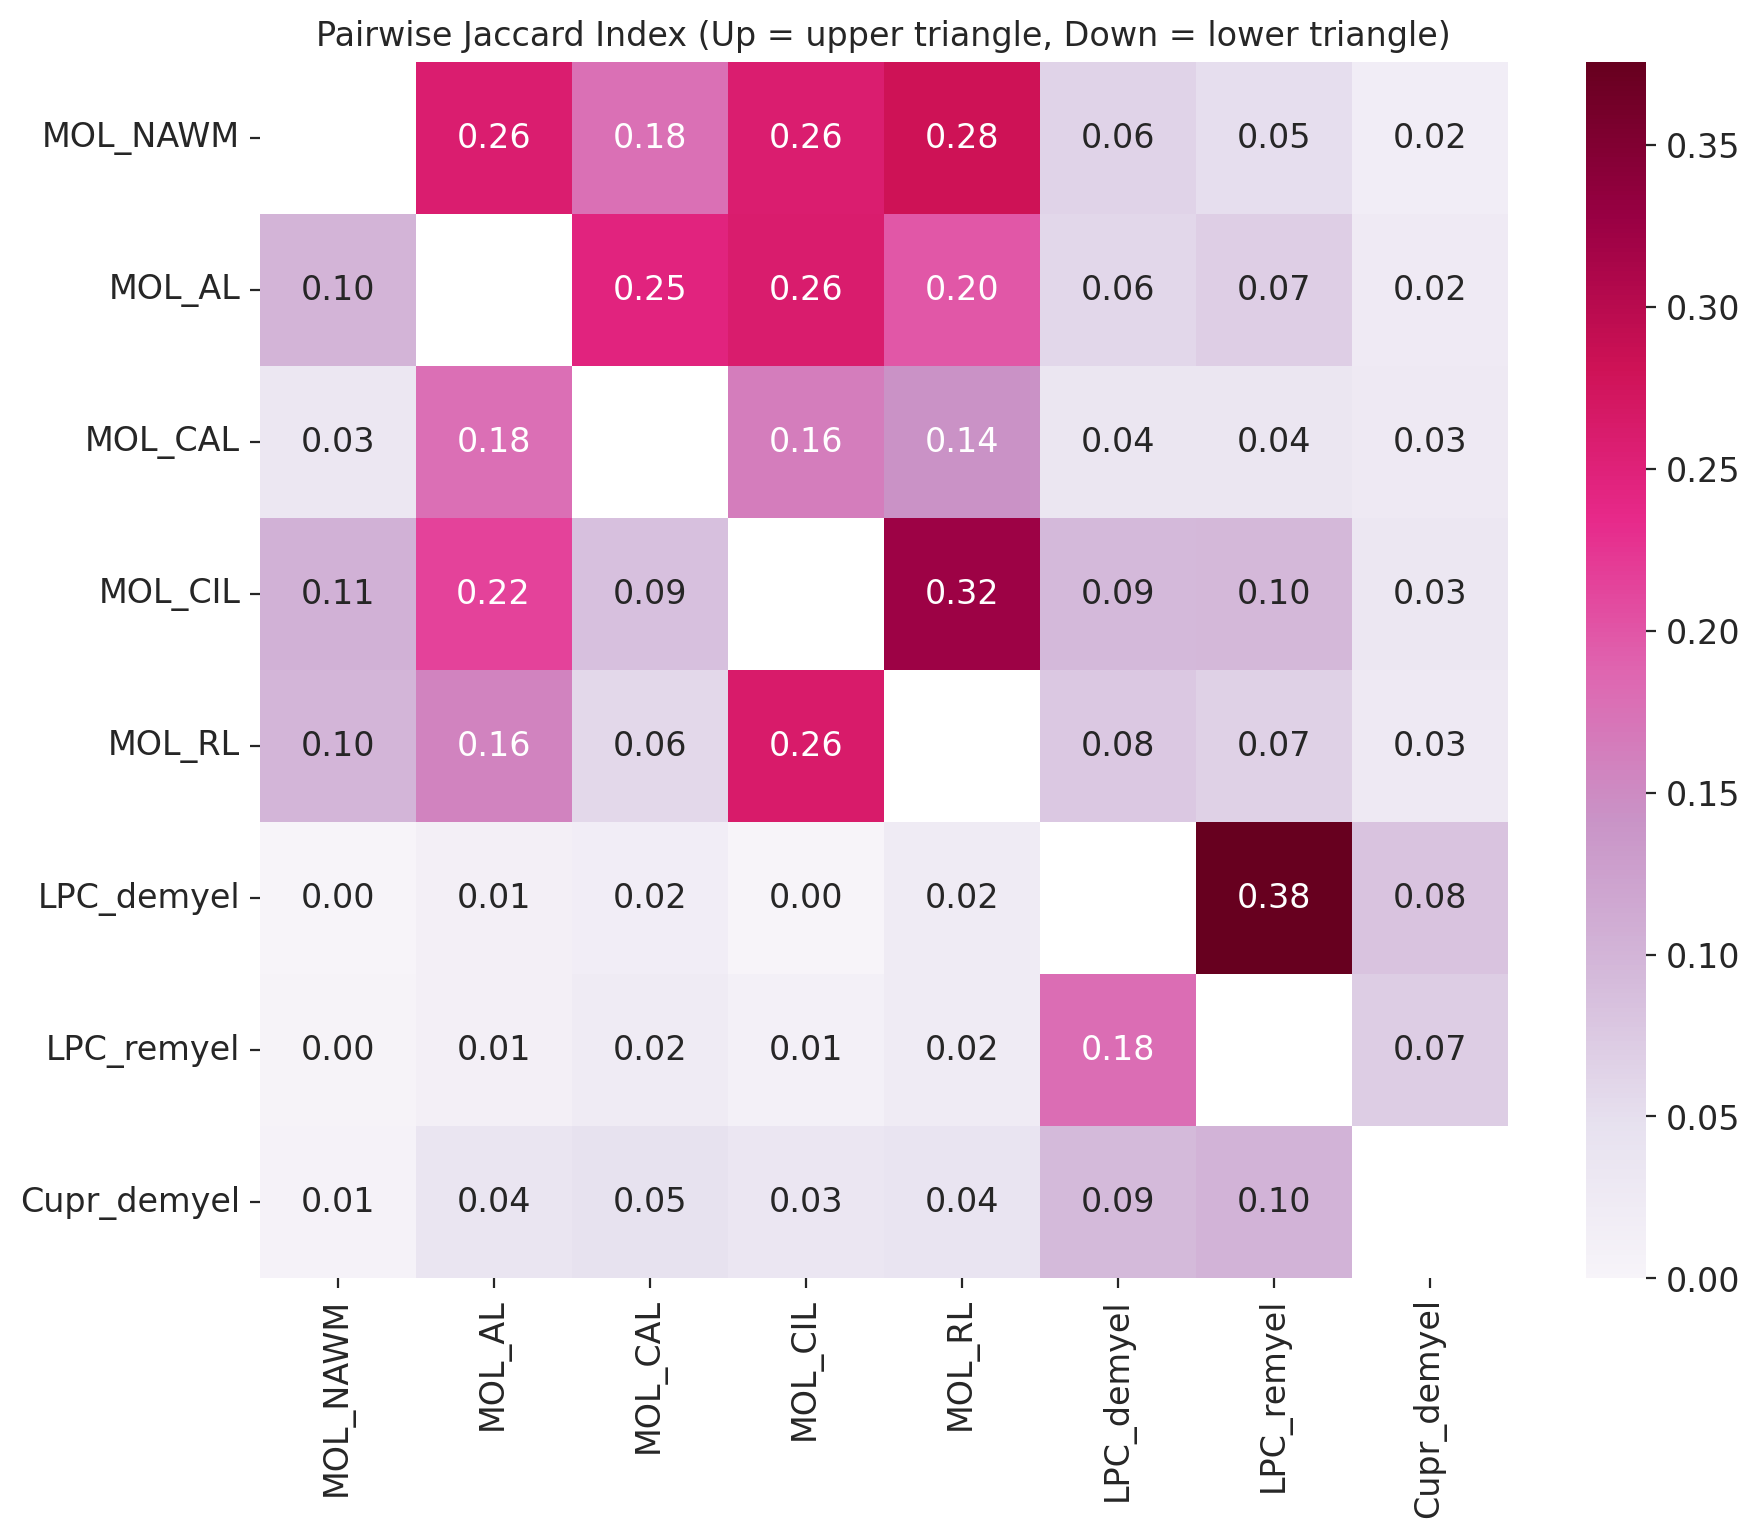

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- make square matrices ---
datasets = list(dfs.keys())
n = len(datasets)

# initialize with NaN
heatmap_matrix = pd.DataFrame(np.nan, index=datasets, columns=datasets)

# fill upper triangle with jaccard_up, lower triangle with jaccard_down
for _, row in jaccard_spearman_degs_df.iterrows():
    i, j = row['dataset1'], row['dataset2']
    heatmap_matrix.loc[i, j] = row['jaccard_up']       # upper triangle
    heatmap_matrix.loc[j, i] = row['jaccard_down']     # lower triangle

# plot
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="PuRd")
plt.title("Pairwise Jaccard Index (Up = upper triangle, Down = lower triangle)")
plt.grid(False)
plt.show()

## Switch to R

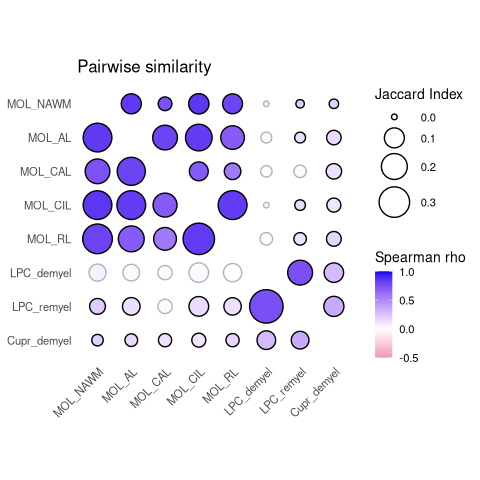

In [95]:
%%R -i jaccard_spearman_degs_df
dataset_order <- c("MOL_NAWM", "MOL_AL", "MOL_CAL", "MOL_CIL", "MOL_RL",
                   "LPC_demyel", "LPC_remyel", "Cupr_demyel")
# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)
# Prepare upper triangle (Jaccard Up) - original data
upper_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = jaccard_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )
# Prepare lower triangle (Jaccard Down) - SWAP x and y coordinates
lower_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],  # Swapped!
    y = dataset_index[dataset1],  # Swapped!
    size = jaccard_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )
# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)
# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)
# Convert x/y to factors
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_order),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_order),
    outline_color = ifelse(significant, "black", "grey70")
  )

plot_df_no_diag <- plot_df %>% filter(!is.na(size))

# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(-0.5, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Jaccard Index") +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "Pairwise similarity")

# Display the plot
print(p)

# Save the plot
ggsave("./figures/jaccard_spearman_plot.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

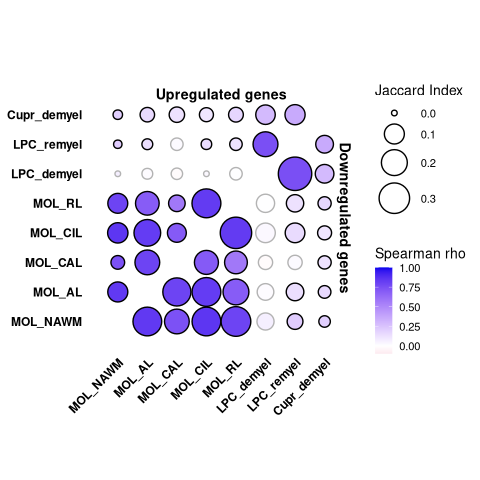

In [96]:
%%R -i jaccard_spearman_degs_df

dataset_order <- c("MOL_NAWM", "MOL_AL", "MOL_CAL", "MOL_CIL", "MOL_RL",
                   "LPC_demyel", "LPC_remyel", "Cupr_demyel")

# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)

# Prepare upper triangle (Jaccard Up) - SWAP to put in lower left
upper_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],  # Swapped!
    y = dataset_index[dataset1],  # Swapped!
    size = jaccard_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Prepare lower triangle (Jaccard Down) - original positions for upper right
lower_df <- jaccard_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = jaccard_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)

# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)

# Convert x/y to factors
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_order),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_order),
    outline_color = ifelse(significant, "black", "grey70")
  )

plot_df_no_diag <- plot_df %>% filter(!is.na(size))

# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(-0.1, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Jaccard Index") +
  scale_x_discrete(expand = expansion(add = 1)) +
  scale_y_discrete(expand = expansion(add = 1)) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "") +
  annotate("text", x = 4.5, y = 8.7, label = "Upregulated genes", 
           angle = 0, size = 5, fontface = "bold") +
  annotate("text", x = 8.7, y = 4.5, label = "Downregulated genes", 
           angle = 270, size = 5, fontface = "bold")

# Display the plot
print(p)

# Save the plot
ggsave("./figures/jaccard_spearman_plot_labeled.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

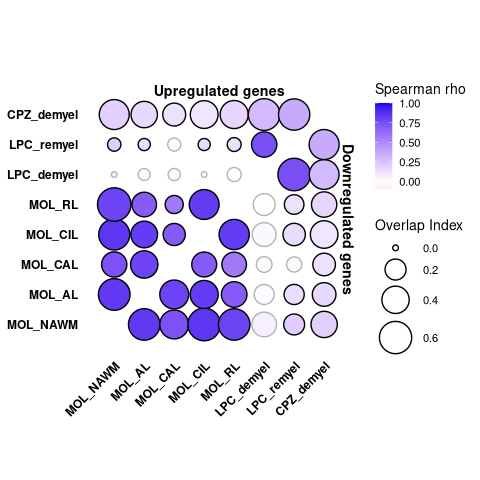

In [97]:
%%R -i overlap_spearman_degs_df

dataset_order <- c("MOL_NAWM", "MOL_AL", "MOL_CAL", "MOL_CIL", "MOL_RL",
                   "LPC_demyel", "LPC_remyel", "CPZ_demyel")

# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)

# Prepare upper triangle (Overlap Up) - SWAP to put in lower left
upper_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],  # Swapped!
    y = dataset_index[dataset1],  # Swapped!
    size = overlap_coeff_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Prepare lower triangle (Overlap Down) - original positions for upper right
lower_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = overlap_coeff_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)

# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)

# Convert x/y to factors
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_order),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_order),
    outline_color = ifelse(significant, "black", "grey70")
  )

plot_df_no_diag <- plot_df %>% filter(!is.na(size))

# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(-0.1, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Overlap Index") +
  scale_x_discrete(expand = expansion(add = 1)) +
  scale_y_discrete(expand = expansion(add = 1)) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "") +
  annotate("text", x = 4.5, y = 8.8, label = "Upregulated genes", 
           angle = 0, size = 5, fontface = "bold") +
  annotate("text", x = 8.8, y = 4.5, label = "Downregulated genes", 
           angle = 270, size = 5, fontface = "bold")

# Display the plot
print(p)

# Save the plot
ggsave("./figures/Overlap_spearman_plot_labeled.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

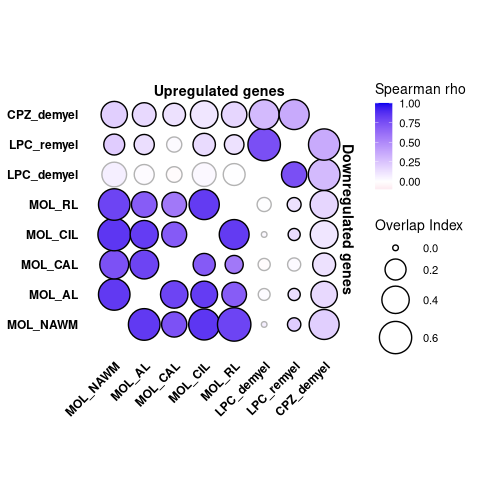

In [101]:
%%R -i overlap_spearman_degs_df

dataset_order <- c("MOL_NAWM", "MOL_AL", "MOL_CAL", "MOL_CIL", "MOL_RL",
                   "LPC_demyel", "LPC_remyel", "CPZ_demyel")

# Create numeric positions
dataset_index <- setNames(seq_along(dataset_order), dataset_order)

# Upper triangle (Overlap Up) - above diagonal
upper_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset1],
    y = dataset_index[dataset2],
    size = overlap_coeff_up,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Lower triangle (Overlap Down) - below diagonal
lower_df <- overlap_spearman_degs_df %>%
  filter(dataset1 != dataset2) %>%
  mutate(
    x = dataset_index[dataset2],
    y = dataset_index[dataset1],
    size = overlap_coeff_down,
    color = spearman_rho,
    significant = spearman_pval < 0.05
  )

# Create diagonal with NA size (won't be plotted)
diag_df <- data.frame(
  x = seq_along(dataset_order),
  y = seq_along(dataset_order),
  size = NA,
  color = 1,
  significant = FALSE
)

# Combine all data
plot_df <- bind_rows(upper_df, lower_df, diag_df)

# Convert x/y to factors
plot_df <- plot_df %>%
  mutate(
    x = factor(x, levels = seq_along(dataset_order), labels = dataset_order),
    y = factor(y, levels = seq_along(dataset_order), labels = dataset_order),
    outline_color = ifelse(significant, "black", "grey70")
  )

plot_df_no_diag <- plot_df %>% filter(!is.na(size))

# Create the plot object
p <- ggplot(plot_df_no_diag, aes(x = x, y = y)) +
  geom_point(aes(size = size, fill = color, color = outline_color), shape = 21, stroke = 1) +
  scale_color_identity() +
  scale_fill_gradient2(low = "#CD1076", mid = "white", high = "#0000EE", 
                       midpoint = 0, limits = c(-0.1, 1), name = "Spearman rho") +
  scale_size_continuous(range = c(2, 15), name = "Overlap Index") +
  scale_x_discrete(expand = expansion(add = 1)) +
  scale_y_discrete(expand = expansion(add = 1)) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  labs(title = "") +
  annotate("text", x = 4.5, y = 8.8, label = "Upregulated genes", 
           angle = 0, size = 5, fontface = "bold") +
  annotate("text", x = 8.8, y = 4.5, label = "Downregulated genes", 
           angle = 270, size = 5, fontface = "bold")

# Display the plot
print(p)

# Save the plot
ggsave("./figures/Overlap_spearman_plot_labeled.png", plot = p, 
       width = 7, height = 7, dpi = 300, bg = "white")

## Bar charts updated to reflect 

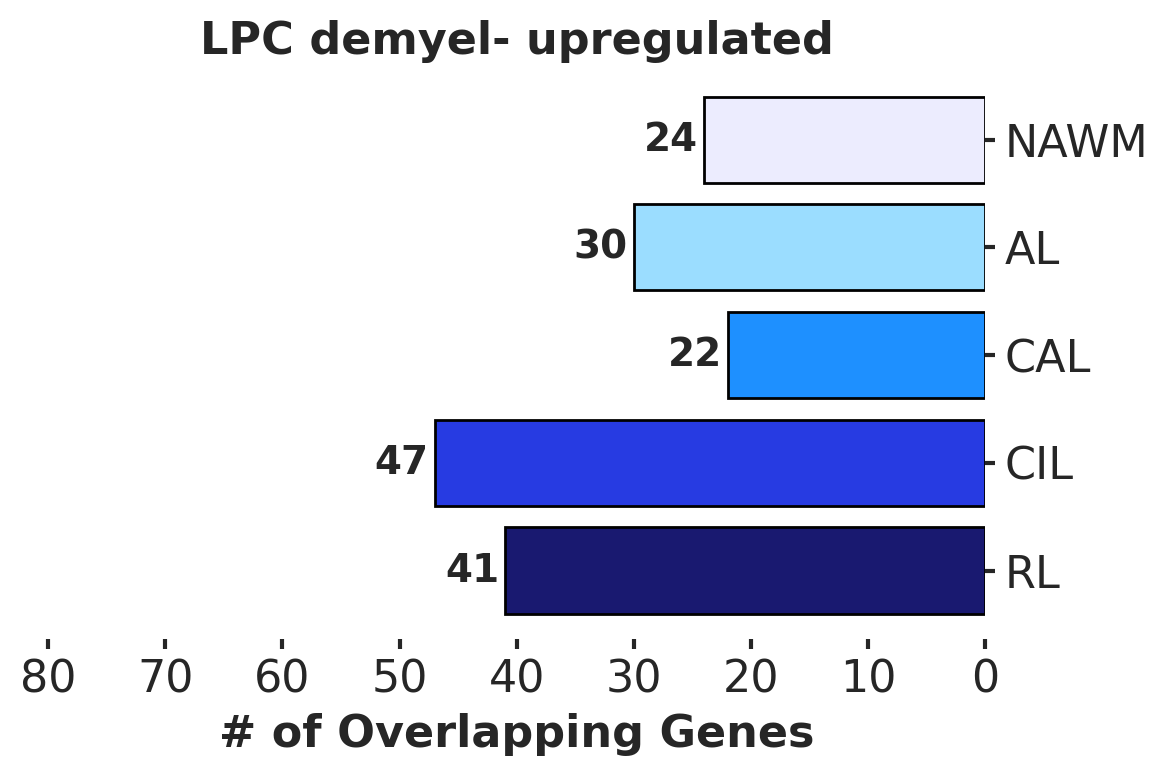

In [98]:
import seaborn as sns

# Lesion names and counts
lesions = ["NAWM", 'AL', 'CAL', 'CIL', 'RL']
gene_counts = [24, 30, 22, 47, 41]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(80, 0)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60', '70', '80'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel.png", dpi=300, bbox_inches='tight')

plt.show()

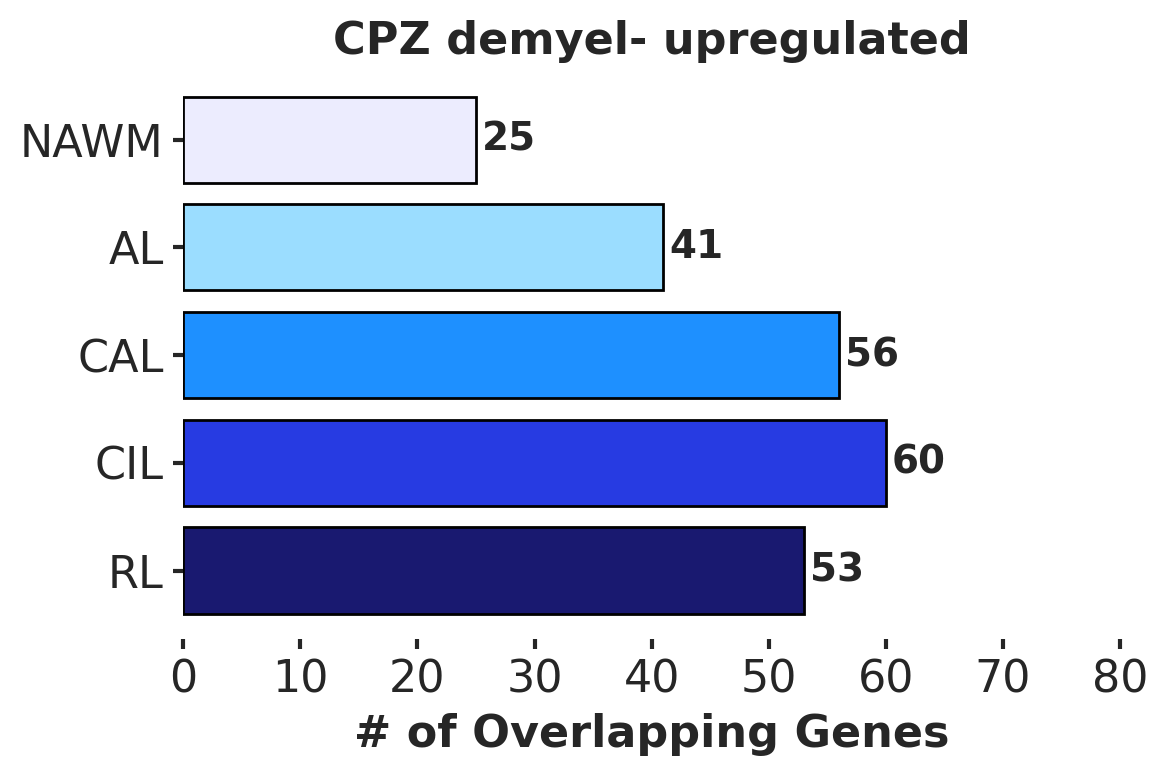

In [99]:
# Lesion names and CPZ counts
lesions = ['NAWM', 'AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [25, 41, 56, 60, 53]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 80)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60', '70', '80'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel.png", dpi=300, bbox_inches='tight')

plt.show()

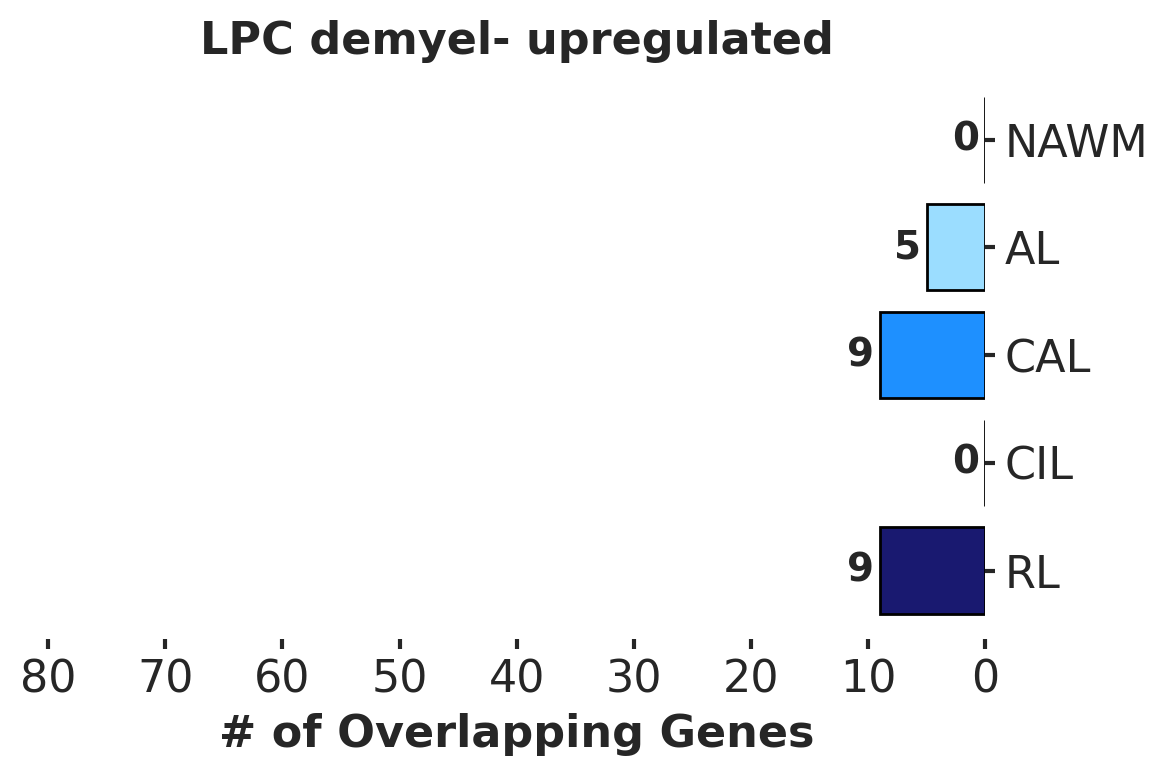

In [107]:
import seaborn as sns

# Lesion names and counts
lesions = ["NAWM", 'AL', 'CAL', 'CIL', 'RL']
gene_counts = [0, 5, 9, 0, 9]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(80, 0)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60', '70', '80'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel_down.png", dpi=300, bbox_inches='tight')

plt.show()

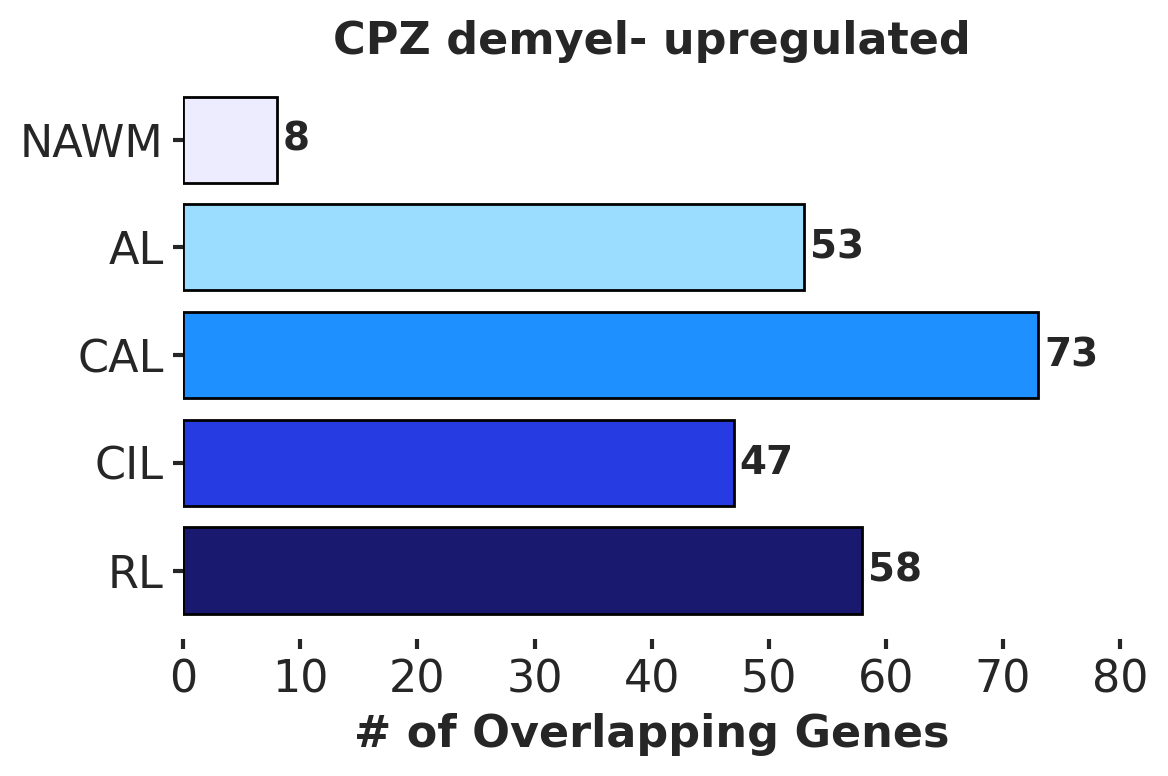

In [109]:
# Lesion names and CPZ counts
lesions = ['NAWM', 'AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [8, 53, 73, 47, 58]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 80)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60', '70', '80'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel_down.png", dpi=300, bbox_inches='tight')

plt.show()

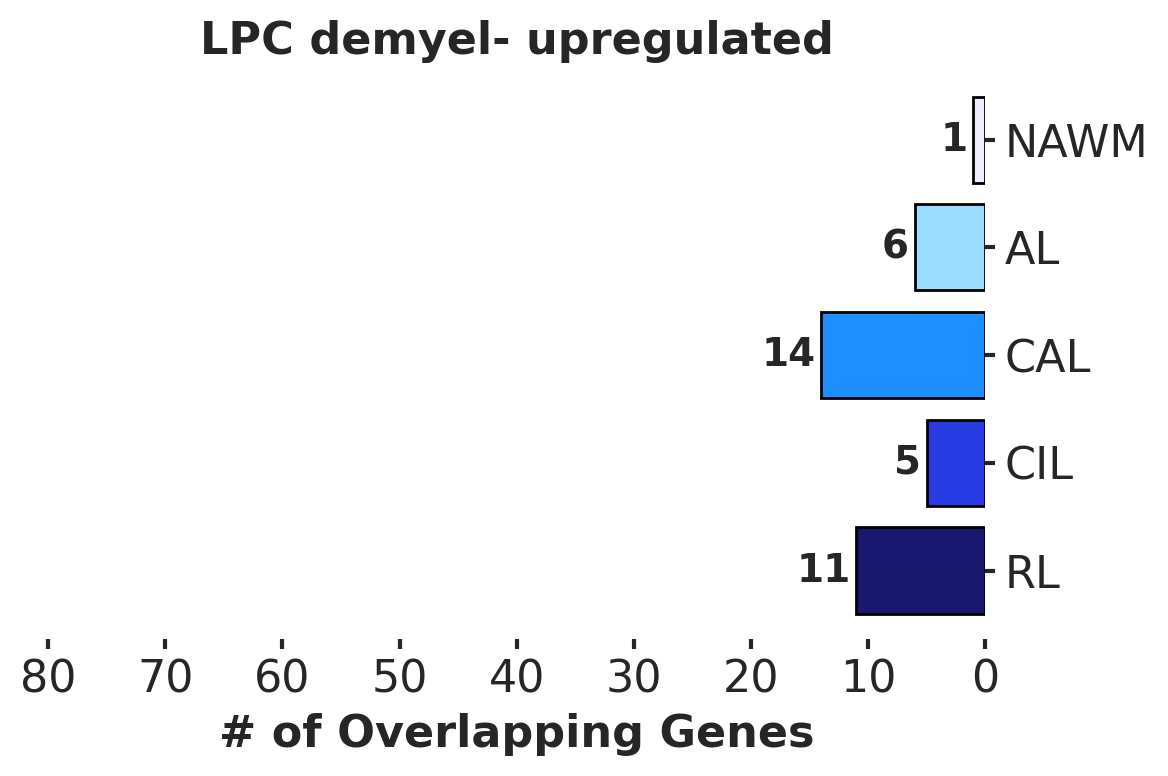

In [114]:
import seaborn as sns

# Lesion names and counts
lesions = ["NAWM", 'AL', 'CAL', 'CIL', 'RL']
gene_counts = [1, 6, 14, 5, 11]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(80, 0)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60', '70', '80'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel.png", dpi=300, bbox_inches='tight')

plt.show()

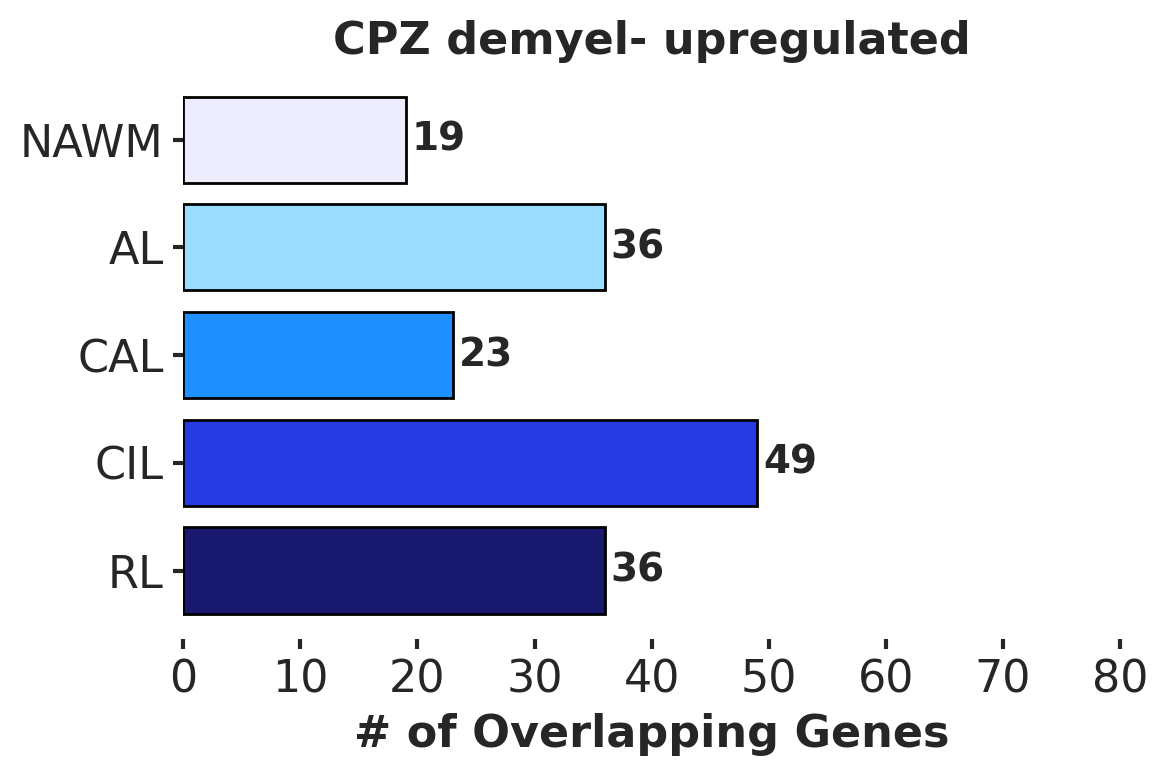

In [113]:
# Lesion names and CPZ counts
lesions = ['NAWM', 'AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [19, 36, 23, 49, 36]

# Colors for each lesion
lesion_colors = ["#ececfe", "#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(0, 80)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60', '70', '80'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel_down.png", dpi=300, bbox_inches='tight')

plt.show()

In [164]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_up = MOL_AL_up['gene'].tolist()
genes_MOL_CAL_all_up = MOL_CAL_up['gene'].tolist()
genes_MOL_CIL_all_up = MOL_CIL_up['gene'].tolist()
genes_MOL_RL_all_up = MOL_RL_up['gene'].tolist()

genes_LPC_demyel_all_up = LPC_demyel_up['gene_hs'].tolist()
genes_LPC_remyel_all_up = LPC_remyel_up['gene_hs'].tolist()
genes_Cupr_demyel_all_up = Cupr_demyel_up['gene_hs'].tolist()

In [165]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

In [166]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_down = MOL_AL_down['gene'].tolist()
genes_MOL_CAL_all_down = MOL_CAL_down['gene'].tolist()
genes_MOL_CIL_all_down = MOL_CIL_down['gene'].tolist()
genes_MOL_RL_all_down = MOL_RL_down['gene'].tolist()

genes_LPC_demyel_all_down = LPC_demyel_down['gene_hs'].tolist()
genes_LPC_remyel_all_down = LPC_remyel_down['gene_hs'].tolist()
genes_Cupr_demyel_all_down = Cupr_demyel_down['gene_hs'].tolist()

In [167]:
# Convert lists to sets for upregulated genes
set_MOL_AL_down_all = set(genes_MOL_AL_all_down)
set_MOL_CAL_down_all = set(genes_MOL_CAL_all_down)
set_MOL_CIL_down_all = set(genes_MOL_CIL_all_down)
set_MOL_RL_down_all = set(genes_MOL_RL_all_down)

set_LPC_demyel_all_down = set(genes_LPC_demyel_all_down)
set_LPC_remyel_all_down = set(genes_LPC_remyel_all_down)
set_Cupr_demyel_all_down = set(genes_Cupr_demyel_all_down)

In [172]:
# Union of AL, CAL, CIL, and RL upregulated genes
shared_all_MS = set_MOL_AL_up_all & set_MOL_CAL_up_all & set_MOL_CIL_up_all & set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
shared_all = shared_all_MS & set_Cupr_demyel_all_up & set_LPC_demyel_all_up

print("Number of overlapping upregulated genes (Cupr but not LPC):", len(shared_all))
print("Overlapping upregulated genes (Cupr but not LPC):", shared_all)

Number of overlapping upregulated genes (Cupr but not LPC): 4
Overlapping upregulated genes (Cupr but not LPC): {'C1orf21', 'ST8SIA5', 'RRAS2', 'LHFPL3'}


In [168]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_up) - set_LPC_demyel_all_up

print("Number of overlapping upregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping upregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

Number of overlapping upregulated genes (Cupr but not LPC): 100
Overlapping upregulated genes (Cupr but not LPC): {'KLHL21', 'ING1', 'TGFBR3', 'SLC1A4', 'DCXR', 'NUFIP2', 'GRWD1', 'PDGFC', 'ADGRG1', 'DDX27', 'PLCD3', 'PPM1E', 'CHMP1A', 'SLC35F1', 'LURAP1L', 'TRIB3', 'TMEM47', 'CASP7', 'CCDC117', 'PRKX', 'EFNB1', 'OTUD1', 'SESN2', 'KLF6', 'GUCY1B1', 'JUNB', 'EGR1', 'NDUFAF6', 'GZMM', 'PDE3A', 'KLF9', 'JADE2', 'KLF10', 'FRMD4A', 'MTA2', 'SGK1', 'SPATA1', 'MEPCE', 'BTG1', 'MPZL1', 'PROCA1', 'BORCS6', 'SOX21', 'ALG2', 'SORD', 'JMJD6', 'BRINP3', 'TCTN1', 'TCOF1', 'NGFR', 'POR', 'BCL2', 'MAFK', 'SLC6A15', 'EFCAB7', 'KHDRBS3', 'PDP1', 'ZSWIM1', 'RIMS2', 'ZSWIM4', 'CEBPG', 'IRF2BPL', 'SERTAD1', 'GFRA1', 'ZCCHC2', 'TENT4B', 'PRKD2', 'SPR', 'RPS6KA3', 'PLCB1', 'BANP', 'B9D2', 'EDA', 'RANGAP1', 'RORB', 'MAP1S', 'NOL12', 'PIP5K1B', 'ANAPC16', 'KLF15', 'ID4', 'FBXO6', 'RUNX2', 'MFGE8', 'MOXD1', 'ZCCHC3', 'SERPINH1', 'TXNDC5', 'RELA', 'ZFP36', 'GYS1', 'MED20', 'FOS', 'UBALD2', 'TAGLN2', 'OGFR', 'BAG

In [169]:
# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_up) - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cupr))
print("Overlapping upregulated genes (LPC but not CPZ):", overlap_lpc_not_cupr)

Number of overlapping upregulated genes (LPC but not CPZ): 40
Overlapping upregulated genes (LPC but not CPZ): {'MARK1', 'TNR', 'ANO3', 'GALNT18', 'GULP1', 'ITGA8', 'CSF1', 'FAM43A', 'NLRC5', 'COL27A1', 'SH3RF3', 'SORCS2', 'CHSY3', 'APOE', 'ELFN2', 'TMOD1', 'NAV2', 'CSMD2', 'SPSB1', 'ST3GAL1', 'ADRA1A', 'SMAD3', 'S100A10', 'CNTN3', 'TRPV4', 'PID1', 'IRF1', 'TNXB', 'RNF122', 'CERK', 'SEL1L3', 'HSD17B7', 'GDNF', 'ABHD4', 'NEBL', 'TSPAN9', 'GRM8', 'HERC6', 'EPHA4', 'KCNIP1'}


In [170]:
# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_up & set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC and CPZ):", len(overlap_lpc_and_cupr))
print("Overlapping upregulated genes (LPC and CPZ):", overlap_lpc_and_cupr)

Number of overlapping upregulated genes (LPC and CPZ): 34
Overlapping upregulated genes (LPC and CPZ): {'GRIK3', 'CRYZ', 'VIM', 'TRAM2', 'PLAT', 'TLE3', 'VAT1', 'RRAS2', 'CDKN1A', 'PROS1', 'ANXA2', 'NRCAM', 'NTRK2', 'SYNE2', 'CCND1', 'ASNS', 'KCNIP3', 'CEBPD', 'PCDH7', 'CHL1', 'PCDHB16', 'LHFPL3', 'AMOTL1', 'ST8SIA5', 'CAV2', 'GADD45B', 'TENT5A', 'SOCS3', 'LMNA', 'VAV3', 'IRF9', 'C1orf21', 'NAV3', 'PHLDA1'}


In [173]:
# Union of AL, CAL, CIL, and RL downregulated genes
shared_all_MS = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
shared_all = shared_all_MS & set_Cupr_demyel_all_down & set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cdownr but not LPC):", len(shared_all))
print("Overlapping downregulated genes (Cdownr but not LPC):", shared_all)

Number of overlapping downregulated genes (Cdownr but not LPC): 0
Overlapping downregulated genes (Cdownr but not LPC): set()


In [174]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_cdownr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_down) - set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cdownr but not LPC):", len(overlap_cdownr_not_lpc))
print("Overlapping downregulated genes (Cdownr but not LPC):", overlap_cdownr_not_lpc)

Number of overlapping downregulated genes (Cdownr but not LPC): 137
Overlapping downregulated genes (Cdownr but not LPC): {'SMIM1', 'NT5E', 'NRTN', 'MAN2A2', 'CAMK1', 'ALDH5A1', 'SSPN', 'VLDLR', 'MGAT5', 'MAG', 'PER3', 'SVIL', 'B3GALNT1', 'NFE2L3', 'LAPTM4B', 'LPAR1', 'KCTD16', 'RAB7B', 'E2F3', 'DNAH14', 'DDAH2', 'SHROOM2', 'TPPP3', 'S100B', 'TMEM258', 'SCG5', 'GRM7', 'NUDT14', 'OMG', 'LIMK2', 'GJB1', 'SH3GL2', 'PLEKHG1', 'MACROD2', 'FBXO2', 'ADAMTS4', 'NAALADL2', 'MRTFB', 'PCOLCE2', 'ITGAV', 'AMZ1', 'ERI2', 'SEZ6L2', 'C4orf19', 'PLEKHA2', 'RASAL1', 'TRAF5', 'SYNJ2', 'LCTL', 'UQCR11', 'ATG10', 'LURAP1', 'EVI2A', 'VAMP5', 'TRIM36', 'TEX52', 'LRRC4B', 'STX4', 'C1orf54', 'PLEKHG3', 'TMEM63A', 'CARNS1', 'TMPRSS11D', 'PTPDC1', 'PIK3IP1', 'LDLRAD4', 'TMEM163', 'PPP1R14A', 'DAD1', 'LRMDA', 'TDO2', 'TLE2', 'FMN1', 'SLC25A45', 'ARHGAP33', 'GNPTAB', 'ERBB3', 'WNT3', 'NKX2-8', 'RPS6KL1', 'HEG1', 'AVEN', 'GRIK4', 'PSD3', 'STMN4', 'HIVEP3', 'LYPD6', 'LRRTM3', 'S100A1', 'IL12RB1', 'EFS', 'RAB33A', '

In [175]:
# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_not_cdownr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_down) - set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cdownr))
print("Overlapping downregulated genes (LPC but not CPZ):", overlap_lpc_not_cdownr)

Number of overlapping downregulated genes (LPC but not CPZ): 7
Overlapping downregulated genes (LPC but not CPZ): {'SLC16A1', 'SVEP1', 'TBXAS1', 'LMNTD1', 'FBXO7', 'GREB1L', 'ADGRG2'}


In [176]:
# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_and_cdownr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_down & set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC and CPZ):", len(overlap_lpc_and_cdownr))
print("Overlapping downregulated genes (LPC and CPZ):", overlap_lpc_and_cdownr)

Number of overlapping downregulated genes (LPC and CPZ): 12
Overlapping downregulated genes (LPC and CPZ): {'SLC6A1', 'EPDR1', 'GPLD1', 'ADGRV1', 'PLEKHH1', 'SLC5A11', 'AMPH', 'DGKD', 'BCHE', 'TRIM59', 'PLAGL1', 'PRTG'}


# Correlate gene expression?

In [80]:
print(oto_orthologues.head())

            eid_hs  gene_hs              eid_mm  gene_mm
0  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8


In [104]:
# Read the CSV file
merged_df = pd.read_csv("/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_updated/merged_deg_expression_df.csv")

# Display the first few rows
merged_df.head()
print(merged_df.shape)

(6144, 28)


In [105]:
# Read the CSV file
merged_df_mm = pd.read_csv("/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/UPDATED_COMBINED_ANALYSIS/merged_deg_expression_df.csv")

# Display the first few rows
merged_df_mm.head()
print(merged_df_mm.shape)

(6391, 19)


In [99]:
merged_df = merged_df.merge(
    oto_orthologues[['gene_hs', 'gene_mm']],
    how='left',
    left_on='gene',
    right_on='gene_hs'
)

In [100]:
merged_df_mm = merged_df_mm.merge(
    oto_orthologues[['gene_hs', 'gene_mm']],
    how='left',
    left_on='gene',
    right_on='gene_mm'
)

In [101]:
# --- 3. Drop unmapped rows ---
merged_df = merged_df.dropna(subset=['gene_mm'])
merged_df_mm = merged_df_mm.dropna(subset=['gene_hs'])

# --- 4. Rename columns to prevent duplicate names ---
merged_df = merged_df.rename(columns={'gene': 'gene_hs_name'})
merged_df_mm = merged_df_mm.rename(columns={'gene': 'gene_mm_name'})

# --- 5. Merge the two DataFrames on shared human gene (gene_hs) ---
final_merged = pd.merge(
    merged_df,
    merged_df_mm,
    left_on='gene_hs',
    right_on='gene_hs',
    how='inner'
)

print(final_merged.head())

   Unnamed: 0_x gene_hs_name  logFC_NAWM  FDR_NAWM  logFC_AL    FDR_AL  \
0            13        AAMDC         NaN       NaN  0.051944  0.606157   
1            22         AATF    0.160647  0.258906       NaN       NaN   
2            26         ABAT    0.242707  0.236315  0.511304  0.016538   
3            33        ABCA5   -0.357693  0.001260 -0.558200  0.025174   
4            34        ABCA6    0.643219  0.402395  0.410456  0.619426   

   logFC_CAL   FDR_CAL  logFC_CIL   FDR_CIL  ...  DEG_Cupr_demyel  \
0   0.122334  0.213331   0.190893  0.051328  ...            False   
1   0.209599  0.355609   0.288866  0.031887  ...            False   
2        NaN       NaN   0.456780  0.030148  ...            False   
3  -0.370814  0.167708  -0.245450  0.111006  ...             True   
4   1.437733  0.042288   0.851718  0.136346  ...             True   

   Sig_LPC_demyel  Sig_LPC_remyel  Sig_Cupr_demyel  CPZ_baseline  CPZ_demyel  \
0             NaN             NaN              NaN      6.42

In [102]:
print(final_merged.columns.tolist())

['Unnamed: 0_x', 'gene_hs_name', 'logFC_NAWM', 'FDR_NAWM', 'logFC_AL', 'FDR_AL', 'logFC_CAL', 'FDR_CAL', 'logFC_CIL', 'FDR_CIL', 'logFC_RL', 'FDR_RL', 'DEG_NAWM', 'DEG_AL', 'DEG_CAL', 'DEG_CIL', 'DEG_RL', 'Sig_NAWM', 'Sig_AL', 'Sig_CAL', 'Sig_CIL', 'Sig_RL', 'AL', 'CAL', 'CIL', 'NAWM', 'RL', 'WM', 'gene_hs', 'gene_mm_x', 'Unnamed: 0_y', 'gene_mm_name', 'logFC_LPC_demyel', 'Padj_LPC_demyel', 'logFC_LPC_remyel', 'Padj_LPC_remyel', 'logFC_Cupr_demyel', 'Padj_Cupr_demyel', 'DEG_LPC_demyel', 'DEG_LPC_remyel', 'DEG_Cupr_demyel', 'Sig_LPC_demyel', 'Sig_LPC_remyel', 'Sig_Cupr_demyel', 'CPZ_baseline', 'CPZ_demyel', 'LPC_baseline', 'LPC_demyel', 'LPC_remyel', 'gene_mm_y']


In [103]:
print(final_merged.shape)

(1841, 50)


In [109]:
# Columns with log2(CPM+1) values
expr_cols = [
    'CPZ_baseline', 'CPZ_demyel', 'LPC_baseline', 'LPC_demyel', 'LPC_remyel',
    'AL', 'CAL', 'CIL', 'NAWM', 'RL', 'WM'
]

# Subset final_merged
expr_df = final_merged[expr_cols]

# Ensure genes are the index
expr_df.index = final_merged['gene_hs']  # or 'gene' if that’s the gene column
expr_df = expr_df[expr_cols]  # only expression columns

print(expr_df.head())

         CPZ_baseline  CPZ_demyel  LPC_baseline  LPC_demyel  LPC_remyel  \
gene_hs                                                                   
AAMDC        6.422206    6.329089      6.252859    6.548611    6.748259   
AATF         5.427568    5.518788      5.627018    5.267482    5.097125   
ABAT         4.049043    3.723943      4.427953    4.115647    3.884963   
ABCA5        3.808914    4.929784      4.268631    4.864000    5.269164   
ABCA6        3.969648    2.712644      4.368981    3.913945    3.288513   

               AL       CAL       CIL      NAWM        RL        WM  
gene_hs                                                              
AAMDC    6.215070  6.309882  6.444829  6.271586  6.287085  6.042042  
AATF     6.243794  6.457083  6.267822  6.090807  6.218053  5.804860  
ABAT     5.768833  5.804336  5.913259  5.694571  5.674449  5.273349  
ABCA5    6.278101  6.377821  6.731690  6.553954  6.621367  7.002343  
ABCA6    7.036603  7.922178  7.358064  6.743857  6.943

In [111]:
# Each column is a vector of genes
spearman_col_corr = expr_df.corr(method='spearman')

print(spearman_col_corr)

              CPZ_baseline  CPZ_demyel  LPC_baseline  LPC_demyel  LPC_remyel  \
CPZ_baseline      1.000000    0.840843      0.977414    0.931940    0.910891   
CPZ_demyel        0.840843    1.000000      0.812821    0.852453    0.849696   
LPC_baseline      0.977414    0.812821      1.000000    0.943568    0.891791   
LPC_demyel        0.931940    0.852453      0.943568    1.000000    0.926965   
LPC_remyel        0.910891    0.849696      0.891791    0.926965    1.000000   
AL                0.587287    0.485133      0.613251    0.567164    0.491902   
CAL               0.586730    0.491731      0.611621    0.566646    0.493984   
CIL               0.591953    0.486065      0.618010    0.573287    0.499626   
NAWM              0.602676    0.498135      0.626607    0.583997    0.512011   
RL                0.595785    0.491264      0.619246    0.573774    0.503981   
WM                0.607042    0.487486      0.628650    0.585008    0.507802   

                    AL       CAL       

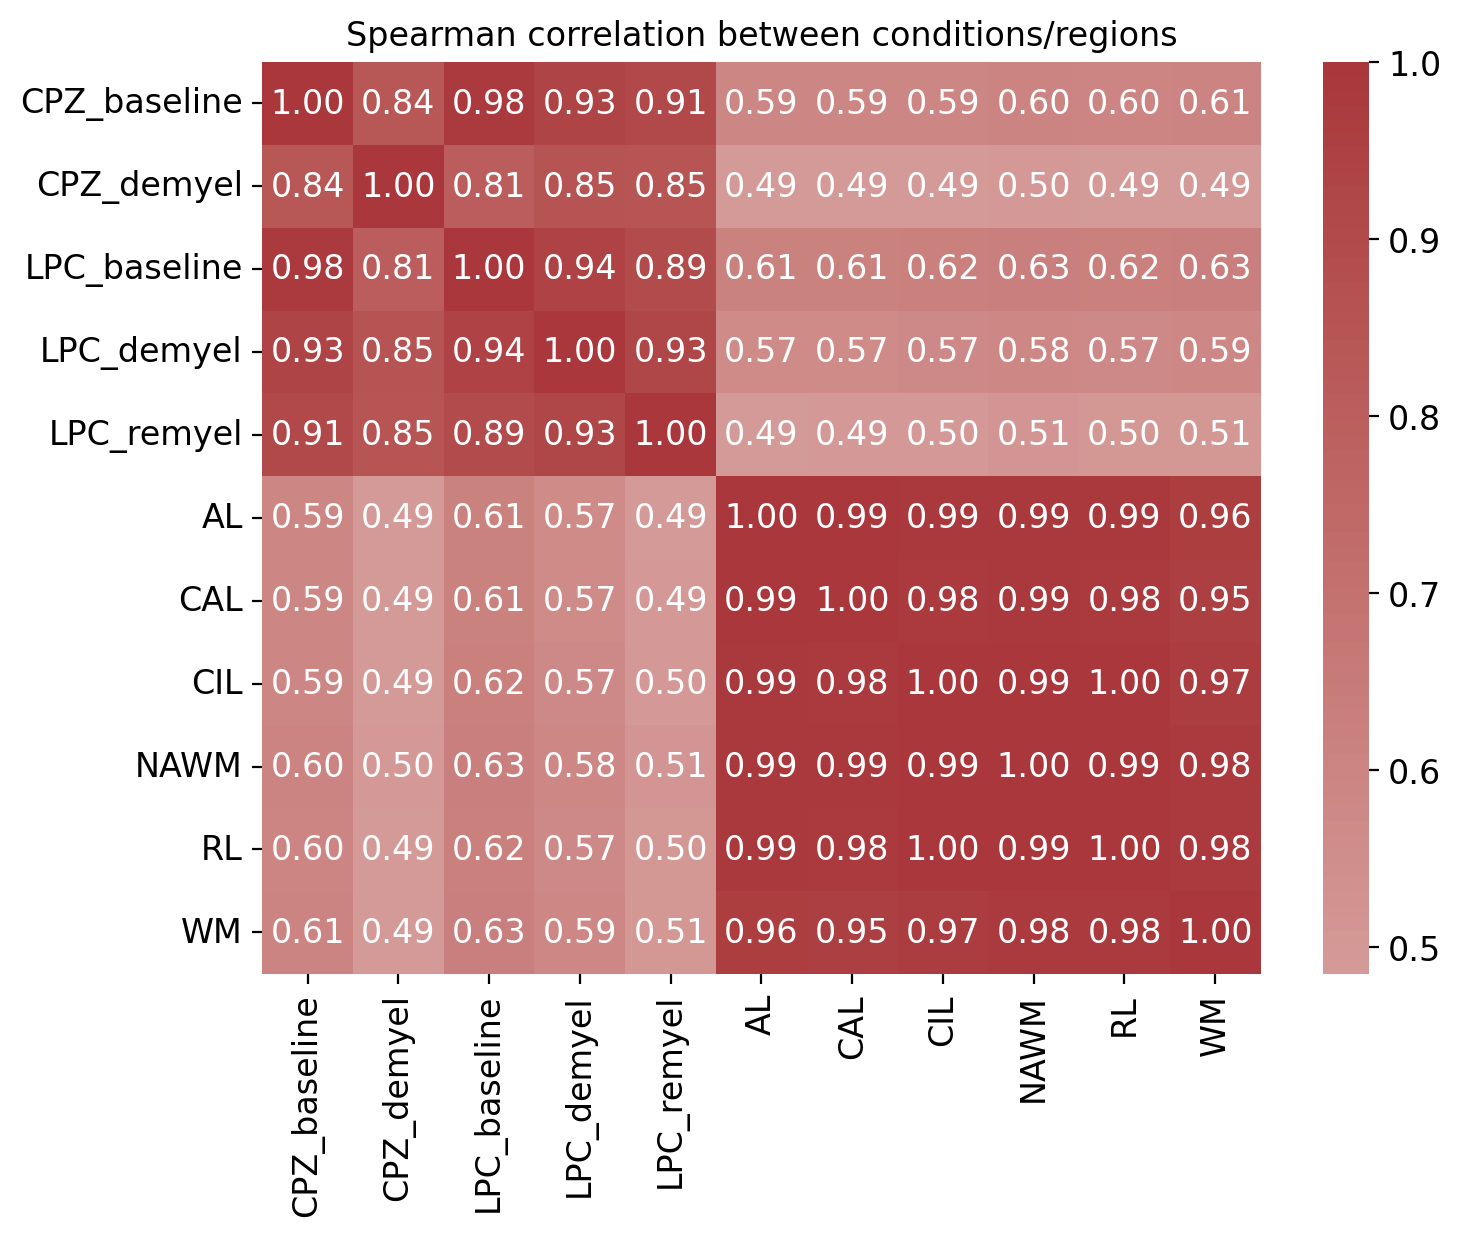

In [114]:
plt.figure(figsize=(8,6))
sns.heatmap(spearman_col_corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Spearman correlation between conditions/regions")
plt.grid(False)
plt.show()

# Original cell type specific DEGs?

In [115]:
MOL_AL = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_analysis/files/MOL_GvC_WM_v_AL_dream.csv', index_col=None)
MOL_AL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_AL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_AL.shape

(10487, 8)

In [116]:
MOL_RL = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/Human_scVI_single/DEG_analysis/files/MOL_GvC_WM_v_RL_dream.csv', index_col=None)
MOL_RL.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
MOL_RL.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
MOL_RL.shape

(12818, 9)

In [117]:
MOL_AL['logFC'] = MOL_AL['logFC'] * -1
MOL_AL[:5]

,gene,gene.1,logFC,AveExpr,t,Pvalue,Padj,B
0,FCHSD2,FCHSD2,-1.581572,8.619551,13.883072,1.396070e-15,1.464058e-11,25.108251
1,OPALIN,OPALIN,-3.605888,6.701410,12.501880,7.294486e-14,3.824864e-10,13.909813
2,KCNAB1,KCNAB1,-3.377023,5.981777,10.714100,1.899705e-12,5.260495e-09,18.037926
3,INPP5F,INPP5F,2.975575,6.433039,-11.694984,2.258445e-12,5.260495e-09,9.405133
4,ST8SIA5,ST8SIA5,3.377412,5.242225,-10.601996,2.508103e-12,5.260495e-09,18.047799


In [118]:
MOL_RL['logFC'] = MOL_RL['logFC'] * -1
MOL_RL[:5]

,gene,logFC,AveExpr,t,Pvalue,Padj,B,z.std,gene.1
0,FCHSD2,-2.157835,8.727854,17.221175,1.807438e-14,2.316774e-10,21.643558,7.663634,FCHSD2
1,KCNAB1,-4.466689,6.548477,12.991036,5.934711e-12,3.803556e-08,15.739906,6.881208,KCNAB1
2,AC022182.1,-2.425141,3.670108,11.280059,9.536502e-11,4.074630e-07,13.871828,6.474122,AC022182.1
3,PLPPR1,-2.145893,7.492648,11.587528,2.531274e-10,8.111468e-07,9.989267,6.325064,PLPPR1
4,MMP17,-3.519112,2.405612,8.706449,1.340425e-08,3.389688e-05,1.481296,5.680830,MMP17


In [119]:
# Merge the dataframes
MOL_AL = MOL_AL.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_AL = MOL_AL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
MOL_AL['logFC'] = MOL_AL['logFC'].astype(float)
MOL_AL['Padj'] = MOL_AL['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_AL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_AL.shape}")
MOL_AL = MOL_AL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_AL.shape}")

The number of NaN values in the 'gene_hs' column is: 2092
Shape with NaN: (10487, 9)
Shape after trimming: (8395, 9)


In [120]:
# Merge the dataframes
MOL_RL = MOL_RL.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_hs',
                      how='left')

# Select only the desired columns and rename if necessary
MOL_RL = MOL_RL[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
MOL_RL['logFC'] = MOL_RL['logFC'].astype(float)
MOL_RL['Padj'] = MOL_RL['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = MOL_RL['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {MOL_RL.shape}")
MOL_RL = MOL_RL.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {MOL_RL.shape}")

The number of NaN values in the 'gene_hs' column is: 3134
Shape with NaN: (12818, 9)
Shape after trimming: (9684, 9)


In [127]:
MOL_RL

,gene,gene_hs,gene_mm,logFC,AveExpr,t,Pvalue,Padj,B
0,FCHSD2,FCHSD2,Fchsd2,-2.157835,8.727854,17.221175,1.807438e-14,2.316774e-10,21.643558
1,KCNAB1,KCNAB1,Kcnab1,-4.466689,6.548477,12.991036,5.934711e-12,3.803556e-08,15.739906
3,PLPPR1,PLPPR1,Plppr1,-2.145893,7.492648,11.587528,2.531274e-10,8.111468e-07,9.989267
4,MMP17,MMP17,Mmp17,-3.519112,2.405612,8.706449,1.340425e-08,3.389688e-05,1.481296
5,SF3A1,SF3A1,Sf3a1,0.833639,4.066929,-8.517618,1.681238e-08,3.389688e-05,9.685838
...,...,...,...,...,...,...,...,...,...
12812,LMAN1,LMAN1,Lman1,0.000194,5.867516,-0.001464,9.988493e-01,9.991384e-01,-6.281266
12813,ATP2A2,ATP2A2,Atp2a2,-0.000233,6.846882,0.001436,9.988694e-01,9.991384e-01,-5.998103
12814,LYPLAL1,LYPLAL1,Lyplal1,-0.001925,6.764862,0.001391,9.989045e-01,9.991384e-01,-4.668860
12815,KCTD6,KCTD6,Kctd6,0.000261,4.251262,-0.000917,9.992785e-01,9.994345e-01,-5.458524


In [121]:
LPC_demyel_E = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/FINAL_sep/files/LPC_demyel_MOL_BvE_voom_wqw_REDO.csv', index_col=None)
LPC_demyel_E.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_demyel_E.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_demyel_E.shape

(9058, 7)

In [122]:
LPC_remyel_E = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/FINAL_sep/files/LPC_remyel_MOL_BvE_voom_wqw.csv', index_col=None)
LPC_remyel_E.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
LPC_remyel_E.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
LPC_remyel_E.shape

(11337, 7)

In [123]:
Cupr_demyel_G = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI/DEG_analysis/NEW_OL_DEG/FINAL_sep/files/Cupr_demyel_MOL_AvG_voom_wqw_NEW.csv', index_col=None)
Cupr_demyel_G.rename(columns={'adj.P.Val': 'Padj'}, inplace=True)
Cupr_demyel_G.rename(columns={'P.Value': 'Pvalue'}, inplace=True)
Cupr_demyel_G.shape

(5144, 7)

In [124]:
# Merge the dataframes
LPC_demyel_E = LPC_demyel_E.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
LPC_demyel_E = LPC_demyel_E[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
LPC_demyel_E['logFC'] = LPC_demyel_E['logFC'].astype(float)
LPC_demyel_E['Padj'] = LPC_demyel_E['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = LPC_demyel_E['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {LPC_demyel_E.shape}")
LPC_demyel_E = LPC_demyel_E.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {LPC_demyel_E.shape}")

The number of NaN values in the 'gene_hs' column is: 1078
Shape with NaN: (9058, 9)
Shape after trimming: (7980, 9)


In [125]:
# Merge the dataframes
LPC_remyel_E = LPC_remyel_E.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
LPC_remyel_E = LPC_remyel_E[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
LPC_remyel_E['logFC'] = LPC_remyel_E['logFC'].astype(float)
LPC_remyel_E['Padj'] = LPC_remyel_E['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = LPC_remyel_E['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {LPC_remyel_E.shape}")
LPC_remyel_E = LPC_remyel_E.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {LPC_remyel_E.shape}")

The number of NaN values in the 'gene_hs' column is: 1904
Shape with NaN: (11337, 9)
Shape after trimming: (9433, 9)


In [126]:
# Merge the dataframes
Cupr_demyel = Cupr_demyel_G.merge(oto_orthologues,
                      left_on='gene',
                      right_on='gene_mm',
                      how='left')

# Select only the desired columns and rename if necessary
Cupr_demyel = Cupr_demyel[['gene', 'gene_hs', 'gene_mm', 'logFC', 'AveExpr', 't', 'Pvalue', 'Padj', 'B']]
Cupr_demyel['logFC'] = Cupr_demyel['logFC'].astype(float)
Cupr_demyel['Padj'] = Cupr_demyel['Padj'].astype(float)

# Count NaN values in the 'gene_hs' column
num_nans = Cupr_demyel['gene_hs'].isna().sum()
print(f"The number of NaN values in the 'gene_hs' column is: {num_nans}")

# Drop rows where 'gene_hs' is NaN
print(f"Shape with NaN: {Cupr_demyel.shape}")
Cupr_demyel = Cupr_demyel.dropna(subset=['gene_hs'])
print(f"Shape after trimming: {Cupr_demyel.shape}")

The number of NaN values in the 'gene_hs' column is: 477
Shape with NaN: (5144, 9)
Shape after trimming: (4667, 9)


In [128]:
dfs = {
    "MOL_AL": MOL_AL,
    "MOL_RL": MOL_RL,
    "LPC_demyel_E": LPC_demyel,
    "LPC_remyel_E": LPC_remyel,
    "Cupr_demyel": Cupr_demyel
}

# --- thresholds ---
alpha = 0.05
lfc_up = 0.585
lfc_down = -0.585

# --- helper to find adjusted-p column automatically ---
def get_p_col(df):
    for c in ["Padj", "FDR", "adj.P.Val", "qval"]:
        if c in df.columns:
            return c
    raise ValueError(f"No adjusted p-value column found in {df.columns}")

# --- apply classification ---
for name, df in dfs.items():
    p_col = get_p_col(df)
    df["direction"] = "ns"  # default not significant
    
    df.loc[(df["logFC"] >= lfc_up) & (df[p_col] < alpha), "direction"] = "up"
    df.loc[(df["logFC"] <= lfc_down) & (df[p_col] < alpha), "direction"] = "down"
    
    print(f"{name}: up={sum(df['direction']=='up')}, down={sum(df['direction']=='down')}, ns={sum(df['direction']=='ns')}")

MOL_AL: up=813, down=439, ns=7143
MOL_RL: up=299, down=230, ns=9155
LPC_demyel_E: up=455, down=286, ns=8721
LPC_remyel_E: up=455, down=343, ns=9527
Cupr_demyel: up=525, down=752, ns=3390


In [129]:
pairs = list(itertools.combinations(dfs.keys(), 2))
results = []

for a, b in pairs:
    df1 = dfs[a]
    df2 = dfs[b]
    
    # pairwise universe
    genes_pair = set(df1['gene_hs']).intersection(df2['gene_hs'])
    
    # up
    up1 = set(df1.loc[(df1['direction']=='up') & (df1['gene_hs'].isin(genes_pair)), 'gene_hs'])
    up2 = set(df2.loc[(df2['direction']=='up') & (df2['gene_hs'].isin(genes_pair)), 'gene_hs'])
    up_shared = len(up1 & up2)
    up_union = len(up1 | up2)
    j_up = up_shared / up_union if up_union > 0 else 0
    
    # down
    down1 = set(df1.loc[(df1['direction']=='down') & (df1['gene_hs'].isin(genes_pair)), 'gene_hs'])
    down2 = set(df2.loc[(df2['direction']=='down') & (df2['gene_hs'].isin(genes_pair)), 'gene_hs'])
    down_shared = len(down1 & down2)
    down_union = len(down1 | down2)
    j_down = down_shared / down_union if down_union > 0 else 0
    
    # combined
    combined1 = up1.union(down1)
    combined2 = up2.union(down2)
    combined_shared = len(combined1 & combined2)
    combined_union = len(combined1 | combined2)
    j_combined = combined_shared / combined_union if combined_union > 0 else 0

    results.append({
        "dataset1": a,
        "dataset2": b,
        # Up counts
        "up_df1": len(up1),
        "up_df2": len(up2),
        "up_shared": up_shared,
        "up_union": up_union,
        "jaccard_up": j_up,
        # Down counts
        "down_df1": len(down1),
        "down_df2": len(down2),
        "down_shared": down_shared,
        "down_union": down_union,
        "jaccard_down": j_down,
        # Combined
        "combined_df1": len(combined1),
        "combined_df2": len(combined2),
        "combined_shared": combined_shared,
        "combined_union": combined_union,
        "jaccard_combined": j_combined
    })

jaccard_df = pd.DataFrame(results)
print(jaccard_df)

       dataset1      dataset2  up_df1  up_df2  up_shared  up_union  \
0        MOL_AL        MOL_RL     754     253        165       842   
1        MOL_AL  LPC_demyel_E     571     269         71       769   
2        MOL_AL  LPC_remyel_E     640     228         59       809   
3        MOL_AL   Cupr_demyel     194     435         34       595   
4        MOL_RL  LPC_demyel_E     225     314         35       504   
5        MOL_RL  LPC_remyel_E     245     275         25       495   
6        MOL_RL   Cupr_demyel      76     469         11       534   
7  LPC_demyel_E  LPC_remyel_E     439     356        217       578   
8  LPC_demyel_E   Cupr_demyel     143     518         30       631   
9  LPC_remyel_E   Cupr_demyel      86     521         17       590   

   jaccard_up  down_df1  down_df2  down_shared  down_union  jaccard_down  \
0    0.195962       439       197          123         513      0.239766   
1    0.092328       354       216           30         540      0.055556   
2

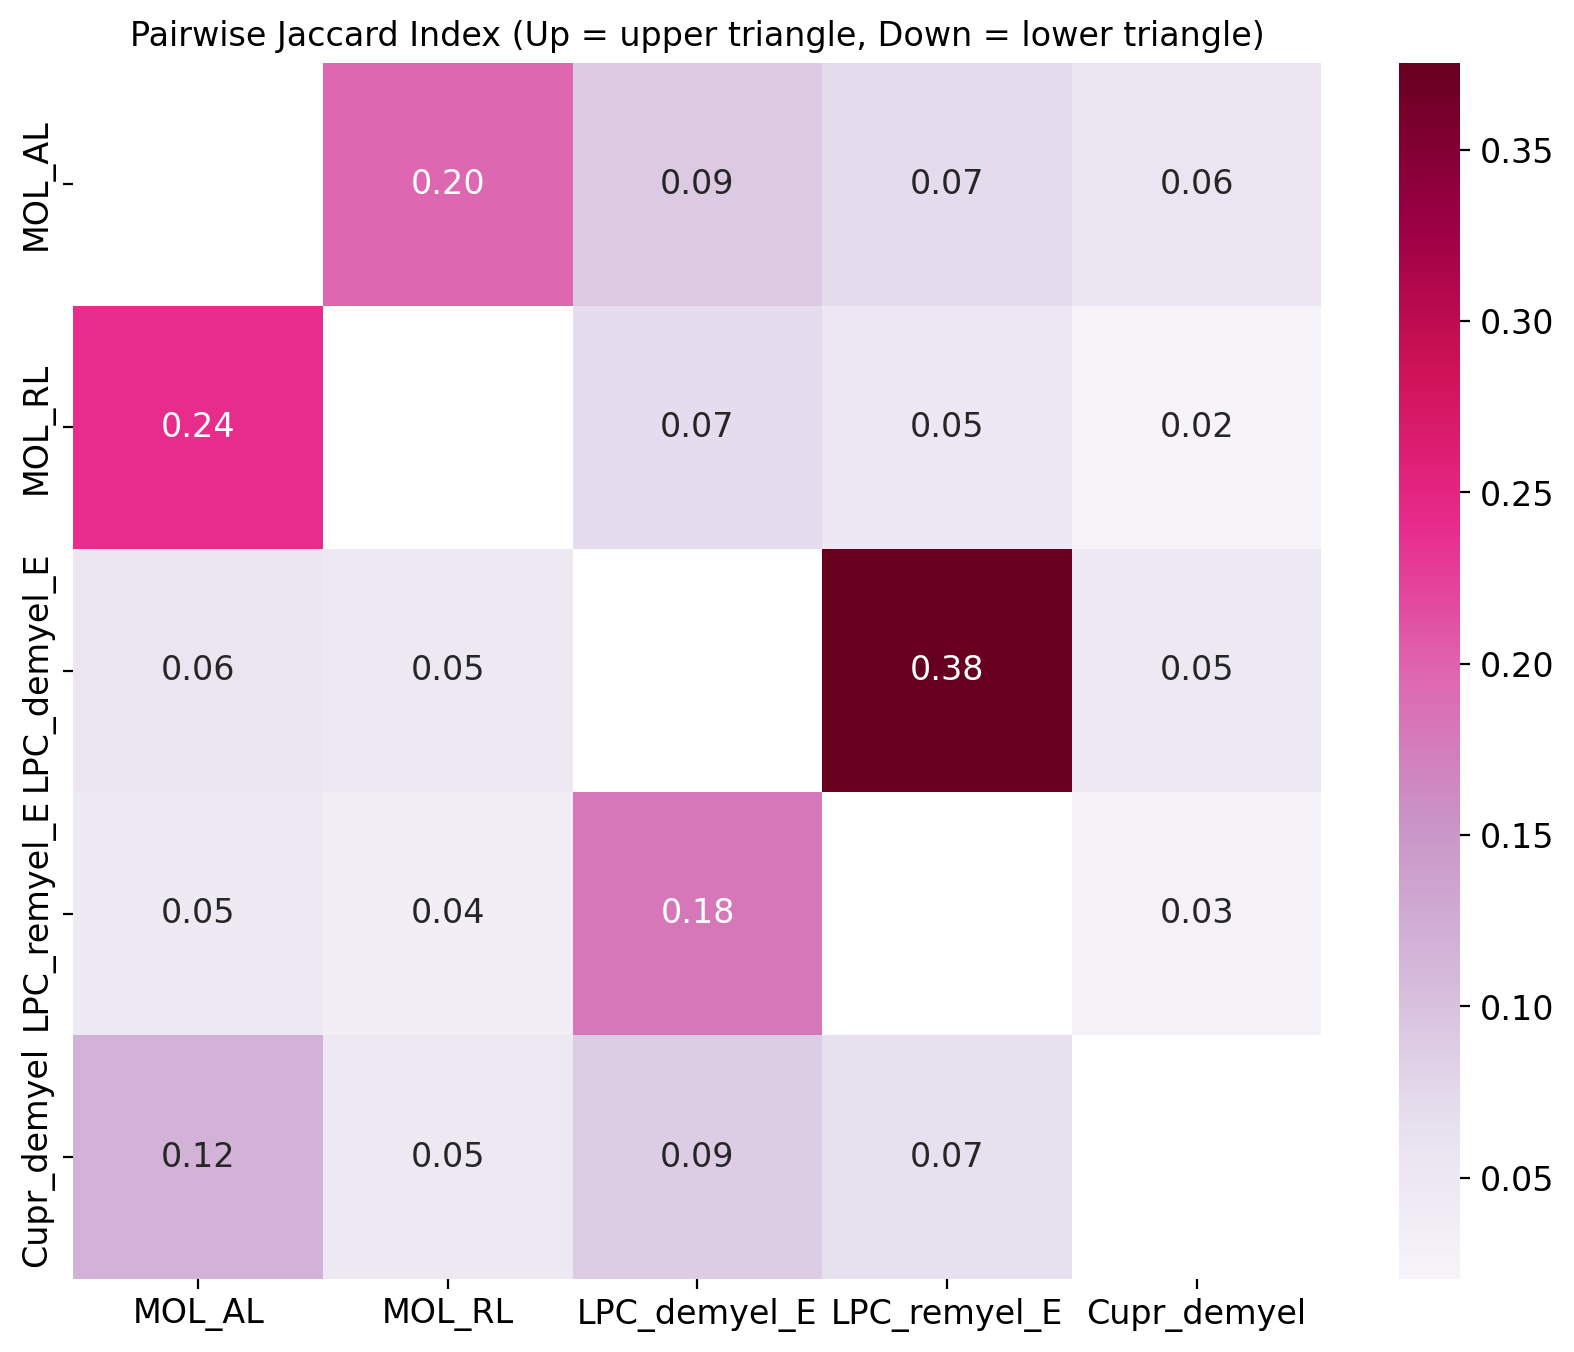

In [130]:
import seaborn as sns

# --- make square matrices ---
datasets = list(dfs.keys())
n = len(datasets)

# initialize with NaN
heatmap_matrix = pd.DataFrame(np.nan, index=datasets, columns=datasets)

# fill upper triangle with jaccard_up, lower triangle with jaccard_down
for _, row in jaccard_df.iterrows():
    i, j = row['dataset1'], row['dataset2']
    heatmap_matrix.loc[i, j] = row['jaccard_up']       # upper triangle
    heatmap_matrix.loc[j, i] = row['jaccard_down']     # lower triangle

# plot
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap="PuRd")
plt.title("Pairwise Jaccard Index (Up = upper triangle, Down = lower triangle)")
plt.grid(False)
plt.show()

In [ ]:
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"

# USE THIS

In [59]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

def plot_venn2_from_sets(set1, set2, 
                         set_labels=('Set 1', 'Set 2'), 
                         set_colors=('#a1c9f4', '#ffb482'), 
                         title='Venn Diagram',
                         alpha=0.8, 
                         font_size=16,
                         save_path=None):
    """
    Plots a 2-set Venn diagram and optionally saves it.

    Parameters:
    - set1, set2: Python sets to compare
    - set_labels: tuple of labels for the sets
    - set_colors: tuple of hex color codes
    - title: title of the plot
    - alpha: transparency of the Venn areas
    - font_size: base font size for text
    - save_path: full path (string) to save the figure, or None to not save
    """

    # Compute lengths
    only1 = len(set1 - set2)
    only2 = len(set2 - set1)
    both = len(set1 & set2)

    # Plot Venn
    venn = venn2(subsets=(only1, only2, both),
                 set_labels=set_labels,
                 set_colors=set_colors,
                 alpha=alpha)

    # Outline circles
    venn2_circles(subsets=(only1, only2, both), linewidth=1.5, color='black')

    # Style subset labels (inside circles)
    for label in venn.subset_labels:
        if label:
            label.set_fontsize(font_size)

    # Style set labels
    for label in venn.set_labels:
        if label:
            label.set_fontsize(font_size - 2)

    # Title and layout
    plt.title(title, fontsize=font_size)
    plt.tight_layout()

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')

    # Show plot
    plt.show()

In [60]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt

def plot_venn3_from_sets(set1, set2, set3, labels, colors, title, save_path=None):
    """
    Plots a 3-set Venn diagram with automatic circle and label styling.

    Parameters:
    - set1, set2, set3: sets of gene names
    - labels: tuple of 3 labels (str)
    - colors: tuple of 3 hex color strings
    - title: plot title (str)
    - save_path: optional path to save the figure (e.g., 'figs/my_venn.png')
    """
    # Compute subset sizes
    only1 = len(set1 - set2 - set3)
    only2 = len(set2 - set1 - set3)
    only3 = len(set3 - set1 - set2)

    shared12 = len(set1 & set2 - set3)
    shared13 = len(set1 & set3 - set2)
    shared23 = len(set2 & set3 - set1)

    shared123 = len(set1 & set2 & set3)

    subsets = (only1, only2, shared12, only3, shared13, shared23, shared123)

    # Plot Venn
    plt.figure(figsize=(6, 6))
    venn = venn3(
        subsets=subsets,
        set_labels=labels,
        set_colors=colors,
        alpha=0.8
    )

    # Circles
    circles = venn3_circles(subsets=subsets, linestyle='solid')
    for c in circles:
        if c:
            c.set_linewidth(1.5)
            c.set_edgecolor('black')

    # Fonts
    for subset in venn.subset_labels:
        if subset:
            subset.set_fontsize(16)

    for text in venn.set_labels:
        if text:
            text.set_fontsize(14)

    plt.title(title, fontsize=16)

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')
        print(f"Saved Venn diagram to: {save_path}")

    plt.show()

# Subset gene all list together?

In [111]:
## IMPORTANT FILTER FOR GENES TESTING IN ALL CONDITIONS

genes_all = set(MOL_AL['gene']) & \
                set(MOL_CAL['gene']) & \
                set(MOL_CIL['gene']) & \
                set(MOL_RL['gene']) & \
                set(Cupr_demyel['gene_hs']) & \
                set(LPC_demyel['gene_hs']) & \
                set(LPC_remyel['gene_hs'])


len(genes_all)

5966

In [112]:
'CD44' in genes_all

True

In [113]:
'SLC7A5' in genes_all

False

In [114]:
'CDKN1A' in genes_all

True

In [115]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all)]

# Apply filtering to each DEG DataFrame
MOL_AL_up_all = filter_genes(MOL_AL_up)
MOL_CAL_up_all = filter_genes(MOL_CAL_up)
MOL_CIL_up_all = filter_genes(MOL_CIL_up)
MOL_RL_up_all = filter_genes(MOL_RL_up)

print(MOL_AL_up_all.shape)
print(MOL_CAL_up_all.shape)
print(MOL_CIL_up_all.shape)
print(MOL_RL_up_all.shape)

# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene_hs'].isin(genes_all)]

Cupr_demyel_up_all = filter_genes(Cupr_demyel_up)
LPC_demyel_up_all = filter_genes(LPC_demyel_up)
LPC_remyel_up_all = filter_genes(LPC_remyel_up)

print(Cupr_demyel_up_all.shape)
print(LPC_demyel_up_all.shape)
print(LPC_remyel_up_all.shape)

(126, 5)
(185, 5)
(125, 5)
(139, 5)
(1245, 6)
(258, 6)
(206, 6)


In [116]:
Anxa2_row = LPC_demyel_up_all[LPC_demyel_up_all['gene'] == 'Anxa2']
print(Anxa2_row)

     gene gene_hs gene_mm     logFC   AveExpr      Padj
44  Anxa2   ANXA2   Anxa2  5.633982  3.106945  0.000005


In [67]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_up = MOL_AL_up_all['gene'].tolist()
genes_MOL_CAL_all_up = MOL_CAL_up_all['gene'].tolist()
genes_MOL_CIL_all_up = MOL_CIL_up_all['gene'].tolist()
genes_MOL_RL_all_up = MOL_RL_up_all['gene'].tolist()

genes_LPC_demyel_all_up = LPC_demyel_up_all['gene_hs'].tolist()
genes_LPC_remyel_all_up = LPC_remyel_up_all['gene_hs'].tolist()
genes_Cupr_demyel_all_up = Cupr_demyel_up_all['gene_hs'].tolist()

In [68]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

## Up upset plot- separately

In [69]:
# Create gene lists from the dfs:
genes_MOL_AL_all_up = MOL_AL_up_all['gene'].tolist()
genes_MOL_CAL_all_up = MOL_CAL_up_all['gene'].tolist()
genes_MOL_CIL_all_up = MOL_CIL_up_all['gene'].tolist()
genes_MOL_RL_all_up = MOL_RL_up_all['gene'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
MOL_AL_all_up_df = create_gene_df(genes_MOL_AL_all_up, 'MOL_AL_all_up')
MOL_CAL_all_up_df = create_gene_df(genes_MOL_CAL_all_up, 'MOL_CAL_all_up')
MOL_CIL_all_up_df = create_gene_df(genes_MOL_CIL_all_up, 'MOL_CIL_all_up')
MOL_RL_all_up_df = create_gene_df(genes_MOL_RL_all_up, 'MOL_RL_all_up')

# Create DataFrames for each gene list
MOL_AL_all_up_df = pd.DataFrame({'MOL_AL_all_up': True, 'Name': genes_MOL_AL_all_up})
MOL_CAL_all_up_df = pd.DataFrame({'MOL_CAL_all_up': True, 'Name': genes_MOL_CAL_all_up})
MOL_CIL_all_up_df = pd.DataFrame({'MOL_CIL_all_up': True, 'Name': genes_MOL_CIL_all_up})
MOL_RL_all_up_df = pd.DataFrame({'MOL_RL_all_up': True, 'Name': genes_MOL_RL_all_up})

In [70]:
# Create gene lists from the dfs:
genes_LPC_demyel_all_up = LPC_demyel_up_all['gene_hs'].tolist()
genes_LPC_remyel_all_up = LPC_remyel_up_all['gene_hs'].tolist()
genes_Cupr_demyel_all_up = Cupr_demyel_up_all['gene_hs'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
LPC_demyel_all_up_df = create_gene_df(genes_LPC_demyel_all_up, 'LPC_demyel_all_up')
LPC_remyel_all_up_df = create_gene_df(genes_LPC_remyel_all_up, 'LPC_remyel_all_up')
Cupr_demyel_all_up_df = create_gene_df(genes_Cupr_demyel_all_up, 'Cupr_demyel_all_up')

# Create DataFrames for each gene list using the new gene lists
#OPC_de_up_df = pd.DataFrame({'OPC_de_up': True, 'Name': genes_OPC_de_up})
LPC_demyel_all_up_df = pd.DataFrame({'LPC_demyel_all_up': True, 'Name': genes_LPC_demyel_all_up})
LPC_remyel_all_up_df = pd.DataFrame({'LPC_remyel_all_up': True, 'Name': genes_LPC_remyel_all_up})
Cupr_demyel_all_up_df = pd.DataFrame({'Cupr_demyel_all_up': True, 'Name': genes_Cupr_demyel_all_up})

In [71]:
# Hierarchically merge all the DataFrames on 'Gene'
up_df = MOL_AL_all_up_df.merge(
    MOL_CAL_all_up_df.merge(
        MOL_CIL_all_up_df.merge(
            MOL_RL_all_up_df.merge(
                LPC_demyel_all_up_df.merge(
                    Cupr_demyel_all_up_df, on='Name', how='outer'
                ), on='Name', how='outer'
            ), on='Name', how='outer'
        ), on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
up_df = up_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
up_df_plot = up_df.set_index([
    'MOL_AL_all_up', 'MOL_CAL_all_up', 'MOL_CIL_all_up', 'MOL_RL_all_up', 'LPC_demyel_all_up', 'Cupr_demyel_all_up'
])

# Print the final merged DataFrame
print("Upregulated genes across all conditions (hierarchically merged):")
print(up_df_plot)

Upregulated genes across all conditions (hierarchically merged):
                                                                                                   Name
MOL_AL_all_up MOL_CAL_all_up MOL_CIL_all_up MOL_RL_all_up LPC_demyel_all_up Cupr_demyel_all_up         
False         False          False          False         False             True                  AAGAB
                                                                            True                  ABCA1
                                                          True              True                  ABCA5
              True           False          False         False             False                 ABCA6
              False          False          False         False             True                  ABCE1
...                                                                                                 ...
                                                                            True                ZSCAN12

/tmp/2140472.1.long/ipykernel_1920231/3954829171.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  up_df = up_df.fillna(False)


In [72]:
# Dictionary to map old index names to new index names
index_name_map = {
    'MOL_AL_all_up': 'AL',
    'MOL_CAL_all_up': 'CAL',
    'MOL_CIL_all_up': 'CIL',
    'MOL_RL_all_up': 'RL',
    'LPC_demyel_all_up': 'LPC_demyel',
    'Cupr_demyel_all_up': 'CPZ_demyel',
}

# Rename the index levels using the dictionary
up_df_plot.index = up_df_plot.index.rename(index_name_map)

print("Updated Upregulated genes DataFrame:")
print(up_df_plot)

Updated Upregulated genes DataFrame:
                                                  Name
AL    CAL   CIL   RL    LPC_demyel CPZ_demyel         
False False False False False      True          AAGAB
                                   True          ABCA1
                        True       True          ABCA5
      True  False False False      False         ABCA6
      False False False False      True          ABCE1
...                                                ...
                                   True        ZSCAN12
                                   True        ZSCAN18
      True  False False False      True         ZSWIM1
True  False True  True  False      True         ZSWIM4
False False False False False      True            ZYX

[1610 rows x 1 columns]


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

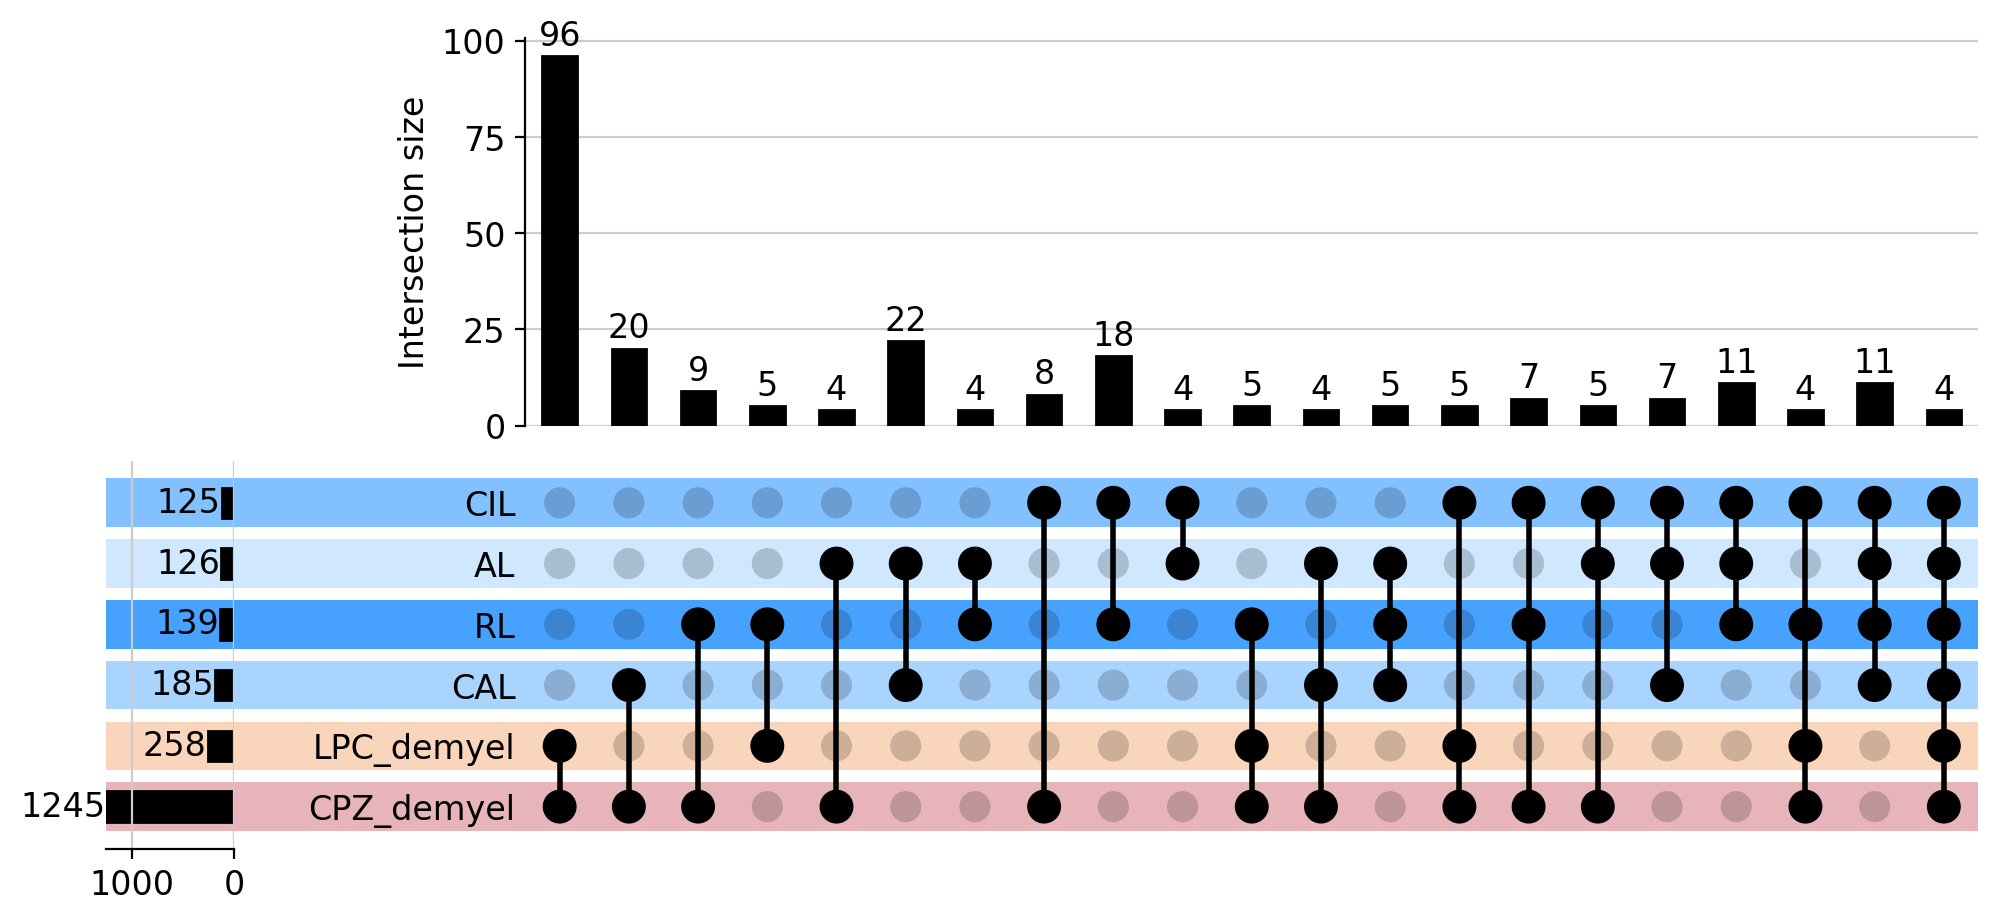

In [73]:
# Create UpSet plot
upset = UpSet(up_df_plot, subset_size='count', show_counts=True, facecolor="black", min_degree=2,
              min_subset_size=4)

# Style the subsets
upset.style_categories(
    'AL',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL',
    shading_facecolor="#47a2ff",
)

# Style the subsets
upset.style_categories(
    'LPC_demyel',
    shading_facecolor="#f9d5bb",
)

# Style the subsets
upset.style_categories(
    'CPZ_demyel',
    shading_facecolor="#e7b5b9",
)

#upset.style_subsets(present=["CPZ_demyel"], facecolor="#c5183b", label="CPZ overlap")
#upset.style_subsets(present=["CPZ_demyel"], edgecolor="#e12f54", linewidth=4)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
#plt.savefig('./figures/upset_plot_MOL_hs_mm_Cupr_overlap_up_n3_revision.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [74]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

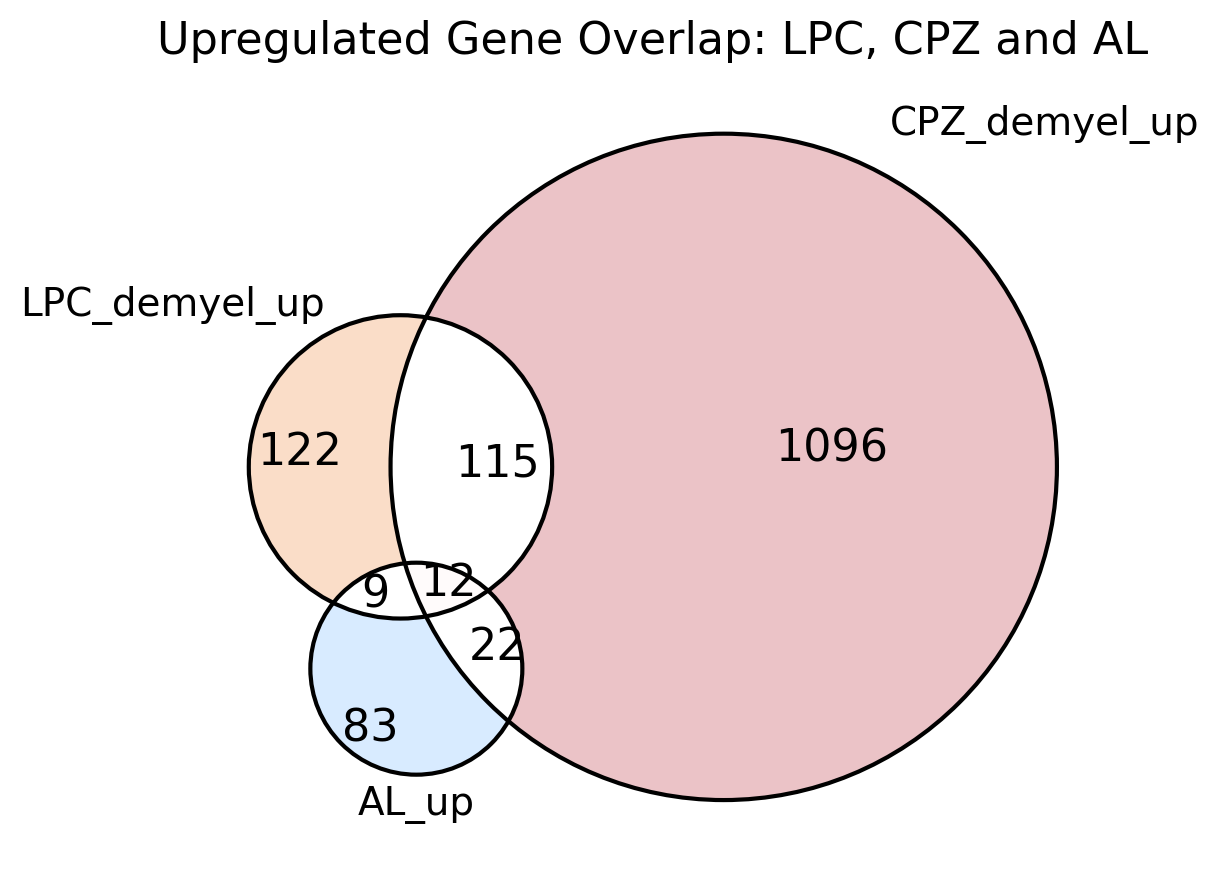

In [81]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_AL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'AL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and AL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

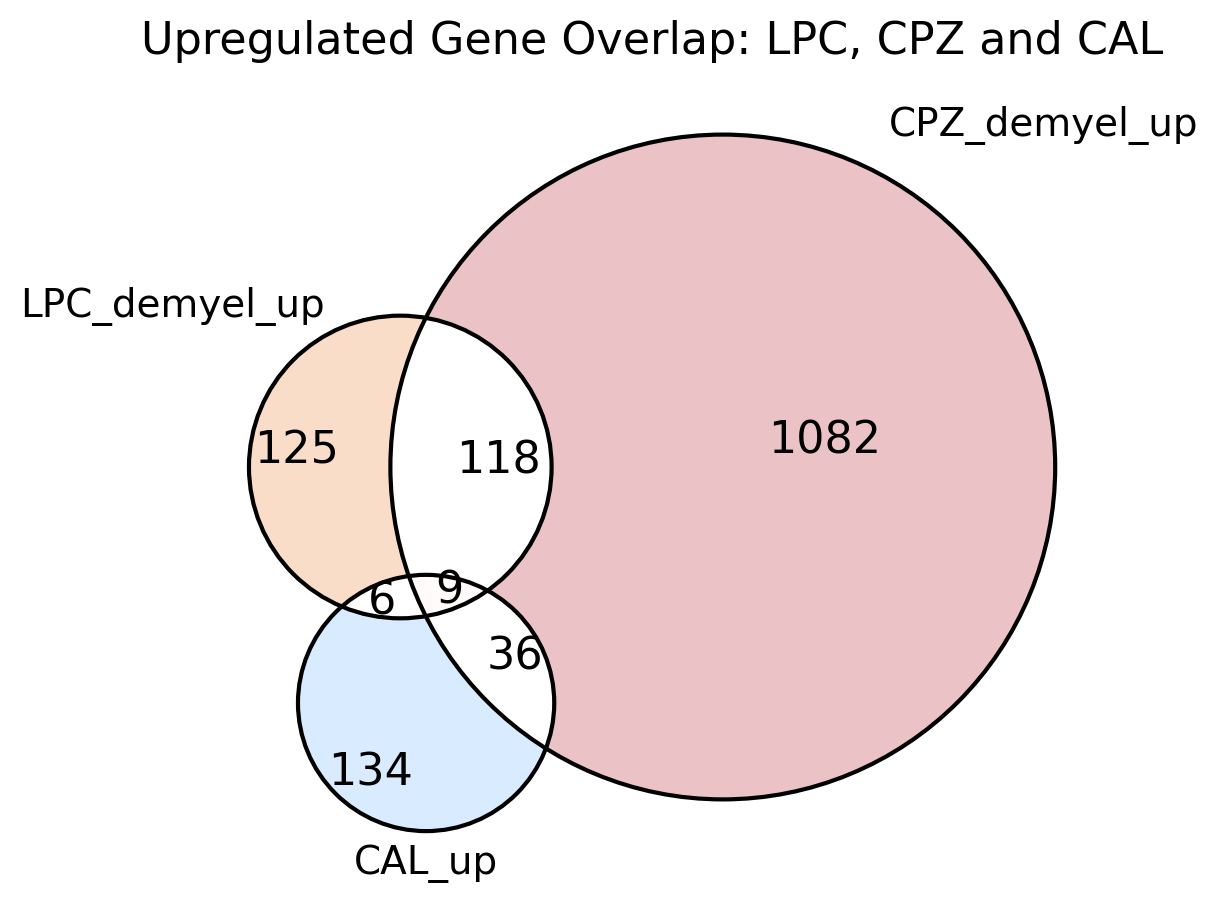

In [82]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_CAL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'CAL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and CAL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

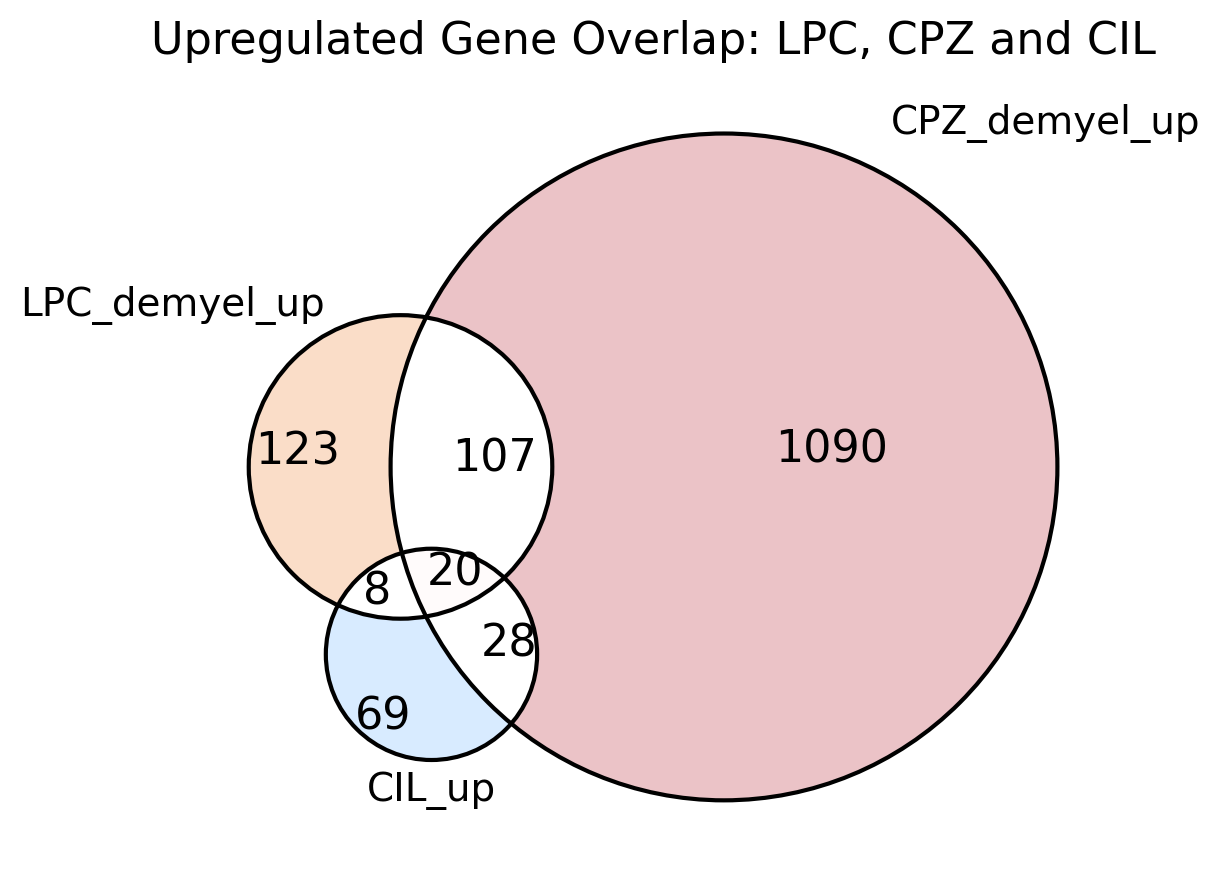

In [83]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_CIL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'CIL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and CIL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

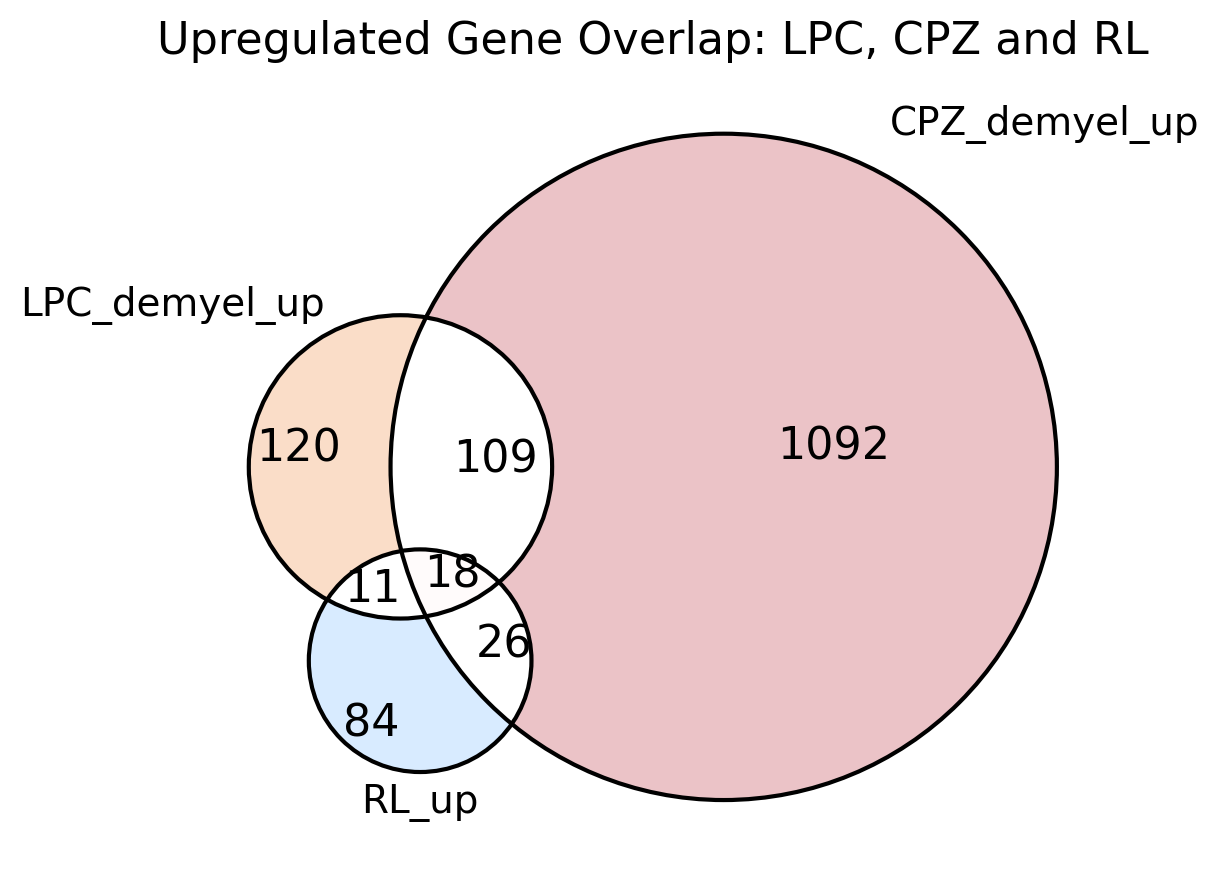

In [84]:
plot_venn3_from_sets(
    set1=set_LPC_demyel_all_up,
    set2=set_Cupr_demyel_all_up,
    set3=set_MOL_RL_up_all,
    labels=('LPC_demyel_up', 'CPZ_demyel_up', 'RL_up'),
    colors=('#f9d5bb', '#e7b5b9', '#cfe7ff'),
    title='Upregulated Gene Overlap: LPC, CPZ and RL',
    #save_path='figures/up_overlap_LPC_EAE.png'  # optional
)

In [85]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

In [86]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_MOL_CAL_up_all & set_MOL_CIL_up_all & set_MOL_RL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 4
Overlapping upregulated genes: {'C1orf21', 'RRAS2', 'LHFPL3', 'ST8SIA5'}


In [87]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 21
Overlapping upregulated genes: {'VIM', 'APOE', 'ST3GAL1', 'NRCAM', 'ST8SIA5', 'TENT5A', 'C1orf21', 'EPHA4', 'CHL1', 'TSPAN9', 'KCNIP3', 'LHFPL3', 'CNTN3', 'PCDH7', 'GRM8', 'SYNE2', 'RRAS2', 'COL27A1', 'ANXA2', 'TMOD1', 'SEL1L3'}


In [88]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 34
Overlapping upregulated genes: {'VIM', 'CACFD1', 'GYS1', 'EDA', 'PRKX', 'EGR1', 'KLF15', 'RIMS2', 'NRCAM', 'SESN2', 'TCTN1', 'CEBPG', 'ST8SIA5', 'BRINP3', 'KLHL21', 'RANGAP1', 'TENT5A', 'C1orf21', 'UBALD2', 'MAFK', 'CHL1', 'KCNIP3', 'LHFPL3', 'PCDH7', 'PLCB1', 'CCDC117', 'SYNE2', 'RRAS2', 'SGK1', 'PRKD2', 'ANXA2', 'GUCY1B1', 'ZSWIM4', 'MFGE8'}


In [89]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 15
Overlapping upregulated genes: {'MARK1', 'LHFPL3', 'VAT1', 'CSF1', 'PHLDA1', 'ST8SIA5', 'CNTN3', 'GRIK3', 'CEBPD', 'C1orf21', 'ABHD4', 'EPHA4', 'GRM8', 'CRYZ', 'RRAS2'}


In [90]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 45
Overlapping upregulated genes: {'KLF6', 'ZCCHC3', 'TCOF1', 'DCXR', 'CACFD1', 'PRKX', 'NGFR', 'KLF15', 'GRIK3', 'GRWD1', 'SESN2', 'CEBPG', 'ST8SIA5', 'KLHL21', 'RANGAP1', 'TXNDC5', 'CEBPD', 'ZSWIM1', 'C1orf21', 'CHMP1A', 'UBALD2', 'RELA', 'MAFK', 'TLE4', 'CRYZ', 'NDUFAF6', 'ZCCHC2', 'VAT1', 'BAG3', 'LHFPL3', 'PHLDA1', 'SPR', 'JMJD6', 'CCDC117', 'RRAS2', 'LURAP1L', 'MAP1S', 'ALG2', 'PPM1E', 'DDX27', 'EFNB1', 'ANAPC16', 'EFCAB7', 'BANP', 'MFGE8'}


In [91]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 28
Overlapping upregulated genes: {'VIM', 'AMOTL1', 'GRIK3', 'APOE', 'NAV3', 'NRCAM', 'ST3GAL1', 'ST8SIA5', 'CEBPD', 'C1orf21', 'SOCS3', 'CHL1', 'TSPAN9', 'KCNIP3', 'LHFPL3', 'CNTN3', 'GADD45B', 'CSMD2', 'CDKN1A', 'CHSY3', 'PROS1', 'TLE3', 'GRM8', 'NTRK2', 'RRAS2', 'ANXA2', 'TMOD1', 'TRAM2'}


In [92]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 48
Overlapping upregulated genes: {'RUNX2', 'VIM', 'IRF2BPL', 'AMOTL1', 'PRKX', 'MPZL1', 'NGFR', 'KLF15', 'GRIK3', 'NAV3', 'PIP5K1B', 'RIMS2', 'NRCAM', 'SESN2', 'ST8SIA5', 'BRINP3', 'TXNDC5', 'SLC35F1', 'CEBPD', 'C1orf21', 'FOS', 'SOCS3', 'MAFK', 'CHL1', 'KCNIP3', 'LHFPL3', 'KHDRBS3', 'GADD45B', 'PROCA1', 'TGFBR3', 'CDKN1A', 'FRMD4A', 'PROS1', 'KLF9', 'KLF10', 'TLE3', 'PLCB1', 'GFRA1', 'NTRK2', 'ZFP36', 'RRAS2', 'LURAP1L', 'SGK1', 'PDE3A', 'ANXA2', 'GUCY1B1', 'ZSWIM4', 'TRAM2'}


In [93]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_up_all & set_LPC_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 29
Overlapping upregulated genes: {'VIM', 'RNF122', 'PLAT', 'GRIK3', 'NAV3', 'SPSB1', 'CERK', 'ST8SIA5', 'HSD17B7', 'ASNS', 'CEBPD', 'C1orf21', 'SOCS3', 'CAV2', 'NAV2', 'TSPAN9', 'PCDHB16', 'KCNIP3', 'LHFPL3', 'CNTN3', 'CSMD2', 'LMNA', 'PROS1', 'CHSY3', 'ABHD4', 'GRM8', 'RRAS2', 'ANXA2', 'TRAM2'}


In [94]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 44
Overlapping upregulated genes: {'KLF6', 'VIM', 'IRF2BPL', 'PRKX', 'MPZL1', 'EGR1', 'KLF15', 'PLAT', 'GRIK3', 'NAV3', 'SERTAD1', 'CEBPG', 'ST8SIA5', 'RPS6KA3', 'SPATA1', 'ASNS', 'CEBPD', 'C1orf21', 'FOS', 'JUNB', 'UBALD2', 'RELA', 'SOCS3', 'MAFK', 'CAV2', 'PCDHB16', 'KCNIP3', 'LHFPL3', 'BTG1', 'KHDRBS3', 'LMNA', 'BORCS6', 'PROS1', 'KLF9', 'KLF10', 'ZFP36', 'RRAS2', 'ANXA2', 'PDGFC', 'PDP1', 'ZSWIM4', 'MFGE8', 'OGFR', 'TRAM2'}


In [120]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_up) - set_LPC_demyel_all_up

print("Number of overlapping upregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping upregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

Number of overlapping upregulated genes (Cupr but not LPC): 71
Overlapping upregulated genes (Cupr but not LPC): {'KLF6', 'ZCCHC3', 'RUNX2', 'TCOF1', 'DCXR', 'IRF2BPL', 'CACFD1', 'EDA', 'MPZL1', 'NGFR', 'GYS1', 'PRKX', 'EGR1', 'KLF15', 'SERTAD1', 'PIP5K1B', 'RIMS2', 'GRWD1', 'SESN2', 'TCTN1', 'CEBPG', 'BRINP3', 'RPS6KA3', 'KLHL21', 'RANGAP1', 'SLC35F1', 'TXNDC5', 'SPATA1', 'ZSWIM1', 'FOS', 'JUNB', 'CHMP1A', 'UBALD2', 'RELA', 'MAFK', 'TLE4', 'NDUFAF6', 'KHDRBS3', 'BTG1', 'BAG3', 'ZCCHC2', 'PROCA1', 'SPR', 'JMJD6', 'BORCS6', 'TGFBR3', 'FRMD4A', 'KLF9', 'KLF10', 'PLCB1', 'CCDC117', 'GFRA1', 'ZFP36', 'LURAP1L', 'MAP1S', 'SGK1', 'ALG2', 'PRKD2', 'PPM1E', 'DDX27', 'PDE3A', 'PDGFC', 'GUCY1B1', 'EFNB1', 'ANAPC16', 'EFCAB7', 'PDP1', 'BANP', 'ZSWIM4', 'MFGE8', 'OGFR'}


In [121]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_up) - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cupr))
print("Overlapping upregulated genes (LPC but not CPZ):", overlap_lpc_not_cupr)

Number of overlapping upregulated genes (LPC but not CPZ): 19
Overlapping upregulated genes (LPC but not CPZ): {'CSF1', 'RNF122', 'SPSB1', 'APOE', 'ST3GAL1', 'MARK1', 'CERK', 'HSD17B7', 'EPHA4', 'NAV2', 'TSPAN9', 'CNTN3', 'CSMD2', 'ABHD4', 'GRM8', 'COL27A1', 'TMOD1', 'SEL1L3', 'CHSY3'}


In [122]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_up & set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC and CPZ):", len(overlap_lpc_and_cupr))
print("Overlapping upregulated genes (LPC and CPZ):", overlap_lpc_and_cupr)

Number of overlapping upregulated genes (LPC and CPZ): 31
Overlapping upregulated genes (LPC and CPZ): {'VIM', 'AMOTL1', 'PLAT', 'GRIK3', 'NAV3', 'NRCAM', 'ST8SIA5', 'TENT5A', 'ASNS', 'CEBPD', 'C1orf21', 'SOCS3', 'CAV2', 'CRYZ', 'CHL1', 'PCDHB16', 'KCNIP3', 'LHFPL3', 'VAT1', 'PHLDA1', 'GADD45B', 'PCDH7', 'LMNA', 'CDKN1A', 'PROS1', 'TLE3', 'NTRK2', 'SYNE2', 'RRAS2', 'ANXA2', 'TRAM2'}


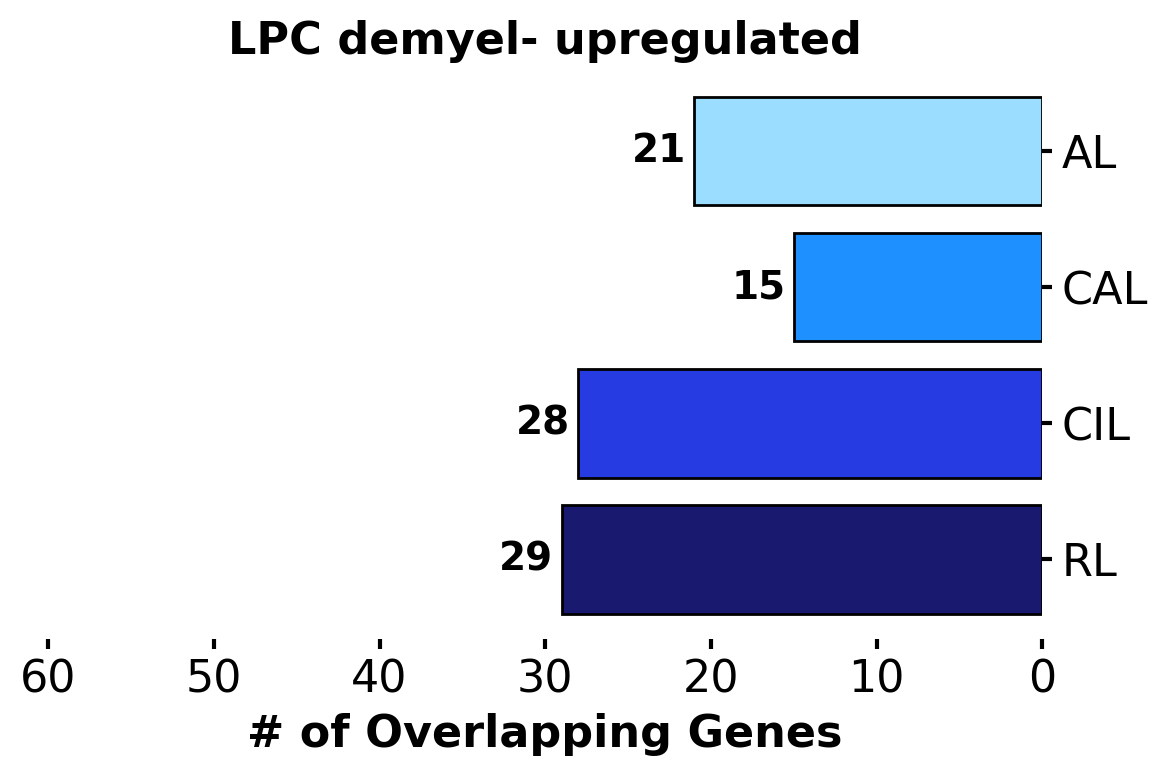

In [95]:
import seaborn as sns

# Lesion names and counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts = [21, 15, 28, 29]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60'])

# Title
ax.set_title("LPC demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel.png", dpi=300, bbox_inches='tight')

plt.show()

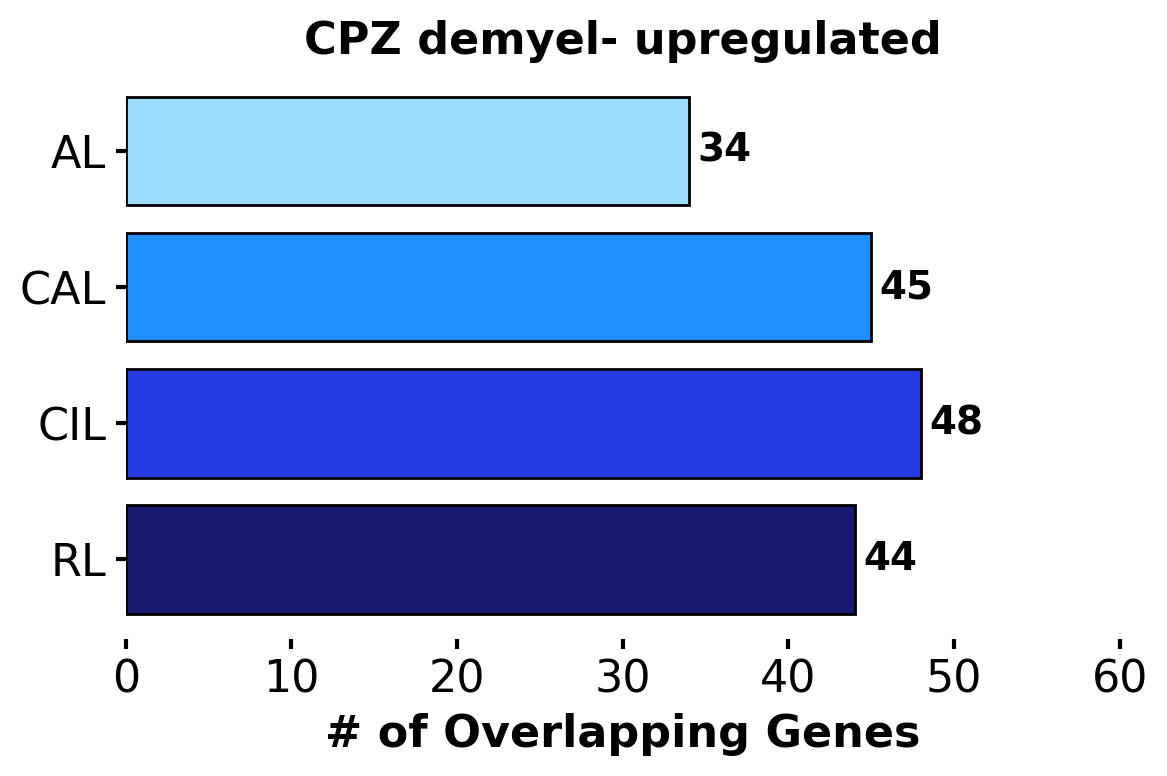

In [96]:
# Lesion names and CPZ counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [34, 45, 48, 44]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60'])

# Title
ax.set_title("CPZ demyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel.png", dpi=300, bbox_inches='tight')

plt.show()

## Now do down!!!

In [97]:
# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene'].isin(genes_all)]

# Apply filtering to each DEG DataFrame
MOL_AL_down_all = filter_genes(MOL_AL_down)
MOL_CAL_down_all = filter_genes(MOL_CAL_down)
MOL_CIL_down_all = filter_genes(MOL_CIL_down)
MOL_RL_down_all = filter_genes(MOL_RL_down)

print(MOL_AL_down_all.shape)
print(MOL_CAL_down_all.shape)
print(MOL_CIL_down_all.shape)
print(MOL_RL_down_all.shape)

# Function to filter DE DataFrames to include only genes tested in all conditions
def filter_genes(df):
    return df[df['gene_hs'].isin(genes_all)]

Cupr_demyel_down_all = filter_genes(Cupr_demyel_down)
LPC_demyel_down_all = filter_genes(LPC_demyel_down)
LPC_remyel_down_all = filter_genes(LPC_remyel_down)

print(Cupr_demyel_down_all.shape)
print(LPC_demyel_down_all.shape)
print(LPC_remyel_down_all.shape)

(128, 5)
(211, 5)
(96, 5)
(108, 5)
(1132, 6)
(206, 6)
(243, 6)


In [98]:
LPC_demyel_down_all[:5]

,gene,gene_hs,gene_mm,logFC,AveExpr,Padj
73,Spock3,SPOCK3,Spock3,-1.287429,8.189376,0.000014
138,Atg4c,ATG4C,Atg4c,-0.943383,6.620788,0.000108
142,Fbxo7,FBXO7,Fbxo7,-0.878645,7.273579,0.000124
146,Gpm6b,GPM6B,Gpm6b,-0.981233,10.549859,0.000127
166,Tmem144,TMEM144,Tmem144,-0.754289,5.827741,0.000198


In [99]:
Anxa2_row = LPC_demyel_down_all[LPC_demyel_down_all['gene'] == 'Gpm6b']
print(Anxa2_row)

      gene gene_hs gene_mm     logFC    AveExpr      Padj
146  Gpm6b   GPM6B   Gpm6b -0.981233  10.549859  0.000127


In [100]:
# Create gene lists from the new DataFrames
genes_MOL_AL_all_down = MOL_AL_down_all['gene'].tolist()
genes_MOL_CAL_all_down = MOL_CAL_down_all['gene'].tolist()
genes_MOL_CIL_all_down = MOL_CIL_down_all['gene'].tolist()
genes_MOL_RL_all_down = MOL_RL_down_all['gene'].tolist()

genes_LPC_demyel_all_down = LPC_demyel_down_all['gene_hs'].tolist()
genes_LPC_remyel_all_down = LPC_remyel_down_all['gene_hs'].tolist()
genes_Cupr_demyel_all_down = Cupr_demyel_down_all['gene_hs'].tolist()

In [101]:
# Convert lists to sets for upregulated genes
set_MOL_AL_down_all = set(genes_MOL_AL_all_down)
set_MOL_CAL_down_all = set(genes_MOL_CAL_all_down)
set_MOL_CIL_down_all = set(genes_MOL_CIL_all_down)
set_MOL_RL_down_all = set(genes_MOL_RL_all_down)

set_LPC_demyel_all_down = set(genes_LPC_demyel_all_down)
set_LPC_remyel_all_down = set(genes_LPC_remyel_all_down)
set_Cupr_demyel_all_down = set(genes_Cupr_demyel_all_down)

In [102]:
# Create gene lists from the dfs:
genes_MOL_AL_all_down = MOL_AL_down_all['gene'].tolist()
genes_MOL_CAL_all_down = MOL_CAL_down_all['gene'].tolist()
genes_MOL_CIL_all_down = MOL_CIL_down_all['gene'].tolist()
genes_MOL_RL_all_down = MOL_RL_down_all['gene'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
MOL_AL_all_down_df = create_gene_df(genes_MOL_AL_all_down, 'MOL_AL_all_down')
MOL_CAL_all_down_df = create_gene_df(genes_MOL_CAL_all_down, 'MOL_CAL_all_down')
MOL_CIL_all_down_df = create_gene_df(genes_MOL_CIL_all_down, 'MOL_CIL_all_down')
MOL_RL_all_down_df = create_gene_df(genes_MOL_RL_all_down, 'MOL_RL_all_down')

# Create DataFrames for each gene list
MOL_AL_all_down_df = pd.DataFrame({'MOL_AL_all_down': True, 'Name': genes_MOL_AL_all_down})
MOL_CAL_all_down_df = pd.DataFrame({'MOL_CAL_all_down': True, 'Name': genes_MOL_CAL_all_down})
MOL_CIL_all_down_df = pd.DataFrame({'MOL_CIL_all_down': True, 'Name': genes_MOL_CIL_all_down})
MOL_RL_all_down_df = pd.DataFrame({'MOL_RL_all_down': True, 'Name': genes_MOL_RL_all_down})

In [103]:
# Create gene lists from the dfs:
genes_LPC_demyel_all_down = LPC_demyel_down_all['gene_hs'].tolist()
genes_LPC_remyel_all_down = LPC_remyel_down_all['gene_hs'].tolist()
genes_Cupr_demyel_all_down = Cupr_demyel_down_all['gene_hs'].tolist()

# Define the function to create a DataFrame
def create_gene_df(genes_list, column_name):
    return pd.DataFrame(genes_list, columns=[column_name])

# Create DataFrames for each gene list
LPC_demyel_all_down_df = create_gene_df(genes_LPC_demyel_all_down, 'LPC_demyel_all_down')
LPC_remyel_all_down_df = create_gene_df(genes_LPC_remyel_all_down, 'LPC_remyel_all_down')
Cupr_demyel_all_down_df = create_gene_df(genes_Cupr_demyel_all_down, 'Cupr_demyel_all_down')

# Create DataFrames for each gene list using the new gene lists
#OPC_de_down_df = pd.DataFrame({'OPC_de_down': True, 'Name': genes_OPC_de_down})
LPC_demyel_all_down_df = pd.DataFrame({'LPC_demyel_all_down': True, 'Name': genes_LPC_demyel_all_down})
LPC_remyel_all_down_df = pd.DataFrame({'LPC_remyel_all_down': True, 'Name': genes_LPC_remyel_all_down})
Cupr_demyel_all_down_df = pd.DataFrame({'Cupr_demyel_all_down': True, 'Name': genes_Cupr_demyel_all_down})

In [104]:
# Hierarchically merge all the DataFrames on 'Gene'
down_df = MOL_AL_all_down_df.merge(
    MOL_CAL_all_down_df.merge(
        MOL_CIL_all_down_df.merge(
            MOL_RL_all_down_df.merge(
                LPC_demyel_all_down_df.merge(
                    Cupr_demyel_all_down_df, on='Name', how='outer'
                ), on='Name', how='outer'
            ), on='Name', how='outer'
        ), on='Name', how='outer'
    ), on='Name', how='outer'
)

# Replace NaN with False
down_df = down_df.fillna(False)

# Set 'Gene' as the index (optional, but useful for plotting)
down_df_plot = down_df.set_index([
    'MOL_AL_all_down', 'MOL_CAL_all_down', 'MOL_CIL_all_down', 'MOL_RL_all_down', 'LPC_demyel_all_down', 'Cupr_demyel_all_down'
])

# Print the final merged DataFrame
print("Upregulated genes across all conditions (hierarchically merged):")
print(down_df_plot)

Upregulated genes across all conditions (hierarchically merged):
                                                                                                              Name
MOL_AL_all_down MOL_CAL_all_down MOL_CIL_all_down MOL_RL_all_down LPC_demyel_all_down Cupr_demyel_all_down        
False           False            False            False           False               True                    AATK
                                                                                      True                   ABCA2
                                                                                      True                   ABCA6
                                                  True            False               True                   ABCA7
                                                  False           False               True                   ABCA8
...                                                                                                            ...
               

/tmp/2140472.1.long/ipykernel_1920231/3050655249.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  down_df = down_df.fillna(False)


In [105]:
# Dictionary to map old index names to new index names
index_name_map = {
    'MOL_AL_all_down': 'AL',
    'MOL_CAL_all_down': 'CAL',
    'MOL_CIL_all_down': 'CIL',
    'MOL_RL_all_down': 'RL',
    'LPC_demyel_all_down': 'LPC_demyel',
    'Cupr_demyel_all_down': 'CPZ_demyel',
}

# Rename the index levels using the dictionary
down_df_plot.index = down_df_plot.index.rename(index_name_map)

print("Updated Upregulated genes DataFrame:")
print(down_df_plot)

Updated Upregulated genes DataFrame:
                                                 Name
AL    CAL   CIL   RL    LPC_demyel CPZ_demyel        
False False False False False      True          AATK
                                   True         ABCA2
                                   True         ABCA6
                  True  False      True         ABCA7
                  False False      True         ABCA8
...                                               ...
                                   True        ZNF608
                                   True        ZNF638
                                   True        ZNF652
                                   True        ZNF704
True  True  False False False      False       ZNF883

[1467 rows x 1 columns]


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

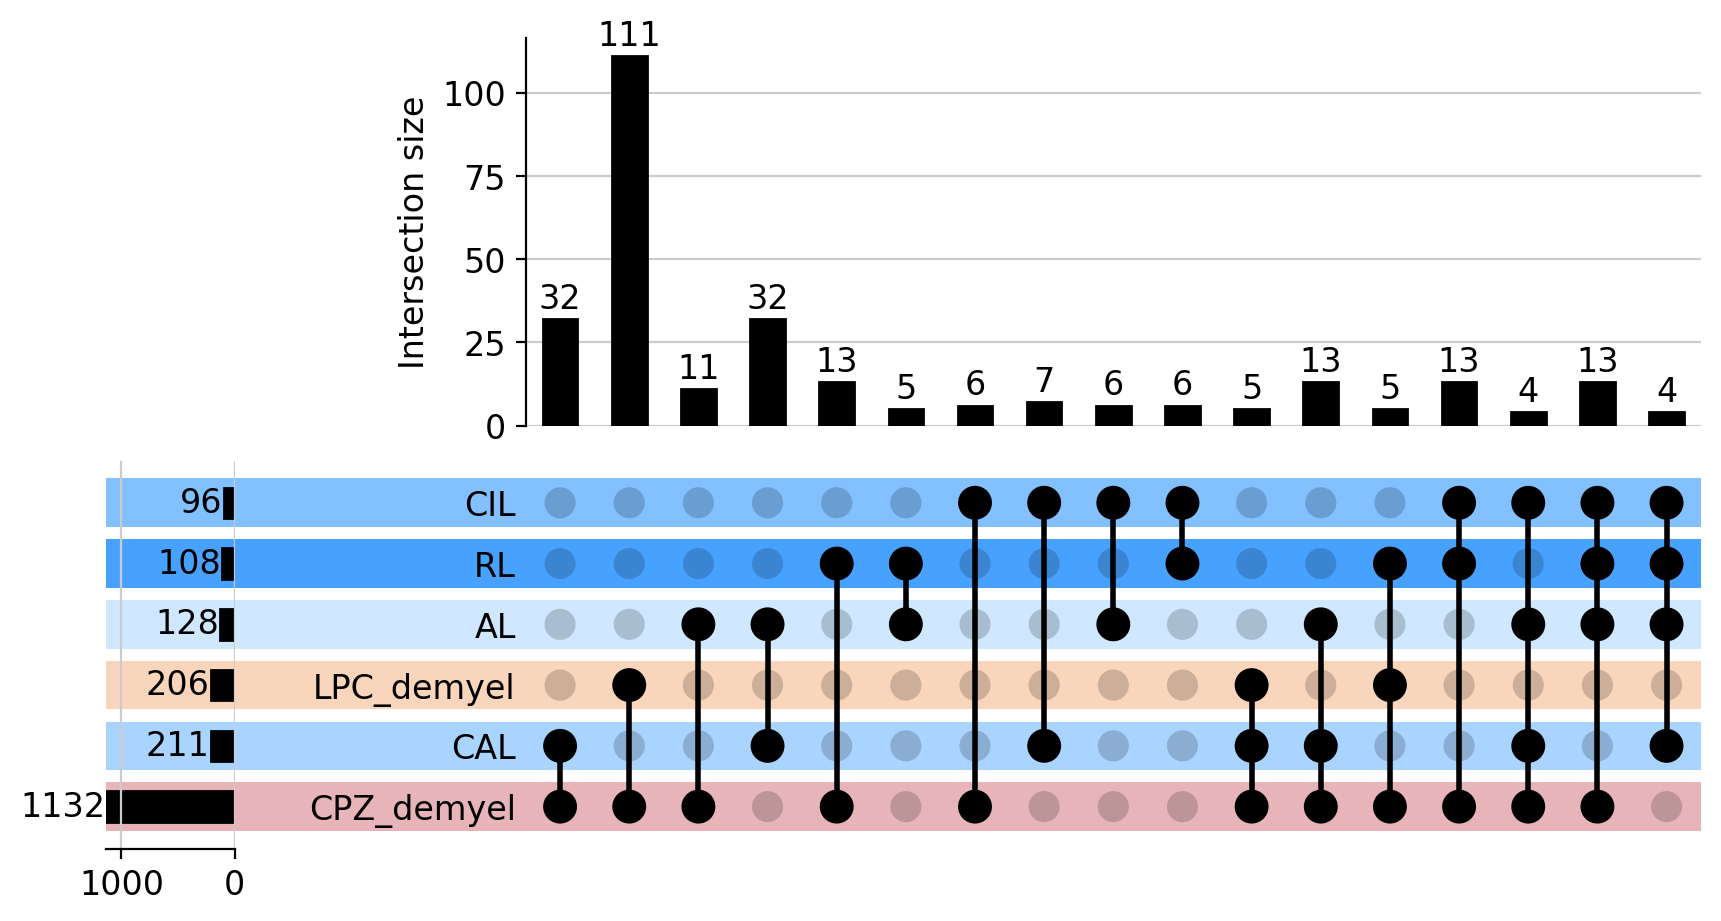

In [106]:
# Create UpSet plot
upset = UpSet(down_df_plot, subset_size='count', show_counts=True, facecolor="black", min_degree=2,
              min_subset_size=4)

# Style the subsets
upset.style_categories(
    'AL',
    shading_facecolor="#cfe7ff",
)

# Style the subsets
upset.style_categories(
    'CAL',
    shading_facecolor="#a9d4ff",
)

# Style the subsets
upset.style_categories(
    'CIL',
    shading_facecolor="#82c0ff",
)

# Style the subsets
upset.style_categories(
    'RL',
    shading_facecolor="#47a2ff",
)

# Style the subsets
upset.style_categories(
    'LPC_demyel',
    shading_facecolor="#f9d5bb",
)

# Style the subsets
upset.style_categories(
    'CPZ_demyel',
    shading_facecolor="#e7b5b9",
)

#upset.style_subsets(present=["CPZ_demyel"], facecolor="#c5183b", label="CPZ overlap")
#upset.style_subsets(present=["CPZ_demyel"], edgecolor="#e12f54", linewidth=4)

# Plot the UpSet plot
upset.plot()
plt.suptitle("")

# Save the plot as PDF
#plt.savefig('./figures/upset_plot_MOL_hs_mm_Cupr_overlap_down_n3_revision.png', dpi=300, bbox_inches='tight', facecolor='none')

plt.show()

In [107]:
# Convert lists to sets for upregulated genes
set_MOL_AL_down_all = set(genes_MOL_AL_all_down)
set_MOL_CAL_down_all = set(genes_MOL_CAL_all_down)
set_MOL_CIL_down_all = set(genes_MOL_CIL_all_down)
set_MOL_RL_down_all = set(genes_MOL_RL_all_down)

set_LPC_demyel_all_down = set(genes_LPC_demyel_all_down)
set_LPC_remyel_all_down = set(genes_LPC_remyel_all_down)
set_Cupr_demyel_all_down = set(genes_Cupr_demyel_all_down)

In [108]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 0
Overlapping upregulated genes: set()


In [109]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 4
Overlapping upregulated genes: {'SLC5A11', 'SLC16A1', 'GREB1L', 'FBXO7'}


In [110]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 7
Overlapping upregulated genes: {'SLC6A1', 'SLC16A1', 'BCHE', 'TRIM59', 'DGKD', 'PLEKHH1', 'GREB1L'}


In [111]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 0
Overlapping upregulated genes: set()


In [112]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 6
Overlapping upregulated genes: {'GPLD1', 'ADGRV1', 'PRTG', 'AMPH', 'GREB1L', 'EPDR1'}


In [113]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 50
Overlapping upregulated genes: {'LYPD6', 'RAB7B', 'PADI2', 'LIMK2', 'PSD3', 'SEZ6L2', 'GAS2', 'FMN1', 'LRRC4B', 'IZUMO4', 'ST3GAL5', 'HIVEP3', 'LPCAT2', 'VLDLR', 'MGAT5', 'NFE2L3', 'LURAP1', 'PER3', 'LDB3', 'SYNJ2', 'HHATL', 'SLC5A11', 'HEG1', 'STX4', 'PCOLCE2', 'RASAL1', 'LDLRAD4', 'ADAMTS4', 'RNF112', 'S100B', 'LCTL', 'C1orf122', 'CHST8', 'NAALADL2', 'AVEN', 'ITGAV', 'TDO2', 'PLEKHG1', 'SCG5', 'PTPDC1', 'CMTM5', 'S100A1', 'STMN4', 'MACROD2', 'C1orf54', 'EFS', 'TMEM163', 'WSB1', 'NRBP2', 'E2F3'}


In [114]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 61
Overlapping upregulated genes: {'PPP1R14A', 'RAB7B', 'PADI2', 'GRIK4', 'PIK3C2B', 'MAN2A2', 'SSPN', 'OSTF1', 'SEMA6D', 'PLEKHH1', 'ST3GAL5', 'CREG2', 'LPCAT2', 'VLDLR', 'MOG', 'TTC8', 'NFE2L3', 'PIK3IP1', 'GJB1', 'ATG10', 'TMEM229A', 'TRIM59', 'RAB33A', 'IL12A', 'LDB3', 'OMG', 'PRR18', 'PLLP', 'CARNS1', 'HEG1', 'LRRTM3', 'TPPP3', 'ACP2', 'ERBB3', 'RASAL1', 'LDLRAD4', 'TMEM63A', 'ADAMTS4', 'PLEKHG3', 'TMEM258', 'C1orf122', 'NAALADL2', 'LPGAT1', 'ETFA', 'AVEN', 'PRKCQ', 'MAG', 'SLC6A1', 'TMEM121', 'LPAR1', 'SCG5', 'PTPDC1', 'CMTM5', 'STMN4', 'DGKD', 'BCHE', 'EFS', 'CAMK1', 'WSB1', 'NRBP2', 'DAD1'}


In [115]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 44
Overlapping upregulated genes: {'LYPD6', 'RAB7B', 'LIMK2', 'FAH', 'DNAH14', 'SMIM1', 'MRTFB', 'ALDH5A1', 'GAS2', 'FMN1', 'SHISA8', 'PLEKHA2', 'LPCAT2', 'GRM7', 'UQCR11', 'FBXO2', 'NFE2L3', 'KCTD16', 'GJB1', 'TMEM229A', 'C4orf19', 'NKX2-8', 'HHATL', 'PCOLCE2', 'RNF112', 'VAMP5', 'S100B', 'NT5E', 'LCTL', 'C1orf122', 'CHST8', 'HAGHL', 'TRIM36', 'AVEN', 'TMEM121', 'PLEKHG1', 'SCG5', 'CMTM5', 'S100A1', 'NUDT14', 'MACROD2', 'PLS1', 'TMEM163', 'E2F3'}


In [116]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 50
Overlapping upregulated genes: {'GPLD1', 'LYPD6', 'RAB7B', 'LIMK2', 'TLE2', 'FAH', 'ADGRV1', 'LRMDA', 'DNAH14', 'NDUFA1', 'SMIM1', 'MRTFB', 'ALDH5A1', 'PRTG', 'FMN1', 'GAS2', 'WNT3', 'SEC14L5', 'PLEKHA2', 'LPCAT2', 'SVIL', 'UQCR11', 'FBXO2', 'NFE2L3', 'KCTD16', 'EVI2A', 'SYNPR', 'LDB3', 'HHATL', 'ABCA7', 'SH3GL2', 'PCOLCE2', 'TRAF5', 'VAMP5', 'S100B', 'LCTL', 'CHST8', 'HAGHL', 'EPDR1', 'TDO2', 'PLEKHG1', 'S100A1', 'NUDT14', 'DDAH2', 'C1orf54', 'PLS1', 'AMPH', 'TMEM163', 'B3GALNT1', 'E2F3'}


In [117]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all& set_MOL_RL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 3
Overlapping upregulated genes: {'RAB7B', 'LPCAT2', 'NFE2L3'}


In [123]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_down) - set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping downregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

Number of overlapping downregulated genes (Cupr but not LPC): 116
Overlapping downregulated genes (Cupr but not LPC): {'LYPD6', 'PIK3C2B', 'SSPN', 'ALDH5A1', 'IZUMO4', 'ST3GAL5', 'VLDLR', 'MGAT5', 'TMEM229A', 'C4orf19', 'LDB3', 'OMG', 'HHATL', 'TPPP3', 'TMEM63A', 'ADAMTS4', 'RNF112', 'LCTL', 'C1orf122', 'CHST8', 'AVEN', 'TMEM121', 'LPAR1', 'PTPDC1', 'NUDT14', 'C1orf54', 'EFS', 'PLEKHG3', 'B3GALNT1', 'E2F3', 'PPP1R14A', 'RAB7B', 'PADI2', 'FAH', 'SEZ6L2', 'FMN1', 'LRRC4B', 'SEC14L5', 'PLEKHA2', 'CREG2', 'KCTD16', 'SYNPR', 'NKX2-8', 'IL12A', 'SYNJ2', 'ABCA7', 'ACP2', 'ERBB3', 'RASAL1', 'TRAF5', 'TDO2', 'MACROD2', 'TLE2', 'OSTF1', 'WNT3', 'LPCAT2', 'GRM7', 'SVIL', 'TTC8', 'GJB1', 'ATG10', 'EVI2A', 'LURAP1', 'PER3', 'PLLP', 'CARNS1', 'HEG1', 'LRRTM3', 'SH3GL2', 'S100B', 'NT5E', 'NAALADL2', 'ETFA', 'PLEKHG1', 'STMN4', 'DDAH2', 'PLS1', 'TMEM163', 'WSB1', 'LIMK2', 'GRIK4', 'LRMDA', 'PSD3', 'DNAH14', 'NDUFA1', 'MAN2A2', 'SMIM1', 'MRTFB', 'SEMA6D', 'GAS2', 'SHISA8', 'HIVEP3', 'UQCR11', 'FBXO2', 

In [124]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_down) - set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC but not cupr):", len(overlap_lpc_not_cupr))
print("Overlapping downregulated genes (LPC but not cupr):", overlap_lpc_not_cupr)

Number of overlapping downregulated genes (LPC but not cupr): 3
Overlapping downregulated genes (LPC but not cupr): {'SLC16A1', 'FBXO7', 'GREB1L'}


In [125]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_down & set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC and cupr):", len(overlap_lpc_and_cupr))
print("Overlapping downregulated genes (LPC and cupr):", overlap_lpc_and_cupr)

Number of overlapping downregulated genes (LPC and cupr): 11
Overlapping downregulated genes (LPC and cupr): {'GPLD1', 'SLC5A11', 'SLC6A1', 'ADGRV1', 'PRTG', 'TRIM59', 'DGKD', 'BCHE', 'AMPH', 'PLEKHH1', 'EPDR1'}


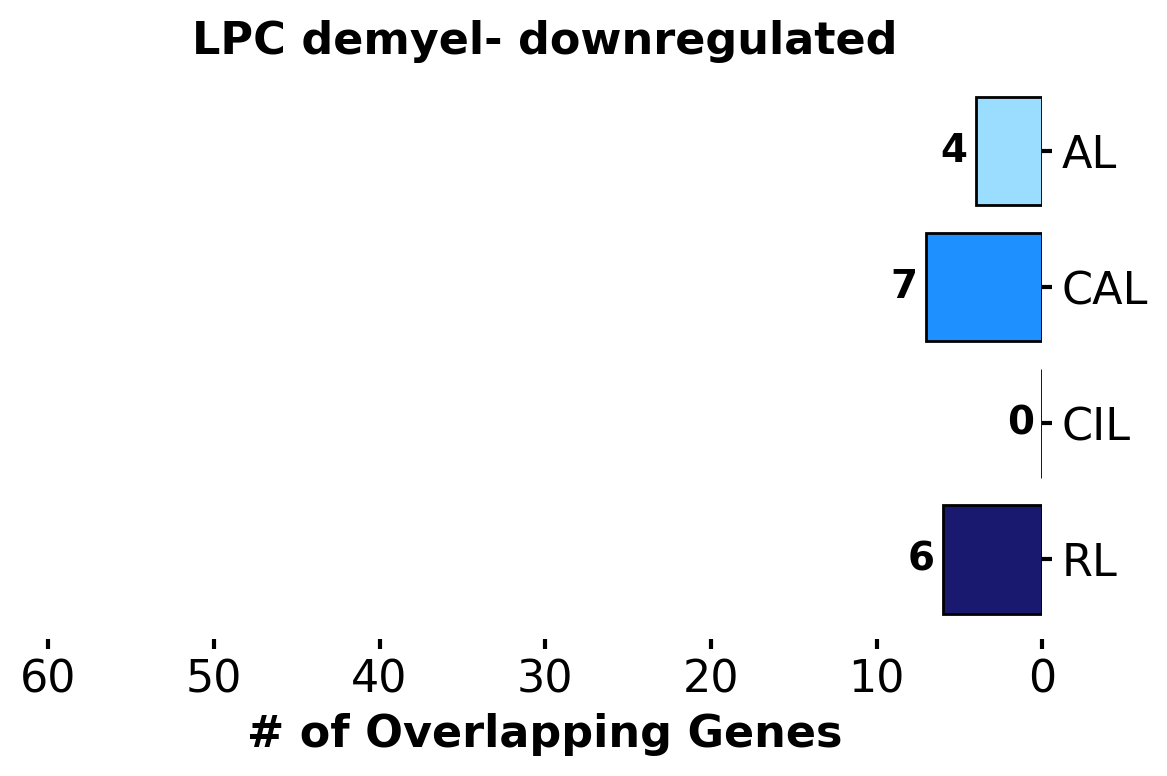

In [118]:
import seaborn as sns

# Lesion names and counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts = [4, 7, 0, 6]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60'])

# Title
ax.set_title("LPC demyel- downregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_demyel_DOWN.png", dpi=300, bbox_inches='tight')

plt.show()

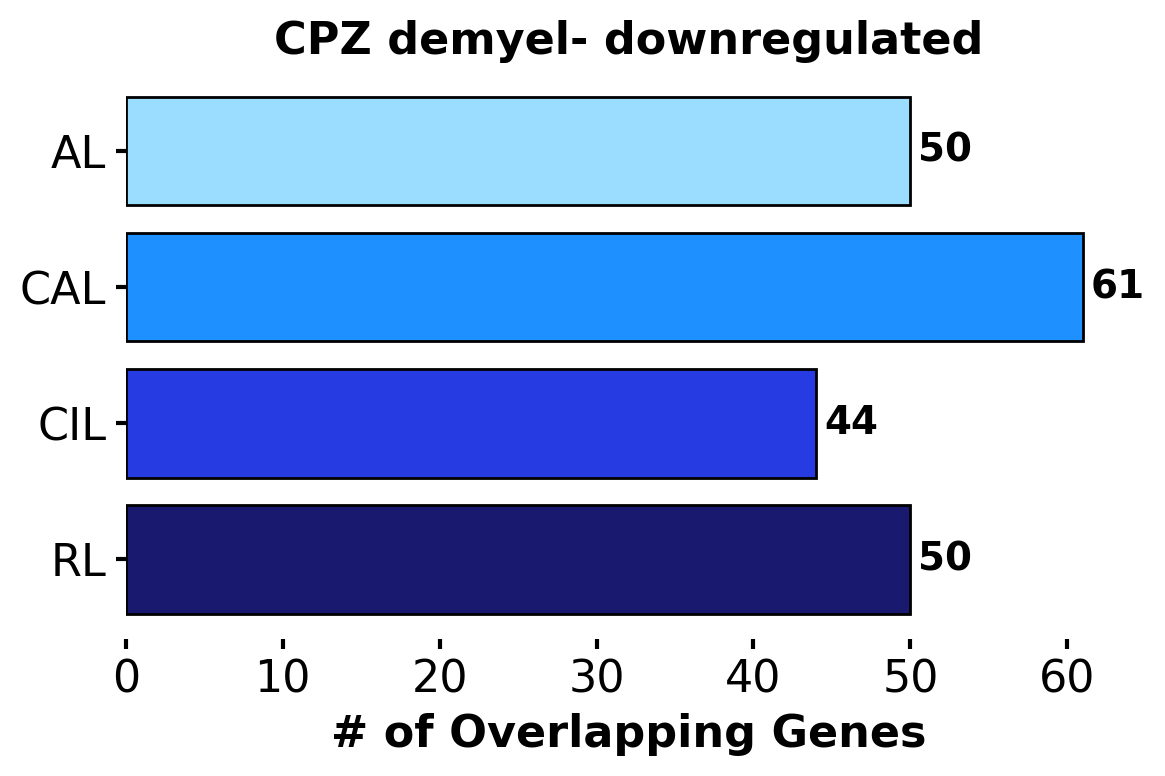

In [119]:
# Lesion names and CPZ counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [50, 61, 44, 50]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax.set_xticklabels(['0', '10', '20', '30', '40', '50', '60'])

# Title
ax.set_title("CPZ demyel- downregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_CPZ_demyel_DOWN.png", dpi=300, bbox_inches='tight')

plt.show()

## LPC_remyelin

In [127]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles

def plot_venn2_from_sets(set1, set2, 
                         set_labels=('Set 1', 'Set 2'), 
                         set_colors=('#a1c9f4', '#ffb482'), 
                         title='Venn Diagram',
                         alpha=0.8, 
                         font_size=16,
                         save_path=None):
    """
    Plots a 2-set Venn diagram and optionally saves it.

    Parameters:
    - set1, set2: Python sets to compare
    - set_labels: tuple of labels for the sets
    - set_colors: tuple of hex color codes
    - title: title of the plot
    - alpha: transparency of the Venn areas
    - font_size: base font size for text
    - save_path: full path (string) to save the figure, or None to not save
    """

    # Compute lengths
    only1 = len(set1 - set2)
    only2 = len(set2 - set1)
    both = len(set1 & set2)

    # Plot Venn
    venn = venn2(subsets=(only1, only2, both),
                 set_labels=set_labels,
                 set_colors=set_colors,
                 alpha=alpha)

    # Outline circles
    venn2_circles(subsets=(only1, only2, both), linewidth=1.5, color='black')

    # Style subset labels (inside circles)
    for label in venn.subset_labels:
        if label:
            label.set_fontsize(font_size)

    # Style set labels
    for label in venn.set_labels:
        if label:
            label.set_fontsize(font_size - 2)

    # Title and layout
    plt.title(title, fontsize=font_size)
    plt.tight_layout()

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')

    # Show plot
    plt.show()

In [128]:
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt

def plot_venn3_from_sets(set1, set2, set3, labels, colors, title, save_path=None):
    """
    Plots a 3-set Venn diagram with automatic circle and label styling.

    Parameters:
    - set1, set2, set3: sets of gene names
    - labels: tuple of 3 labels (str)
    - colors: tuple of 3 hex color strings
    - title: plot title (str)
    - save_path: optional path to save the figure (e.g., 'figs/my_venn.png')
    """
    # Compute subset sizes
    only1 = len(set1 - set2 - set3)
    only2 = len(set2 - set1 - set3)
    only3 = len(set3 - set1 - set2)

    shared12 = len(set1 & set2 - set3)
    shared13 = len(set1 & set3 - set2)
    shared23 = len(set2 & set3 - set1)

    shared123 = len(set1 & set2 & set3)

    subsets = (only1, only2, shared12, only3, shared13, shared23, shared123)

    # Plot Venn
    plt.figure(figsize=(6, 6))
    venn = venn3(
        subsets=subsets,
        set_labels=labels,
        set_colors=colors,
        alpha=0.8
    )

    # Circles
    circles = venn3_circles(subsets=subsets, linestyle='solid')
    for c in circles:
        if c:
            c.set_linewidth(1.5)
            c.set_edgecolor('black')

    # Fonts
    for subset in venn.subset_labels:
        if subset:
            subset.set_fontsize(16)

    for text in venn.set_labels:
        if text:
            text.set_fontsize(14)

    plt.title(title, fontsize=16)

    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='none')
        print(f"Saved Venn diagram to: {save_path}")

    plt.show()

In [ ]:
# Convert lists to sets for upregulated genes
set_MOL_AL_up_all = set(genes_MOL_AL_all_up)
set_MOL_CAL_up_all = set(genes_MOL_CAL_all_up)
set_MOL_CIL_up_all = set(genes_MOL_CIL_all_up)
set_MOL_RL_up_all = set(genes_MOL_RL_all_up)

set_LPC_demyel_all_up = set(genes_LPC_demyel_all_up)
set_LPC_remyel_all_up = set(genes_LPC_remyel_all_up)
set_Cupr_demyel_all_up = set(genes_Cupr_demyel_all_up)

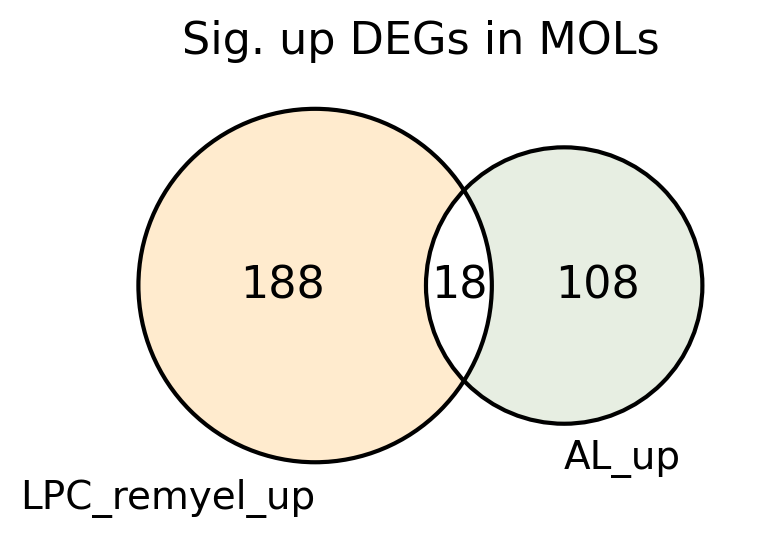

In [133]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_AL_up_all,
    set_labels=('LPC_remyel_up', 'AL_up'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

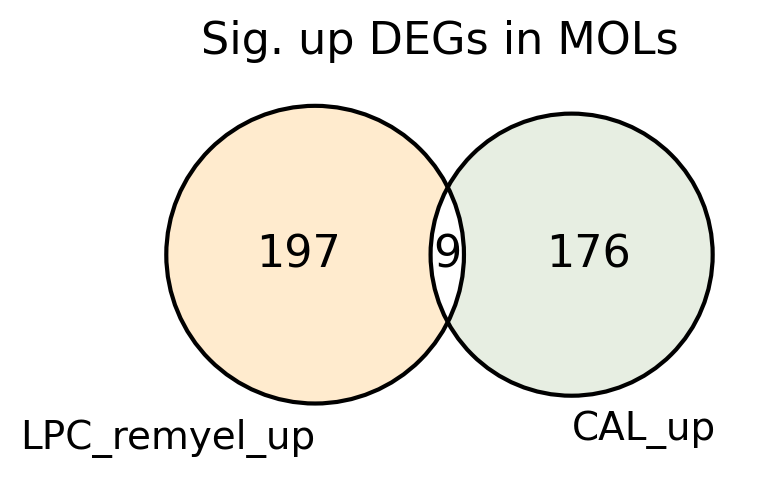

In [134]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_CAL_up_all,
    set_labels=('LPC_remyel_up', 'CAL_up'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

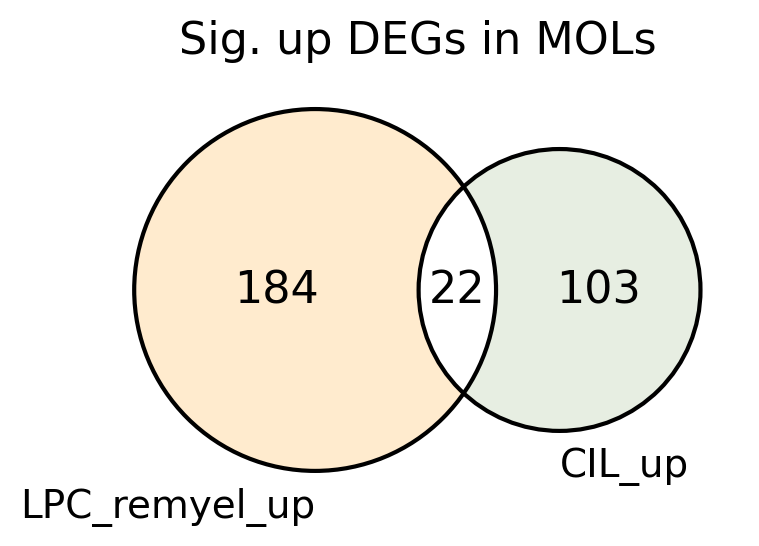

In [135]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_CIL_up_all,
    set_labels=('LPC_remyel_up', 'CIL_up'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

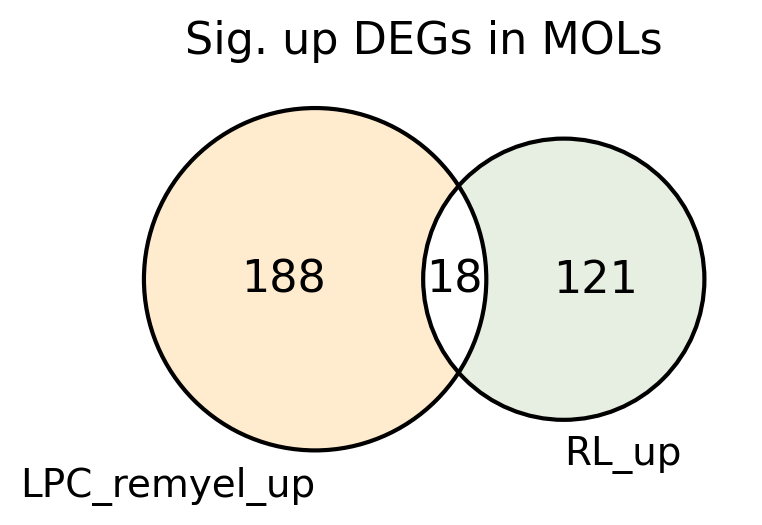

In [136]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_up,
    set2=set_MOL_RL_up_all,
    set_labels=('LPC_remyel_up', 'RL_up'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. up DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_up.png'  # None
)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_MOL_CAL_up_all & set_MOL_CIL_up_all & set_MOL_RL_up_all & set_LPC_demyel_all_up & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [137]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_LPC_remyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 18
Overlapping upregulated genes: {'CHL1', 'COL27A1', 'RASSF3', 'LHFPL3', 'ANXA2', 'BRINP3', 'PCDH7', 'TENT5A', 'CNTN1', 'VIM', 'PRICKLE1', 'TMOD1', 'SEL1L3', 'APOE', 'SYNE2', 'RRAS2', 'ST3GAL1', 'NRCAM'}


In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [138]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_up_all & set_LPC_remyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 9
Overlapping upregulated genes: {'MARK1', 'LHFPL3', 'VAT1', 'TMEM178A', 'PHLDA1', 'CEBPD', 'GAS2L1', 'GRIK3', 'RRAS2'}


In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [139]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_up_all & set_LPC_remyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 22
Overlapping upregulated genes: {'VIM', 'IRF2BPL', 'AMOTL1', 'GRIK3', 'APOE', 'NAV3', 'NRCAM', 'ST3GAL1', 'BRINP3', 'CEBPD', 'FOS', 'SOCS3', 'CHL1', 'LHFPL3', 'GADD45B', 'PROS1', 'NTRK2', 'ZFP36', 'RRAS2', 'ANXA2', 'TMOD1', 'TRAM2'}


In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [140]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_up_all & set_LPC_remyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

Number of overlapping upregulated genes: 18
Overlapping upregulated genes: {'CERK', 'LHFPL3', 'ANXA2', 'VIM', 'RNF122', 'IRF2BPL', 'CEBPD', 'PROS1', 'FOS', 'JUNB', 'SLC39A1', 'SOCS3', 'GRIK3', 'NAV3', 'CAV2', 'ZFP36', 'RRAS2', 'TRAM2'}


In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_up_all & set_Cupr_demyel_all_up
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [141]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_LPC_remyel_all_up) - set_LPC_demyel_all_up - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping upregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

Number of overlapping upregulated genes (Cupr but not LPC): 6
Overlapping upregulated genes (Cupr but not LPC): {'RASSF3', 'TMEM178A', 'PRICKLE1', 'CNTN1', 'GAS2L1', 'SLC39A1'}


In [143]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_remyel_all_up & set_LPC_demyel_all_up) - set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC but not CPZ):", len(overlap_lpc_not_cupr))
print("Overlapping upregulated genes (LPC but not CPZ):", overlap_lpc_not_cupr)

Number of overlapping upregulated genes (LPC but not CPZ): 8
Overlapping upregulated genes (LPC but not CPZ): {'MARK1', 'CERK', 'COL27A1', 'RNF122', 'TMOD1', 'APOE', 'SEL1L3', 'ST3GAL1'}


In [ ]:
# Union of AL, CAL, CIL, and RL upregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_up_all | set_MOL_CAL_up_all | set_MOL_CIL_up_all | set_MOL_RL_up_all

# Genes that overlap with Cupr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_up & set_Cupr_demyel_all_up

print("Number of overlapping upregulated genes (LPC and CPZ):", len(overlap_lpc_and_cupr))
print("Overlapping upregulated genes (LPC and CPZ):", overlap_lpc_and_cupr)

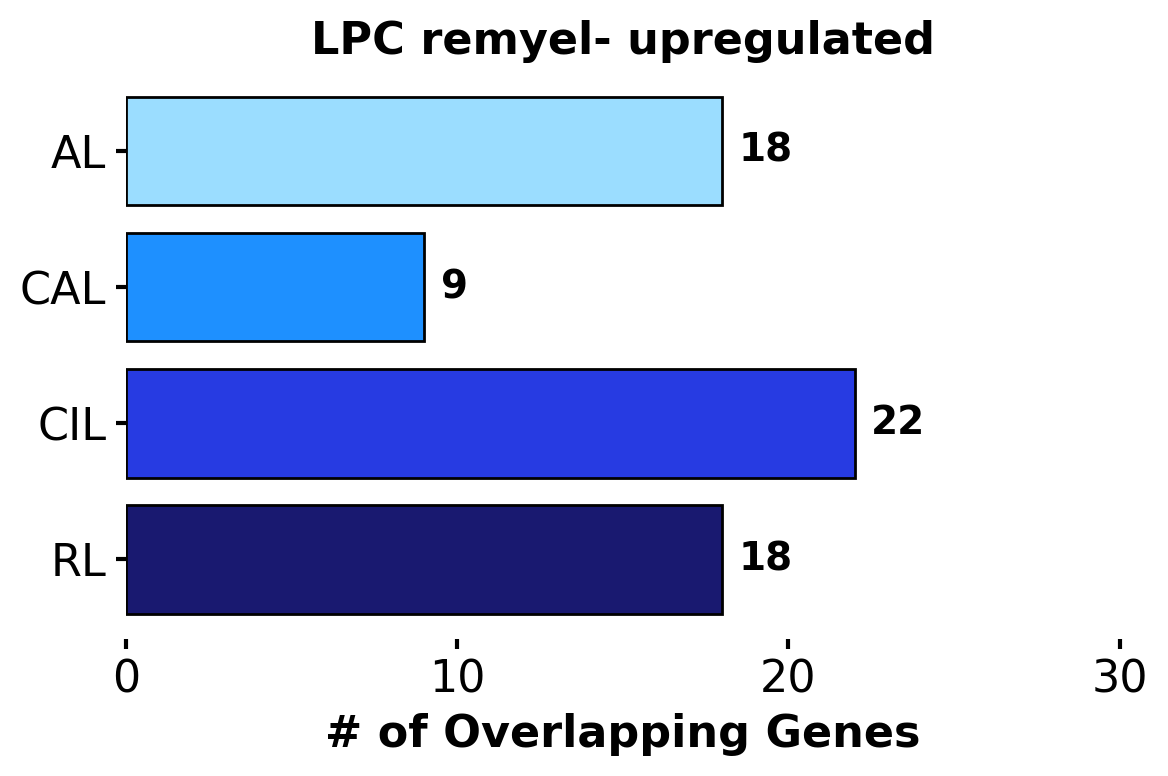

In [145]:
# Lesion names and CPZ counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts_cpz = [18, 9, 22, 18]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # same as LPC

# Create DataFrame for plotting
df_cpz = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts_cpz,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df_cpz['Lesion'],
    width=df_cpz['Genes'],
    color=df_cpz['Color'],
    edgecolor='black'
)

# Reverse y-axis to have AL on top (default barh goes bottom to top)
ax.invert_yaxis()
ax.yaxis.tick_left()  # labels on left for a right-facing plot
ax.yaxis.set_label_position("left")

# Add value labels at bar ends, slightly off the bar to the right
for i, (count, lesion) in enumerate(zip(df_cpz['Genes'], df_cpz['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='left', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30])
ax.set_xticklabels(['0', '10', '20', '30'])

# Title
ax.set_title("LPC remyel- upregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel.png", dpi=300, bbox_inches='tight')

plt.show()

## Now do down!!!

In [ ]:
# Convert lists to sets for upregulated genes
set_MOL_AL_down_all = set(genes_MOL_AL_all_down)
set_MOL_CAL_down_all = set(genes_MOL_CAL_all_down)
set_MOL_CIL_down_all = set(genes_MOL_CIL_all_down)
set_MOL_RL_down_all = set(genes_MOL_RL_all_down)

set_LPC_demyel_all_down = set(genes_LPC_demyel_all_down)
set_LPC_remyel_all_down = set(genes_LPC_remyel_all_down)
set_Cupr_demyel_all_down = set(genes_Cupr_demyel_all_down)

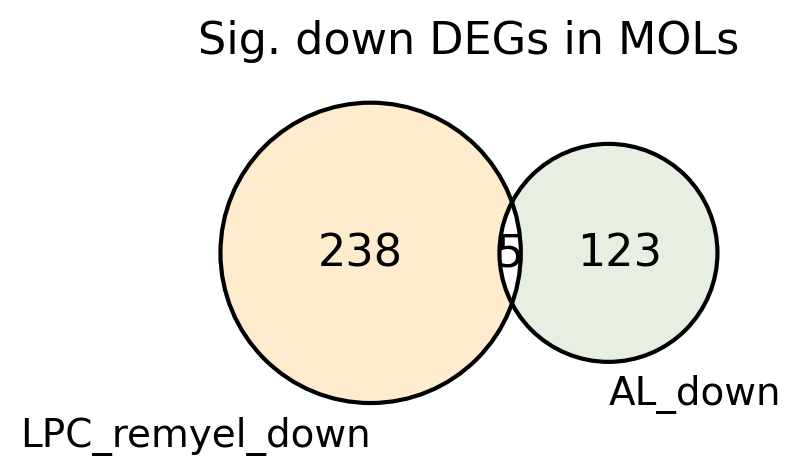

In [146]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_AL_down_all,
    set_labels=('LPC_remyel_down', 'AL_down'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

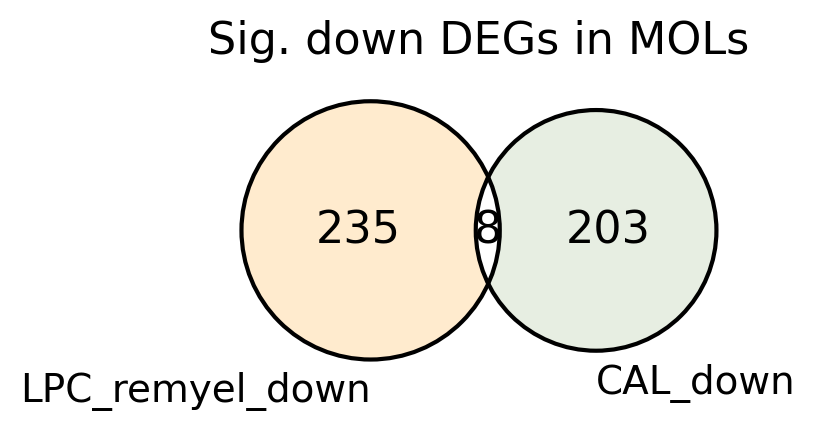

In [147]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_CAL_down_all,
    set_labels=('LPC_remyel_down', 'CAL_down'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

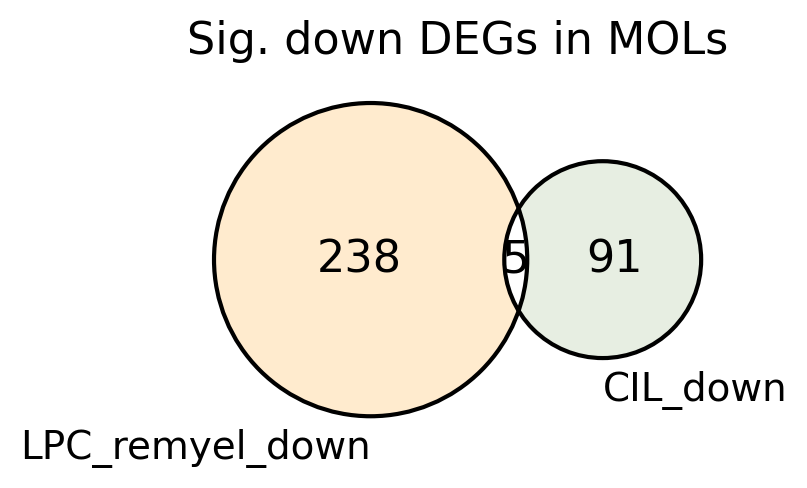

In [148]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_CIL_down_all,
    set_labels=('LPC_remyel_down', 'CIL_down'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

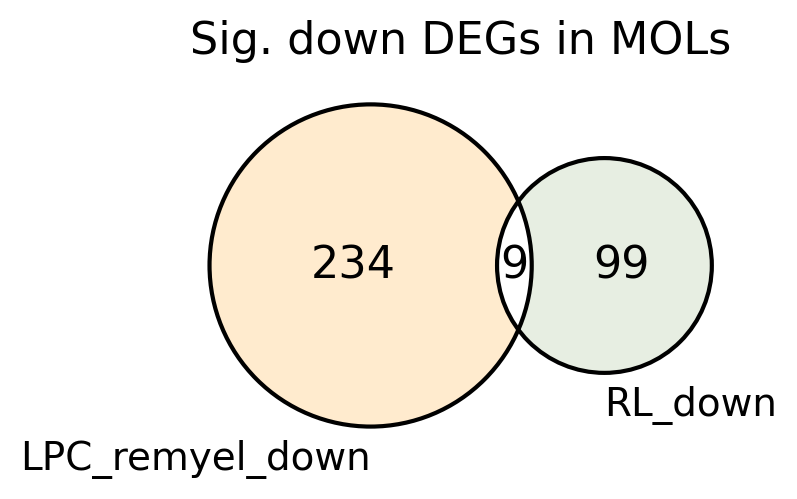

In [149]:
# Call the function
plot_venn2_from_sets(
    set1=set_LPC_remyel_all_down,
    set2=set_MOL_RL_down_all,
    set_labels=('LPC_remyel_down', 'RL_down'),
    set_colors=('#ffe6c2', '#e1eadb'),
    title='Sig. down DEGs in MOLs',
    font_size=16,
    #save_path='./figures/venn2_LPC_demyel_EAE_down.png'  # None
)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all & set_MOL_RL_down_all & set_LPC_demyel_all_down & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_down_all & set_LPC_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_CAL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_CIL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_RL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Overlap of upregulated genes
overlap_all = set_MOL_AL_down_all & set_MOL_CAL_down_all & set_MOL_CIL_down_all& set_MOL_RL_down_all & set_Cupr_demyel_all_down
print("Number of overlapping upregulated genes:", len(overlap_all))
print("Overlapping upregulated genes:", overlap_all)

In [ ]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_cupr_not_lpc = (union_AL_CAL_CIL_RL & set_Cupr_demyel_all_down) - set_LPC_demyel_all_down

print("Number of overlapping downregulated genes (Cupr but not LPC):", len(overlap_cupr_not_lpc))
print("Overlapping downregulated genes (Cupr but not LPC):", overlap_cupr_not_lpc)

In [ ]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_not_cupr = (union_AL_CAL_CIL_RL & set_LPC_demyel_all_down) - set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC but not cupr):", len(overlap_lpc_not_cupr))
print("Overlapping downregulated genes (LPC but not cupr):", overlap_lpc_not_cupr)

In [ ]:
# Union of AL, CAL, CIL, and RL downregulated genes
union_AL_CAL_CIL_RL = set_MOL_AL_down_all | set_MOL_CAL_down_all | set_MOL_CIL_down_all | set_MOL_RL_down_all

# Genes that overlap with Cdownr but NOT with LPC
overlap_lpc_and_cupr = union_AL_CAL_CIL_RL & set_LPC_demyel_all_down & set_Cupr_demyel_all_down

print("Number of overlapping downregulated genes (LPC and cupr):", len(overlap_lpc_and_cupr))
print("Overlapping downregulated genes (LPC and cupr):", overlap_lpc_and_cupr)

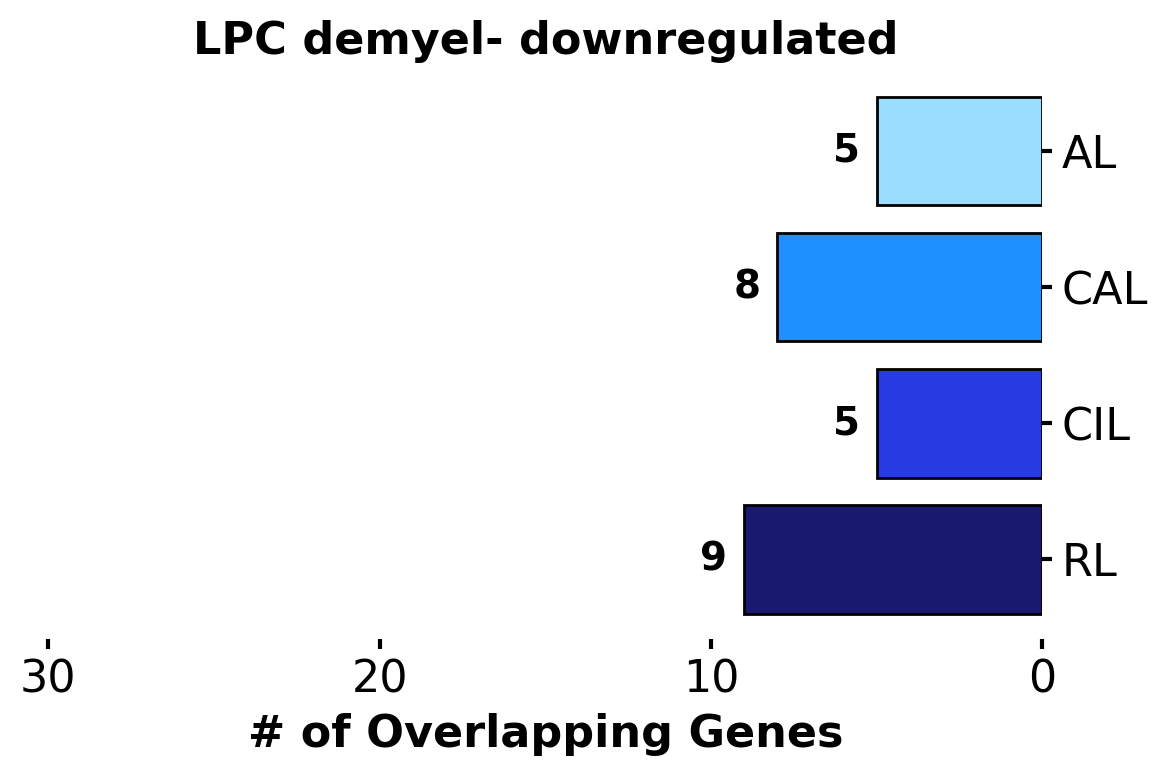

In [152]:
import seaborn as sns

# Lesion names and counts
lesions = ['AL', 'CAL', 'CIL', 'RL']
gene_counts = [5, 8, 5, 9]

# Colors for each lesion
lesion_colors = ["#9bddff", "#1e90ff", "#273be2", "#191970"]  # AL, CAL, CIL, RL

# Create DataFrame for plotting
import pandas as pd
df = pd.DataFrame({
    'Lesion': lesions,
    'Genes': gene_counts,
    'Color': lesion_colors
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(
    y=df['Lesion'],
    width=df['Genes'],
    color=df['Color'],
    edgecolor='black'
)

# Reverse y-axis and move to right (like your cell type plot)
ax.invert_yaxis()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.invert_xaxis()  # bars extend to the left

# Add value labels at bar ends, slightly off the bar to the left
for i, (count, lesion) in enumerate(zip(df['Genes'], df['Lesion'])):
    ax.text(count + 0.5, i, str(count),
            va='center', ha='right', fontsize=14, fontweight='bold')

# Axis styling
ax.set_xlabel('# of Overlapping Genes', fontsize=16, fontweight='bold')
ax.set_ylabel('')
ax.set_xticks([0, 10, 20, 30])
ax.set_xticklabels(['0', '10', '20', '30'])

# Title
ax.set_title("LPC demyel- downregulated", fontsize=16, fontweight='bold')

# Make ticks larger
ax.tick_params(axis='x', labelsize=16, width=1.5)
ax.tick_params(axis='y', labelsize=16, width=1.5)

sns.despine(left=True, bottom=True)
ax.grid(False)
plt.tight_layout()

# === Save the plot ===
plt.savefig("overlap_LPC_remyel_DOWN.png", dpi=300, bbox_inches='tight')

plt.show()

# Heatmap for paper: 

## Load R

In [7]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import pertpy as pt
import scanpy as sc
import pandas as pd
import seaborn as sb

plt.rcParams["figure.figsize"] = (7, 7)
import numpy as np

sc.settings.verbosity = 3


import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

## Define color palette
pal = sb.color_palette('Paired').as_hex()
design_palette = {'ACR':pal[3], 'CR':pal[7], 'AR':pal[9], 'joint_CR':pal[6]}
design_palette_df = pd.DataFrame(design_palette.values(), index =design_palette.keys() )
design_palette_df.columns = ['color']

import os,sys

figdir = './figures/'
if not os.path.exists(figdir):
    os.mkdir(figdir)
sc.settings.figdir = figdir

In [8]:
%%R
library(tidyverse)
library(reshape2)
library(patchwork)
library(ggrastr)
library(shadowtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(forcats)
library(data.table)

remove_x_axis <- function(){
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())  
}

remove_y_axis <- function(){
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title.y = element_blank())  
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths

data.table 1.16.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:reshape2’:

    dcast, melt

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



## Explore GSEA genes

In [9]:
%%R

merged_df <- fread("merged_deg_expression_df.csv")
dim(merged_df)

[1] 6144   28


In [10]:
%%R
# Filter merged_df for genes significant in at least one condition
sig_genes_df <- merged_df %>%
  filter(Sig_NAWM != "" | Sig_AL != "" | Sig_CAL != "" | Sig_CIL != "" | Sig_RL != "")

# Or, equivalently (safer if NAs exist):
sig_genes_df <- merged_df %>%
  filter(if_any(starts_with("Sig_"), ~ !is.na(.) & . != ""))

# Check how many genes are significant
cat("Number of significant genes:", nrow(sig_genes_df), "\n")

# Optionally list unique significant gene names
sig_genes <- unique(sig_genes_df$gene)
cat("Unique significant genes:", length(sig_genes), "\n")

Number of significant genes: 3312 
Unique significant genes: 3312 


In [30]:
%%R

# Load the data.table package
library(data.table)

# Read the files back into R
NAWM_df <- fread("./files/filtered_fgseaResSignificant_NAWM_all_glmm_zscore.csv")
AL_df <- fread("./files/filtered_fgseaResSignificant_AL_all_glmm_zscore.csv")
CAL_df <- fread("./files/filtered_fgseaResSignificant_CAL_all_glmm_zscore.csv")
CIL_df <- fread("./files/filtered_fgseaResSignificant_CIL_all_glmm_zscore.csv")
RL_df <- fread("./files/filtered_fgseaResSignificant_RL_all_glmm_zscore.csv")

In [31]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
NAWM_df$pathway <- gsub("^HALLMARK_", "", NAWM_df$pathway)
AL_df$pathway <- gsub("^HALLMARK_", "", AL_df$pathway)
CAL_df$pathway <- gsub("^HALLMARK_", "", CAL_df$pathway)
CIL_df$pathway <- gsub("^HALLMARK_", "", CIL_df$pathway)
RL_df$pathway <- gsub("^HALLMARK_", "", RL_df$pathway)

In [32]:
%%R
#print(unique(NAWM_df$pathway))
print(unique(AL_df$pathway))
print(unique(CAL_df$pathway))
#print(unique(CIL_df$pathway))
#print(unique(RL_df$pathway))

[1] "COMPLEMENT"                "E2F_TARGETS"              
[3] "INFLAMMATORY_RESPONSE"     "INTERFERON_ALPHA_RESPONSE"
[5] "INTERFERON_GAMMA_RESPONSE" "OXIDATIVE_PHOSPHORYLATION"
[7] "P53_PATHWAY"               "TNFA_SIGNALING_VIA_NFKB"  
[9] "UV_RESPONSE_UP"           
[1] "IL6_JAK_STAT3_SIGNALING"   "INTERFERON_ALPHA_RESPONSE"
[3] "OXIDATIVE_PHOSPHORYLATION" "P53_PATHWAY"              
[5] "TNFA_SIGNALING_VIA_NFKB"   "UV_RESPONSE_UP"           


In [98]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- NAWM_df[NAWM_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list1 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list1, collapse = ", "))

BIRC3, TGIF1, NFKBIA, ATP2B1, IRF1, IER5, CEBPD, LITAF, GADD45A, FOS, TNIP2, IFIH1, GFPT2, CDKN1A, SGK1, IRS2, KLF9, NR4A1, MARCKS, BIRC2, NFKB2, CLCF1, IL18, NFKBIE, SOCS3, BMP2, TRIB1, G0S2, DUSP4, SAT1, ID2, NINJ1, TNC, CCND1, B4GALT1, TRAF1, DRAM1, ACKR3, EIF1, SERPINE1, SMAD3, KLF10, TNIP1, TAP1, KLF2, SOD2

In [99]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- AL_df[AL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list2 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list2, collapse = ", "))

PDLIM5, TGIF1, IRS2, SGK1, IFIH1, ID2, RELA, CEBPB, NFKBIA, BIRC3, EGR1, ATP2B1, GFPT2, SMAD3, B4GALT1, IER5, CSF1, CDKN1A, BCL6, SERPINE1, DRAM1, CEBPD, IRF1, FOS, KLF6, SPSB1, IL6ST, TNIP2, PNRC1, ETS2, F3, BMP2, FOSL2, EGR3, BHLHE40, MAFF, LITAF, B4GALT5, TRIB1, TSC22D1, ZFP36, NFAT5, NFKB1, BTG1, KYNU, PANX1, PPP1R15A, CFLAR, MAP2K3, PHLDA1, MCL1, GEM, GADD45A, MXD1, SAT1, FOSB

In [100]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- CAL_df[CAL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list3 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list3, collapse = ", "))

BIRC3, CSF1, RELA, IRS2, IFIH1, CEBPD, TGIF1, PHLDA1, IER5, IL6ST, KLF6, G0S2, BHLHE40, KYNU, LITAF, MCL1, JUNB, TNIP2, DRAM1, TNFAIP8, NFAT5, PNRC1, B4GALT5, SGK1, MXD1, NFKB1, NFKBIA, MAFF, PPP1R15A, CDKN1A, TRAF1, CEBPB, ID2, FOSL2, GFPT2, TNIP1, PTPRE, BTG1, IRF1, FOS

In [101]:
%%R
# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- CIL_df[CIL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list4 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list4, collapse = ", "))

CEBPD, FOS, TGIF1, NFKBIA, ZFP36, SOCS3, BIRC3, TRAF1, KLF10, PDLIM5, KLF9, CCND1, TRIP10, BCL6, CDKN1A, FOSL2, SERPINE1, GFPT2, SGK1, LITAF, SPSB1, NR4A1, CEBPB, CLCF1, GADD45B, PLK2, BMP2, KYNU, NINJ1, IRS2, MAP2K3, TNC, IL6ST, JUNB, IL15RA, ICOSLG, RNF19B, MAFF, PMEPA1, KLF6, PFKFB3, RELA, TRIB1, LDLR, BCL3, PLAUR, GCH1, IER5, EGR1, CFLAR, CSF1, DRAM1, TNIP2, FOSB, ATP2B1, EFNA1, B4GALT1, GADD45A, KDM6B, FOSL1, SOD2, RIPK2, BHLHE40, PHLDA1, B4GALT5, REL, CD83, TSC22D1, PPP1R15A, GEM, STAT5A, TNFAIP6, MARCKS, NFAT5, ZC3H12A

In [102]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- RL_df[RL_df$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Split the string into individual genes (assuming "|" separator)
gene_list5 <- unlist(strsplit(leading_edge_genes, "\\|"))

# Print as a comma-separated list
cat(paste(gene_list5, collapse = ", "))

PDLIM5, BIRC3, FOS, SOCS3, ZFP36, BMP2, NFKBIA, LITAF, RELA, CSF1, KLF10, BIRC2, TNIP2, NR4A1, LDLR, KLF6, BTG1, JUNB, CEBPD, TNFSF9, TAP1, MAFF, BCL6, SPSB1, EGR1, IRS2, B4GALT5, IL6ST, ATP2B1, KLF9, DDX58, TNIP1, IFIH1, EFNA1, TRIP10, IRF1, IER5, ZC3H12A, TRIB1, NFAT5, RIPK2, TNFAIP6, ATF3, GADD45B, NINJ1, KDM6B, MAP2K3, SGK1, BTG3, SERPINB8, MCL1, STAT5A, PTPRE, REL, PFKFB3

In [104]:
%%R
# Assuming you already have gene_list1 through gene_list5

# Combine them using union
union_AL_CAL_CIL_RL <- Reduce(union, list(gene_list1, gene_list2, gene_list3, gene_list4, gene_list5))

# If you just want the number of unique genes
cat("Number of unique genes:", length(union_AL_CAL_CIL_RL), "\n")

# Wrap each gene in quotes
quoted_genes <- paste0('"', union_AL_CAL_CIL_RL, '"')

# Print as a comma-separated string
cat(paste(quoted_genes, collapse = ", "), "\n")

Number of unique genes: 107 
"BIRC3", "TGIF1", "NFKBIA", "ATP2B1", "IRF1", "IER5", "CEBPD", "LITAF", "GADD45A", "FOS", "TNIP2", "IFIH1", "GFPT2", "CDKN1A", "SGK1", "IRS2", "KLF9", "NR4A1", "MARCKS", "BIRC2", "NFKB2", "CLCF1", "IL18", "NFKBIE", "SOCS3", "BMP2", "TRIB1", "G0S2", "DUSP4", "SAT1", "ID2", "NINJ1", "TNC", "CCND1", "B4GALT1", "TRAF1", "DRAM1", "ACKR3", "EIF1", "SERPINE1", "SMAD3", "KLF10", "TNIP1", "TAP1", "KLF2", "SOD2", "PDLIM5", "RELA", "CEBPB", "EGR1", "CSF1", "BCL6", "KLF6", "SPSB1", "IL6ST", "PNRC1", "ETS2", "F3", "FOSL2", "EGR3", "BHLHE40", "MAFF", "B4GALT5", "TSC22D1", "ZFP36", "NFAT5", "NFKB1", "BTG1", "KYNU", "PANX1", "PPP1R15A", "CFLAR", "MAP2K3", "PHLDA1", "MCL1", "GEM", "MXD1", "FOSB", "JUNB", "TNFAIP8", "PTPRE", "TRIP10", "GADD45B", "PLK2", "IL15RA", "ICOSLG", "RNF19B", "PMEPA1", "PFKFB3", "LDLR", "BCL3", "PLAUR", "GCH1", "EFNA1", "KDM6B", "FOSL1", "RIPK2", "REL", "CD83", "STAT5A", "TNFAIP6", "ZC3H12A", "TNFSF9", "DDX58", "ATF3", "BTG3", "SERPINB8" 


In [95]:
%%R
# Combine gene lists using intersection
intersect_AL_CAL_CIL_RL <- Reduce(intersect, list(gene_list1, gene_list2, gene_list3, gene_list4, gene_list5))

# Print the intersection of genes
cat("Intersection P53:", paste(intersect_AL_CAL_CIL_RL, collapse = ", "), "\n")

# If you just want the number of common genes
cat("Number of common genes:", length(intersect_AL_CAL_CIL_RL), "\n")

Intersection P53: BIRC3, NFKBIA, IER5, CEBPD, LITAF, FOS, TNIP2, SGK1, IRS2 
Number of common genes: 9 


In [96]:
%%R
# Keep only genes that are both annotated AND significant
pathway_sig_genes <- intersect(intersect_AL_CAL_CIL_RL, sig_genes)

# If you want to see how many remain:
cat("Genes retained for plotting:", length(pathway_sig_genes), "\n")
pathway_sig_genes

Genes retained for plotting: 7 
[1] "BIRC3"  "NFKBIA" "IER5"   "CEBPD"  "FOS"    "SGK1"   "IRS2"  


In [97]:
%%R

# Specify how many "Sig_" columns must be TRUE to keep a gene
min_sig_count <- 3  # <-- set this to whatever threshold you want

sig_genes_df <- merged_df %>%
  # Count how many Sig_ columns are non-empty per gene
  mutate(sig_count = rowSums(across(starts_with("Sig_"), ~ !is.na(.) & . != ""))) %>%
  # Keep genes that are significant in at least 'min_sig_count' conditions
  filter(sig_count >= min_sig_count)

# Check how many genes meet the condition
cat("Number of genes significant in at least", min_sig_count, "conditions:", nrow(sig_genes_df), "\n")

# Get the unique gene names
sig_genes <- unique(sig_genes_df$gene)
cat("Unique significant genes:", length(sig_genes), "\n")

# Keep only genes that are both annotated AND significant
pathway_sig_genes <- intersect(union_AL_CAL_CIL_RL, sig_genes)

# If you want to see how many remain:
cat("Genes retained for plotting:", length(pathway_sig_genes), "\n")
pathway_sig_genes

Number of genes significant in at least 3 conditions: 368 
Unique significant genes: 368 
Genes retained for plotting: 6 
[1] "BIRC3"  "TGIF1"  "NFKBIA" "IER5"   "CEBPD"  "IRS2"  


# Pseudobulk heatmap- human genes

In [36]:
adata_pb = sc.read('./pb_adata_MOL_combined.h5ad')
adata_pb

AnnData object with n_obs × n_vars = 187 × 27766
    obs: 'sample', 'sample_lesion', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [37]:
print(f"All samples: {adata_pb.shape[0]}")

# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

All samples: 187


/tmp/2110800.1.long/ipykernel_1681715/3029160791.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)


stim,AL,CAL,CIL,NAWM,RL,WM
cell_type,,,,,,
COPs,1,0,2,1,1,0
MOLs,21,17,13,17,11,13
OPCs,21,17,12,17,10,13


In [38]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['MOLs'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (92, 27766)


In [39]:
# Check if the 'sample_rep' column exists
if 'sample_lesion' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_lesion', inplace=True)
else:
    print("The column 'sample' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [40]:
# Add the index back as a column called 'sample_lesion'
adata_sub.obs['sample_lesion'] = adata_sub.obs.index

In [41]:
# Replace space with underscore in the 'seq_pool' column
adata_sub.obs['seq_pool'] = adata_sub.obs['seq_pool'].str.replace(' ', '_')

In [42]:
adata_sub.obs['indiv_id'] = adata_sub.obs['sample'].str.split('-').str[0]
adata_sub.obs[:5]

,sample,diagnosis,sample_source,cell_type,sample_rep,replicate_cat,stim,sex,seq_pool,age_scale,age_cat,pmi_cat,pmi_cat2,batch,lib_size,log_lib_size,sample_lesion,indiv_id
Ind86-Sample2_WM,Ind86-Sample2,CTR,Edinburgh BB,MOLs,WM_2,2,WM,M,Pool_2,0.782451,over_70,over_12H,over_12H,0,1037497,13.852322,Ind86-Sample2_WM,Ind86
Ind98-Sample2_WM,Ind98-Sample2,CTR,Edinburgh BB,MOLs,WM_1,1,WM,M,Pool_6,-1.759706,under_50,over_12H,over_12H,0,6732392,15.722441,Ind98-Sample2_WM,Ind98
Ind101-Sample1_CIL,Ind101-Sample1,SPMS,UK MS TB,MOLs,CIL_1,1,CIL,F,Pool_5,0.645037,inbetween,over_12H,over_12H,0,2928138,14.889877,Ind101-Sample1_CIL,Ind101
Ind101-Sample2_CIL,Ind101-Sample2,SPMS,UK MS TB,MOLs,CIL_2,2,CIL,F,Pool_3,0.645037,inbetween,over_12H,over_12H,0,2791545,14.842106,Ind101-Sample2_CIL,Ind101
Ind101-Sample3_RL,Ind101-Sample3,SPMS,UK MS TB,MOLs,RL_1,1,RL,F,Pool_1,0.645037,inbetween,over_12H,over_12H,0,12920462,16.374323,Ind101-Sample3_RL,Ind101


In [43]:
adata_sub.obs['cell_stim'] = adata_sub.obs['cell_type'].astype(str) + '_' + adata_sub.obs['stim'].astype(str)

In [44]:
# Extract the data as a pandas DataFrame
df = adata_sub.obs[['cell_stim', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)
summary_table

/tmp/2110800.1.long/ipykernel_1681715/2450846806.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)


stim,AL,CAL,CIL,NAWM,RL,WM
cell_stim,,,,,,
MOLs_AL,21,0,0,0,0,0
MOLs_CAL,0,17,0,0,0,0
MOLs_CIL,0,0,13,0,0,0
MOLs_NAWM,0,0,0,17,0,0
MOLs_RL,0,0,0,0,11,0
MOLs_WM,0,0,0,0,0,13


In [45]:
adata_sub

AnnData object with n_obs × n_vars = 92 × 27766
    obs: 'sample', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size', 'sample_lesion', 'indiv_id', 'cell_stim'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [46]:
import seaborn as sns

/tmp/2110800.1.long/ipykernel_1681715/3421729367.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


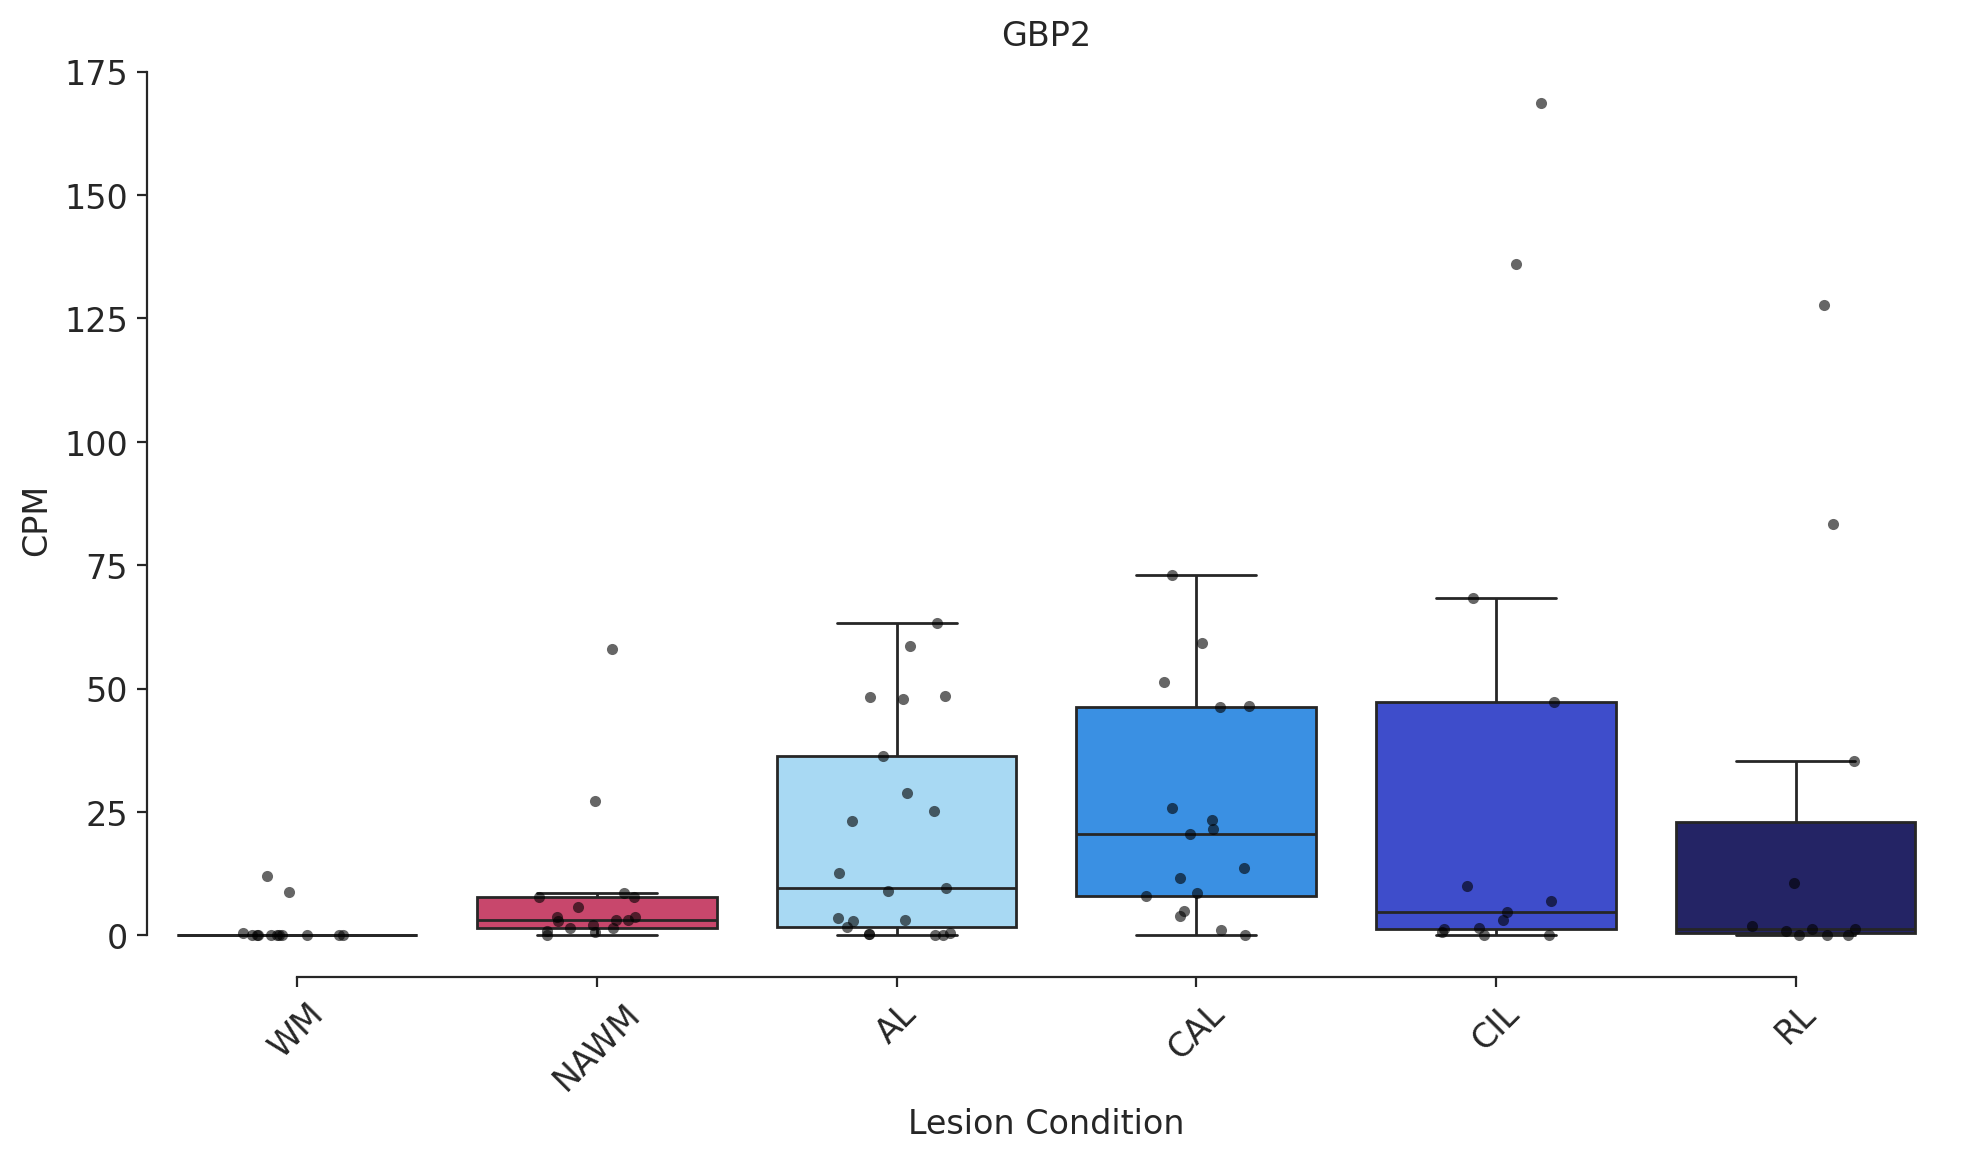

In [47]:
# Specify your gene
gene_to_plot = "GBP2"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

#df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/2110800.1.long/ipykernel_1681715/2168120601.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


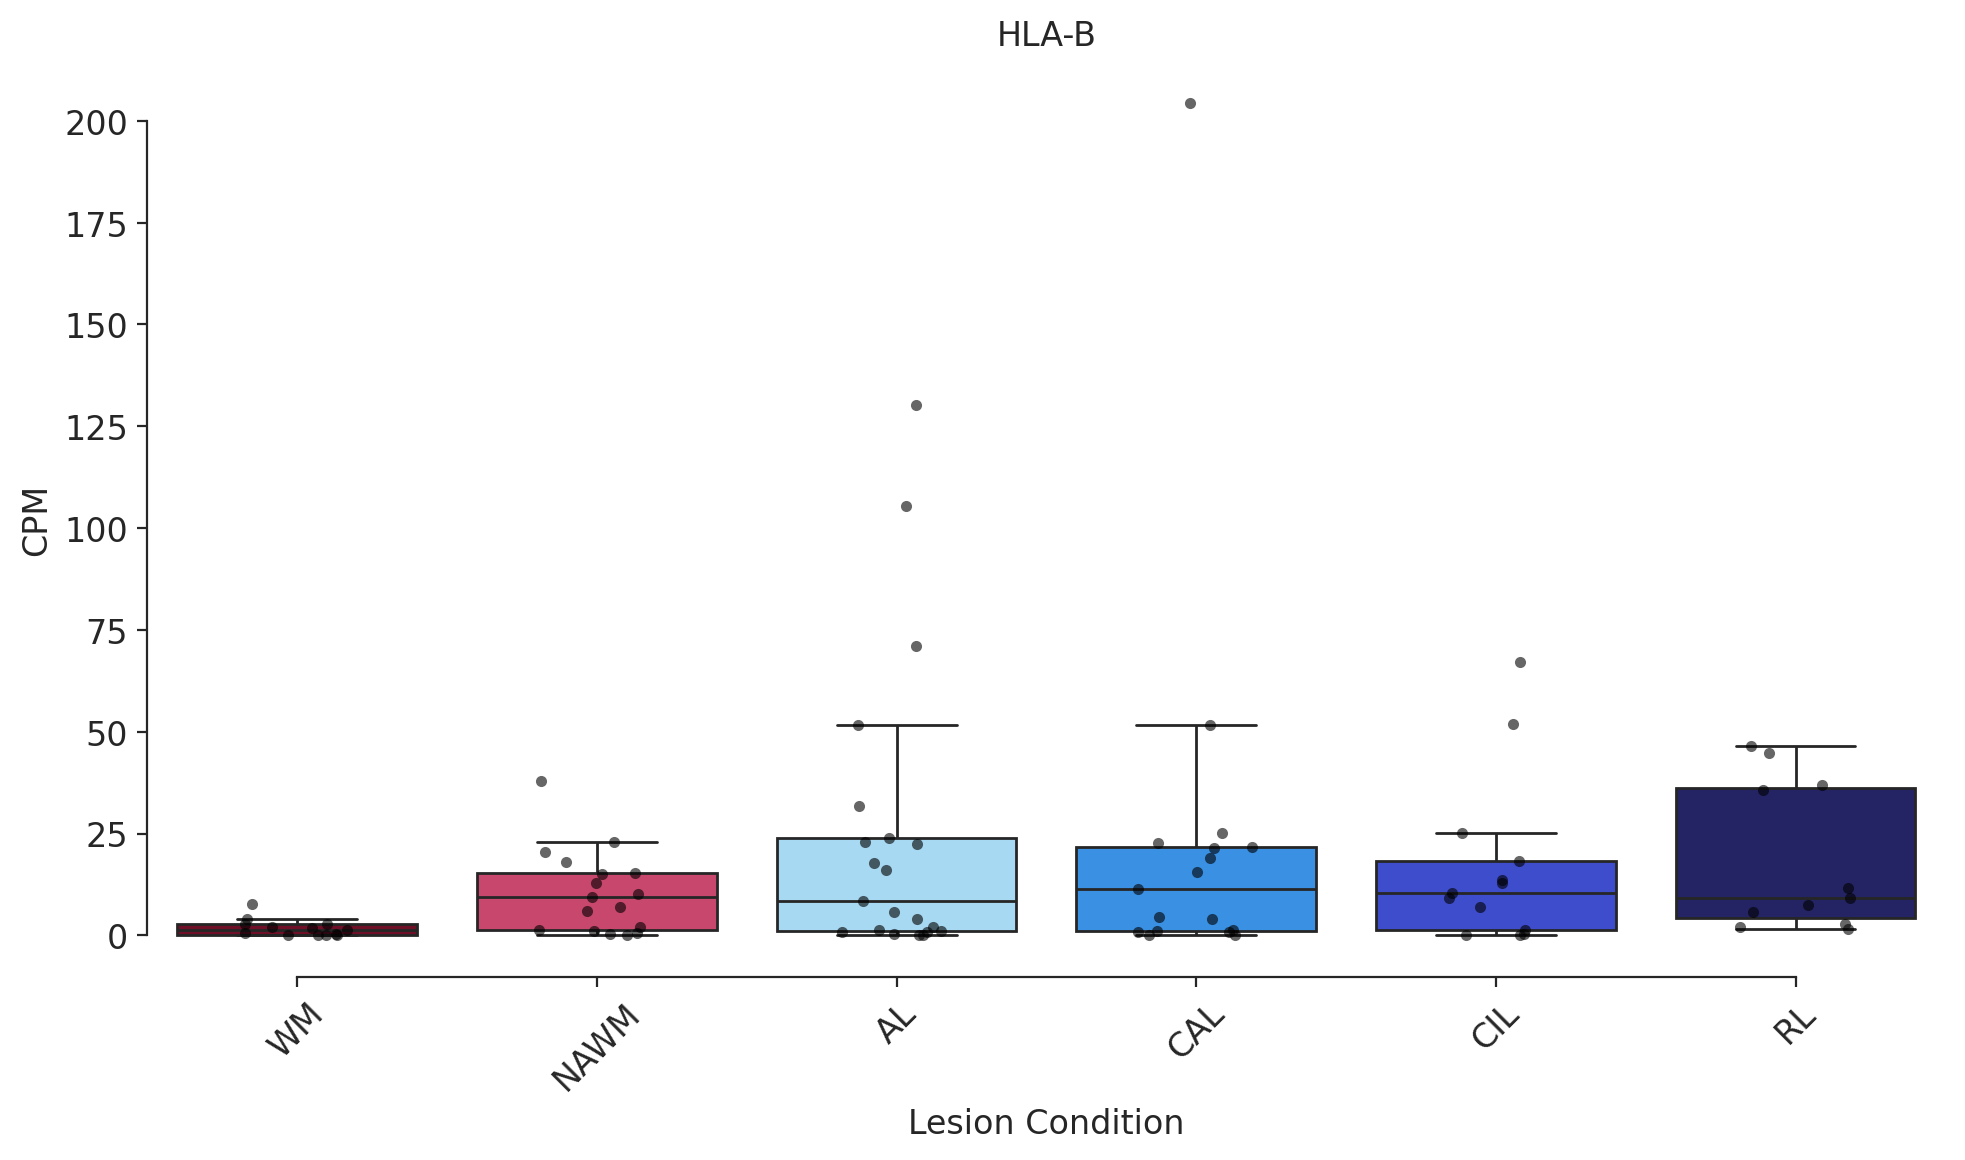

In [48]:
# Specify your gene
gene_to_plot = "HLA-B"

# Confirm the gene is in adata_sub.var_names
if gene_to_plot not in adata_sub.var_names:
    raise ValueError(f"{gene_to_plot} not found in adata_sub.var_names")

# Extract counts or normalized counts (e.g., log1p transformed)
# Here we assume raw counts; adjust if you already have CPM or log-transformed
counts = adata_sub[:, gene_to_plot].X.toarray().flatten()

# You can convert counts to CPM if desired:
library_sizes = adata_sub.obs['lib_size']
cpm = (counts / library_sizes) * 1e6

# Create DataFrame with counts and metadata
df = pd.DataFrame({
    "cpm": cpm,
    "stim": adata_sub.obs["stim"].values,
    "cell_stim": adata_sub.obs["cell_stim"].values
})

#df["cpm_log1p"] = np.log1p(df["cpm"])

palette = {
    "AL": "#9bddff",
    "CAL": "#1e90ff",
    "CIL": "#273be2",
    "NAWM": "#de3163",
    "RL": "#191970",
    "WM": "#800020"
}

custom_order = ["WM", "NAWM", "AL", "CAL", "CIL", "RL"]

plt.figure(figsize=(10,6))

# Boxplot
sns.boxplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    palette=palette,
    showfliers=False,
    linewidth=1
)

# Jitter
sns.stripplot(
    data=df,
    x="stim",
    y="cpm",
    order=custom_order,
    color="k",
    size=4,
    alpha=0.6,
    jitter=0.2
)

plt.title(f"{gene_to_plot}")
plt.ylabel("CPM")
plt.xlabel("Lesion Condition")
plt.xticks(rotation=45)

sns.despine(trim=True, top=True, right=True)
plt.tight_layout()
plt.show()

In [49]:
adata_sub

AnnData object with n_obs × n_vars = 92 × 27766
    obs: 'sample', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size', 'sample_lesion', 'indiv_id', 'cell_stim'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [50]:
# Extract the data as a pandas DataFrame
df = adata_sub.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

/tmp/2110800.1.long/ipykernel_1681715/3184191289.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)


stim,AL,CAL,CIL,NAWM,RL,WM
cell_type,,,,,,
MOLs,21,17,13,17,11,13


In [51]:
# Calculate library size
lib_size = adata_sub.layers['counts'].sum(axis=1)
cpm = (adata_sub.layers['counts'].T / lib_size).T * 1e6

# Take log2(CPM + 1)
log2cpm = np.log2(cpm + 1)

# Store it (optional)
adata_sub.layers['log2CPM'] = log2cpm

In [52]:
# Create a DataFrame from log2CPM layer (genes x samples)
log2cpm_df = pd.DataFrame(
    adata_sub.layers['log2CPM'],
    index=adata_sub.obs.index,
    columns=adata_sub.var_names
)

# Add group labels to the DataFrame
log2cpm_df['group'] = adata_sub.obs['stim'].values

# Group by pseudobulk group and average
pseudobulk_df = log2cpm_df.groupby('group').mean().T  # Now genes x groups
pseudobulk_df.head

/tmp/2110800.1.long/ipykernel_1681715/2385841868.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pseudobulk_df = log2cpm_df.groupby('group').mean().T  # Now genes x groups


<bound method NDFrame.head of group             AL       CAL       CIL      NAWM        RL        WM
AL627309.1  2.986061  2.988172  3.232844  2.814991  3.320971  3.039778
AL627309.2  0.018989  0.010483  0.032605  0.048334  0.044250  0.061069
AC114498.1  0.210957  0.391906  0.193617  0.206333  0.312721  0.334621
AL669831.2  0.029449  0.013198  0.115899  0.009978  0.006180  0.012283
AL669831.5  5.579268  5.446799  5.313297  5.213090  5.140210  4.947096
...              ...       ...       ...       ...       ...       ...
AC007325.4  1.653082  1.573461  1.886534  1.667210  1.800057  1.732030
AC007325.2  0.298018  0.241467  0.591723  0.409463  0.370056  0.414034
AL354822.1  2.744445  3.340706  2.659466  2.859485  2.759581  2.790493
AC004556.1  0.676655  0.519139  0.083777  0.717236  0.294359  0.197638
AC240274.1  3.221251  2.972796  3.258071  3.109023  2.979962  3.315583

[27766 rows x 6 columns]>

In [53]:
pseudobulk_df.columns

CategoricalIndex(['AL', 'CAL', 'CIL', 'NAWM', 'RL', 'WM'], categories=['AL', 'CAL', 'CIL', 'NAWM', 'RL', 'WM'], ordered=False, dtype='category', name='group')

In [54]:
print(MOL_NAWM.shape)
print(MOL_AL.shape)
print(MOL_CAL.shape)
print(MOL_CIL.shape)
print(MOL_RL.shape)

(15298, 12)
(14958, 12)
(16952, 12)
(15952, 12)
(17208, 12)


In [55]:
MOL_RL[:5]

,gene,logFC_WM,se,pvalue,convergence,pdHess,logLik,AIC,error,FDR,status,logFC
0,ST8SIA5,-1.703685,0.175723,3.158016e-22,0,True,-145.762227,309.524455,NaN,2.986220e-18,OK,1.703685
1,CLVS2,-3.858996,0.419677,3.744289e-20,0,True,-90.697937,199.395874,NaN,2.360399e-16,OK,3.858996
2,DDX60L,-1.171806,0.138665,2.897042e-17,0,True,-82.644360,183.288719,NaN,1.369721e-13,OK,1.171806
3,ARHGAP24,-2.431437,0.297213,2.819908e-16,0,True,-119.665252,257.330503,NaN,1.066602e-12,OK,2.431437
4,AC008840.1,-1.065743,0.131450,5.163720e-16,0,True,-83.317874,184.635747,NaN,1.627604e-12,OK,1.065743


In [56]:
# Keep only gene, logFC, FDR
df_MOL_NAWM = MOL_NAWM[['gene', 'logFC', 'FDR']].copy()
df_MOL_AL = MOL_AL[['gene', 'logFC', 'FDR']].copy()
df_MOL_CAL = MOL_CAL[['gene', 'logFC', 'FDR']].copy()
df_MOL_CIL = MOL_CIL[['gene', 'logFC', 'FDR']].copy()
df_MOL_RL = MOL_RL[['gene', 'logFC', 'FDR']].copy()

# Rename columns to avoid name conflicts
df_MOL_NAWM.columns = ['gene', 'logFC_NAWM', 'FDR_NAWM']
df_MOL_AL.columns = ['gene', 'logFC_AL', 'FDR_AL']
df_MOL_CAL.columns = ['gene', 'logFC_CAL', 'FDR_CAL']
df_MOL_CIL.columns = ['gene', 'logFC_CIL', 'FDR_CIL']
df_MOL_RL.columns = ['gene', 'logFC_RL', 'FDR_RL']

# Merge all five dataframes on gene
deg_merged = (
    df_MOL_NAWM
    .merge(df_MOL_AL, on='gene', how='outer')
    .merge(df_MOL_CAL, on='gene', how='outer')
    .merge(df_MOL_CIL, on='gene', how='outer')
    .merge(df_MOL_RL, on='gene', how='outer')
)

# Check the final shape
print(deg_merged.shape)

(20002, 11)


In [66]:
# Subset: keep genes where any FDR column is < 0.05
deg_sig = deg_merged[
    (deg_merged['FDR_NAWM'] <= 0.05) |
    (deg_merged['FDR_AL'] <= 0.05) |
    (deg_merged['FDR_CAL'] <= 0.05) |
    (deg_merged['FDR_CIL'] <= 0.05) |
    (deg_merged['FDR_RL'] <= 0.05)
].copy()

print("Significant subset shape:", deg_sig.shape)

# Define DEG status per condition (FDR <= 0.05 and |logFC| >= 0.585)
deg_sig['DEG_NAWM'] = (
    (deg_sig['FDR_NAWM'] <= 0.05) &
    (deg_sig['logFC_NAWM'].abs() >= 0.585)
)
deg_sig['DEG_AL'] = (
    (deg_sig['FDR_AL'] <= 0.05) &
    (deg_sig['logFC_AL'].abs() >= 0.585)
)
deg_sig['DEG_CAL'] = (
    (deg_sig['FDR_CAL'] <= 0.05) &
    (deg_sig['logFC_CAL'].abs() >= 0.585)
)
deg_sig['DEG_CIL'] = (
    (deg_sig['FDR_CIL'] <= 0.05) &
    (deg_sig['logFC_CIL'].abs() >= 0.585)
)
deg_sig['DEG_RL'] = (
    (deg_sig['FDR_RL'] <= 0.05) &
    (deg_sig['logFC_RL'].abs() >= 0.585)
)

# Function to assign significance symbols
def get_sig_symbol(fdr, deg):
    if not deg or pd.isnull(fdr):
        return ''
    elif fdr < 0.001:
        return '***'
    elif fdr < 0.01:
        return '**'
    elif fdr < 0.05:
        return '*'
    else:
        return ''

# Apply significance symbol labeling for each condition
deg_sig['Sig_NAWM'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_NAWM'], row['DEG_NAWM']), axis=1
)
deg_sig['Sig_AL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_AL'], row['DEG_AL']), axis=1
)
deg_sig['Sig_CAL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_CAL'], row['DEG_CAL']), axis=1
)
deg_sig['Sig_CIL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_CIL'], row['DEG_CIL']), axis=1
)
deg_sig['Sig_RL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_RL'], row['DEG_RL']), axis=1
)

# Preview the results
deg_sig.head()

Significant subset shape: (6144, 11)


,gene,logFC_NAWM,FDR_NAWM,logFC_AL,FDR_AL,logFC_CAL,FDR_CAL,logFC_CIL,FDR_CIL,logFC_RL,...,DEG_NAWM,DEG_AL,DEG_CAL,DEG_CIL,DEG_RL,Sig_NAWM,Sig_AL,Sig_CAL,Sig_CIL,Sig_RL
0,A1BG,-0.090983,0.824757,-0.687731,0.029422,-0.731390,0.020813,NaN,NaN,-0.319742,...,False,True,True,False,False,,*,*,,
1,A1BG-AS1,-0.319558,0.105842,-0.679867,0.009978,-0.343471,0.327415,-0.182417,0.287844,-0.455828,...,False,True,False,False,False,,**,,,
7,AAAS,NaN,NaN,-0.051053,0.868925,-0.059536,0.812807,-0.214309,0.010924,-0.249933,...,False,False,False,False,False,,,,,
13,AAMDC,NaN,NaN,0.051944,0.606157,0.122334,0.213331,0.190893,0.051328,0.242882,...,False,False,False,False,False,,,,,
18,AASDH,-0.164280,0.172384,-0.238319,0.121958,-0.132422,0.470422,-0.194223,0.007433,-0.063690,...,False,False,False,False,False,,,,,


In [57]:
# Subset: keep genes where any FDR column is < 0.05
deg_sig = deg_merged[
    (deg_merged['FDR_NAWM'] <= 0.05) |
    (deg_merged['FDR_AL'] <= 0.05) |
    (deg_merged['FDR_CAL'] <= 0.05) |
    (deg_merged['FDR_CIL'] <= 0.05) |
    (deg_merged['FDR_RL'] <= 0.05)
].copy()

print("Significant subset shape:", deg_sig.shape)

# Define DEG status per condition (FDR <= 0.05 and |logFC| >= 0.585)
deg_sig['DEG_NAWM'] = (
    (deg_sig['FDR_NAWM'] <= 0.05) &
    (deg_sig['logFC_NAWM'] >= 0.585)
)
deg_sig['DEG_AL'] = (
    (deg_sig['FDR_AL'] <= 0.05) &
    (deg_sig['logFC_AL'] >= 0.585)
)
deg_sig['DEG_CAL'] = (
    (deg_sig['FDR_CAL'] <= 0.05) &
    (deg_sig['logFC_CAL'] >= 0.585)
)
deg_sig['DEG_CIL'] = (
    (deg_sig['FDR_CIL'] <= 0.05) &
    (deg_sig['logFC_CIL'] >= 0.585)
)
deg_sig['DEG_RL'] = (
    (deg_sig['FDR_RL'] <= 0.05) &
    (deg_sig['logFC_RL'] >= 0.585)
)

# Function to assign significance symbols
def get_sig_symbol(fdr, deg):
    if not deg or pd.isnull(fdr):
        return ''
    elif fdr < 0.001:
        return '***'
    elif fdr < 0.01:
        return '**'
    elif fdr < 0.05:
        return '*'
    else:
        return ''

# Apply significance symbol labeling for each condition
deg_sig['Sig_NAWM'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_NAWM'], row['DEG_NAWM']), axis=1
)
deg_sig['Sig_AL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_AL'], row['DEG_AL']), axis=1
)
deg_sig['Sig_CAL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_CAL'], row['DEG_CAL']), axis=1
)
deg_sig['Sig_CIL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_CIL'], row['DEG_CIL']), axis=1
)
deg_sig['Sig_RL'] = deg_sig.apply(
    lambda row: get_sig_symbol(row['FDR_RL'], row['DEG_RL']), axis=1
)

# Preview the results
deg_sig.head()

Significant subset shape: (6144, 11)


,gene,logFC_NAWM,FDR_NAWM,logFC_AL,FDR_AL,logFC_CAL,FDR_CAL,logFC_CIL,FDR_CIL,logFC_RL,...,DEG_NAWM,DEG_AL,DEG_CAL,DEG_CIL,DEG_RL,Sig_NAWM,Sig_AL,Sig_CAL,Sig_CIL,Sig_RL
0,A1BG,-0.090983,0.824757,-0.687731,0.029422,-0.731390,0.020813,NaN,NaN,-0.319742,...,False,False,False,False,False,,,,,
1,A1BG-AS1,-0.319558,0.105842,-0.679867,0.009978,-0.343471,0.327415,-0.182417,0.287844,-0.455828,...,False,False,False,False,False,,,,,
7,AAAS,NaN,NaN,-0.051053,0.868925,-0.059536,0.812807,-0.214309,0.010924,-0.249933,...,False,False,False,False,False,,,,,
13,AAMDC,NaN,NaN,0.051944,0.606157,0.122334,0.213331,0.190893,0.051328,0.242882,...,False,False,False,False,False,,,,,
18,AASDH,-0.164280,0.172384,-0.238319,0.121958,-0.132422,0.470422,-0.194223,0.007433,-0.063690,...,False,False,False,False,False,,,,,


## Combine df sig and pseudobulk log2cpm counts

In [67]:
# Merge by gene name
merged_df = deg_sig.merge(
    pseudobulk_df, 
    left_on='gene', 
    right_index=True,  # pseudobulk_df uses gene names as index
    how='left'
)
merged_df.shape

(6144, 27)

In [68]:
# Save merged_df with DEGs and asterisks
merged_df.to_csv("merged_deg_expression_df.csv")

# Save pseudobulk log2CPM expression data
pseudobulk_df.to_csv("pseudobulk_log2CPM_df.csv")

# Save DEG significance data
deg_sig.to_csv("deg_significance_df.csv")

In [11]:
%%R

merged_df <- fread("merged_deg_expression_df.csv")
dim(merged_df)

[1] 6144   28


In [12]:
%%R

# Define updated gene sets from each cytokine
# Combine and deduplicate TNFa genes
TNFa_genes <- unique(c(
  "BIRC3", "TGIF1", "NFKBIA", "ATP2B1", "IRF1", "IER5", "CEBPD", "LITAF", 
  "GADD45A", "FOS", "TNIP2", "IFIH1", "GFPT2", "CDKN1A", "SGK1", "IRS2", 
  "KLF9", "NR4A1", "MARCKS", "BIRC2", "NFKB2", "CLCF1", "IL18", "NFKBIE", 
  "SOCS3", "BMP2", "TRIB1", "G0S2", "DUSP4", "SAT1", "ID2", "NINJ1", "TNC", 
  "CCND1", "B4GALT1", "TRAF1", "DRAM1", "ACKR3", "EIF1", "SERPINE1", "SMAD3", 
  "KLF10", "TNIP1", "KLF2", "SOD2", "PDLIM5", "RELA", "CEBPB", "EGR1", "CSF1", 
  "BCL6", "DRAM1", "KLF6", "SPSB1", "IL6ST", "PNRC1", "ETS2", "F3", "FOSL2", 
  "EGR3", "BHLHE40", "MAFF", "B4GALT5", "TSC22D1", "ZFP36", "NFAT5", "NFKB1", 
  "BTG1", "KYNU", "PANX1", "PPP1R15A", "CFLAR", "MAP2K3", "PHLDA1", "MCL1", 
  "GEM", "GADD45A", "SAT1", "FOSB", "JUNB", "TNFAIP8", "PTPRE", "EBPD", "TRIP10", 
  "GADD45B", "PLK2", "IL15RA", "ICOSLG", "RNF19B", "PFKFB3", "LDLR", "BCL3", 
  "PLAUR", "GCH1", "EFNA1", "KDM6B", "FOSL1", "RIPK2", "ZC3H12A", "TNFAIP6", 
  "MARCKS", "CD83", "PPP1R15A", "STAT5A", "BTG3", "SERPINB8", "ATF3"
))

# Combine and deduplicate IFNg genes
IFNg_genes <- unique(c(
  "UBE2L6", "HLA-B", "PSMB8", "TAPBP", "NFKBIA", "PSME1", "CIITA", "IRF1", 
  "PIM1", "PML", "APOL6", "IFIH1", "CDKN1A", "NMI", "SAMHD1", "PTPN6", 
  "CD40", "CD38", "TXNIP", "HLA-A", "CASP4", "EIF2AK2", "MTHFD2", "B2M", 
  "IRF7", "ADAR", "SOCS3", "PSMB2", "TOR1B", "STAT3", "TRIM25", "SERPING1", 
  "HERC6", "TRIM26", "PSMB9", "NOD1", "RTP4", "PARP12", "TAP1", "IFITM3", 
  "NLRC5", "HELZ2", "ISG20", "PARP14", "CASP7", "SLC25A28", "PLSCR1", "EPSTI1", 
  "LATS2", "IFI35", "OGFR", "CASP8", "CD274", "NFKB1", "BTG1", "MX1", "SP110", 
  "PELI1", "CMPK2", "IL15", "IL15RA", "PSME2", "GCH1", "ZNFX1", "IRF9", "PFKP", 
  "LY6E", "SOD2", "IRF4", "RIPK2", "FPR1", "RBCK1", "STAT1", "IL10RA", "CD74", 
  "IFITM3", "ARID5B", "PLA2G4A", "B2M"
))

# Combine and deduplicate IFNa genes
IFNa_genes <- unique(c(
  "UBE2L6", "PSMB8", "PSME1", "NUB1", "IRF1", "IFIH1", "MVB12A", "NMI", "TXNIP", 
  "EIF2AK2", "B2M", "IRF7", "ADAR", "SELL", "TMEM140", "TRIM25", "HERC6", 
  "TRIM26", "PSMB9", "RTP4", "PARP12", "TAP1", "IFITM3", "UBA7", "CNP", "CD47", 
  "IFITM2", "BST2", "GBP2", "HELZ2", "TENT5A", "PARP9", "ISG20", "CSF1", 
  "PARP14", "SLC25A28", "PLSCR1", "EPSTI1", "IFI35", "OGFR", "CASP8", "MX1", 
  "SP110", "CD74", "CMPK2", "PSME2", "NCOA7", "IRF9", "DDX60", "HLA-C", "LY6E", 
  "MOV10", "RIPK2"
))


# All genes mentioned in annotations
all_genes <- unique(c(TNFa_genes, IFNg_genes, IFNa_genes))

# ---- 2. Create annotation dataframe (wide) ----
annotation_df <- data.frame(
  gene = all_genes,
  `TNF-α` = all_genes %in% TNFa_genes,
  `IFN-γ` = all_genes %in% IFNg_genes,
  `IFN-α` = all_genes %in% IFNa_genes
)

#colnames(annotation_df)
dim(annotation_df)

[1] 184   4


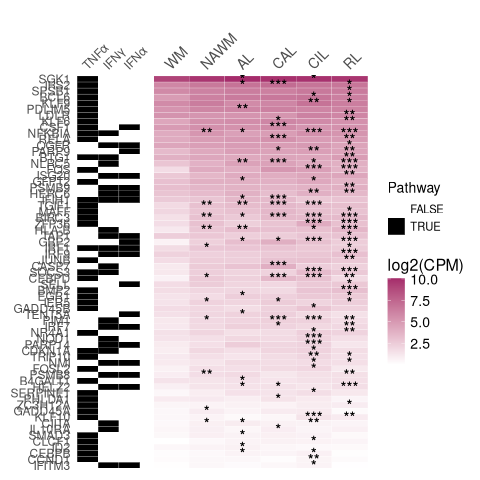

In [13]:
%%R

# Gene list you want to plot
target_genes <- unique(c(TNFa_genes, IFNg_genes, IFNa_genes))

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- 0. Filter genes to only include those with at least 1 significant status ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  filter(if_any(c(Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL), ~ . != "")) %>%  # only keep significant genes
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM")


# Add significance asterisks
df_expr <- df_expr %>%
  mutate(Signif = case_when(
    Group == "NAWM" ~ Sig_NAWM,
    Group == "AL" ~ Sig_AL,
    Group == "CAL" ~ Sig_CAL,
    Group == "CIL" ~ Sig_CIL,
    Group == "RL" ~ Sig_RL,
    TRUE ~ ""
  ))

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=12),  # consistent with heatmap
    axis.text.y = element_text(size = 12),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- 2. Heatmap (hide gene labels) ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif), color = "black", size = 5, vjust = 0.5, fontface = "bold") +  # bigger, bold asterisks
  scale_fill_gradient(low = "white", high = "#a52c6b", name = "log2(CPM)") +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 14),  # bigger text
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 14),       # legend text size
    legend.title = element_text(size = 16),      # legend title size
    plot.title = element_text(hjust = 0.5, size = 16)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(legend.position = "right",
        text = element_text(size = 14))   # increase all base text size as a backup

# ---- 4. Print & save ----
print(final_plot)

# Optional save
#ggsave("final_heatmap_corrections.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

In [14]:
%%R

summary(df_expr$log2CPM)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.02187  1.35826  2.37656  2.79013  3.90485 10.07242 


In [15]:
%%R

genes_plotted <- unique(df_expr$gene)
print(genes_plotted)

 [1] B4GALT1  BCL6     BIRC3    BMP2     BTG1     CASP7    CCND1    CDKN1A  
 [9] CEBPB    CEBPD    CIITA    CLCF1    CSF1     EGR1     FOS      FOSL2   
[17] GADD45A  GADD45B  GBP2     GFPT2    HELZ2    HERC6    HLA-B    ID2     
[25] IER5     IFIH1    IFITM3   IL10RA   IRF1     IRF7     IRF9     IRS2    
[33] ISG20    JUNB     KLF10    KLF6     KLF9     LDLR     MAFF     NFKBIA  
[41] NLRC5    NMI      NOD1     NR4A1    OGFR     PARP14   PARP9    PDLIM5  
[49] PHLDA1   PIM1     PSMB8    PSMB9    RELA     SELL     SERPINE1 SGK1    
[57] SMAD3    SOCS3    SPSB1    TAP1     TENT5A   TGIF1    TRIP10   ZC3H12A 
[65] ZFP36   
65 Levels: IFITM3 CCND1 CEBPB ID2 CLCF1 SMAD3 IL10RA CIITA KLF10 ... SGK1


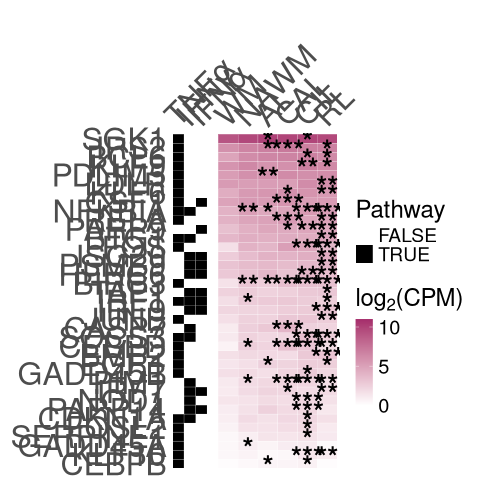

In [16]:
%%R

genes_to_keep <- c(
    "CDKN1A", "SOCS3", "B2M", "NUPR1", "IRF1", "STAT3", "IRF7", "BCL6", "BIRC3", "BMP2", "BTG1", "CASP7",
    "CEBPB", "CEBPD", "CSF1", "EGR1", "FOS", "FOSL2", "GADD45A", "GADD45B", "HERC6", "IRF9", 
    "IRS2", "ISG20", "JUNB", "KLF10","KLF6", "KLF9", "LDLR", "NFKBIA", "NOD1", "PARP14", "PARP9", "PDLIM5", 
    "PIM1","PSMB9", "RELA", "SERPINE1", "SGK1","TAP1"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# Use this filtered gene list for your plot
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM")

# Add significance asterisks
df_expr <- df_expr %>%
  mutate(Signif = case_when(
    Group == "NAWM" ~ Sig_NAWM,
    Group == "AL" ~ Sig_AL,
    Group == "CAL" ~ Sig_CAL,
    Group == "CIL" ~ Sig_CIL,
    Group == "RL" ~ Sig_RL,
    TRUE ~ ""
  ))

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Reorder genes for plotting
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),  # ← x-axis text size for pathways
    axis.text.y = element_text(size = 32),                         # ← gene labels on y-axis
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- 2. Heatmap (hide gene labels, fix asterisk alignment) ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Signif), 
            color = "black", 
            size = 10,       # ← size of the asterisk symbols for significance
            vjust = 0.6,    
            fontface = "bold" 
  ) +
  scale_fill_gradient(low = "white", high = "#a52c6b", 
                      name = expression(log[2]*"(CPM)"), # legend title
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32), # ← x-axis group labels (WM, NAWM, etc.)
    axis.text.y = element_blank(),                               # ← y-axis hidden for heatmap
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),   # ← numbers in the legend color bar
    legend.title = element_text(size = 24),  # ← "log2(CPM)" legend title
    plot.title = element_text(hjust = 0.5, size = 24) # ← main plot title if used
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )
# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("final_heatmap_corrections_human_MOL.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

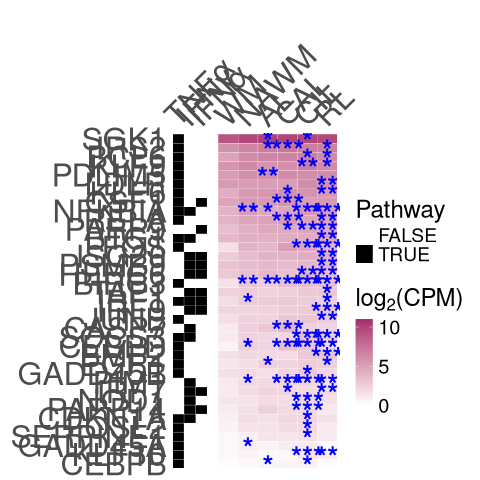

In [17]:
%%R 

genes_to_keep <- c(
    "CDKN1A", "SOCS3", "B2M", "NUPR1", "IRF1", "STAT3", "IRF7", "BCL6", "BIRC3", "BMP2", "BTG1", "CASP7",
    "CEBPB", "CEBPD", "CSF1", "EGR1", "FOS", "FOSL2", "GADD45A", "GADD45B", "HERC6", "IRF9", 
    "IRS2", "ISG20", "JUNB", "KLF10","KLF6", "KLF9", "LDLR", "NFKBIA", "NOD1", "PARP14", "PARP9", "PDLIM5", 
    "PIM1","PSMB9", "RELA", "SERPINE1", "SGK1","TAP1"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Add logFC values into the long df ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,                  # no sig = no color
      logFC_val > 0 ~ "blue",                       # upregulated
      logFC_val < 0 ~ "red",                        # downregulated
      TRUE ~ "blue"
    )
  )

# Factor ordering
df_expr$Group <- factor(df_expr$Group, levels = group_order)
df_expr$gene <- fct_reorder(df_expr$gene, df_expr$log2CPM, .fun = mean)

# Get gene levels from df_expr BEFORE it becomes a factor (as character)
gene_levels <- levels(df_expr$gene)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),  # ← x-axis text size for pathways
    axis.text.y = element_text(size = 32),                         # ← gene labels on y-axis
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("final_heatmap_corrections_human_MOL_colored.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

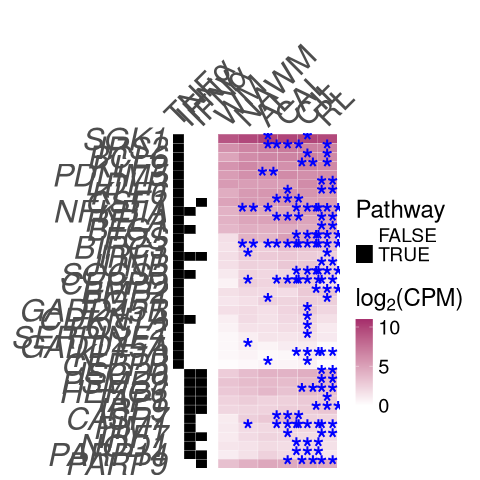

In [19]:
%%R

genes_to_keep <- c(
    "CDKN1A", "SOCS3", "B2M", "NUPR1", "IRF1", "STAT3", "IRF7", "BCL6", "BIRC3", "BMP2", "BTG1", "CASP7",
    "CEBPB", "CEBPD", "CSF1", "EGR1", "FOS", "FOSL2", "GADD45A", "GADD45B", "HERC6", "IRF9", 
    "IRS2", "ISG20", "JUNB", "KLF10","KLF6", "KLF9", "LDLR", "NFKBIA", "NOD1", "PARP14", "PARP9", "PDLIM5", 
    "PIM1","PSMB9", "RELA", "SERPINE1", "SGK1","TAP1"
)

# Gene list you want to plot
target_genes <- genes_to_keep

# Reorder columns
group_order <- c("WM", "NAWM", "AL", "CAL", "CIL", "RL")

# ---- Add logFC values into the long df ----
df_expr <- merged_df %>%
  filter(gene %in% target_genes) %>%
  select(gene, all_of(group_order),
         Sig_NAWM, Sig_AL, Sig_CAL, Sig_CIL, Sig_RL,
         logFC_NAWM, logFC_AL, logFC_CAL, logFC_CIL, logFC_RL) %>%
  pivot_longer(cols = all_of(group_order), names_to = "Group", values_to = "log2CPM") %>%
  mutate(
    Signif = case_when(
      Group == "NAWM" ~ Sig_NAWM,
      Group == "AL"   ~ Sig_AL,
      Group == "CAL"  ~ Sig_CAL,
      Group == "CIL"  ~ Sig_CIL,
      Group == "RL"   ~ Sig_RL,
      TRUE ~ ""
    ),
    logFC_val = case_when(
      Group == "NAWM" ~ logFC_NAWM,
      Group == "AL"   ~ logFC_AL,
      Group == "CAL"  ~ logFC_CAL,
      Group == "CIL"  ~ logFC_CIL,
      Group == "RL"   ~ logFC_RL,
      TRUE ~ NA_real_
    ),
    AsteriskColor = case_when(
      Signif == "" ~ NA_character_,                  # no sig = no color
      logFC_val > 0 ~ "blue",                       # upregulated
      logFC_val < 0 ~ "red",                        # downregulated
      TRUE ~ "blue"
    )
  )

# Make sure group order is respected
df_expr$Group <- factor(df_expr$Group, levels = group_order)

# Fix cytokine label names to use proper Greek characters
annotation_long <- annotation_df %>%
rename(
  `TNFα` = `TNF.α`,
  `IFNγ` = `IFN.γ`,
  `IFNα` = `IFN.α`
  ) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  filter(is_in) %>%
  pivot_wider(names_from = "Pathway", values_from = "is_in", values_fill = FALSE)

# ---- Calculate mean log2CPM per gene for ordering ----
gene_mean_expr <- df_expr %>%
  group_by(gene) %>%
  summarize(mean_log2CPM = mean(log2CPM, na.rm = TRUE), .groups = "drop")

# ---- Create gene ordering by pathway priority, then by mean logCPM ----
# Start with all genes and their pathway memberships
gene_pathway_order <- tibble(gene = unique(df_expr$gene)) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  left_join(gene_mean_expr, by = "gene") %>%
  mutate(
    # Assign pathway priority: 1 = MTORC1, 2 = Glycolysis, 3 = Hypoxia, 4 = None
    pathway_priority = case_when(
      TNFα ~ 1,
      IFNγ ~ 2,
      IFNα ~ 3,
      TRUE ~ 4
    )
  ) %>%
  arrange(pathway_priority, desc(mean_log2CPM))

# Extract the ordered gene levels and reverse them
gene_levels <- rev(gene_pathway_order$gene)

# Apply the custom gene order to df_expr
df_expr$gene <- factor(df_expr$gene, levels = gene_levels)

# Make sure gene names match and stay in order
annotation_display <- tibble(gene = gene_levels) %>%
  left_join(annotation_long, by = "gene") %>%
  replace(is.na(.), FALSE) %>%
  pivot_longer(cols = -gene, names_to = "Pathway", values_to = "is_in") %>%
  mutate(
    gene = factor(gene, levels = gene_levels),
    Pathway = factor(Pathway, levels = c("TNFα", "IFNγ", "IFNα"))
  )

# ---- 1. Cytokine annotation block (with gene labels) ----
annotation_plot <- ggplot(annotation_display, aes(x = Pathway, y = gene, fill = is_in)) +
  geom_tile(color = "white") +
  scale_fill_manual(
    values = c("TRUE" = "black", "FALSE" = "white"),
    name = "Pathway"
  ) +
  scale_x_discrete(position = "top") +  # move axis labels to top
  theme_minimal() +
  labs(x = NULL, y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size=32),  # consistent with heatmap
    axis.text.y = element_text(size = 32, face = "italic"),   # ← **Make gene names italic**
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    plot.margin = margin(t = 5, r = 0, b = 5, l = 5)
  )

# ---- Modify heatmap with colored asterisks ----
heatmap_plot <- ggplot(df_expr, aes(x = Group, y = gene, fill = log2CPM)) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = Signif, color = AsteriskColor),
    size = 10, vjust = 0.6, fontface = "bold"
  ) +
  scale_color_identity() +   # respects the "black"/"blue" directly
  scale_fill_gradient(low = "white", high = "#a52c6b",
                      name = expression(log[2]*"(CPM)"),
                      breaks = c(0, 5, 10), limits = c(0, 11)) +
  scale_x_discrete(position = "top") +
  theme_minimal() +
  labs(x = "", y = NULL) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 0, size = 32),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.ticks = element_blank(),
    legend.position = "right",
    legend.text = element_text(size = 20),
    legend.title = element_text(size = 24),
    plot.title = element_text(hjust = 0.5, size = 24)
  )

# ---- 3. Combine with legends collected to the right ----
final_plot <- annotation_plot + heatmap_plot +
  plot_layout(widths = c(1.2, 4), guides = "collect") &
  theme(
    legend.position = "right",
    text = element_text(size = 24)  # ← general text size fallback (affects e.g. facet labels if any)
  )

# ---- 4. Print & save ----
print(final_plot)

# Optional save
ggsave("MOL_heatmap_working2.png", plot = final_plot, width = 14, height = 18, units = "in", dpi = 600)

In [21]:
%%R
merged_df[merged_df$gene == "SOCS3", ]

      V1   gene logFC_NAWM  FDR_NAWM   logFC_AL    FDR_AL logFC_CAL   FDR_CAL
   <int> <char>      <num>     <num>      <num>     <num>     <num>     <num>
1: 16849  SOCS3   1.751402 0.2796787 -0.0384754 0.9890695 0.6275424 0.6877139
   logFC_CIL      FDR_CIL logFC_RL       FDR_RL DEG_NAWM DEG_AL DEG_CAL DEG_CIL
       <num>        <num>    <num>        <num>   <lgcl> <lgcl>  <lgcl>  <lgcl>
1:  2.862436 9.453284e-05 3.261243 8.826576e-06    FALSE  FALSE   FALSE    TRUE
   DEG_RL Sig_NAWM Sig_AL Sig_CAL Sig_CIL Sig_RL       AL      CAL      CIL
   <lgcl>   <char> <char>  <char>  <char> <char>    <num>    <num>    <num>
1:   TRUE                             ***    *** 2.112425 2.202145 3.318961
       NAWM       RL       WM
      <num>    <num>    <num>
1: 2.404954 2.671166 1.156615


In [ ]:
%%R
merged_df[merged_df$gene == "NUPR1", ]